## 題號 1
**問題**: 周天成使用「殺球」得分佔他總得分的百分比是多少？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


In [ ]:
required_cols = ['match_id', 'set', 'rally', 'player', 'type', 'getpoint_player']
missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法計算。')
elif missing_cols:
    print(f'缺少必要欄位：{missing_cols}')
else:
    group_cols = ['match_id', 'set', 'rally']
    target_player = 'CHOU Tien Chen'

    rally_end = (
        df.groupby(group_cols, sort=False, as_index=False)
          .tail(1)
          .loc[:, required_cols]
          .dropna(subset=['getpoint_player'])
    )

    active_wins = rally_end[
        (rally_end['player'] == rally_end['getpoint_player']) &
        (rally_end['getpoint_player'] == target_player)
    ]

    total_active_wins = len(active_wins)
    smash_active_wins = len(
        active_wins[active_wins['type'] == '殺球']
    )

    percentage = (
        smash_active_wins / total_active_wins * 100
        if total_active_wins > 0 else 0
    )

    print(f'周天成殺球主動得分：{smash_active_wins} 分')
    print(f'周天成總主動得分：{total_active_wins} 分')
    print(f'周天成使用殺球得分佔總主動得分的百分比：{percentage:.2f}%')


周天成殺球主動得分：61 分
周天成總主動得分：85 分
周天成使用殺球得分佔總主動得分的百分比：71.76%


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 6
**問題**: 在第一場次中，每回合用的拍數，繪圖
> **使用的資料欄位群組**: `全欄位 (Fallback)`


第一場次各回合使用拍數：
 set  rally  拍數
   1      1   2
   1      2   6
   1      3  27
   1      4   6
   1      5  16
   1      6   5
   1      7   4
   1      8   6
   1      9  22
   1     10   9
   1     11  41
   1     12  34
   1     13  39
   1     14  14
   1     15  18
   1     16  40
   1     17  15
   1     18  19
…（輸出已截斷；notebook 僅保留重點）


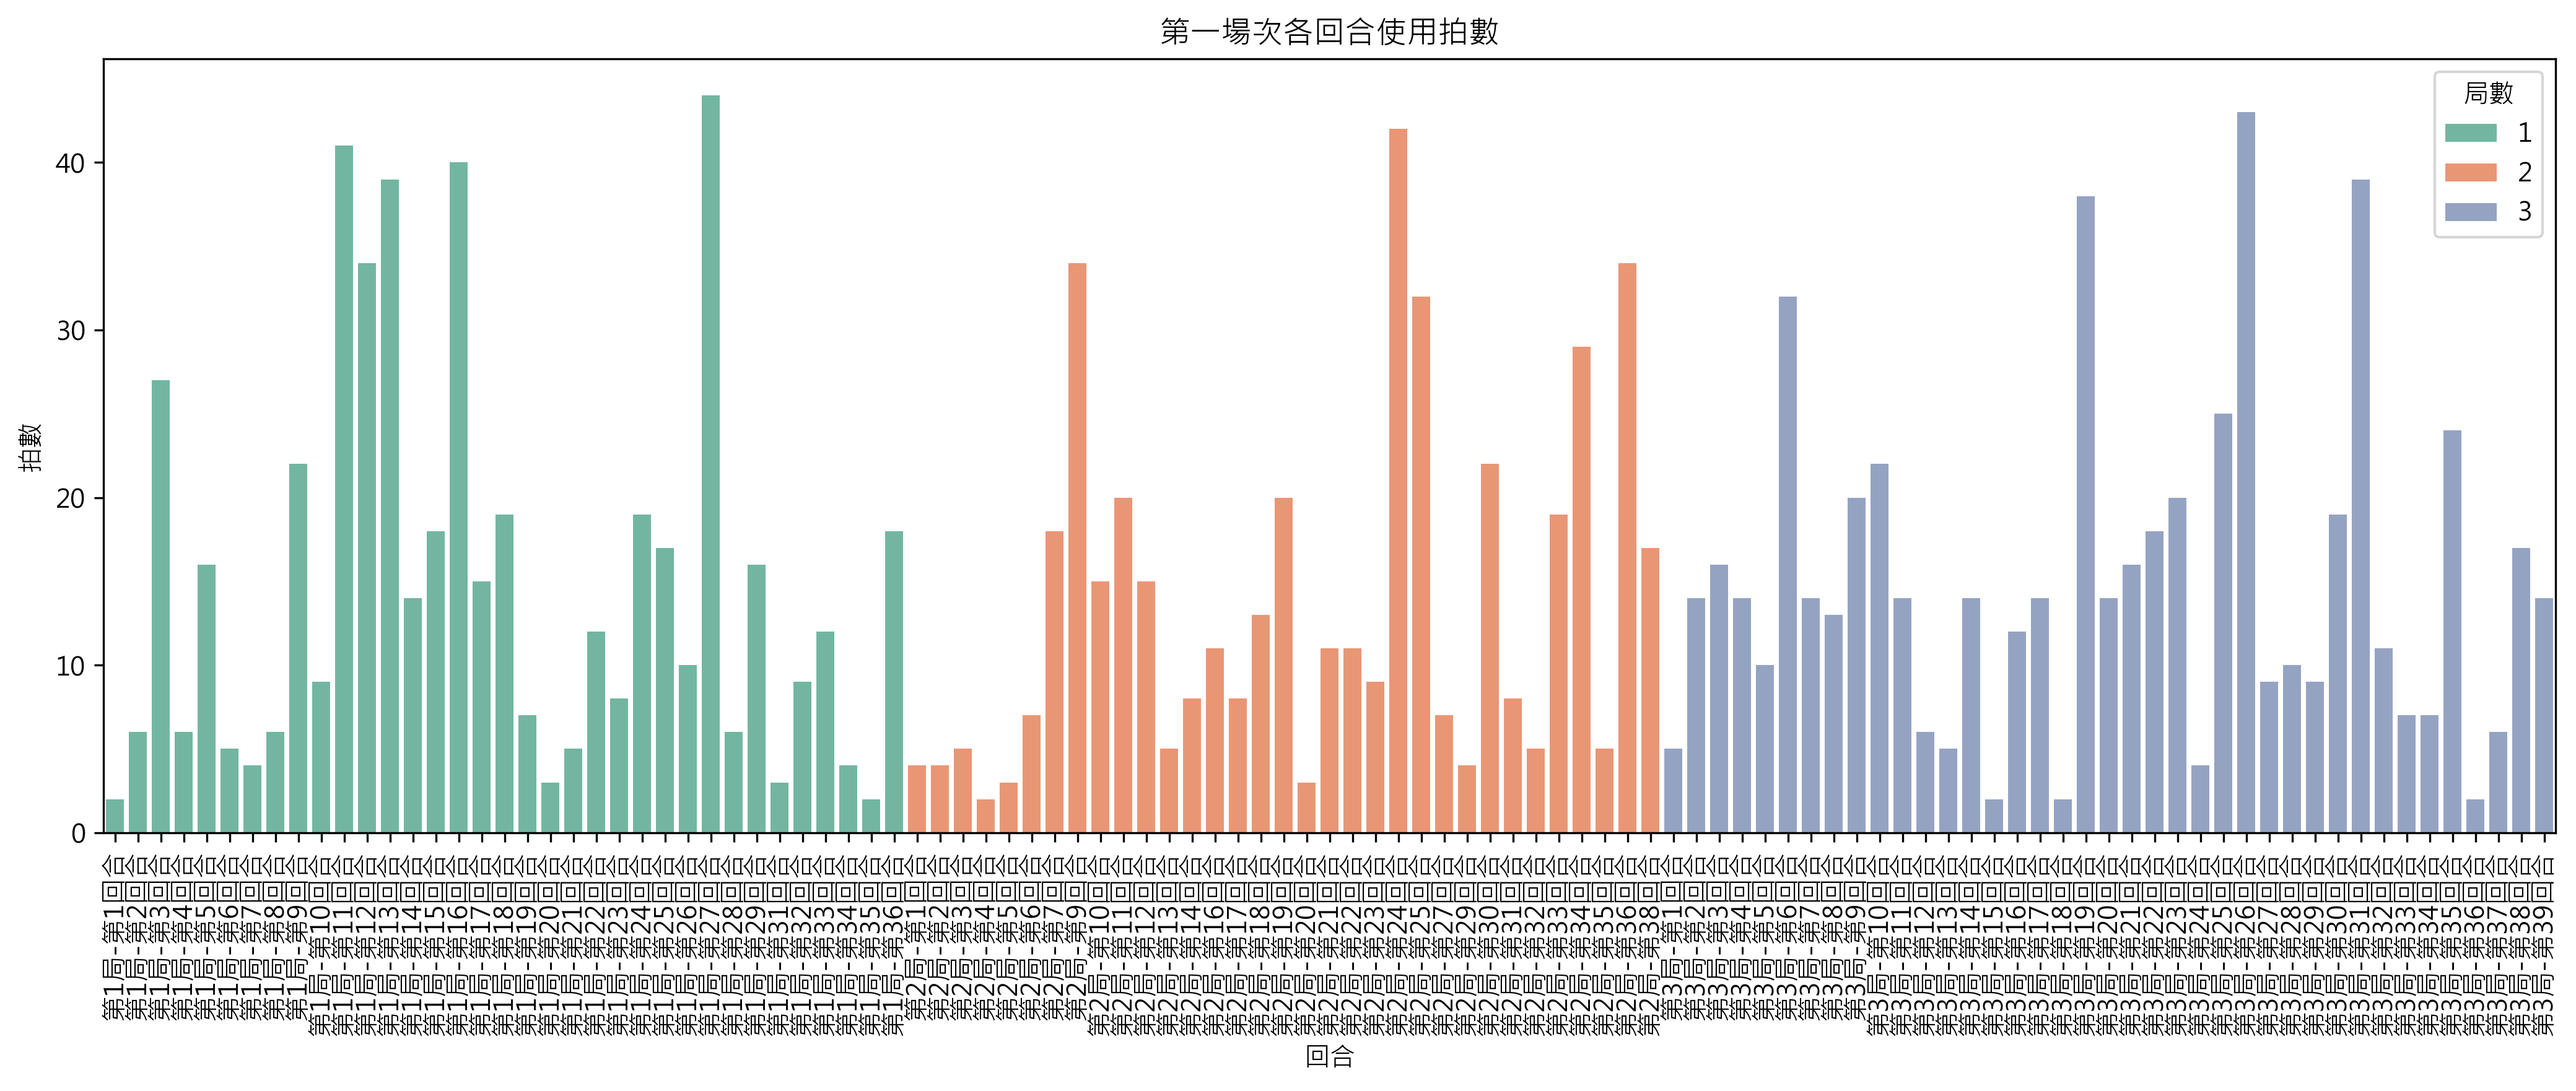

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    required_cols = ['match_id', 'set', 'rally', 'ball_round']
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        match_df = df.loc[df['match_id'] == 1, required_cols].copy()

        if len(match_df) == 0:
            print("第一場次（match_id=1）沒有資料。")
        else:
            rally_shots = (
                match_df
                .dropna(subset=['match_id', 'set', 'rally', 'ball_round'])
                .groupby(['match_id', 'set', 'rally'], as_index=False)
                .agg(拍數=('ball_round', 'count'))
                .sort_values(['set', 'rally'])
            )

            if len(rally_shots) == 0:
                print("第一場次沒有可計算的回合拍數。")
            else:
                rally_shots['回合標籤'] = (
                    '第' + rally_shots['set'].astype(int).astype(str) +
                    '局-第' + rally_shots['rally'].astype(int).astype(str) + '回合'
                )

                print("第一場次各回合使用拍數：")
                print(rally_shots[['set', 'rally', '拍數']].to_string(index=False))

                summary = rally_shots['拍數'].describe()
                print("\n拍數統計摘要：")
                print(summary.to_string())

                fig, ax = plt.subplots(figsize=(14, 6))
                sns.barplot(
                    data=rally_shots,
                    x='回合標籤',
                    y='拍數',
                    hue='set',
                    dodge=False,
                    palette='Set2',
                    ax=ax
                )

                ax.set_title('第一場次各回合使用拍數')
                ax.set_xlabel('回合')
                ax.set_ylabel('拍數')
                ax.legend(title='局數')
                ax.tick_params(axis='x', rotation=90)
                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 10
**問題**: 當周天成站在前場時，他最主要的得分球種?
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成站在前場時，最主要的得分球種：殺球
主動得分回合數：21
佔前場主動得分比例：58.33%

前場主動得分球種統計：
type  主動得分回合數  佔前場主動得分比例
  殺球       21  58.333333
  切球        5  13.888889
  長球        5  13.888889
 推撲球        3   8.333333
  平球        2   5.555556


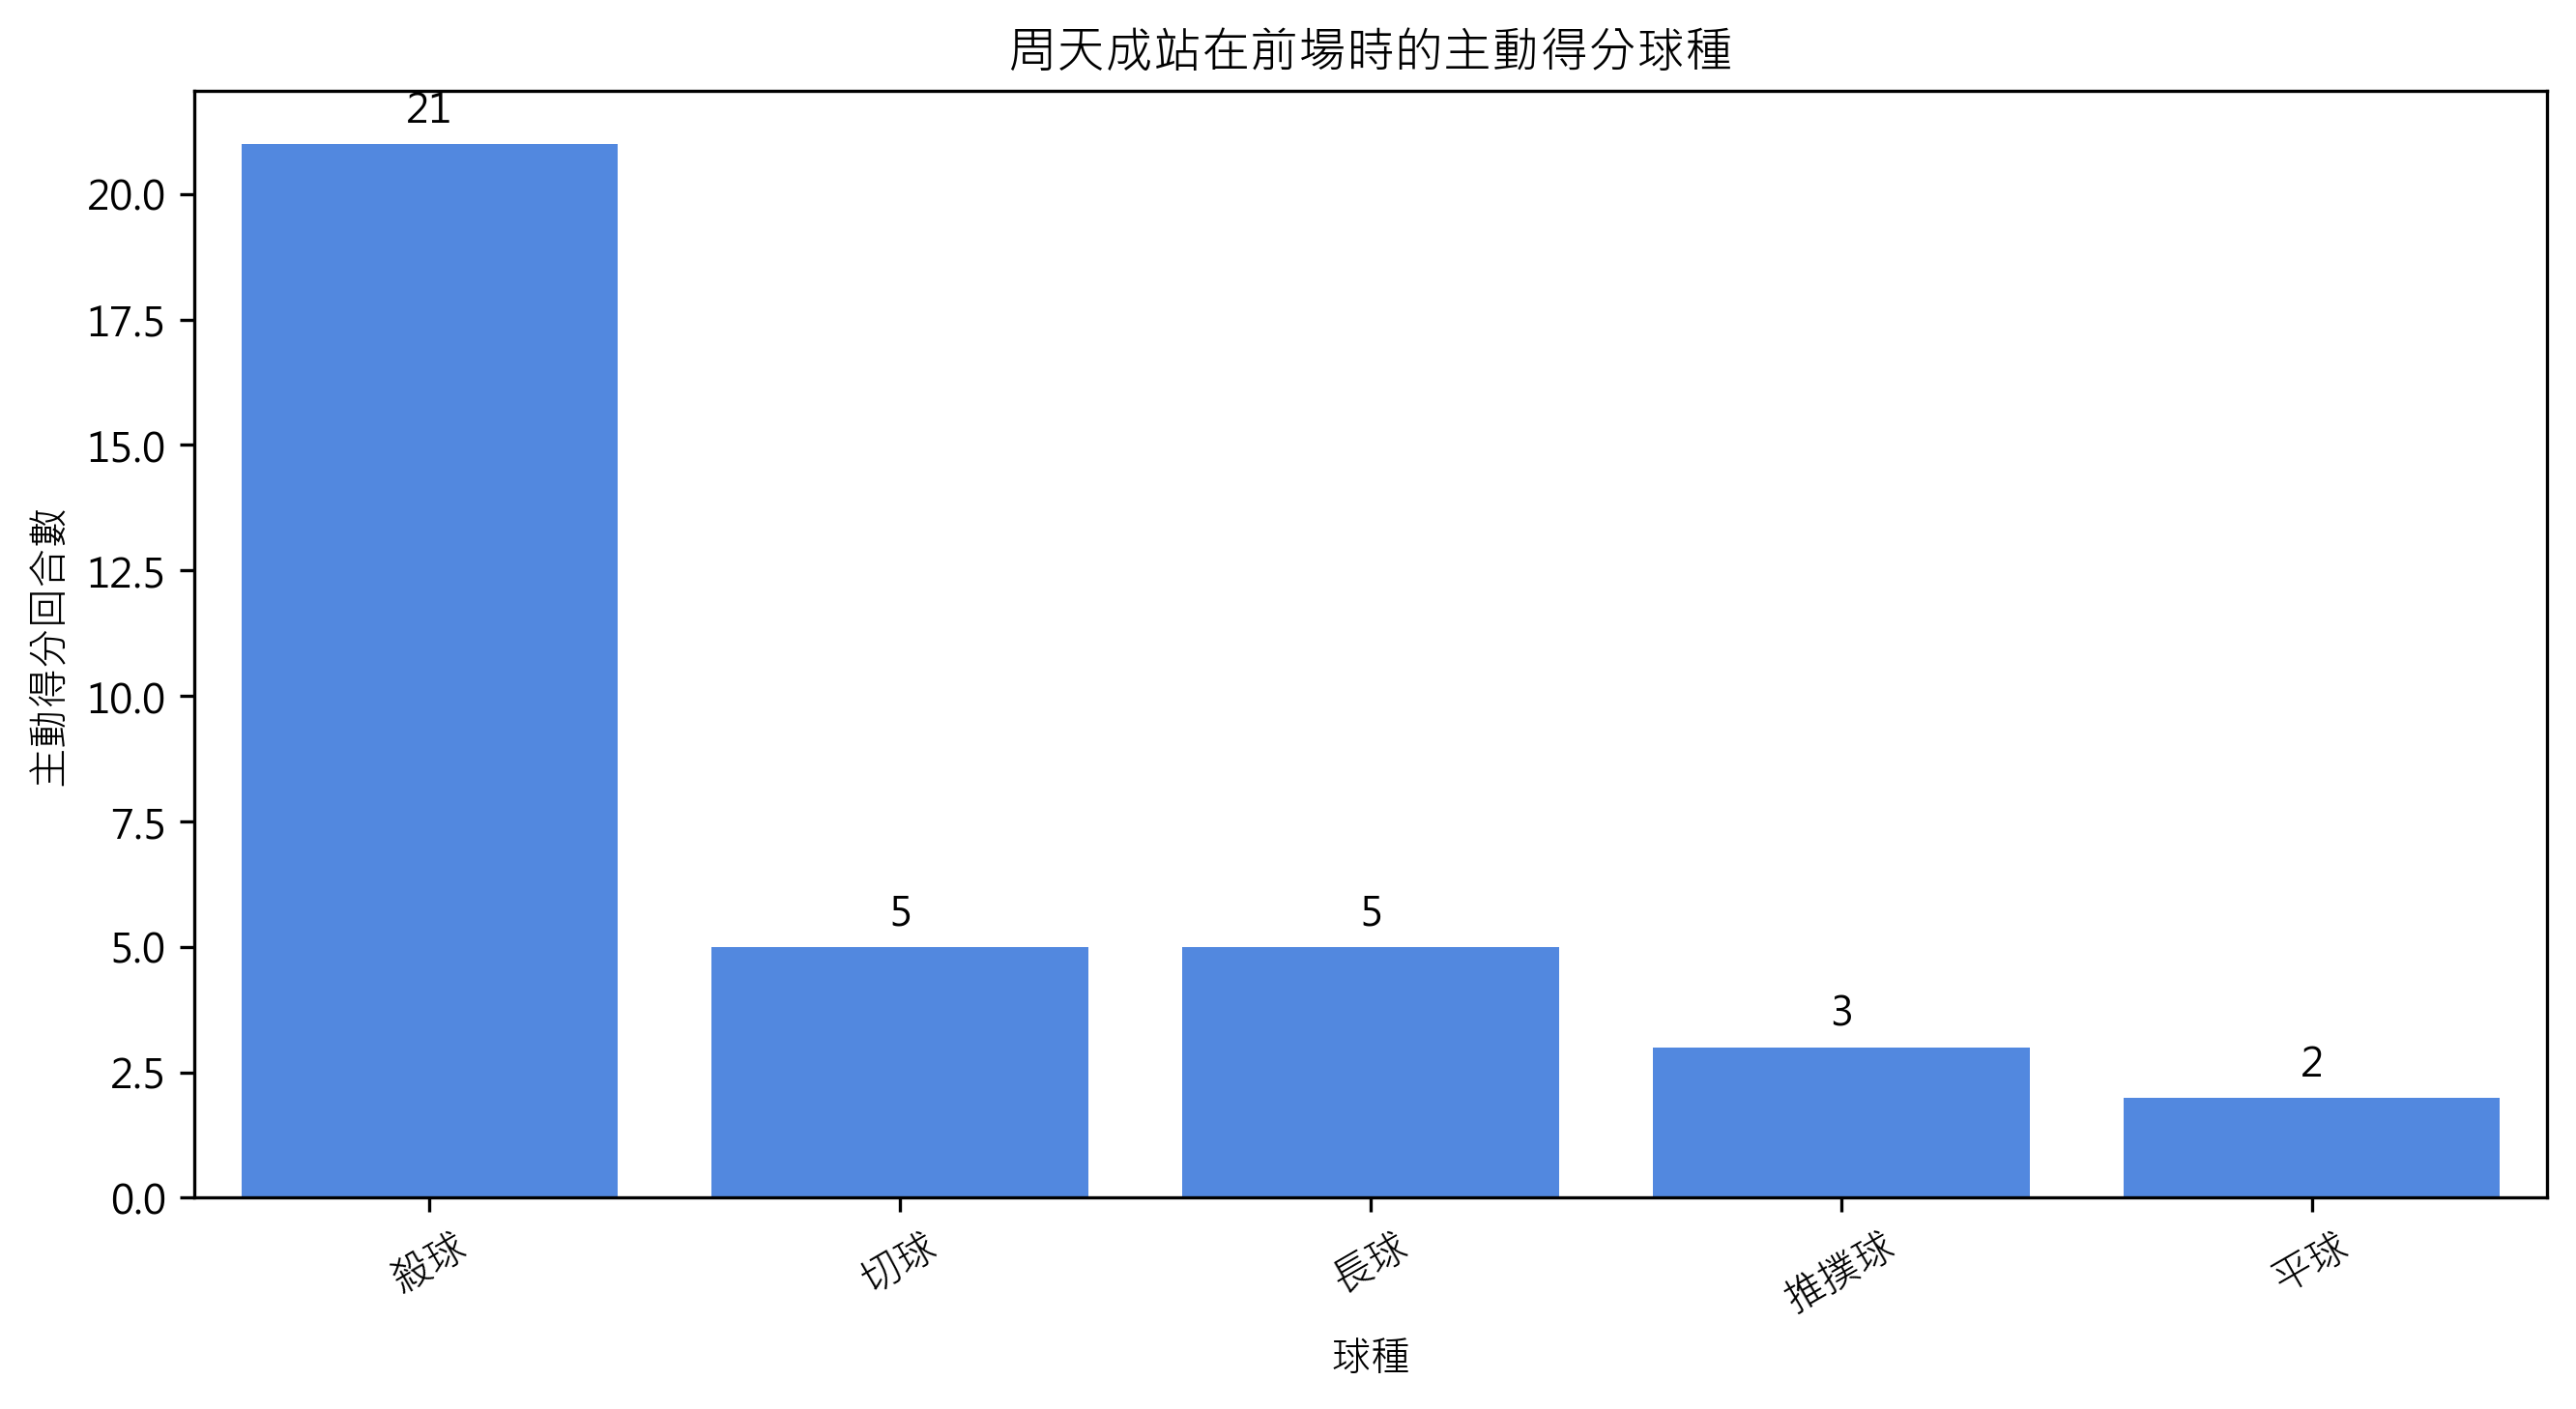

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
    fig, ax = plt.subplots(figsize=(8, 5))
else:
    player_name = "CHOU Tien Chen"

    court_grid_definitions = {
        "前場": [17, 18, 19, 20, 21, 22, 23, 24],
        "中場": [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
        "後場": [1, 2, 3, 4],
        "出界": [25, 26, 27, 28, 29, 30, 31, 32],
    }
    front_zones = court_grid_definitions["前場"]

    work_df = df.sort_values(
        ["match_id", "set", "rally", "ball_round"]
    ).copy()

    work_df["rally_getpoint_player"] = (
        work_df.groupby(["match_id", "set", "rally"])["getpoint_player"]
        .transform("last")
    )

    active_front_wins = work_df[
        (work_df["player"] == player_name)
        & (work_df["rally_getpoint_player"] == player_name)
        & (work_df["player_location_area"].isin(front_zones))
        & work_df["type"].notna()
    ].copy()

    if len(active_front_wins) == 0:
        print("找不到周天成站在前場時的主動得分資料。")
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        shot_counts = (
            active_front_wins.groupby("type")
            .size()
            .sort_values(ascending=False)
            .rename("主動得分回合數")
            .reset_index()
        )

        total_active_front_wins = int(shot_counts["主動得分回合數"].sum())
        shot_counts["佔前場主動得分比例"] = (
            shot_counts["主動得分回合數"] / total_active_front_wins * 100
        )

        top_shot = shot_counts.iloc[0]

        print(f"周天成站在前場時，最主要的得分球種：{top_shot['type']}")
        print(f"主動得分回合數：{int(top_shot['主動得分回合數'])}")
        print(f"佔前場主動得分比例：{top_shot['佔前場主動得分比例']:.2f}%")
        print("\n前場主動得分球種統計：")
        print(shot_counts.to_string(index=False))

        plot_df = shot_counts.copy()
        if len(plot_df) > 8:
            top_types = plot_df.head(7)["type"].tolist()
            plot_df.loc[~plot_df["type"].isin(top_types), "type"] = "其他"
            plot_df = (
                plot_df.groupby("type", as_index=False)["主動得分回合數"]
                .sum()
                .sort_values("主動得分回合數", ascending=False)
            )

        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(
            data=plot_df,
            x="type",
            y="主動得分回合數",
            color="#3B82F6",
            ax=ax,
        )
        ax.set_title("周天成站在前場時的主動得分球種")
        ax.set_xlabel("球種")
        ax.set_ylabel("主動得分回合數")
        ax.tick_params(axis="x", rotation=30)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.0f", padding=3)

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 13
**問題**: 幫我統整周天成所有球種的使用比例，以及每種球種的「得分次數」和「失誤次數」。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


球員：CHOU Tien Chen
統計拍數：2609
得分次數定義：該球員擊球且該擊球者主動得分。
失誤次數定義：該球員擊球且該回合由對手得分。
  球種  使用次數  使用比例(%)  得分次數  失誤次數
 發短球   147     5.63    56    91
 發長球    34     1.30    16    18
  長球   275    10.54   120   155
  殺球   299    11.46   158   141
  切球   211     8.09    92   119
  挑球   270    10.35   122   148
  平球   106     4.06    50    56
 網前球   582    22.31   263   319
 推撲球   334    12.80   174   160
接殺防守   351    13.45   137   214


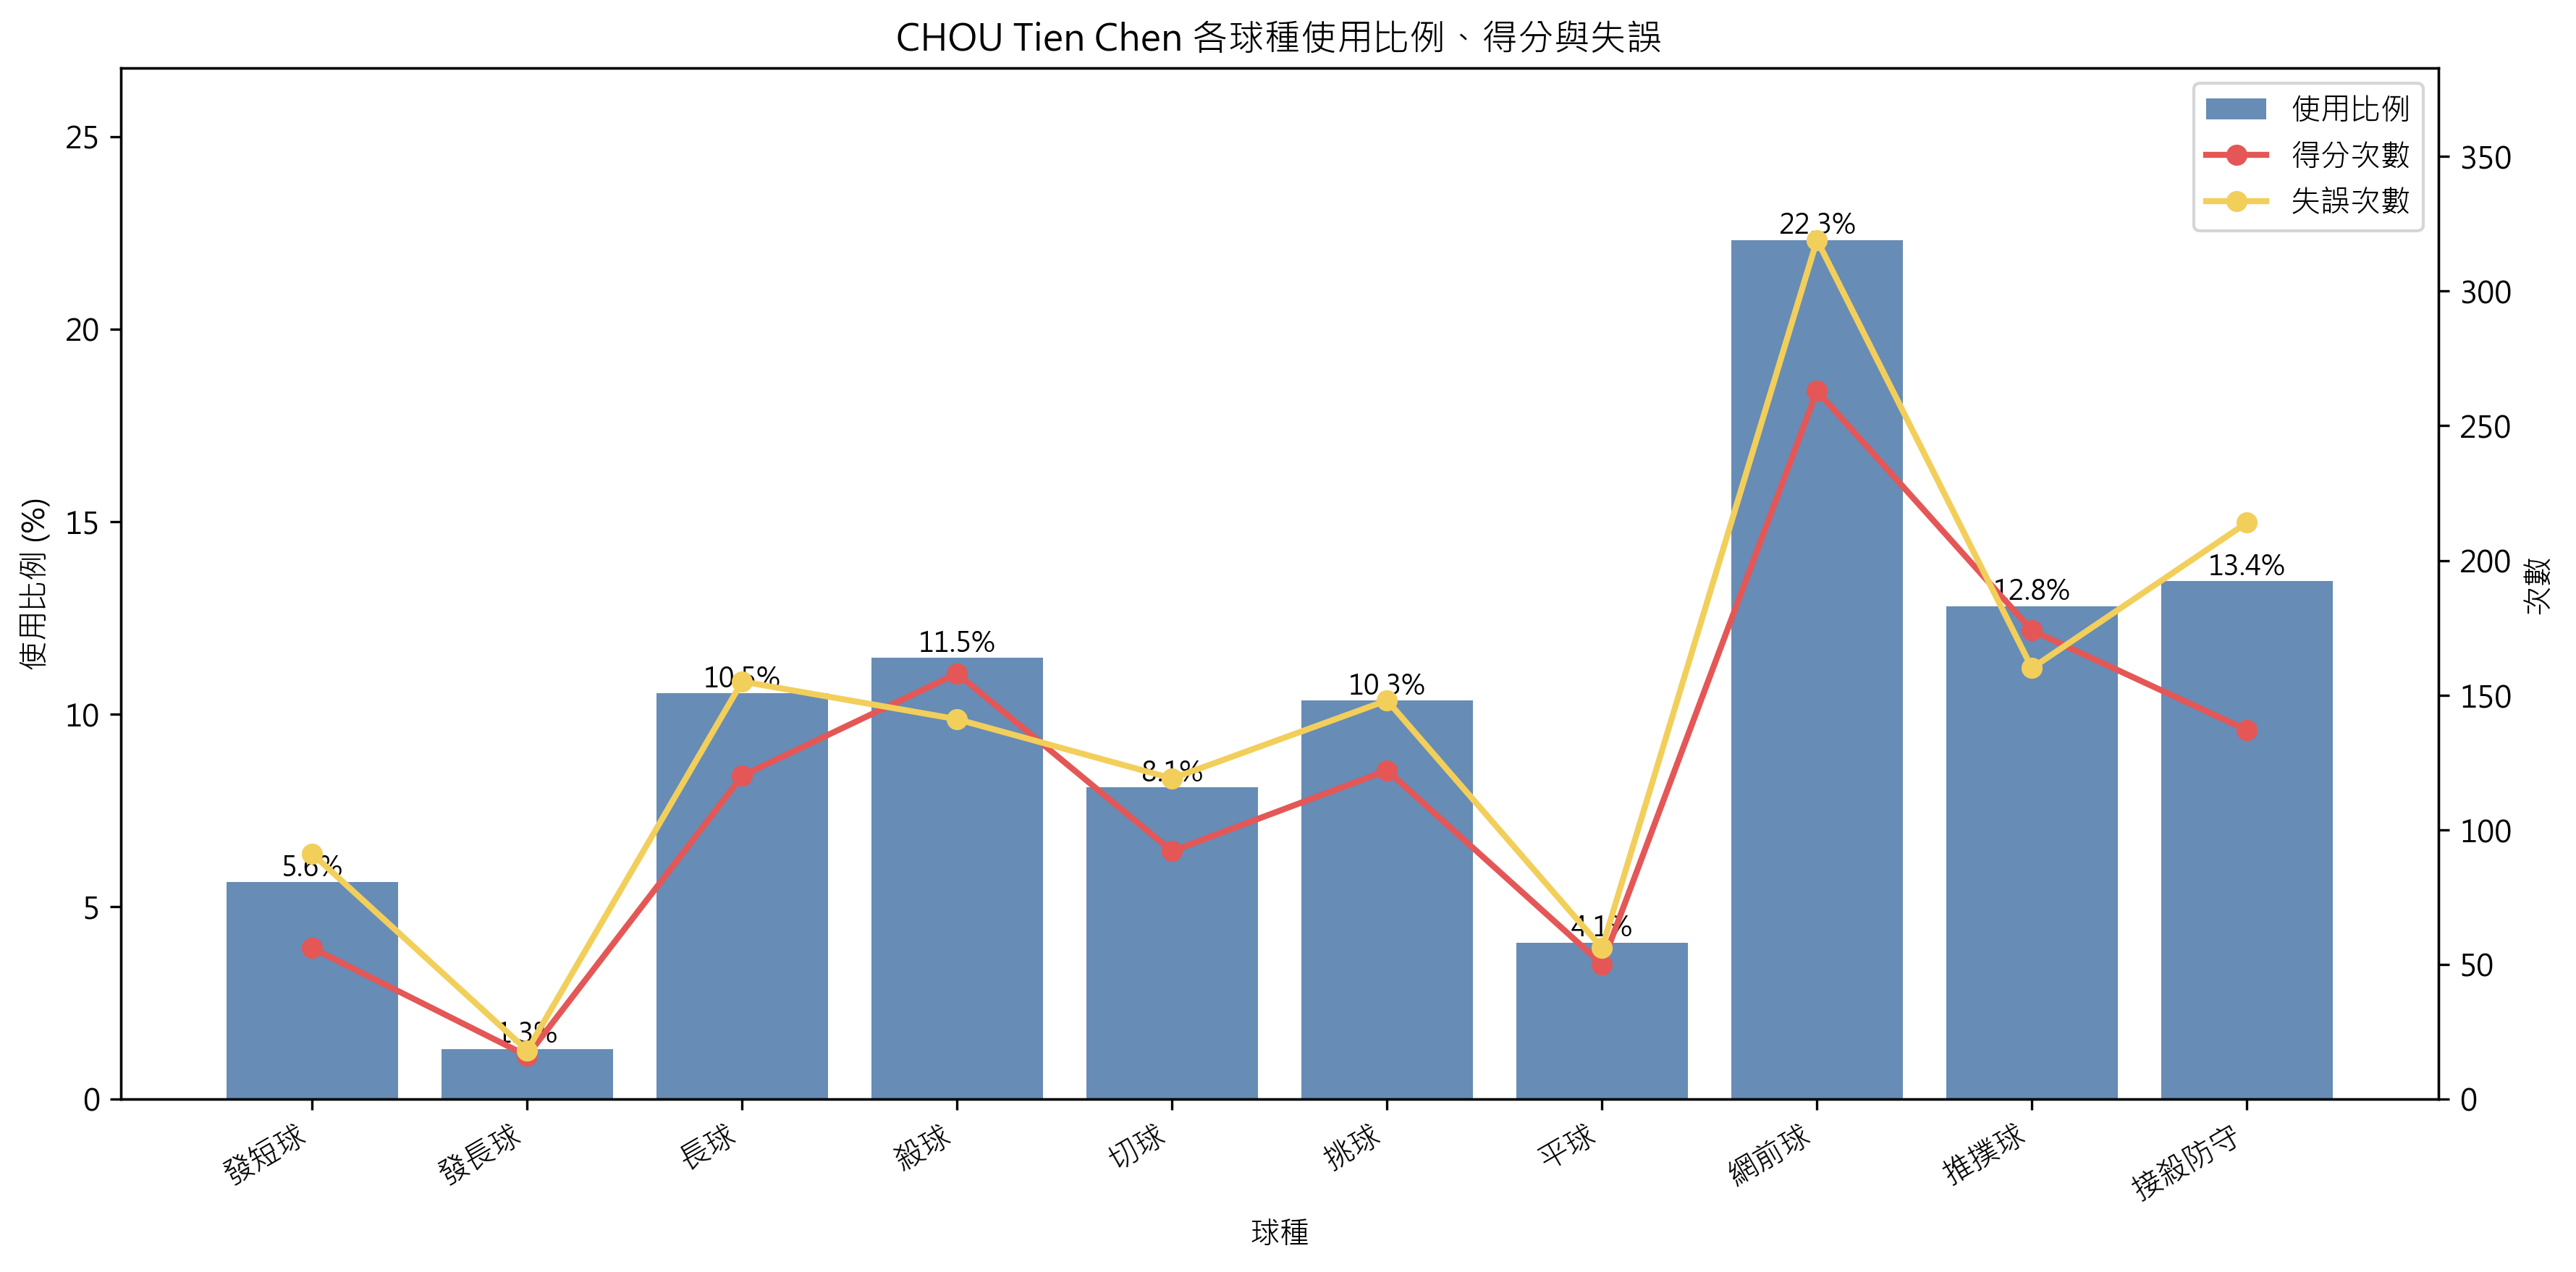

In [ ]:
if len(df) == 0:
    print("資料為空，無法進行統計。")
else:
    shot_order = [
        '發短球', '發長球', '長球', '殺球', '切球',
        '挑球', '平球', '網前球', '推撲球', '接殺防守'
    ]
    player_name = 'CHOU Tien Chen'
    opponent_name = 'Kento MOMOTA'

    required_cols = [
        'match_id', 'set', 'rally', 'ball_round',
        'player', 'type', 'getpoint_player'
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        work['rally_getpoint_player'] = (
            work.groupby(['match_id', 'set', 'rally'])['getpoint_player']
            .transform('last')
        )

        player_shots = work[
            (work['player'] == player_name) &
            (work['type'].notna())
        ].copy()

        if len(player_shots) == 0:
            print(f"找不到 {player_name} 的有效擊球資料。")
        else:
            usage_counts = (
                player_shots['type']
                .value_counts()
                .reindex(shot_order, fill_value=0)
            )

            active_win_mask = (
                (player_shots['rally_getpoint_player'] == player_name) &
                (player_shots['player'] == player_shots['rally_getpoint_player'])
            )

            error_mask = (
                (player_shots['rally_getpoint_player'] == opponent_name) &
                (player_shots['player'] == player_name)
            )

            active_win_counts = (
                player_shots.loc[active_win_mask, 'type']
                .value_counts()
                .reindex(shot_order, fill_value=0)
            )

            error_counts = (
                player_shots.loc[error_mask, 'type']
                .value_counts()
                .reindex(shot_order, fill_value=0)
            )

            total_shots = int(usage_counts.sum())

            result = pd.DataFrame({
                '球種': shot_order,
                '使用次數': usage_counts.astype(int).values,
                '使用比例(%)': (
                    usage_counts / total_shots * 100
                ).round(2).values,
                '得分次數': active_win_counts.astype(int).values,
                '失誤次數': error_counts.astype(int).values
            })

            print(f"球員：{player_name}")
            print(f"統計拍數：{total_shots}")
            print("得分次數定義：該球員擊球且該擊球者主動得分。")
            print("失誤次數定義：該球員擊球且該回合由對手得分。")
            print(result.to_string(index=False))

            plot_df = result.copy()

            fig, ax1 = plt.subplots(figsize=(12, 6))
            x = range(len(plot_df))

            bars = ax1.bar(
                x,
                plot_df['使用比例(%)'],
                color='#4C78A8',
                alpha=0.85,
                label='使用比例'
            )
            ax1.set_xlabel('球種')
            ax1.set_ylabel('使用比例 (%)')
            ax1.set_xticks(list(x))
            ax1.set_xticklabels(plot_df['球種'], rotation=30, ha='right')
            ax1.set_ylim(0, max(plot_df['使用比例(%)'].max() * 1.2, 1))

            for bar, value in zip(bars, plot_df['使用比例(%)']):
                ax1.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f'{value:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

            ax2 = ax1.twinx()
            ax2.plot(
                list(x),
                plot_df['得分次數'],
                marker='o',
                linewidth=2,
                color='#E45756',
                label='得分次數'
            )
            ax2.plot(
                list(x),
                plot_df['失誤次數'],
                marker='o',
                linewidth=2,
                color='#F2CF5B',
                label='失誤次數'
            )
            ax2.set_ylabel('次數')
            ax2.set_ylim(
                0,
                max(
                    plot_df[['得分次數', '失誤次數']].to_numpy().max() * 1.2,
                    1
                )
            )

            handles1, labels1 = ax1.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(
                handles1 + handles2,
                labels1 + labels2,
                loc='upper right'
            )

            ax1.set_title(f'{player_name} 各球種使用比例、得分與失誤')
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 16
**問題**: 給我周天成最常見的失分原因
> **使用的資料欄位群組**: `全欄位 (Fallback)`


CHOU Tien Chen最常見的失分原因：
lose_reason  失分回合數  佔全部失分比例(%)
         出界     72       47.06
         掛網     57       37.25
        未過網     24       15.69

最常見原因：出界，72 回合 (47.06%)


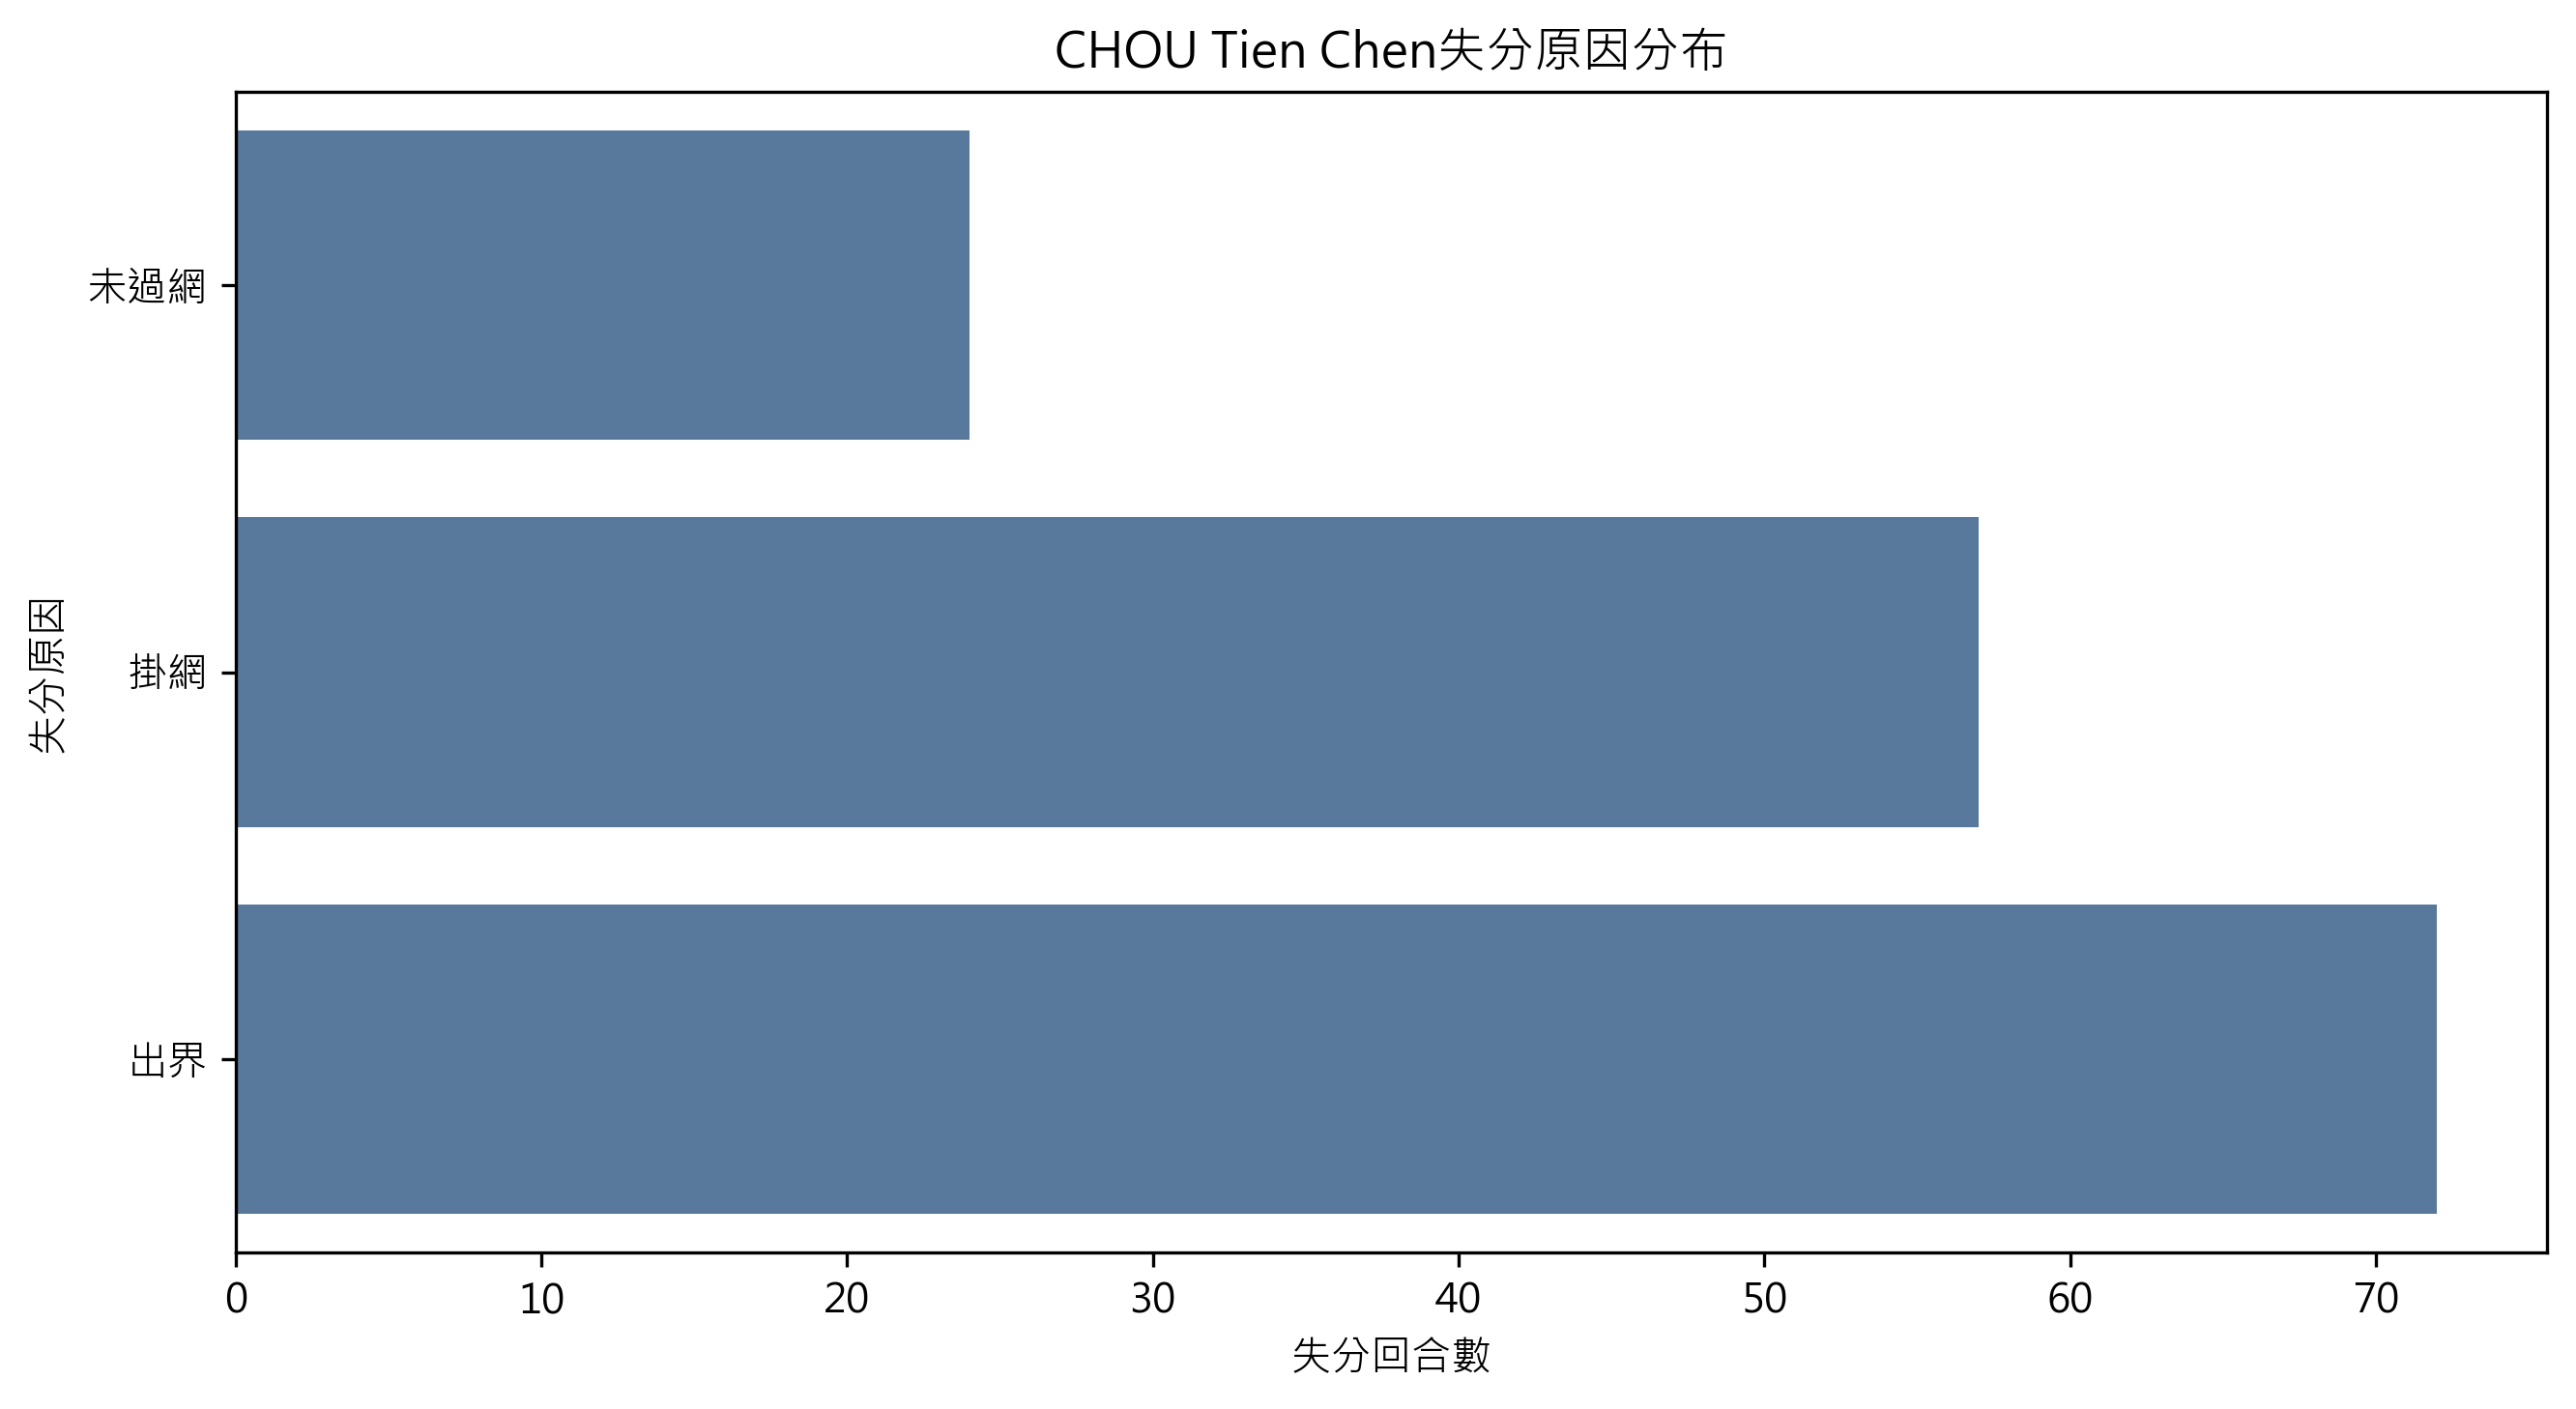

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    player_name = "CHOU Tien Chen"
    group_cols = ["match_id", "set", "rally"]

    rally_end = (
        df.sort_values(group_cols + ["ball_round"])
          .groupby(group_cols, sort=False, group_keys=False)
          .tail(1)
    )

    loss_df = rally_end[
        (rally_end["player"] == player_name) &
        (rally_end["getpoint_player"] == rally_end["opponent"]) &
        (rally_end["lose_reason"].notna())
    ][["match_id", "set", "rally", "lose_reason"]].copy()

    if len(loss_df) == 0:
        print(f"{player_name}沒有可辨識的失分原因資料。")
    else:
        reason_stats = (
            loss_df.groupby("lose_reason", dropna=False)
                   .size()
                   .reset_index(name="失分回合數")
                   .sort_values(["失分回合數", "lose_reason"], ascending=[False, True])
                   .reset_index(drop=True)
        )
        reason_stats["佔全部失分比例(%)"] = (
            reason_stats["失分回合數"] / reason_stats["失分回合數"].sum() * 100
        ).round(2)

        print(f"{player_name}最常見的失分原因：")
        print(reason_stats.to_string(index=False))
        print(f"\n最常見原因：{reason_stats.loc[0, 'lose_reason']}，"
              f"{int(reason_stats.loc[0, '失分回合數'])} 回合 "
              f"({reason_stats.loc[0, '佔全部失分比例(%)']:.2f}%)")

        if len(reason_stats) > 0:
            fig, ax = plt.subplots(figsize=(9, 5))
            plot_df = reason_stats.sort_values("失分回合數", ascending=True)
            sns.barplot(
                data=plot_df,
                x="失分回合數",
                y="lose_reason",
                color="#4C78A8",
                ax=ax
            )
            ax.set_title(f"{player_name}失分原因分布")
            ax.set_xlabel("失分回合數")
            ax.set_ylabel("失分原因")
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 17
**問題**: 繪製周天成所有輸球原因為'掛網'時的球員站位熱區圖？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成因「掛網」輸球的擊球筆數：60
涉及回合數：57


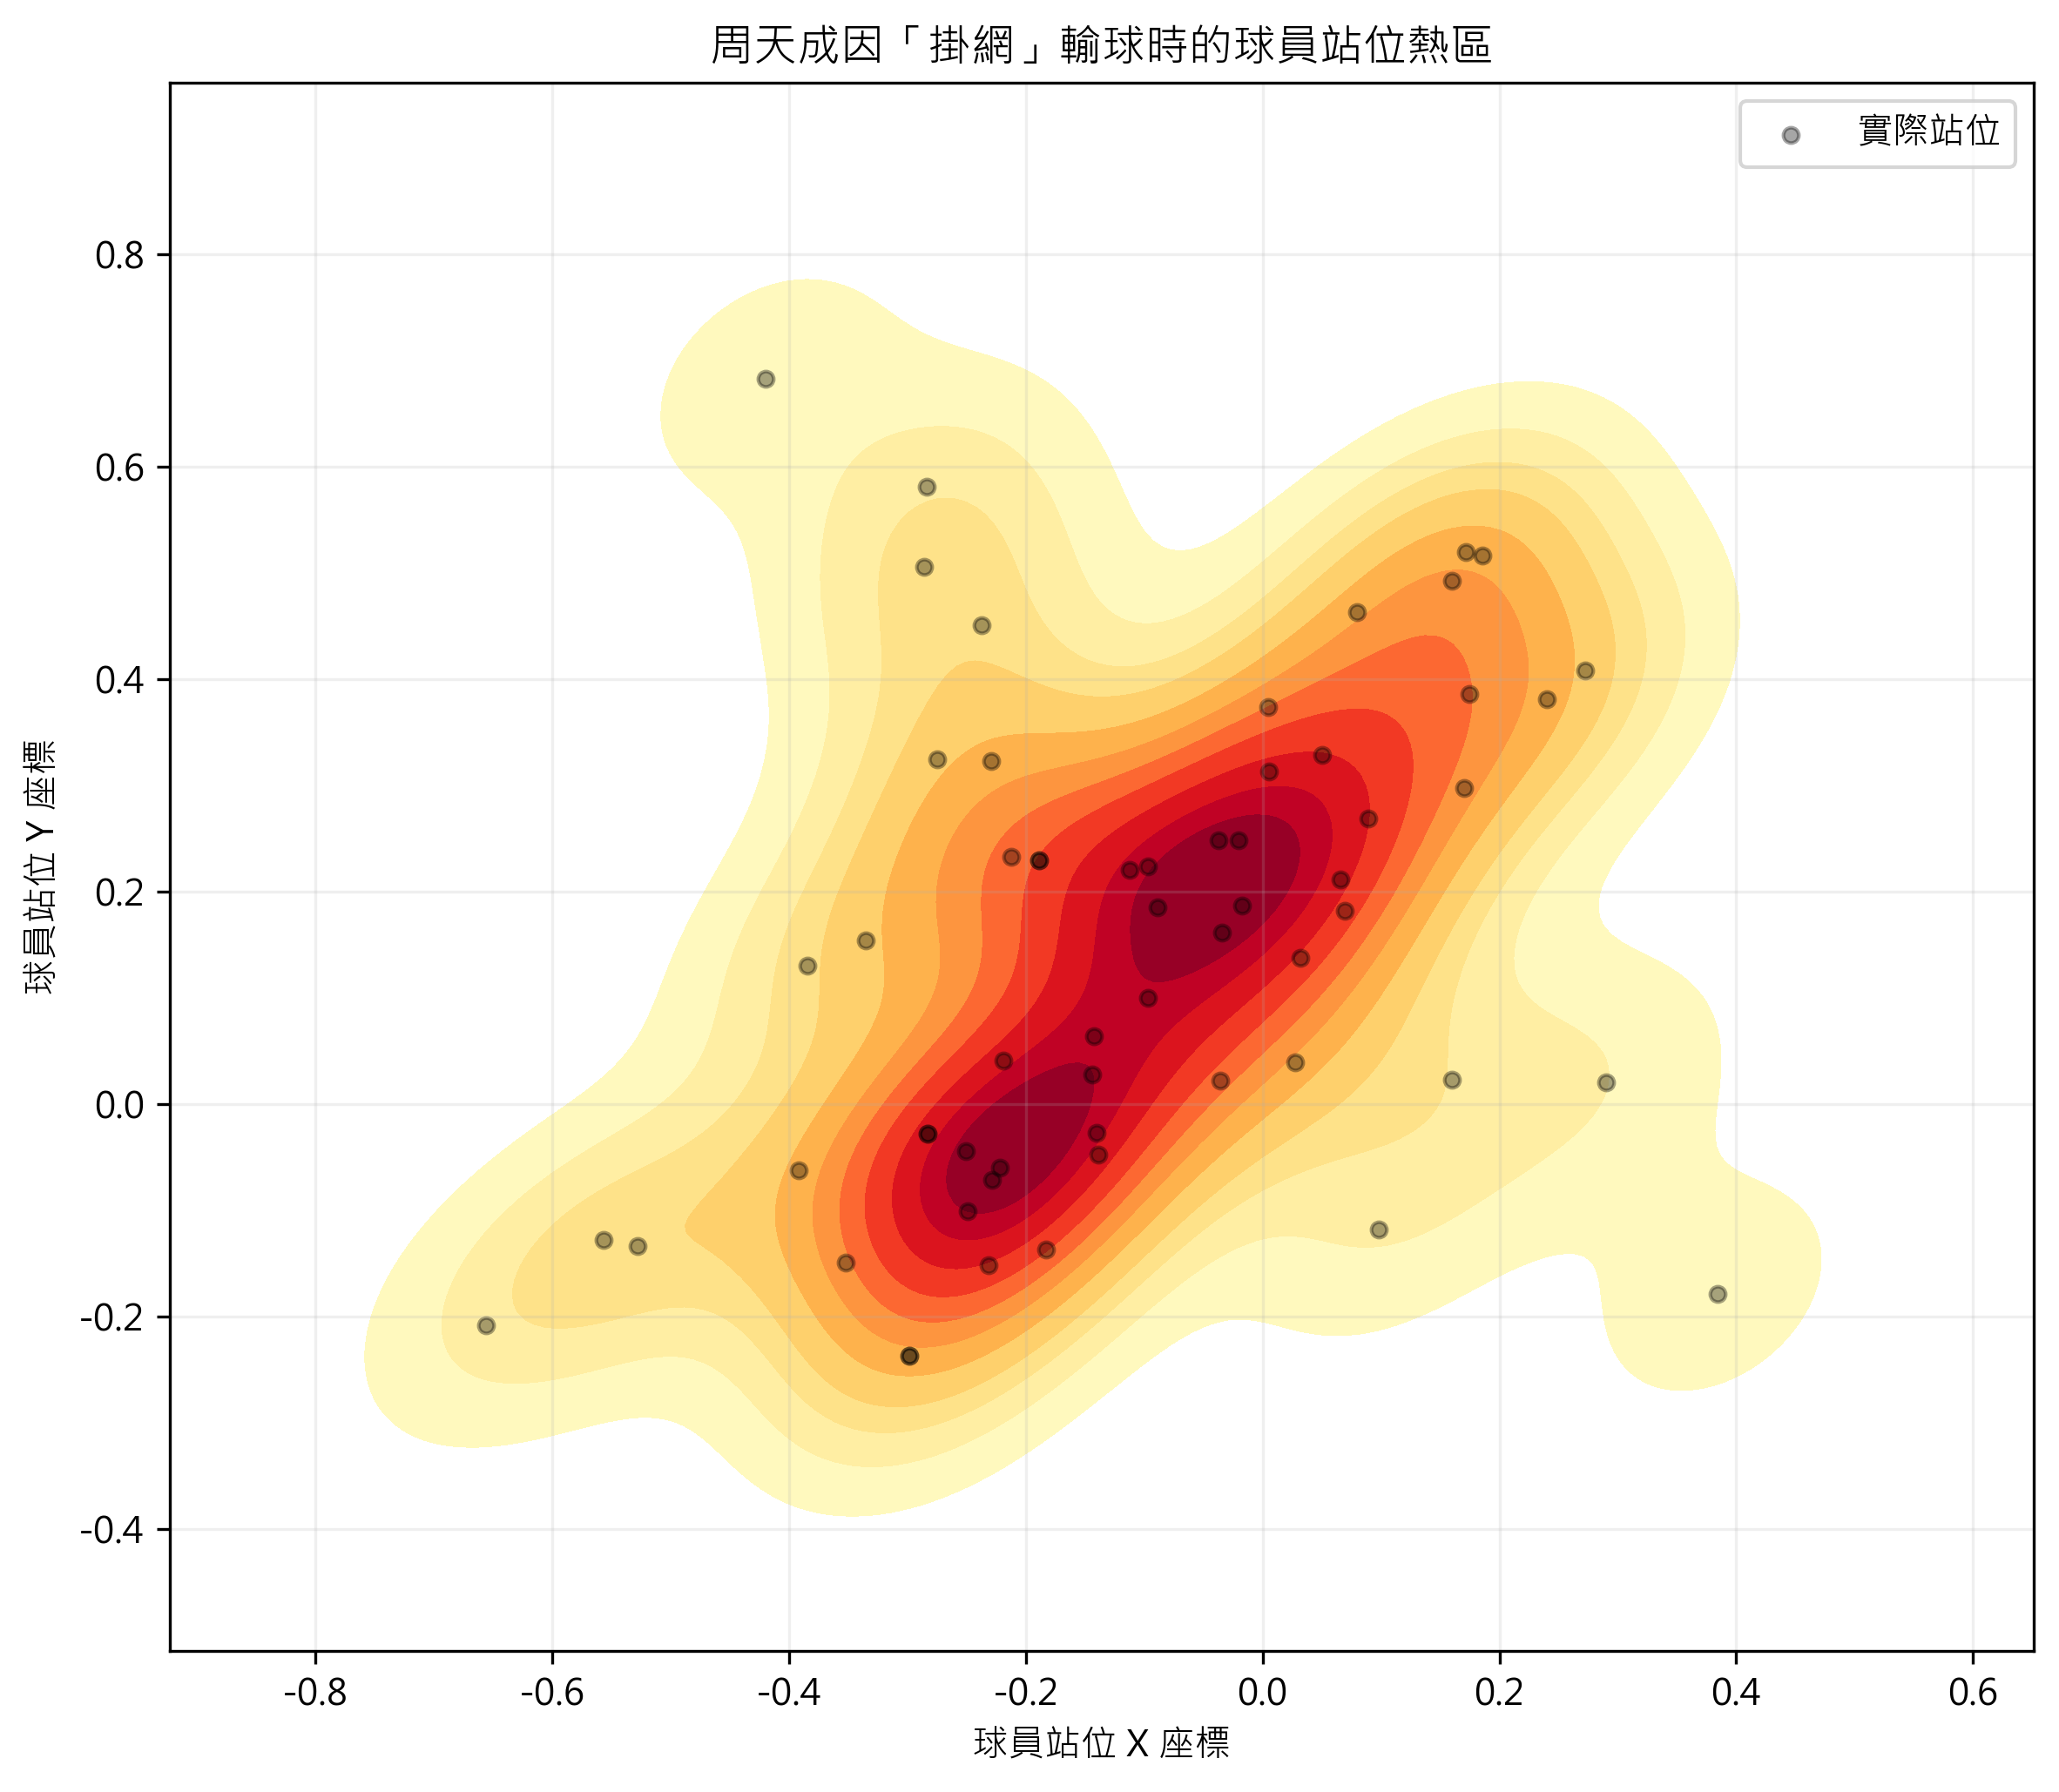

In [ ]:
required_cols = ['player', 'lose_reason', 'player_location_x', 'player_location_y']

if len(df) == 0:
    print('資料為空，無法繪圖。')
elif not set(required_cols).issubset(df.columns):
    print(f'缺少必要欄位：{sorted(set(required_cols) - set(df.columns))}')
else:
    target_player = 'CHOU Tien Chen'

    filtered_df = df[
        (df['player'] == target_player) &
        (df['lose_reason'] == '掛網')
    ][['match_id', 'set', 'rally', 'ball_round',
       'player_location_x', 'player_location_y']].copy()

    filtered_df = filtered_df.dropna(
        subset=['player_location_x', 'player_location_y']
    )

    print(f'周天成因「掛網」輸球的擊球筆數：{len(filtered_df)}')
    print(
        f'涉及回合數：{filtered_df[["match_id", "set", "rally"]].drop_duplicates().shape[0]}'
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    if len(filtered_df) > 0:
        x = filtered_df['player_location_x']
        y = filtered_df['player_location_y']

        if len(filtered_df) >= 2 and x.nunique() > 1 and y.nunique() > 1:
            sns.kdeplot(
                data=filtered_df,
                x='player_location_x',
                y='player_location_y',
                fill=True,
                cmap='YlOrRd',
                levels=12,
                thresh=0.05,
                bw_adjust=0.8,
                ax=ax
            )
        else:
            ax.scatter(
                x, y,
                s=90,
                c='#d94801',
                alpha=0.8,
                label='掛網輸球站位'
            )
            ax.legend()

        ax.scatter(
            x, y,
            s=18,
            c='black',
            alpha=0.35,
            label='實際站位'
        )
        ax.legend()

        ax.set_title('周天成因「掛網」輸球時的球員站位熱區')
        ax.set_xlabel('球員站位 X 座標')
        ax.set_ylabel('球員站位 Y 座標')
        ax.grid(alpha=0.2)
    else:
        ax.text(
            0.5, 0.5,
            '沒有符合條件的資料',
            ha='center',
            va='center',
            fontsize=14
        )
        ax.set_title('周天成因「掛網」輸球時的球員站位熱區')
        ax.set_xlabel('球員站位 X 座標')
        ax.set_ylabel('球員站位 Y 座標')

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 18
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階段中，他自己移動距離的差異。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析口徑：僅納入 player 為周天成的擊球；移動距離 = sqrt(player_move_x² + player_move_y²)。
比分階段依當前列的周天成比分分組，統計單位為每一拍。
      比分階段  擊球拍數  平均移動距離  中位數移動距離  移動距離標準差  最小移動距離  最大移動距離
  開局（0-4分）   673  0.3151   0.3107   0.2093     0.0  0.9869
 中局（5-17分）  1754  0.3244   0.3193   0.2132     0.0  1.1697
關鍵分（18分以上）   182  0.3157   0.3106   0.1967     0.0  0.8459

相對於開局的平均移動距離差異：
      比分階段  平均移動距離  相對開局平均差異
  開局（0-4分）  0.3151    0.0000
 中局（5-17分）  0.3244    0.0093
關鍵分（18分以上）  0.3157    0.0006


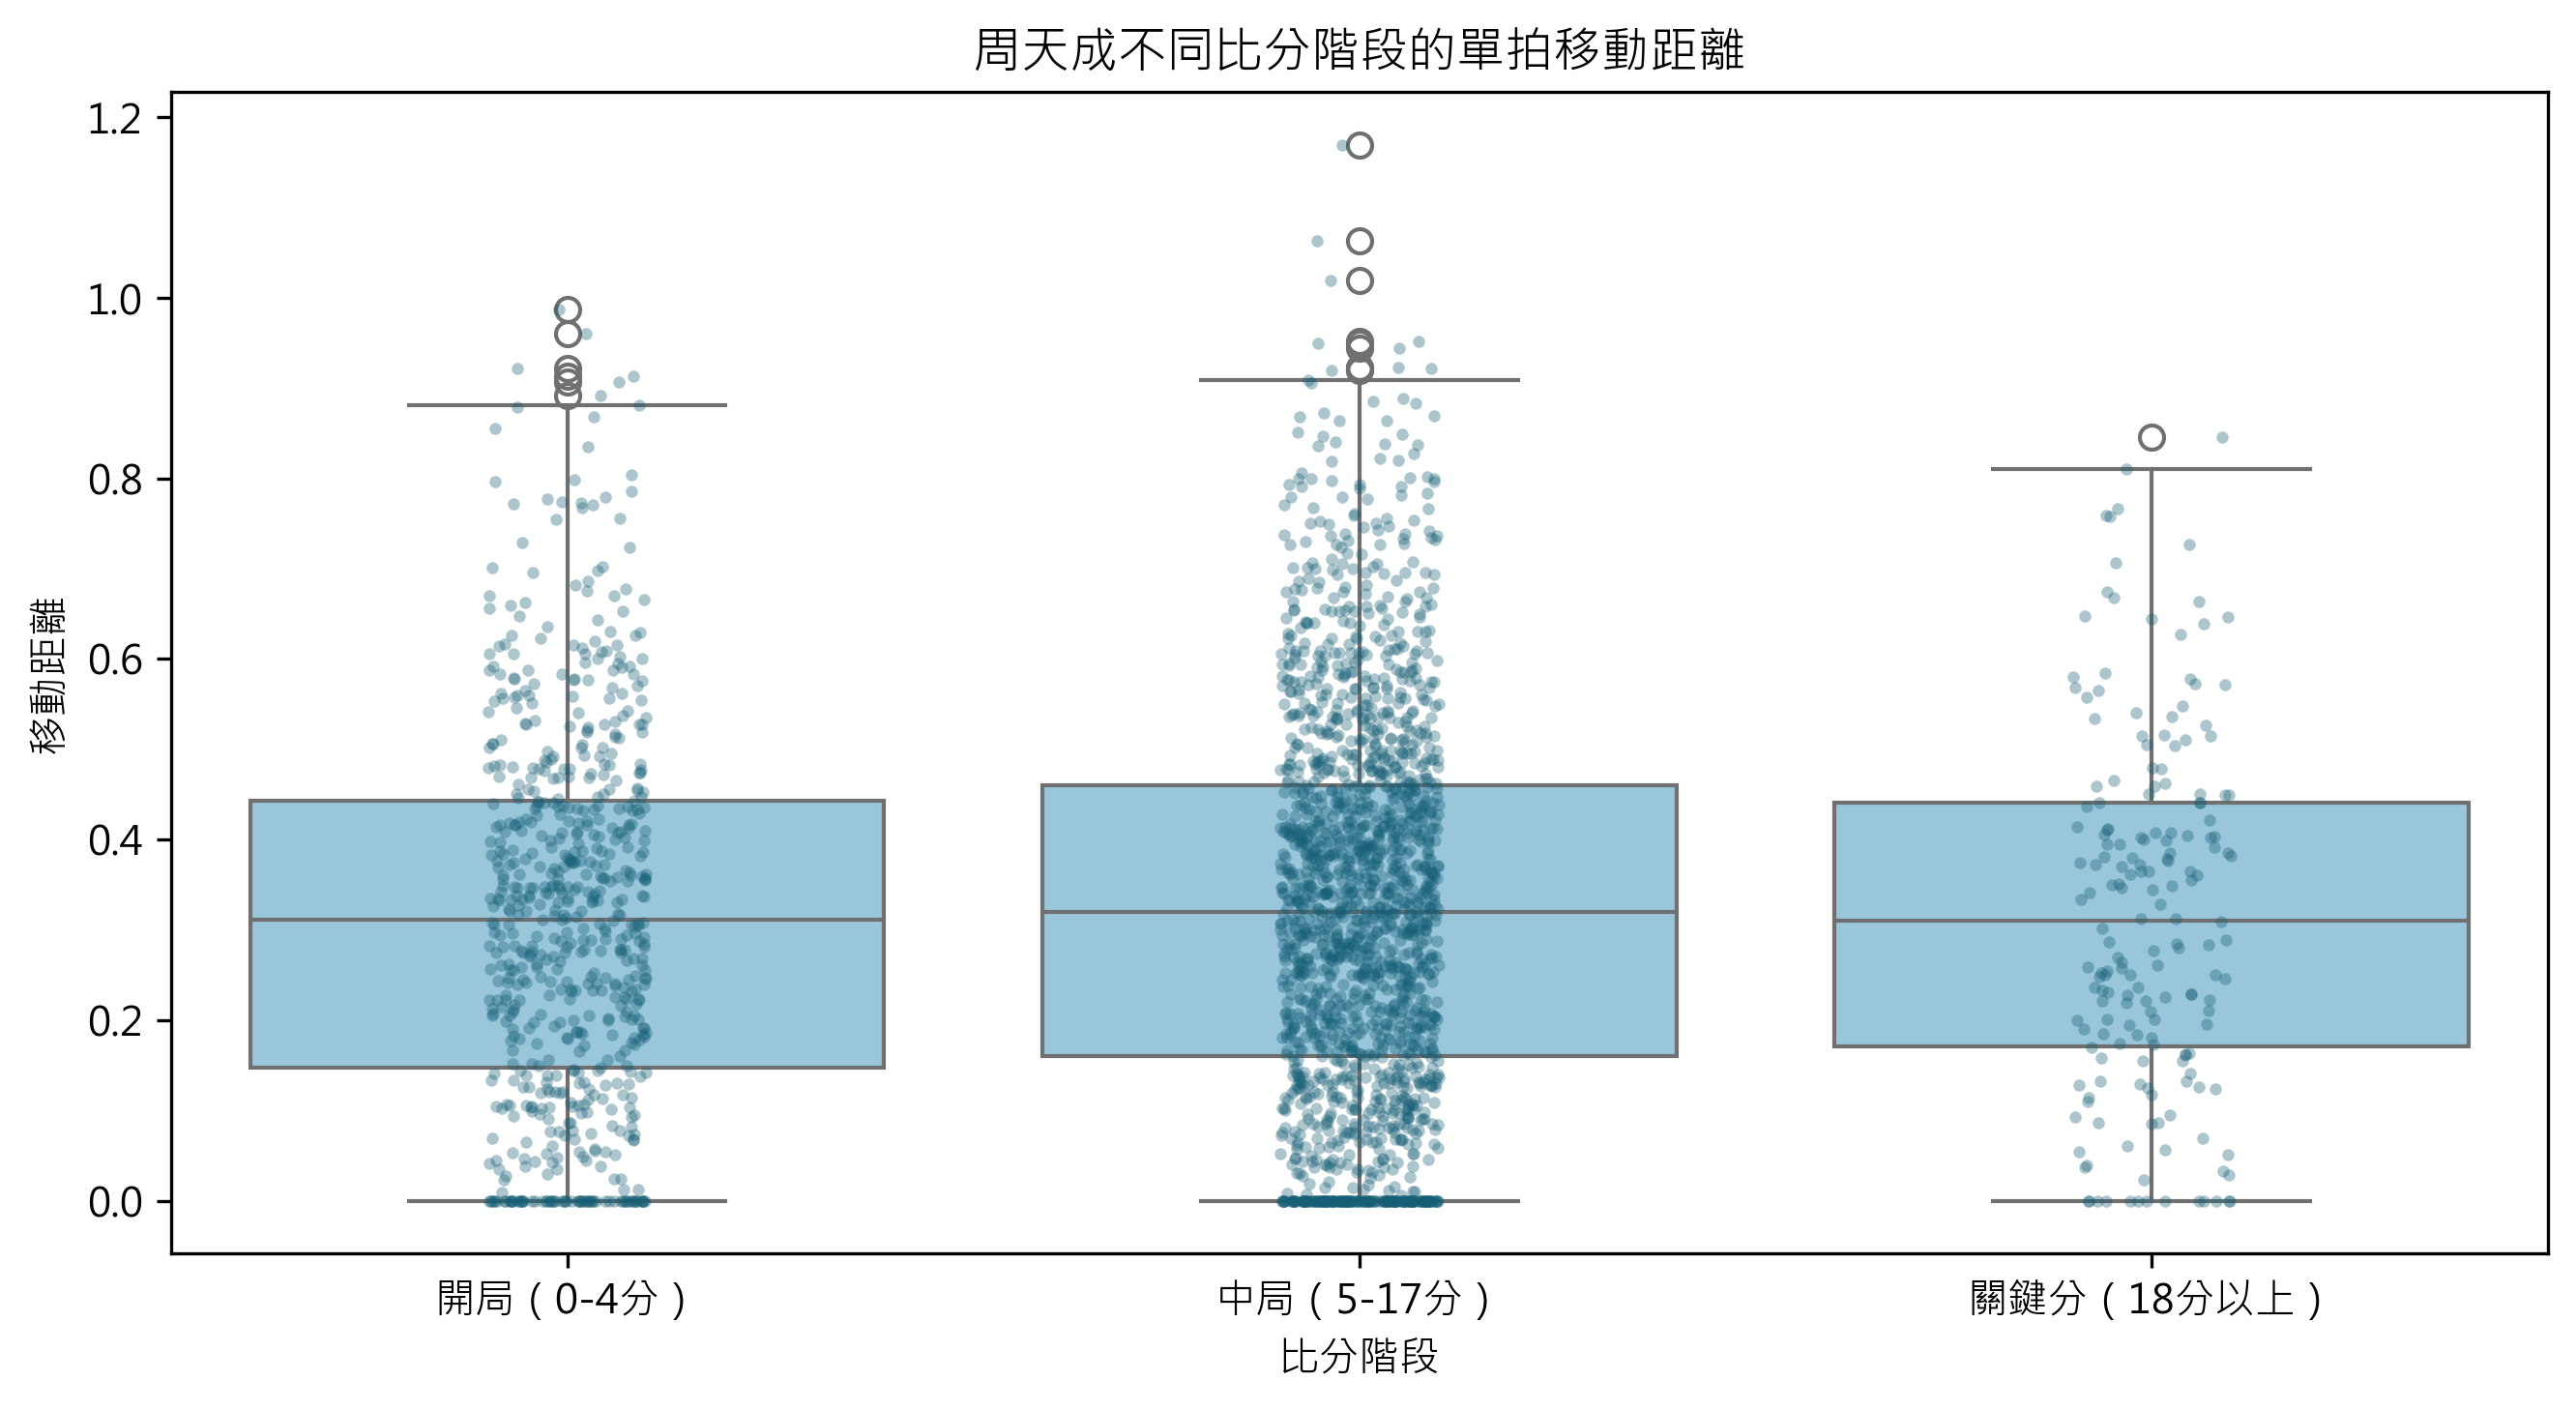

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    player_name = "CHOU Tien Chen"
    score_col = "CHOU Tien Chen_score"
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player",
        score_col, "player_move_x", "player_move_y"
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        analysis_df = df.loc[
            df["player"].eq(player_name),
            required_cols
        ].copy()

        analysis_df[score_col] = pd.to_numeric(
            analysis_df[score_col], errors="coerce"
        )
        analysis_df["player_move_x"] = pd.to_numeric(
            analysis_df["player_move_x"], errors="coerce"
        )
        analysis_df["player_move_y"] = pd.to_numeric(
            analysis_df["player_move_y"], errors="coerce"
        )

        analysis_df = analysis_df.dropna(
            subset=[score_col, "player_move_x", "player_move_y"]
        ).copy()

        if len(analysis_df) == 0:
            print("周天成沒有完整的比分與移動距離資料，無法分析。")
        else:
            analysis_df["移動距離"] = (
                analysis_df["player_move_x"] ** 2
                + analysis_df["player_move_y"] ** 2
            ) ** 0.5

            analysis_df["比分階段"] = pd.cut(
                analysis_df[score_col],
                bins=[-float("inf"), 4, 17, float("inf")],
                labels=["開局（0-4分）", "中局（5-17分）", "關鍵分（18分以上）"],
                right=True
            )

            stage_order = [
                "開局（0-4分）",
                "中局（5-17分）",
                "關鍵分（18分以上）"
            ]

            summary = (
                analysis_df.groupby("比分階段", observed=False)["移動距離"]
                .agg(
                    擊球拍數="count",
                    平均移動距離="mean",
                    中位數移動距離="median",
                    移動距離標準差="std",
                    最小移動距離="min",
                    最大移動距離="max"
                )
                .reindex(stage_order)
                .reset_index()
            )

            summary["平均移動距離"] = summary["平均移動距離"].round(4)
            summary["中位數移動距離"] = summary["中位數移動距離"].round(4)
            summary["移動距離標準差"] = summary["移動距離標準差"].round(4)
            summary["最小移動距離"] = summary["最小移動距離"].round(4)
            summary["最大移動距離"] = summary["最大移動距離"].round(4)

            print("分析口徑：僅納入 player 為周天成的擊球；移動距離 = sqrt(player_move_x² + player_move_y²)。")
            print("比分階段依當前列的周天成比分分組，統計單位為每一拍。")
            print(summary.to_string(index=False))

            valid_summary = summary.dropna(subset=["平均移動距離"]).copy()

            if len(valid_summary) >= 2:
                baseline = valid_summary.iloc[0]["平均移動距離"]
                valid_summary["相對開局平均差異"] = (
                    valid_summary["平均移動距離"] - baseline
                ).round(4)

                print("\n相對於開局的平均移動距離差異：")
                print(
                    valid_summary[
                        ["比分階段", "平均移動距離", "相對開局平均差異"]
                    ].to_string(index=False)
                )

            plot_df = analysis_df.dropna(subset=["比分階段"]).copy()

            if len(plot_df) > 0:
                fig, ax = plt.subplots(figsize=(9, 5))
                sns.boxplot(
                    data=plot_df,
                    x="比分階段",
                    y="移動距離",
                    order=stage_order,
                    color="#8ecae6",
                    ax=ax
                )
                sns.stripplot(
                    data=plot_df,
                    x="比分階段",
                    y="移動距離",
                    order=stage_order,
                    color="#155e75",
                    alpha=0.35,
                    size=3,
                    ax=ax
                )
                ax.set_title("周天成不同比分階段的單拍移動距離")
                ax.set_xlabel("比分階段")
                ax.set_ylabel("移動距離")
                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 22
**問題**: 分析周天成在不同比分階段(開局:0-4分,中局:5-17分,關鍵分:18分以上)中，使用不同球種的頻率變化趨勢
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成各比分階段擊球總數：
比分階段
開局（0-4分）       673
中局（5-17分）     1754
關鍵分（18分以上）     182

各球種使用次數：
比分階段  開局（0-4分）  中局（5-17分）  關鍵分（18分以上）
type                                 
切球          53        141          17
平球          34         64           8
挑球          72        188          10
接殺防守        85        241          25
推撲球         97        214          23
殺球          79        199          21
發短球         37         98          12
發長球          8         25           1
網前球        140        397          45
長球          68        187          20

…（輸出已截斷；notebook 僅保留重點）


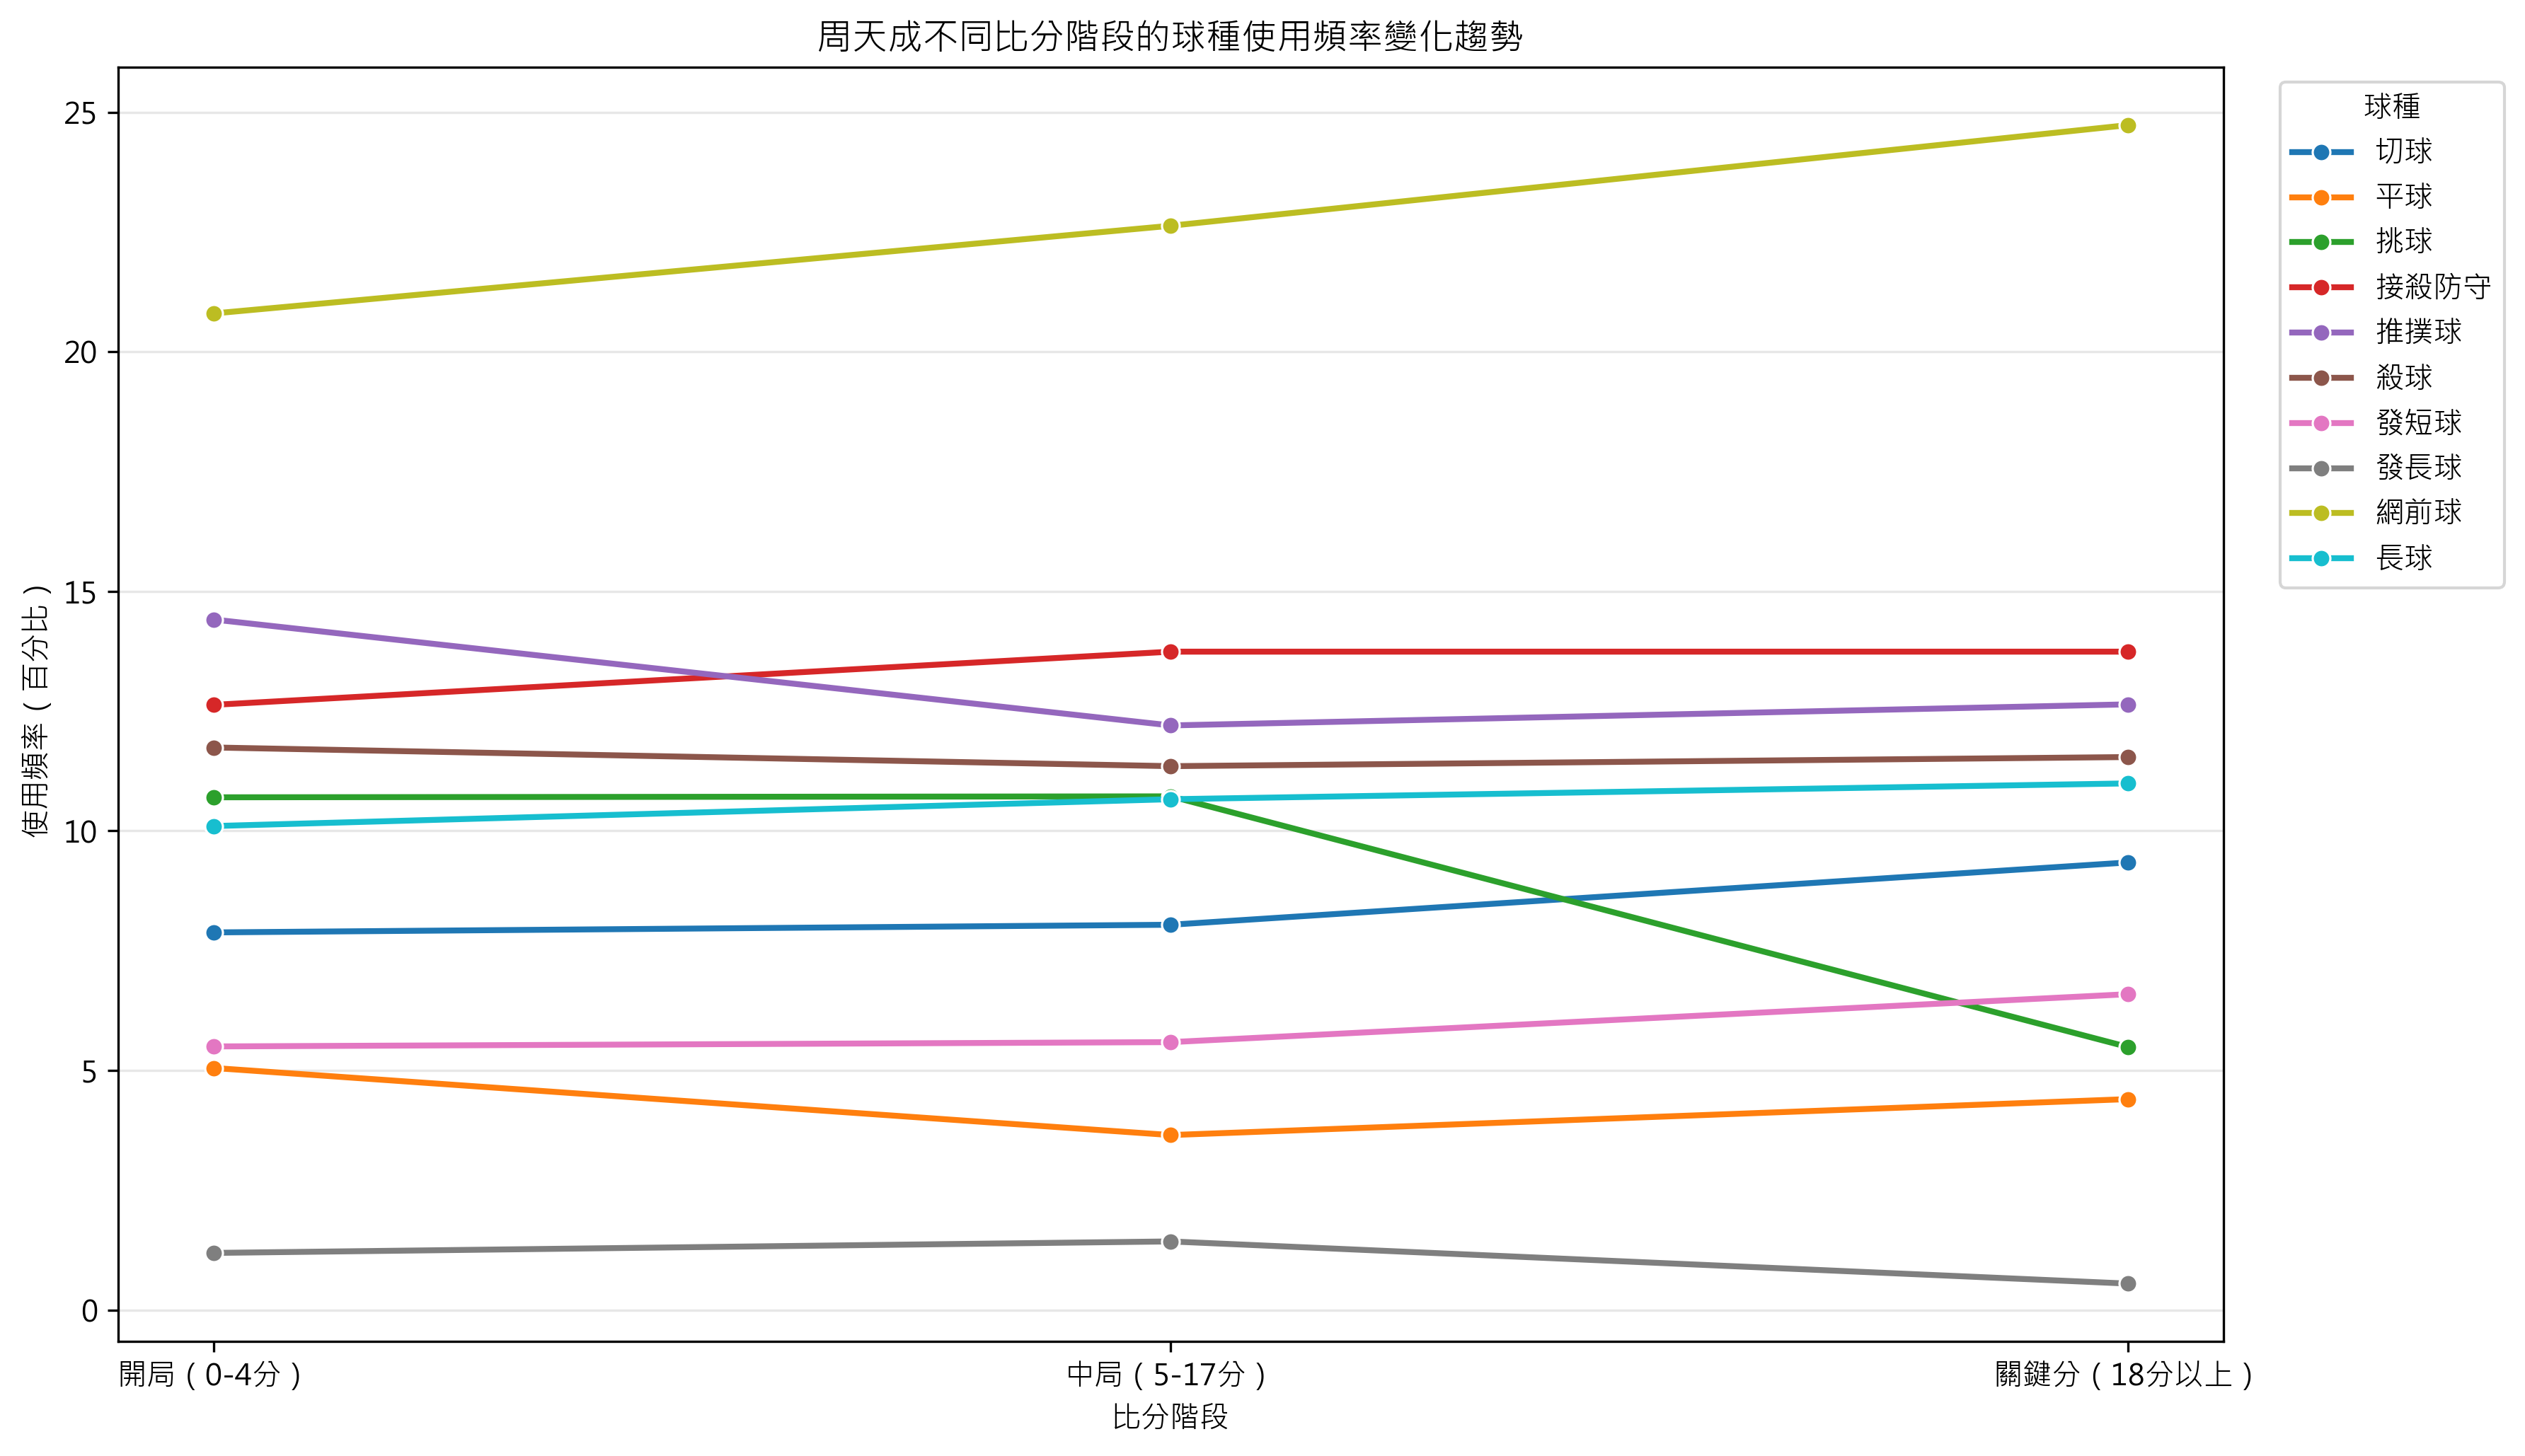

In [ ]:
required_cols = ['player', 'type', 'CHOU Tien Chen_score']

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        chou_df = df.loc[
            df['player'].eq('CHOU Tien Chen')
            & df['CHOU Tien Chen_score'].notna()
            & df['type'].notna(),
            required_cols
        ].copy()

        chou_df['比分階段'] = pd.cut(
            chou_df['CHOU Tien Chen_score'],
            bins=[-float('inf'), 4, 17, float('inf')],
            labels=['開局（0-4分）', '中局（5-17分）', '關鍵分（18分以上）'],
            right=True
        )

        chou_df = chou_df.dropna(subset=['比分階段', 'type'])

        stage_order = ['開局（0-4分）', '中局（5-17分）', '關鍵分（18分以上）']
        shot_order = sorted(chou_df['type'].unique())

        if len(chou_df) == 0:
            print('沒有符合周天成與比分階段條件的資料。')
        else:
            count_table = pd.crosstab(
                chou_df['type'],
                chou_df['比分階段']
            ).reindex(index=shot_order, columns=stage_order, fill_value=0)

            percentage_table = count_table.div(
                count_table.sum(axis=0).replace(0, pd.NA),
                axis=1
            ).mul(100).round(2)

            stage_total = chou_df.groupby('比分階段', observed=False).size().reindex(stage_order, fill_value=0)

            print('周天成各比分階段擊球總數：')
            print(stage_total.to_string())

            print('\n各球種使用次數：')
            print(count_table.to_string())

            print('\n各球種在階段內的使用頻率（百分比）：')
            print(percentage_table.to_string())

            trend_table = percentage_table.reset_index().melt(
                id_vars='type',
                var_name='比分階段',
                value_name='使用頻率（百分比）'
            )

            fig, ax = plt.subplots(figsize=(12, 7))
            sns.lineplot(
                data=trend_table,
                x='比分階段',
                y='使用頻率（百分比）',
                hue='type',
                hue_order=shot_order,
                marker='o',
                linewidth=2,
                ax=ax
            )

            ax.set_title('周天成不同比分階段的球種使用頻率變化趨勢')
            ax.set_xlabel('比分階段')
            ax.set_ylabel('使用頻率（百分比）')
            ax.legend(title='球種', bbox_to_anchor=(1.02, 1), loc='upper left')
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 25
**問題**: 當對手靠球場兩側時，周天成較常讓球落點到哪些區域？繪製熱區圖。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：周天成擊球時，對手站在球場最左欄或最右欄，統計該拍的 landing_area。
符合條件的擊球數：63

落點區域排名：
 landing_area  落點次數  落點比例(%)
           13     6     9.52
           14     6     9.52
           20     6     9.52
           18     5     7.94
           24     5     7.94
           17     4     6.35
           19     4     6.35
            9     3     4.76
           15     3     4.76
           25     3     4.76
            1     2     3.17
           16     2     3.17
           22     2     3.17
           23     2     3.17
           27     2     3.17
…（輸出已截斷；notebook 僅保留重點）


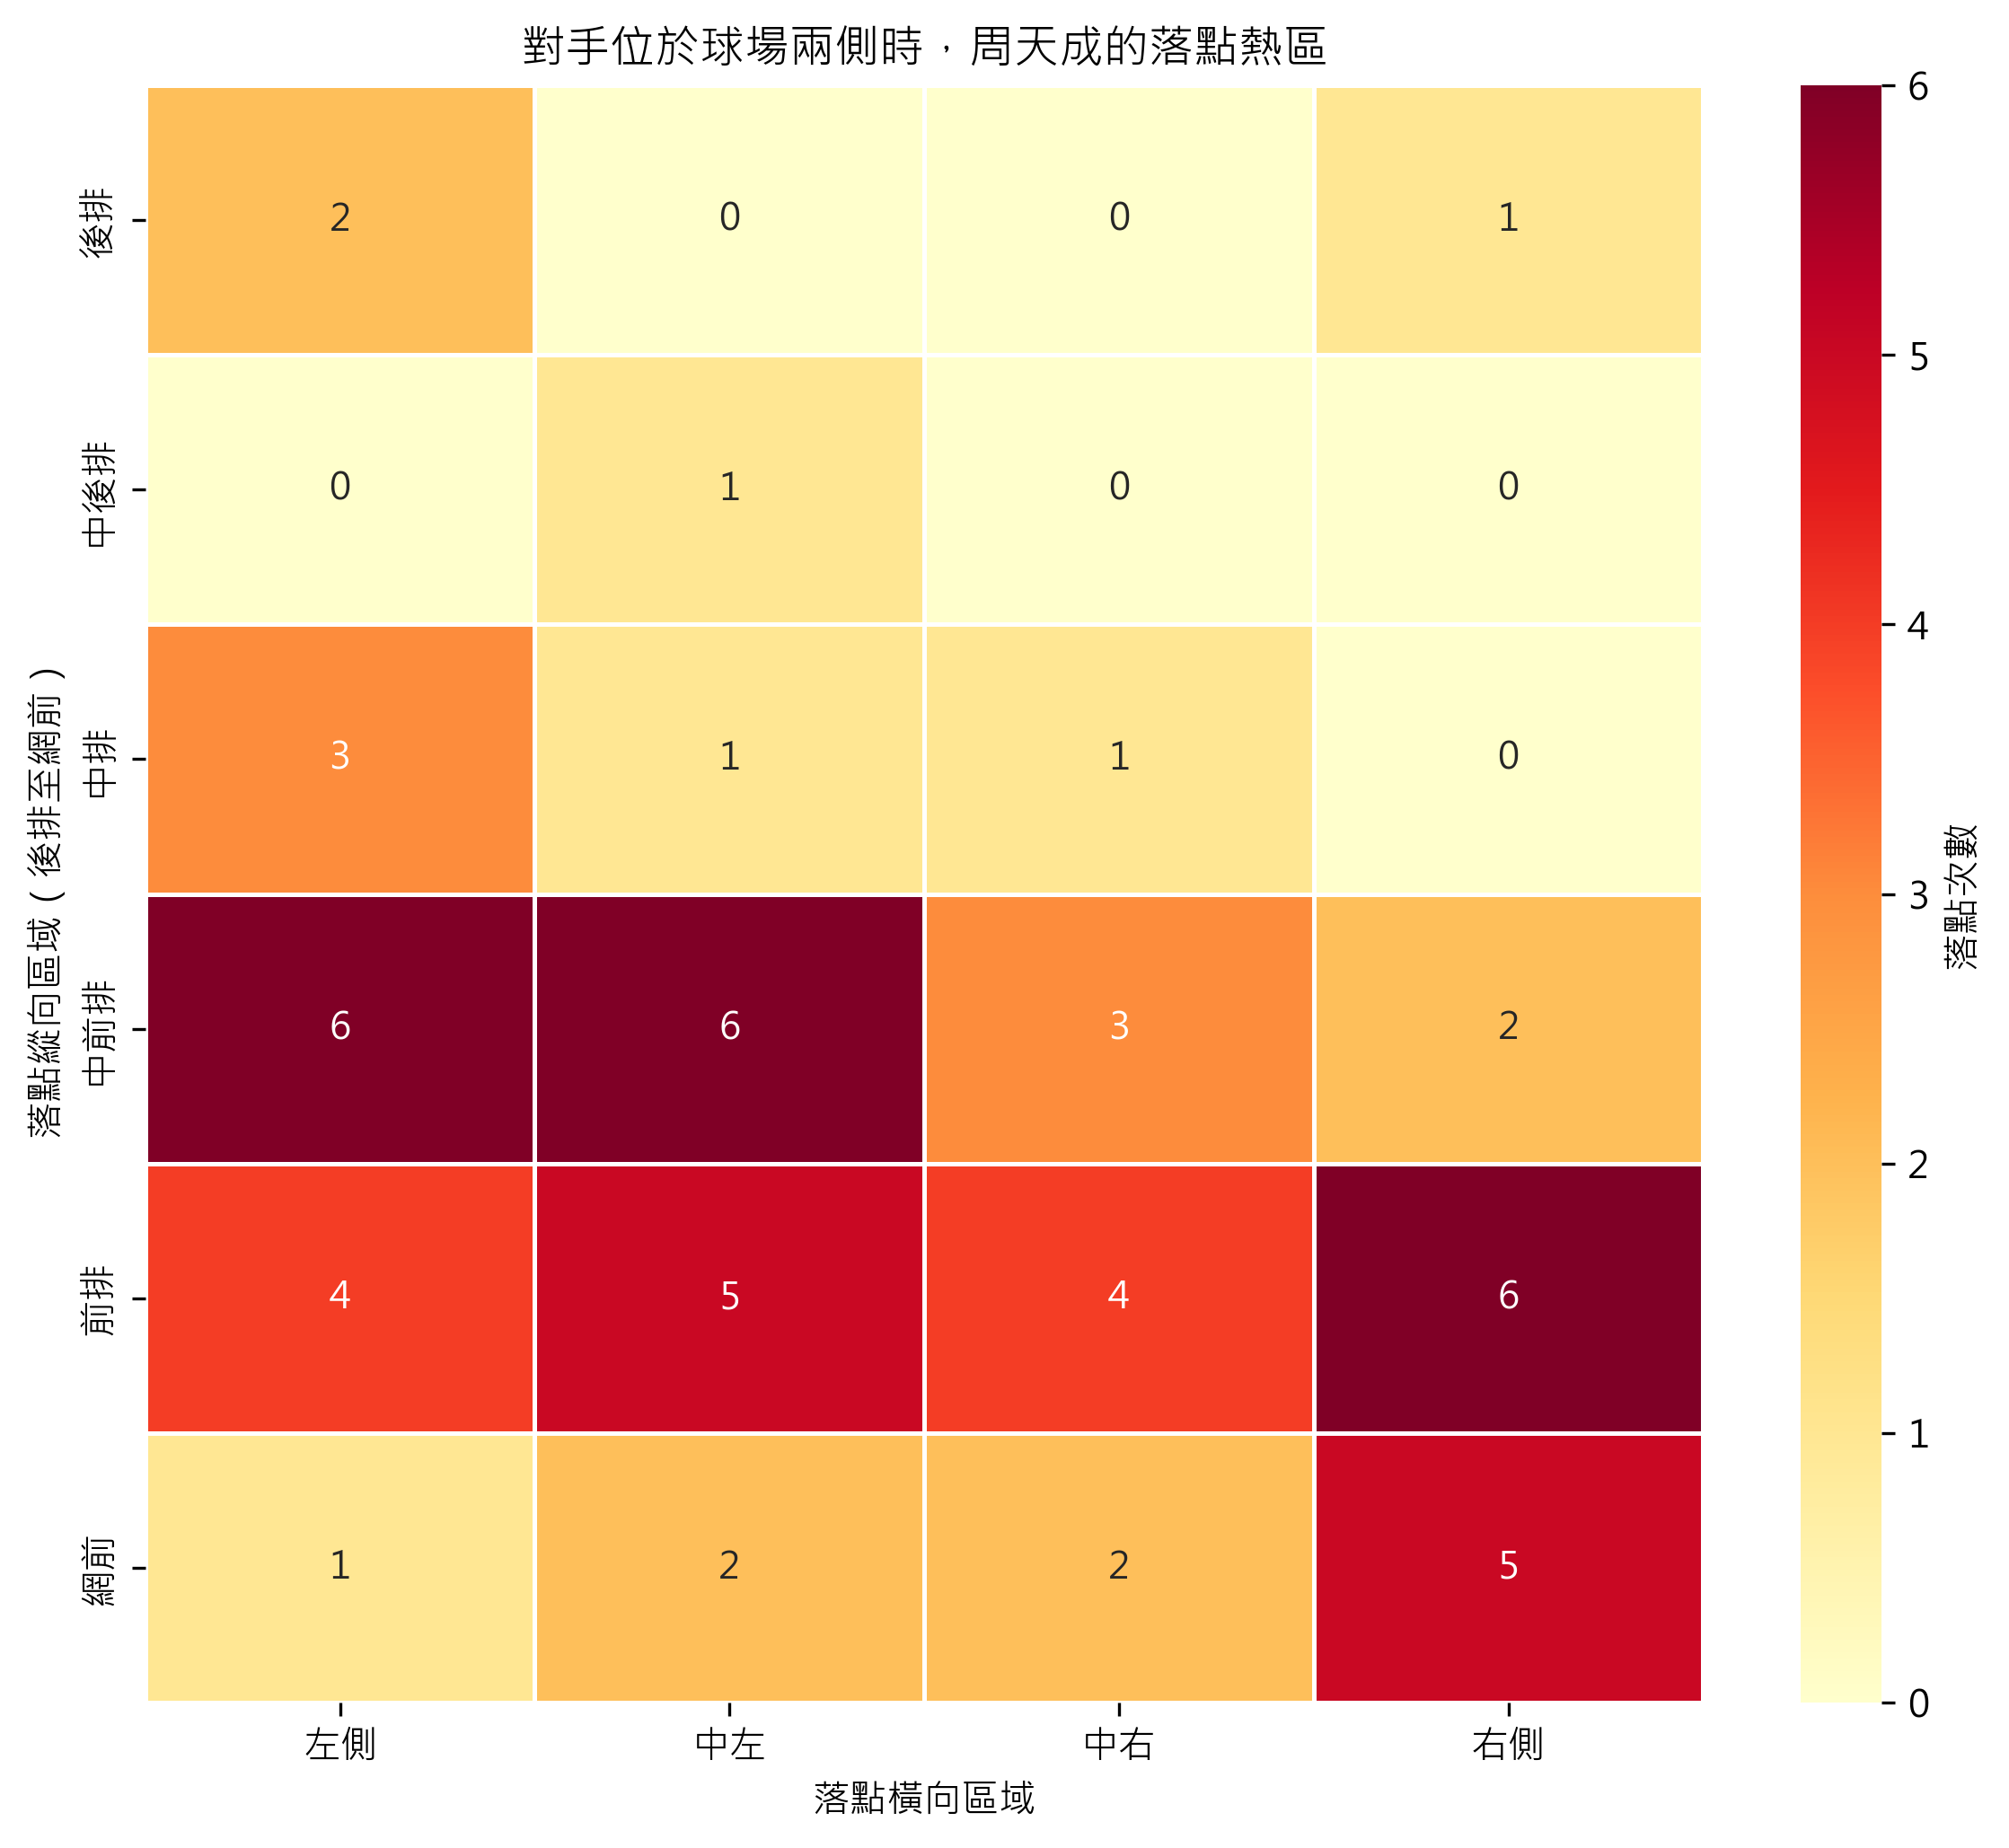

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'opponent_location_area', 'landing_area'
]

if len(df) == 0:
    print('資料為空，無法分析。')
elif not set(required_cols).issubset(df.columns):
    missing_cols = sorted(set(required_cols) - set(df.columns))
    print(f'缺少必要欄位：{missing_cols}')
else:
    target_player = 'CHOU Tien Chen'

    # Court Grid Definitions：
    # 左側欄 A：1, 5, 9, 13, 17, 21
    # 右側欄 D：4, 8, 12, 16, 20, 24
    left_side_zones = {1, 5, 9, 13, 17, 21}
    right_side_zones = {4, 8, 12, 16, 20, 24}
    side_zones = left_side_zones | right_side_zones

    analysis_df = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    # 以當前擊球列的 opponent_location_area 判定對手是否位於球場左右兩側，
    # 並只分析周天成當前擊出的球及其落點。
    filtered_df = analysis_df[
        (analysis_df['player'] == target_player) &
        (analysis_df['opponent_location_area'].isin(side_zones))
    ].copy()

    filtered_df = filtered_df.dropna(
        subset=['opponent_location_area', 'landing_area']
    )

    if len(filtered_df) == 0:
        print('沒有符合「周天成擊球且對手位於球場左右側」的有效落點資料。')
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_title('無符合條件的落點資料')
        ax.axis('off')
        plt.tight_layout()
    else:
        filtered_df['opponent_side'] = filtered_df[
            'opponent_location_area'
        ].map(
            lambda zone: '左側' if int(zone) in left_side_zones else '右側'
        )
        filtered_df['landing_area'] = filtered_df['landing_area'].astype(int)

        landing_summary = (
            filtered_df
            .groupby(['landing_area'], as_index=False)
            .size()
            .rename(columns={'size': '落點次數'})
            .sort_values(
                ['落點次數', 'landing_area'],
                ascending=[False, True]
            )
        )
        landing_summary['落點比例(%)'] = (
            landing_summary['落點次數'] / landing_summary['落點次數'].sum() * 100
        ).round(2)

        print('統計口徑：周天成擊球時，對手站在球場最左欄或最右欄，統計該拍的 landing_area。')
        print(f'符合條件的擊球數：{len(filtered_df)}')
        print('\n落點區域排名：')
        print(landing_summary.to_string(index=False))

        side_summary = (
            filtered_df
            .groupby(['opponent_side', 'landing_area'], as_index=False)
            .size()
            .rename(columns={'size': '落點次數'})
        )
        side_summary['落點比例(%)'] = (
            side_summary
            .groupby('opponent_side')['落點次數']
            .transform(lambda values: values / values.sum() * 100)
            .round(2)
        )

        print('\n依對手所在側的落點排名：')
        for side in ['左側', '右側']:
            side_table = (
                side_summary[side_summary['opponent_side'] == side]
                .sort_values(
                    ['落點次數', 'landing_area'],
                    ascending=[False, True]
                )
            )
            print(f'\n對手在{side}：')
            print(side_table.to_string(index=False))

        # 1-24 為場內六排四欄區域：
        # Row 1（後排）1-4，Row 2 5-8，...，Row 6（前排）21-24。
        in_court_df = filtered_df[
            filtered_df['landing_area'].between(1, 24)
        ].copy()

        heatmap_counts = pd.DataFrame(
            0,
            index=['後排', '中後排', '中排', '中前排', '前排', '網前'],
            columns=['左側', '中左', '中右', '右側']
        )

        for zone in range(1, 25):
            row_index = (zone - 1) // 4
            col_index = (zone - 1) % 4
            row_label = heatmap_counts.index[row_index]
            col_label = heatmap_counts.columns[col_index]
            heatmap_counts.loc[row_label, col_label] = int(
                (in_court_df['landing_area'] == zone).sum()
            )

        fig, ax = plt.subplots(figsize=(8, 7))
        sns.heatmap(
            heatmap_counts,
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            linewidths=0.8,
            linecolor='white',
            cbar_kws={'label': '落點次數'},
            ax=ax
        )
        ax.set_title('對手位於球場兩側時，周天成的落點熱區')
        ax.set_xlabel('落點橫向區域')
        ax.set_ylabel('落點縱向區域（後排至網前）')
        plt.tight_layout()

        out_of_court = filtered_df[
            ~filtered_df['landing_area'].between(1, 24)
        ]

        if len(out_of_court) > 0:
            out_summary = (
                out_of_court
                .groupby('landing_area', as_index=False)
                .size()
                .rename(columns={'size': '落點次數'})
                .sort_values(
                    ['落點次數', 'landing_area'],
                    ascending=[False, True]
                )
            )
            print('\n場外落點區域（未納入場內熱區圖）：')
            print(out_summary.to_string(index=False))


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 30
**問題**: 周天成在比賽後段（第 2、3 局）移動距離與失誤率的關聯分析。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
- 分析範圍：第 2、3 局，統計單位為 (match_id, set, rally) 的回合
- 移動距離：CHOU Tien Chen 該回合每拍 √(player_move_x² + player_move_y²) 的總和
- 失誤：最後一拍擊球者為 CHOU Tien Chen，且 getpoint_player 為 Kento MOMOTA

總回合數：244，失誤回合數：88，失誤率：36.07%
總回合移動距離與失誤的相關係數：-0.0537
每拍平均移動距離與失誤的相關係數：-0.2700

分局統計：
 set  回合數  失誤回合數  平均回合移動距離  平均每拍移動距離    失誤率
   2  146     46    1.8606    0.2840 0.3151
   3   98     42    2.2165    0.3017 0.4286

分局相關係數：
 set  總移動距離相關係數  每拍平均移動距離相關係數
   2    -0.0268       -0.2767
   3    -0.1196       -0.2911

依移動距離四分位數分組：
…（輸出已截斷；notebook 僅保留重點）


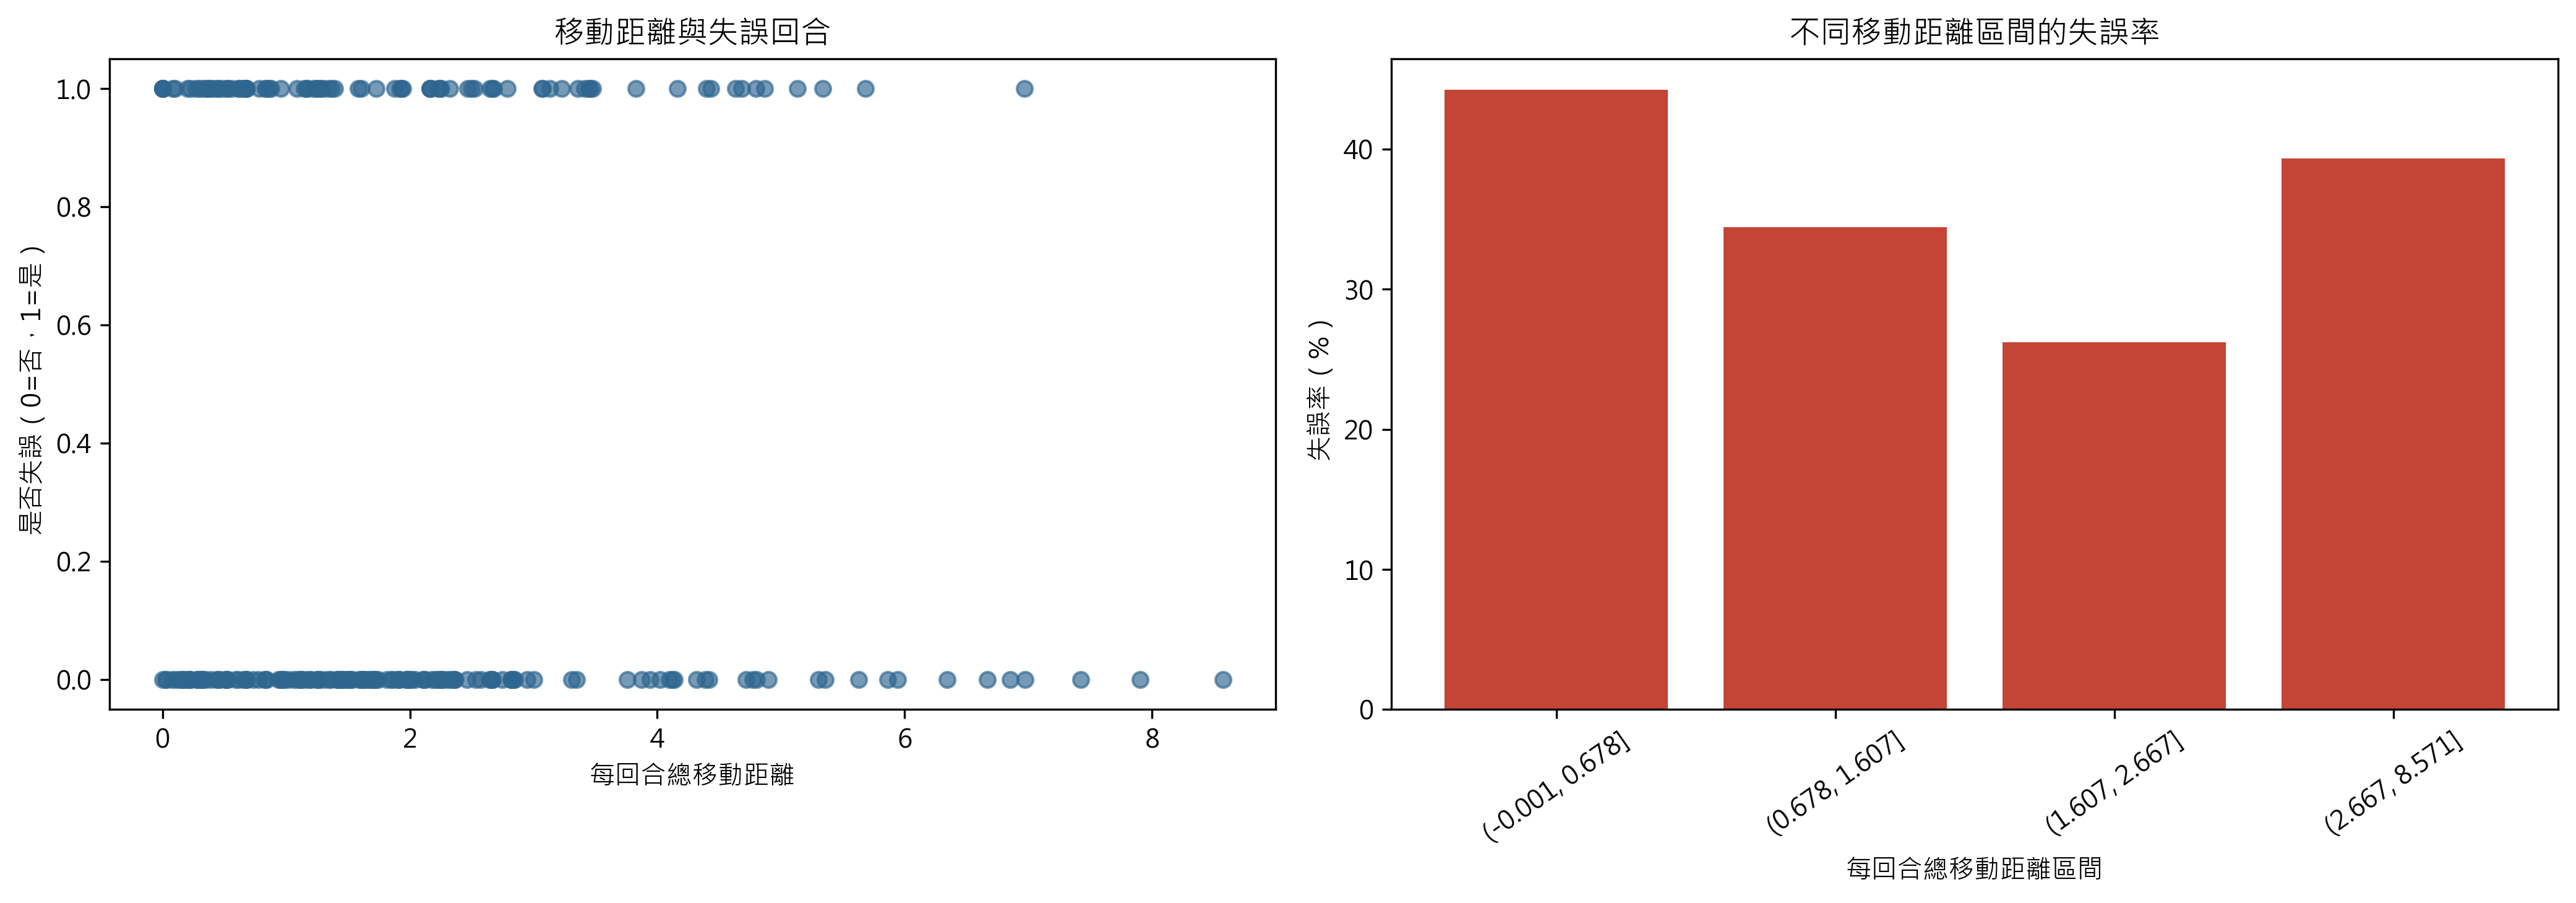

In [ ]:
import numpy as np

target_player = 'CHOU Tien Chen'
opponent_player = 'Kento MOMOTA'
group_cols = ['match_id', 'set', 'rally']
required_cols = group_cols + [
    'player', 'getpoint_player', 'player_move_x', 'player_move_y'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(df) == 0:
    print('資料為空，無法進行分析。')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        relevant_df = df.loc[
            df['set'].isin([2, 3]),
            required_cols
        ].copy()

        if len(relevant_df) == 0:
            print('第 2、3 局沒有可分析資料。')
        else:
            relevant_df['player_move_x'] = pd.to_numeric(
                relevant_df['player_move_x'], errors='coerce'
            )
            relevant_df['player_move_y'] = pd.to_numeric(
                relevant_df['player_move_y'], errors='coerce'
            )

            movement_df = relevant_df.loc[
                relevant_df['player'].eq(target_player)
            ].dropna(
                subset=['match_id', 'set', 'rally',
                        'player_move_x', 'player_move_y']
            ).copy()

            if len(movement_df) == 0:
                print(f'第 2、3 局沒有 {target_player} 的有效移動資料。')
            else:
                movement_df['shot_movement_distance'] = np.sqrt(
                    movement_df['player_move_x'].pow(2)
                    + movement_df['player_move_y'].pow(2)
                )

                rally_movement = (
                    movement_df
                    .groupby(group_cols, as_index=False)
                    .agg(
                        movement_distance=(
                            'shot_movement_distance', 'sum'
                        ),
                        chou_shot_count=('player', 'size')
                    )
                )

                rally_errors = relevant_df.assign(
                    chou_error=(
                        relevant_df['player'].eq(target_player)
                        & relevant_df['getpoint_player'].eq(opponent_player)
                    )
                )

                rally_errors = (
                    rally_errors
                    .groupby(group_cols, as_index=False)
                    .agg(chou_error=('chou_error', 'max'))
                )

                analysis_df = rally_movement.merge(
                    rally_errors,
                    on=group_cols,
                    how='left'
                )

                analysis_df['chou_error'] = (
                    analysis_df['chou_error']
                    .fillna(False)
                    .astype(int)
                )
                analysis_df['avg_movement_per_shot'] = (
                    analysis_df['movement_distance']
                    / analysis_df['chou_shot_count']
                )

                total_rallies = len(analysis_df)
                total_errors = int(analysis_df['chou_error'].sum())
                overall_error_rate = total_errors / total_rallies

                total_corr = analysis_df[
                    ['movement_distance', 'chou_error']
                ].corr().loc['movement_distance', 'chou_error']

                avg_corr = analysis_df[
                    ['avg_movement_per_shot', 'chou_error']
                ].corr().loc[
                    'avg_movement_per_shot', 'chou_error'
                ]

                print('統計口徑：')
                print(
                    f'- 分析範圍：第 2、3 局，統計單位為 '
                    f'({", ".join(group_cols)}) 的回合'
                )
                print(
                    f'- 移動距離：{target_player} 該回合每拍 '
                    f'√(player_move_x² + player_move_y²) 的總和'
                )
                print(
                    f'- 失誤：最後一拍擊球者為 {target_player}，且 '
                    f'getpoint_player 為 {opponent_player}'
                )
                print(
                    f'\n總回合數：{total_rallies}，'
                    f'失誤回合數：{total_errors}，'
                    f'失誤率：{overall_error_rate:.2%}'
                )
                print(
                    f'總回合移動距離與失誤的相關係數：{total_corr:.4f}'
                )
                print(
                    f'每拍平均移動距離與失誤的相關係數：{avg_corr:.4f}'
                )

                set_summary = (
                    analysis_df
                    .groupby('set', as_index=False)
                    .agg(
                        回合數=('chou_error', 'size'),
                        失誤回合數=('chou_error', 'sum'),
                        平均回合移動距離=(
                            'movement_distance', 'mean'
                        ),
                        平均每拍移動距離=(
                            'avg_movement_per_shot', 'mean'
                        )
                    )
                )
                set_summary['失誤率'] = (
                    set_summary['失誤回合數']
                    / set_summary['回合數']
                )

                set_corr = (
                    analysis_df
                    .groupby('set')
                    .apply(
                        lambda g: pd.Series({
                            '總移動距離相關係數': g[
                                ['movement_distance', 'chou_error']
                            ].corr().loc[
                                'movement_distance', 'chou_error'
                            ],
                            '每拍平均移動距離相關係數': g[
                                ['avg_movement_per_shot', 'chou_error']
                            ].corr().loc[
                                'avg_movement_per_shot', 'chou_error'
                            ]
                        }),
                        include_groups=False
                    )
                    .reset_index()
                )

                print('\n分局統計：')
                print(set_summary.to_string(index=False, float_format='%.4f'))
                print('\n分局相關係數：')
                print(set_corr.to_string(index=False, float_format='%.4f'))

                if len(analysis_df) > 0:
                    axes[0].scatter(
                        analysis_df['movement_distance'],
                        analysis_df['chou_error'],
                        alpha=0.65,
                        color='#2F6690'
                    )
                    axes[0].set_xlabel('每回合總移動距離')
                    axes[0].set_ylabel('是否失誤（0=否，1=是）')
                    axes[0].set_title('移動距離與失誤回合')

                    if analysis_df['movement_distance'].nunique() >= 2:
                        analysis_df['移動距離區間'] = pd.qcut(
                            analysis_df['movement_distance'],
                            q=4,
                            duplicates='drop'
                        ).astype(str)

                        bin_summary = (
                            analysis_df
                            .groupby(
                                '移動距離區間',
                                sort=False,
                                as_index=False
                            )
                            .agg(
                                回合數=('chou_error', 'size'),
                                失誤回合數=('chou_error', 'sum'),
                                失誤率=('chou_error', 'mean')
                            )
                        )

                        print('\n依移動距離四分位數分組：')
                        print(
                            bin_summary.to_string(
                                index=False,
                                float_format='%.2f'
                            )
                        )

                        axes[1].bar(
                            bin_summary['移動距離區間'],
                            bin_summary['失誤率'] * 100,
                            color='#C44536'
                        )
                        axes[1].set_xlabel('每回合總移動距離區間')
                        axes[1].set_ylabel('失誤率（%）')
                        axes[1].set_title('不同移動距離區間的失誤率')
                        axes[1].tick_params(
                            axis='x',
                            rotation=35
                        )
                    else:
                        axes[1].text(
                            0.5, 0.5,
                            '移動距離變異不足，無法分組',
                            ha='center',
                            va='center'
                        )
                        axes[1].set_axis_off()

plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 31
**問題**: 分析周天成使用殺球，對手都用什麼球種反擊，繪製圓餅圖
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成使用殺球後，對手下一拍的反擊球種統計：
對手反擊球種  次數    比例
  接殺防守 174 79.82
   網前球  38 17.43
    平球   3  1.38
   推撲球   1  0.46
    挑球   1  0.46
    切球   1  0.46

有效反擊拍數：218


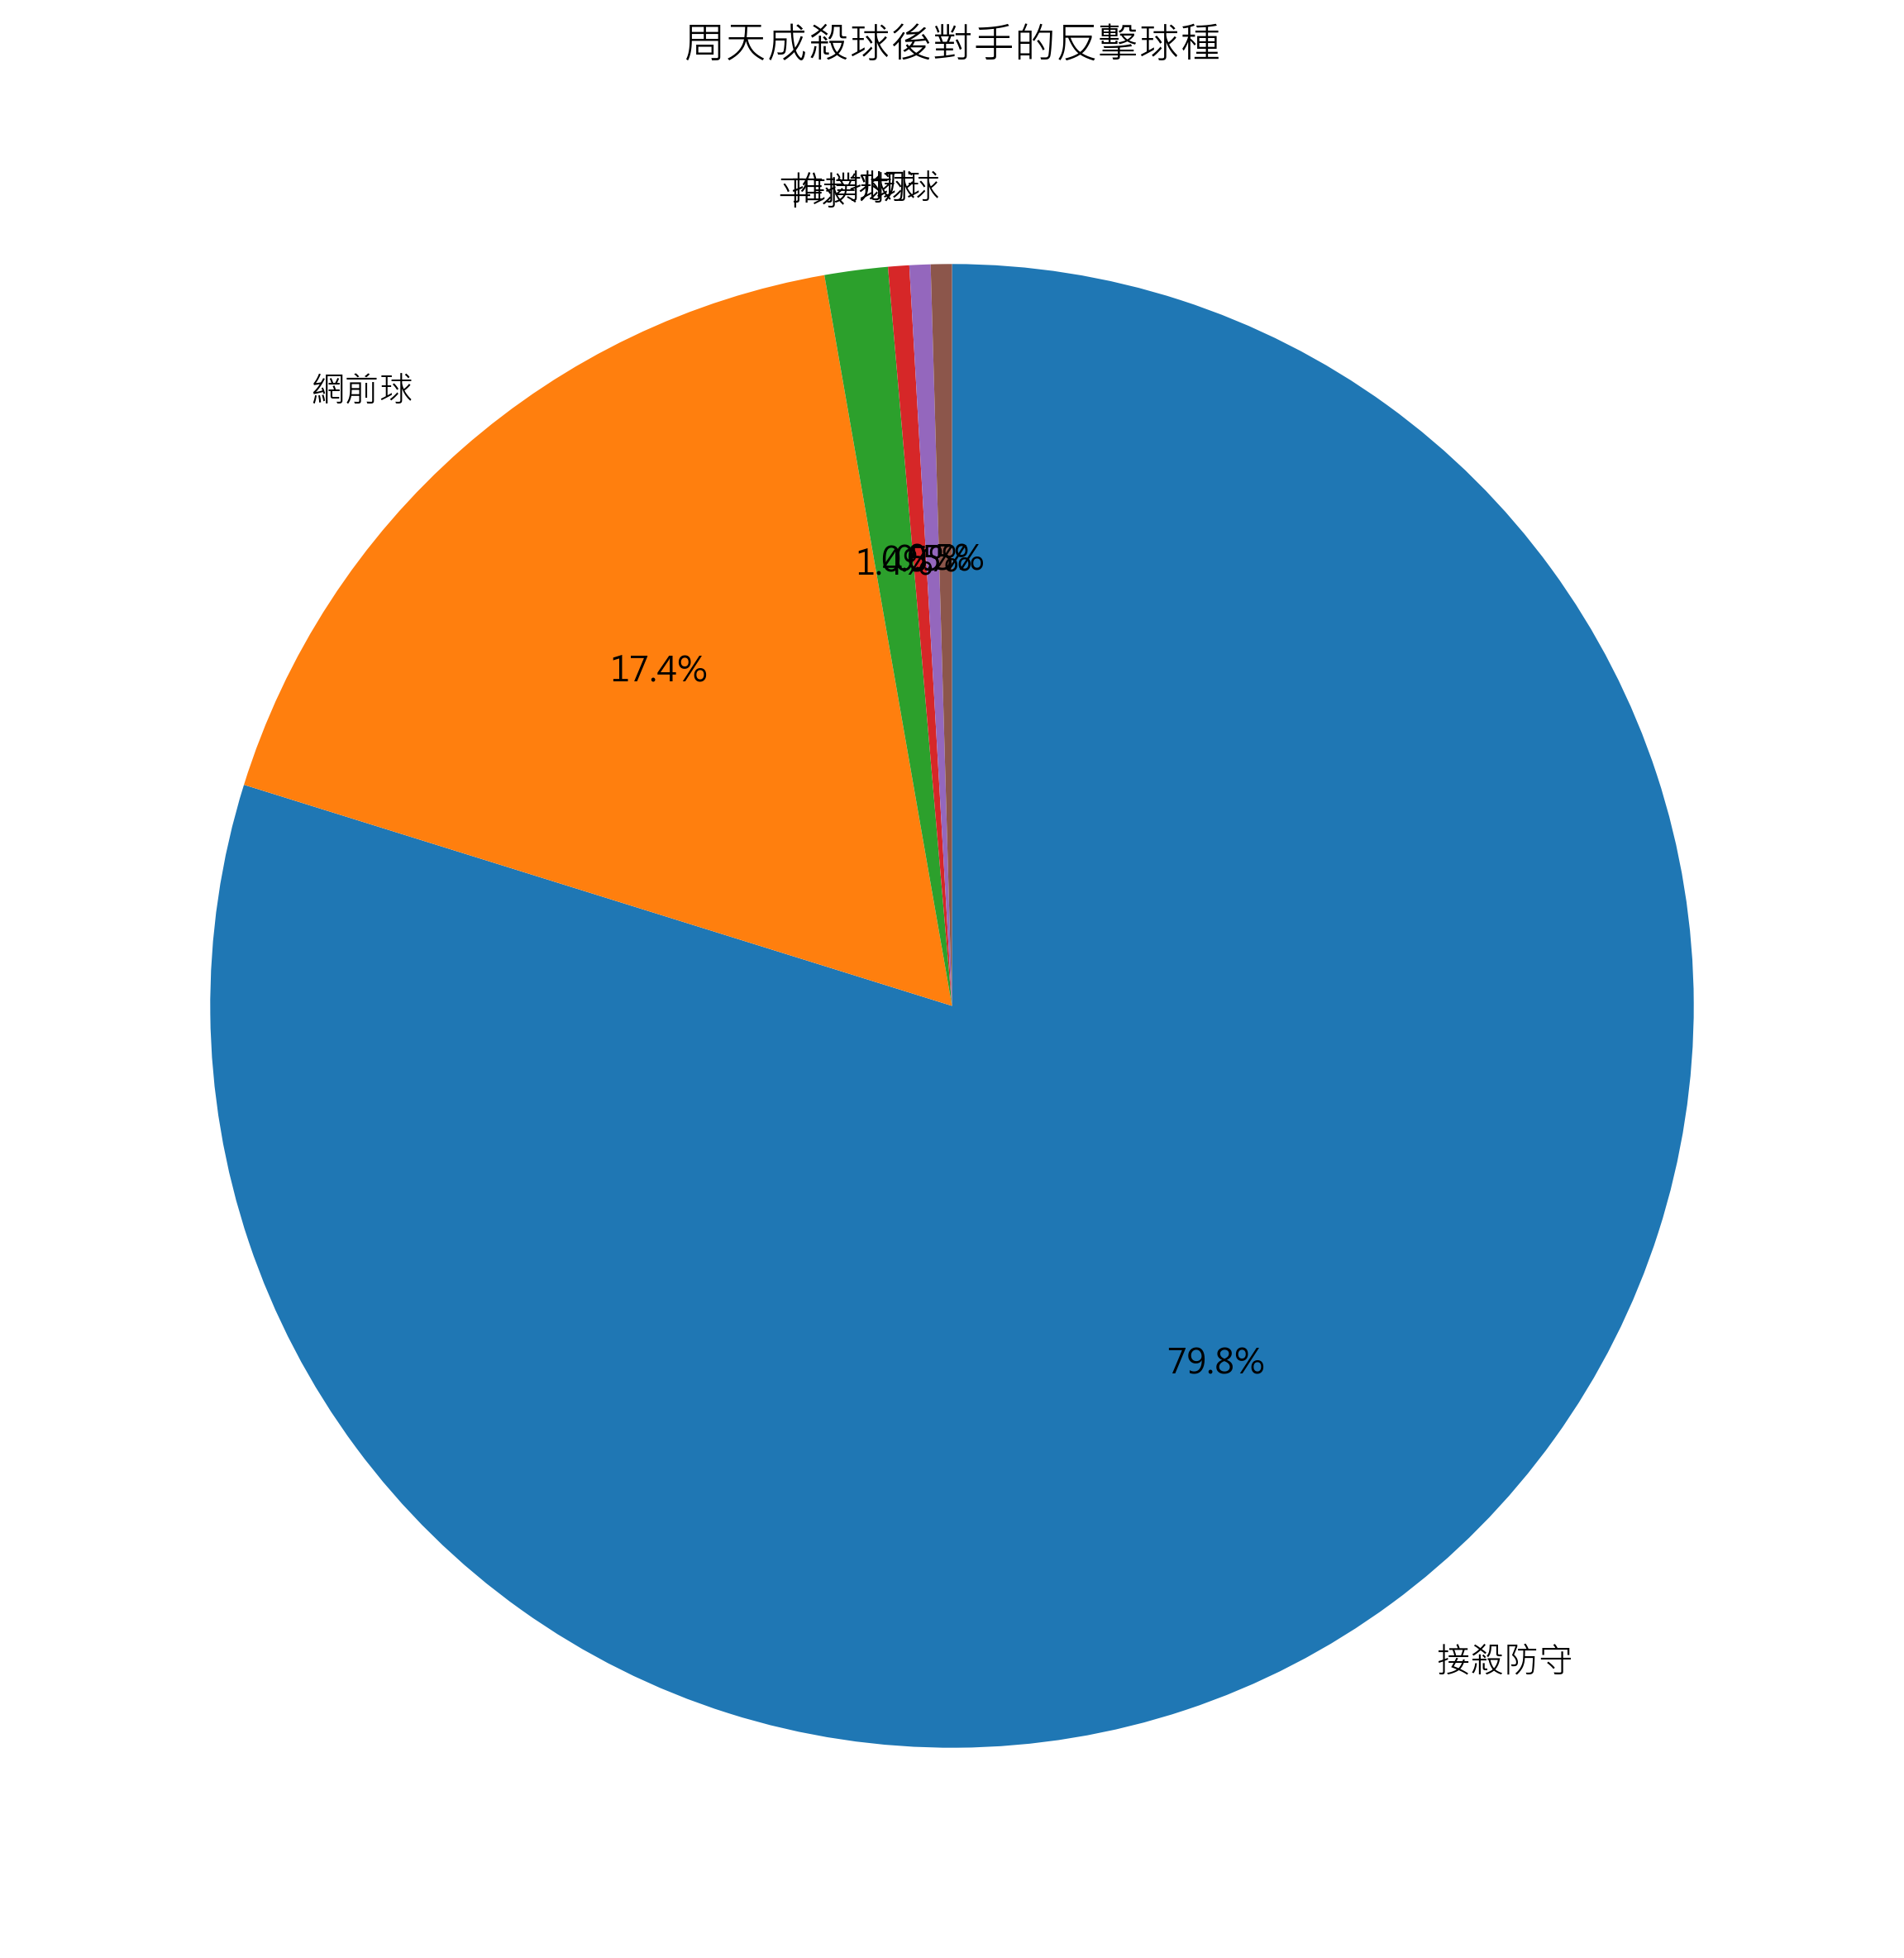

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'ball_round', 'player', 'opponent', 'type']

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        work_df = (
            df[required_cols]
            .sort_values(['match_id', 'set', 'rally', 'ball_round'])
            .copy()
        )

        rally_group = work_df.groupby(
            ['match_id', 'set', 'rally'],
            sort=False
        )

        work_df['next_player'] = rally_group['player'].shift(-1)
        work_df['next_type'] = rally_group['type'].shift(-1)

        chou_smash_df = work_df[
            (work_df['player'] == 'CHOU Tien Chen') &
            (work_df['type'] == '殺球') &
            (work_df['next_player'] == work_df['opponent'])
        ].copy()

        counterattack_df = chou_smash_df[
            chou_smash_df['next_type'].notna()
        ].copy()

        counterattack_counts = (
            counterattack_df['next_type']
            .value_counts()
            .rename_axis('對手反擊球種')
            .reset_index(name='次數')
        )

        total_counterattacks = counterattack_counts['次數'].sum()

        if total_counterattacks > 0:
            counterattack_counts['比例'] = (
                counterattack_counts['次數'] / total_counterattacks * 100
            ).round(2)

            print('周天成使用殺球後，對手下一拍的反擊球種統計：')
            print(counterattack_counts.to_string(index=False))
            print(f'\n有效反擊拍數：{total_counterattacks}')

            fig, ax = plt.subplots(figsize=(8, 8))
            ax.pie(
                counterattack_counts['次數'],
                labels=counterattack_counts['對手反擊球種'],
                autopct='%1.1f%%',
                startangle=90,
                counterclock=False
            )
            ax.set_title('周天成殺球後對手的反擊球種')
            plt.tight_layout()
        else:
            print('找不到周天成使用殺球後、同一回合由對手完成的下一拍反擊資料。')
            fig, ax = plt.subplots(figsize=(8, 8))
            ax.text(
                0.5, 0.5,
                '無有效反擊資料',
                ha='center',
                va='center',
                fontsize=16
            )
            ax.set_title('周天成殺球後對手的反擊球種')
            ax.axis('off')
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 34
**問題**: 分析周天成前一拍打什麼球種最容易造成對手未過網？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析對象：CHOU Tien Chen
統計口徑：周天成擊球後，同一回合下一拍為對手，且對手該拍的 getpoint_player 為周天成、lose_reason 為「未過網」。
最容易造成對手未過網的前一拍球種：殺球
未過網率：2.29% （5/218）

各前一拍球種統計：
type  前一拍次數  對手未過網次數  未過網率
  殺球    218        5 2.29%
  平球     96        1 1.04%
 推撲球    305        3 0.98%
  長球    262        1 0.38%
 網前球    538        2 0.37%
接殺防守    309        1 0.32%
  挑球    253        0 0.00%
  切球    202        0 0.00%
 發短球    147        0 0.00%
 發長球     34        0 0.00%


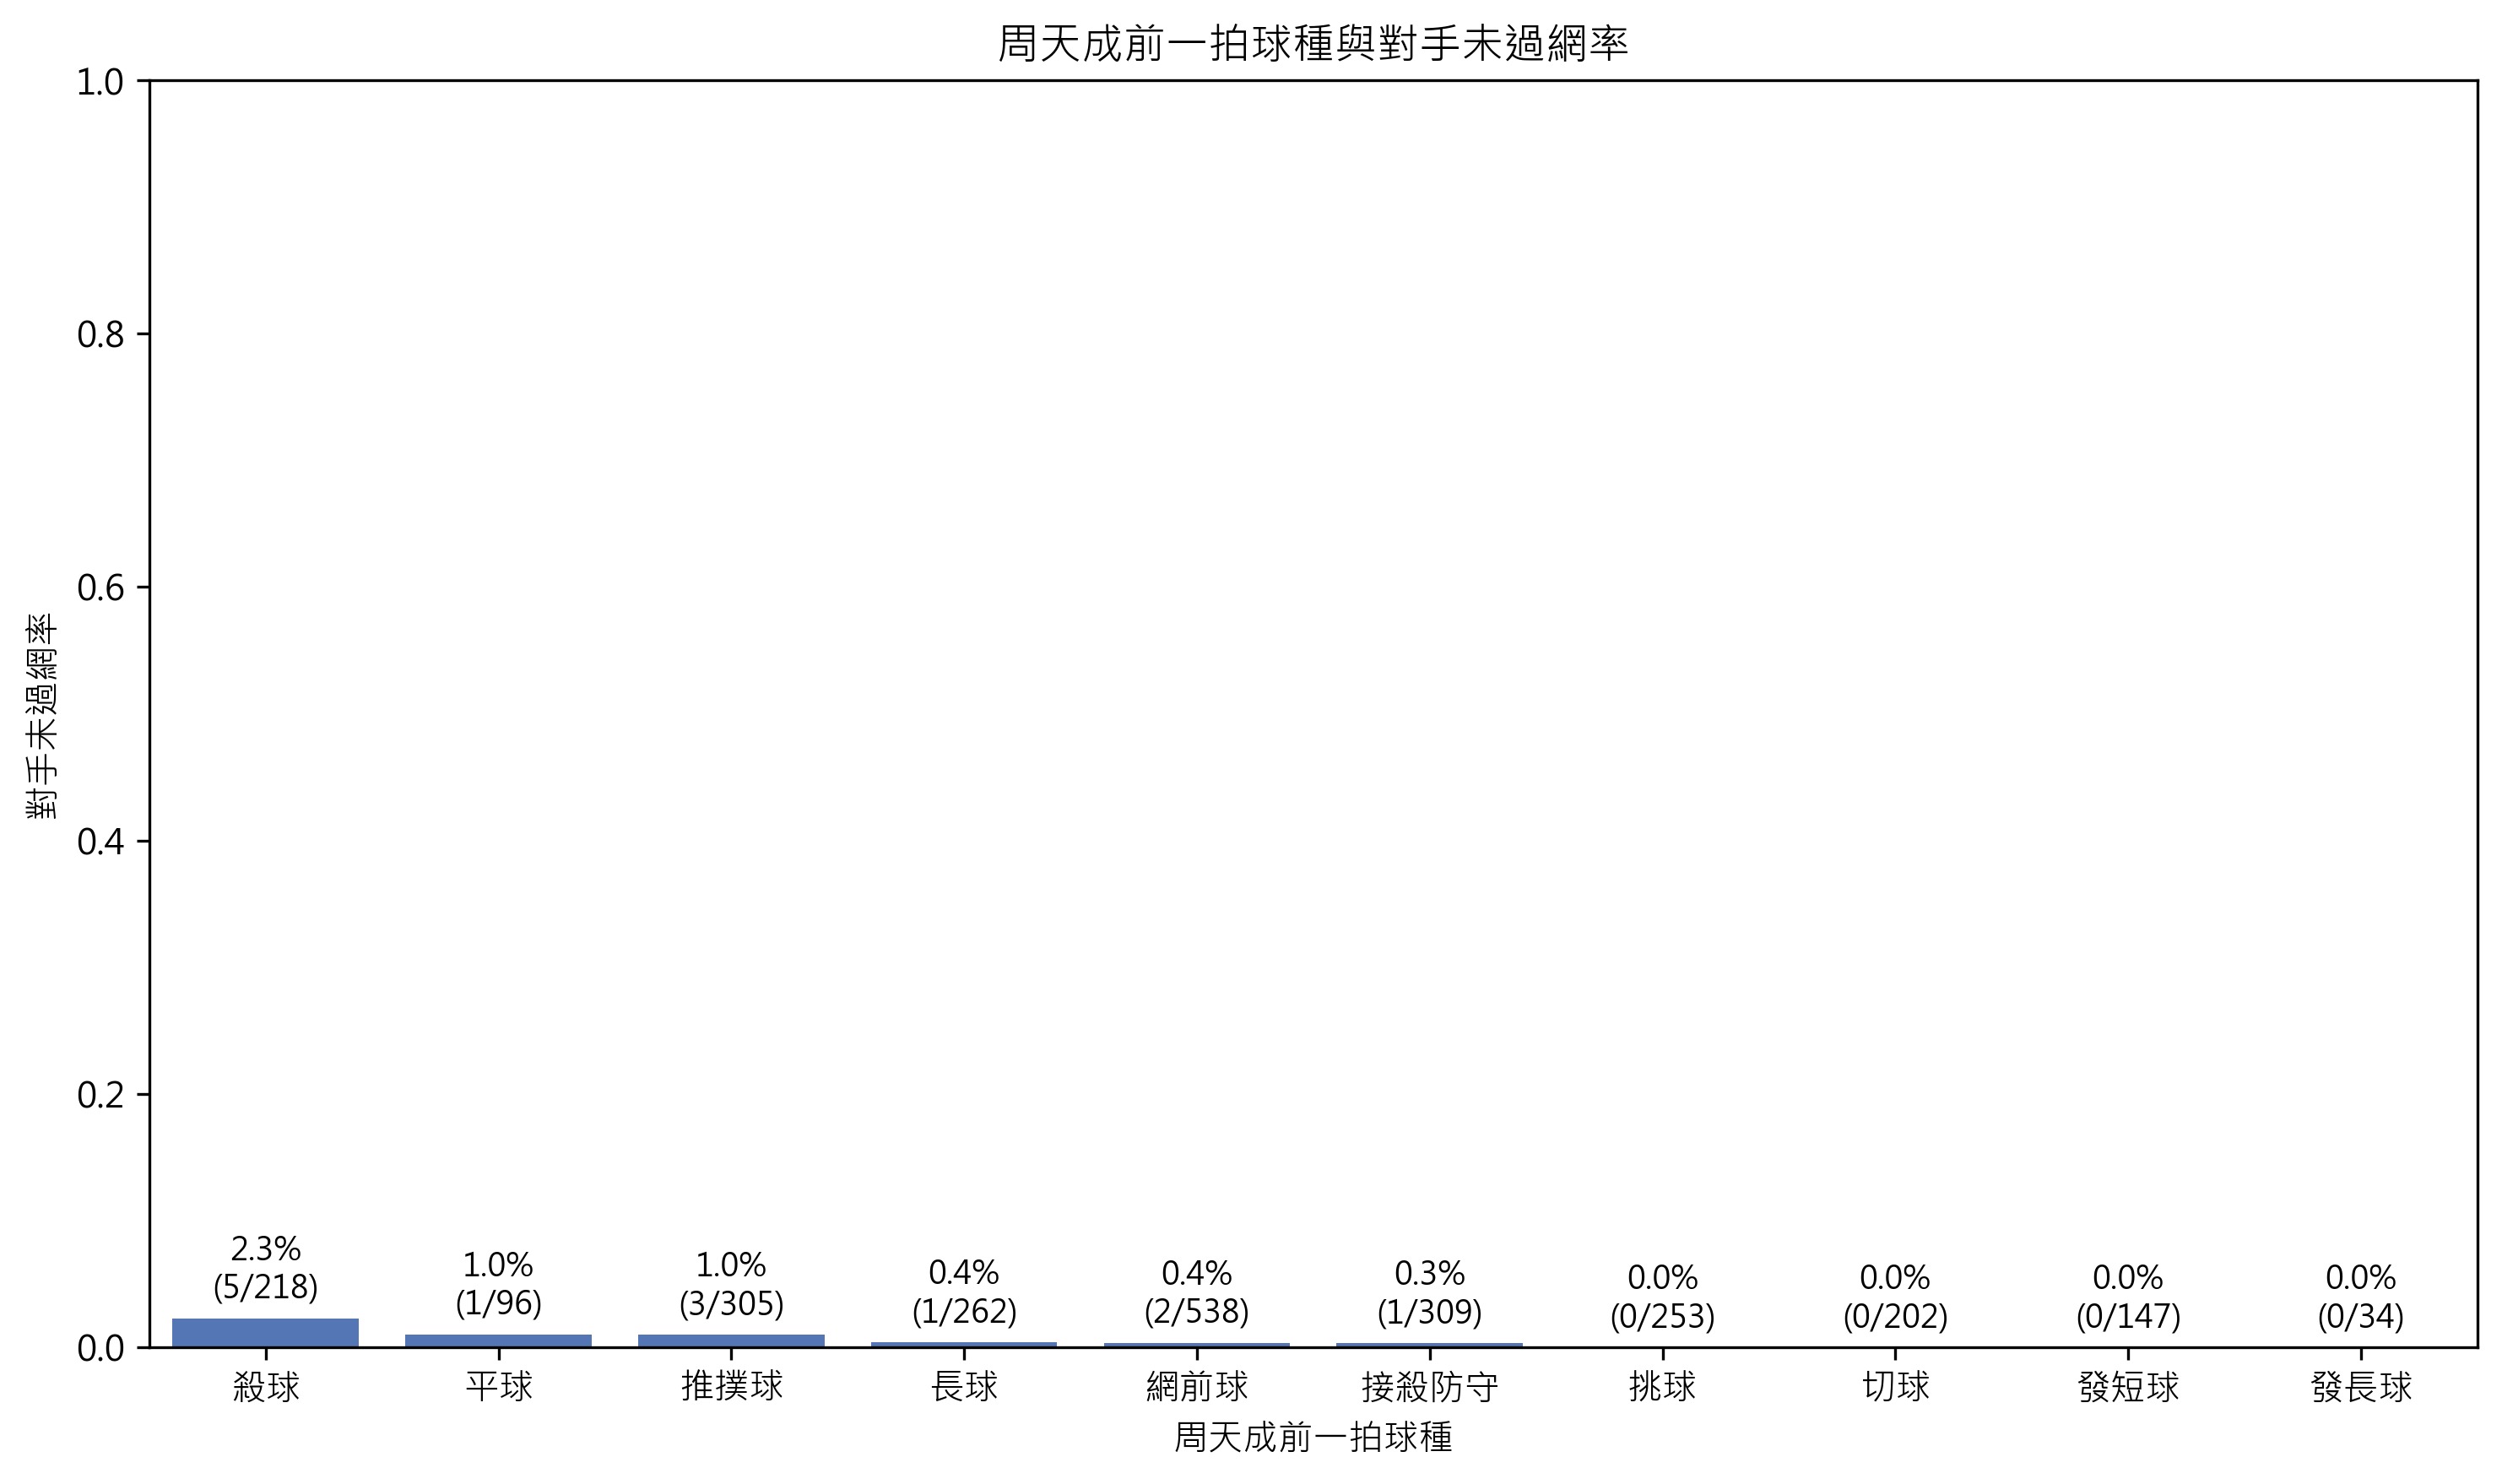

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(df) == 0:
    print("資料為空，無法分析。")
else:
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player", "opponent",
        "type", "getpoint_player", "lose_reason"
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        target_player = "CHOU Tien Chen"
        group_cols = ["match_id", "set", "rally"]

        work = df.sort_values(
            group_cols + ["ball_round"],
            kind="mergesort"
        ).copy()

        grouped = work.groupby(group_cols, sort=False)

        work["next_player"] = grouped["player"].shift(-1)
        work["next_opponent"] = grouped["opponent"].shift(-1)
        work["next_getpoint_player"] = grouped["getpoint_player"].shift(-1)
        work["next_lose_reason"] = grouped["lose_reason"].shift(-1)
        work["same_rally_next"] = (
            work["match_id"].eq(work["match_id"].shift(-1))
            & work["set"].eq(work["set"].shift(-1))
            & work["rally"].eq(work["rally"].shift(-1))
        )

        valid_preceding_shots = work[
            (work["player"] == target_player)
            & work["same_rally_next"]
            & (work["next_player"] == work["opponent"])
            & work["type"].notna()
        ].copy()

        if len(valid_preceding_shots) == 0:
            print("找不到周天成之後緊接對手擊球的有效資料。")
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.set_title("周天成前一拍球種與對手未過網")
            ax.axis("off")
            plt.tight_layout()
        else:
            valid_preceding_shots["對手未過網"] = (
                (valid_preceding_shots["next_getpoint_player"] == target_player)
                & (valid_preceding_shots["next_lose_reason"] == "未過網")
            )

            summary = (
                valid_preceding_shots
                .groupby("type", as_index=False)
                .agg(
                    前一拍次數=("type", "size"),
                    對手未過網次數=("對手未過網", "sum")
                )
            )

            summary["未過網率"] = (
                summary["對手未過網次數"] / summary["前一拍次數"]
            )

            summary = summary.sort_values(
                ["未過網率", "對手未過網次數", "前一拍次數"],
                ascending=[False, False, False]
            ).reset_index(drop=True)

            top_row = summary.iloc[0]

            print(f"分析對象：{target_player}")
            print("統計口徑：周天成擊球後，同一回合下一拍為對手，且對手該拍的 getpoint_player 為周天成、lose_reason 為「未過網」。")
            print(f"最容易造成對手未過網的前一拍球種：{top_row['type']}")
            print(
                f"未過網率：{top_row['未過網率']:.2%} "
                f"（{int(top_row['對手未過網次數'])}/{int(top_row['前一拍次數'])}）"
            )

            output_table = summary.copy()
            output_table["未過網率"] = output_table["未過網率"].map(
                lambda value: f"{value:.2%}"
            )
            print("\n各前一拍球種統計：")
            print(output_table.to_string(index=False))

            plot_data = summary.copy()
            plot_data["球種"] = plot_data["type"].astype(str)

            fig, ax = plt.subplots(figsize=(10, 6))
            sns.barplot(
                data=plot_data,
                x="球種",
                y="未過網率",
                color="#4472C4",
                ax=ax
            )

            ax.set_title("周天成前一拍球種與對手未過網率")
            ax.set_xlabel("周天成前一拍球種")
            ax.set_ylabel("對手未過網率")
            ax.set_ylim(0, max(1.0, plot_data["未過網率"].max() * 1.2))

            for index, row in plot_data.iterrows():
                ax.text(
                    index,
                    row["未過網率"] + 0.01,
                    f"{row['未過網率']:.1%}\n"
                    f"({int(row['對手未過網次數'])}/{int(row['前一拍次數'])})",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 37
**問題**: 分析周天成使用殺球造成失誤，請繪製失誤原因的圓餅圖
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成使用殺球造成對手失誤的回合數：16
失誤原因  次數
  掛網   6
 未過網   5
  出界   5


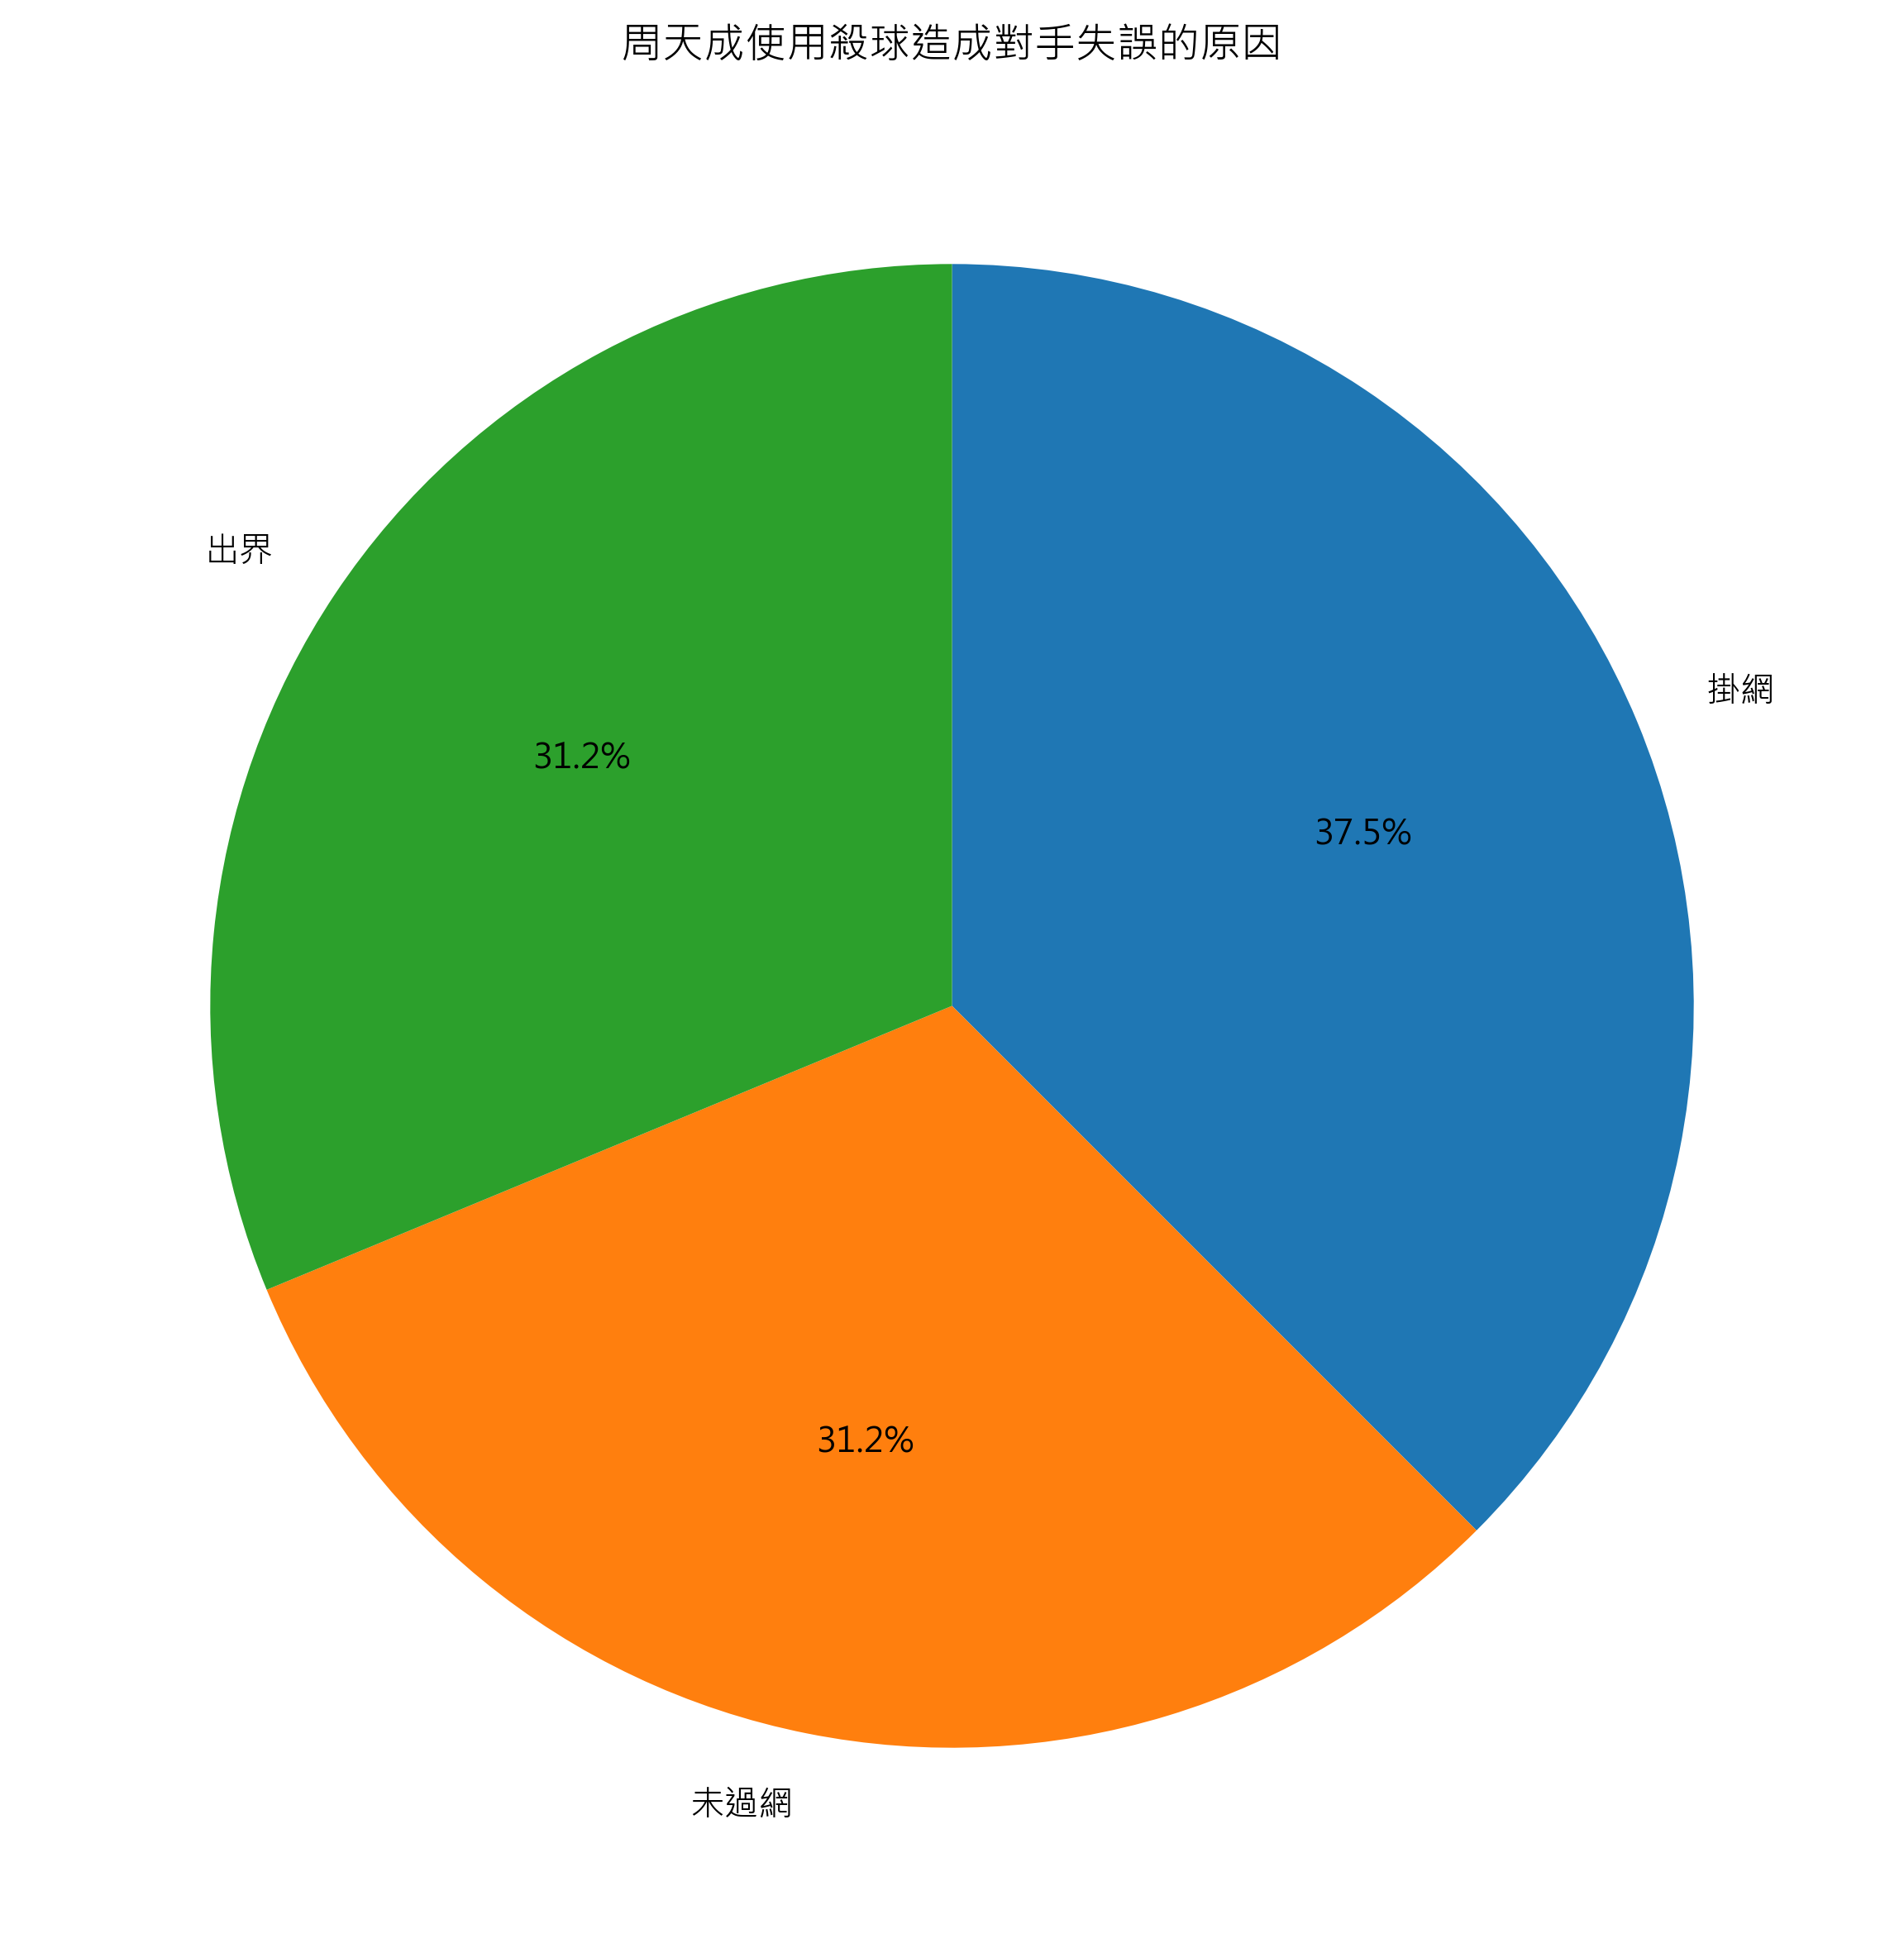

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player', 'lose_reason'
]

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        work_df = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        group_keys = ['match_id', 'set', 'rally']
        grouped = work_df.groupby(group_keys, sort=False)

        work_df['next_player'] = grouped['player'].shift(-1)
        work_df['next_getpoint_player'] = grouped['getpoint_player'].shift(-1)
        work_df['next_lose_reason'] = grouped['lose_reason'].shift(-1)

        chou_name = 'CHOU Tien Chen'

        # 周天成使用殺球後，對手在同一回合下一拍失誤而由周天成得分
        error_df = work_df[
            (work_df['player'] == chou_name) &
            (work_df['type'] == '殺球') &
            (work_df['next_player'] == work_df['opponent']) &
            (work_df['next_getpoint_player'] == chou_name) &
            (work_df['next_lose_reason'].notna())
        ].copy()

        reason_counts = (
            error_df['next_lose_reason']
            .value_counts()
            .rename_axis('失誤原因')
            .reset_index(name='次數')
        )

        total_errors = int(reason_counts['次數'].sum())

        print(f'周天成使用殺球造成對手失誤的回合數：{total_errors}')
        print(reason_counts.to_string(index=False))

        fig, ax = plt.subplots(figsize=(8, 8))

        if len(reason_counts) > 0:
            ax.pie(
                reason_counts['次數'],
                labels=reason_counts['失誤原因'],
                autopct='%1.1f%%',
                startangle=90,
                counterclock=False
            )
            ax.set_title('周天成使用殺球造成對手失誤的原因')
        else:
            ax.text(
                0.5, 0.5,
                '沒有符合條件的失誤資料',
                ha='center',
                va='center',
                fontsize=14
            )
            ax.set_title('周天成使用殺球造成對手失誤的原因')
            ax.axis('off')

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 38
**問題**: 在周天成的所有失分中，有多少百分比是因為對手的殺球導致的？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成總失分回合數：217
對手殺球主動得分造成的失分回合數：29
對手殺球造成的失分比例：13.36%


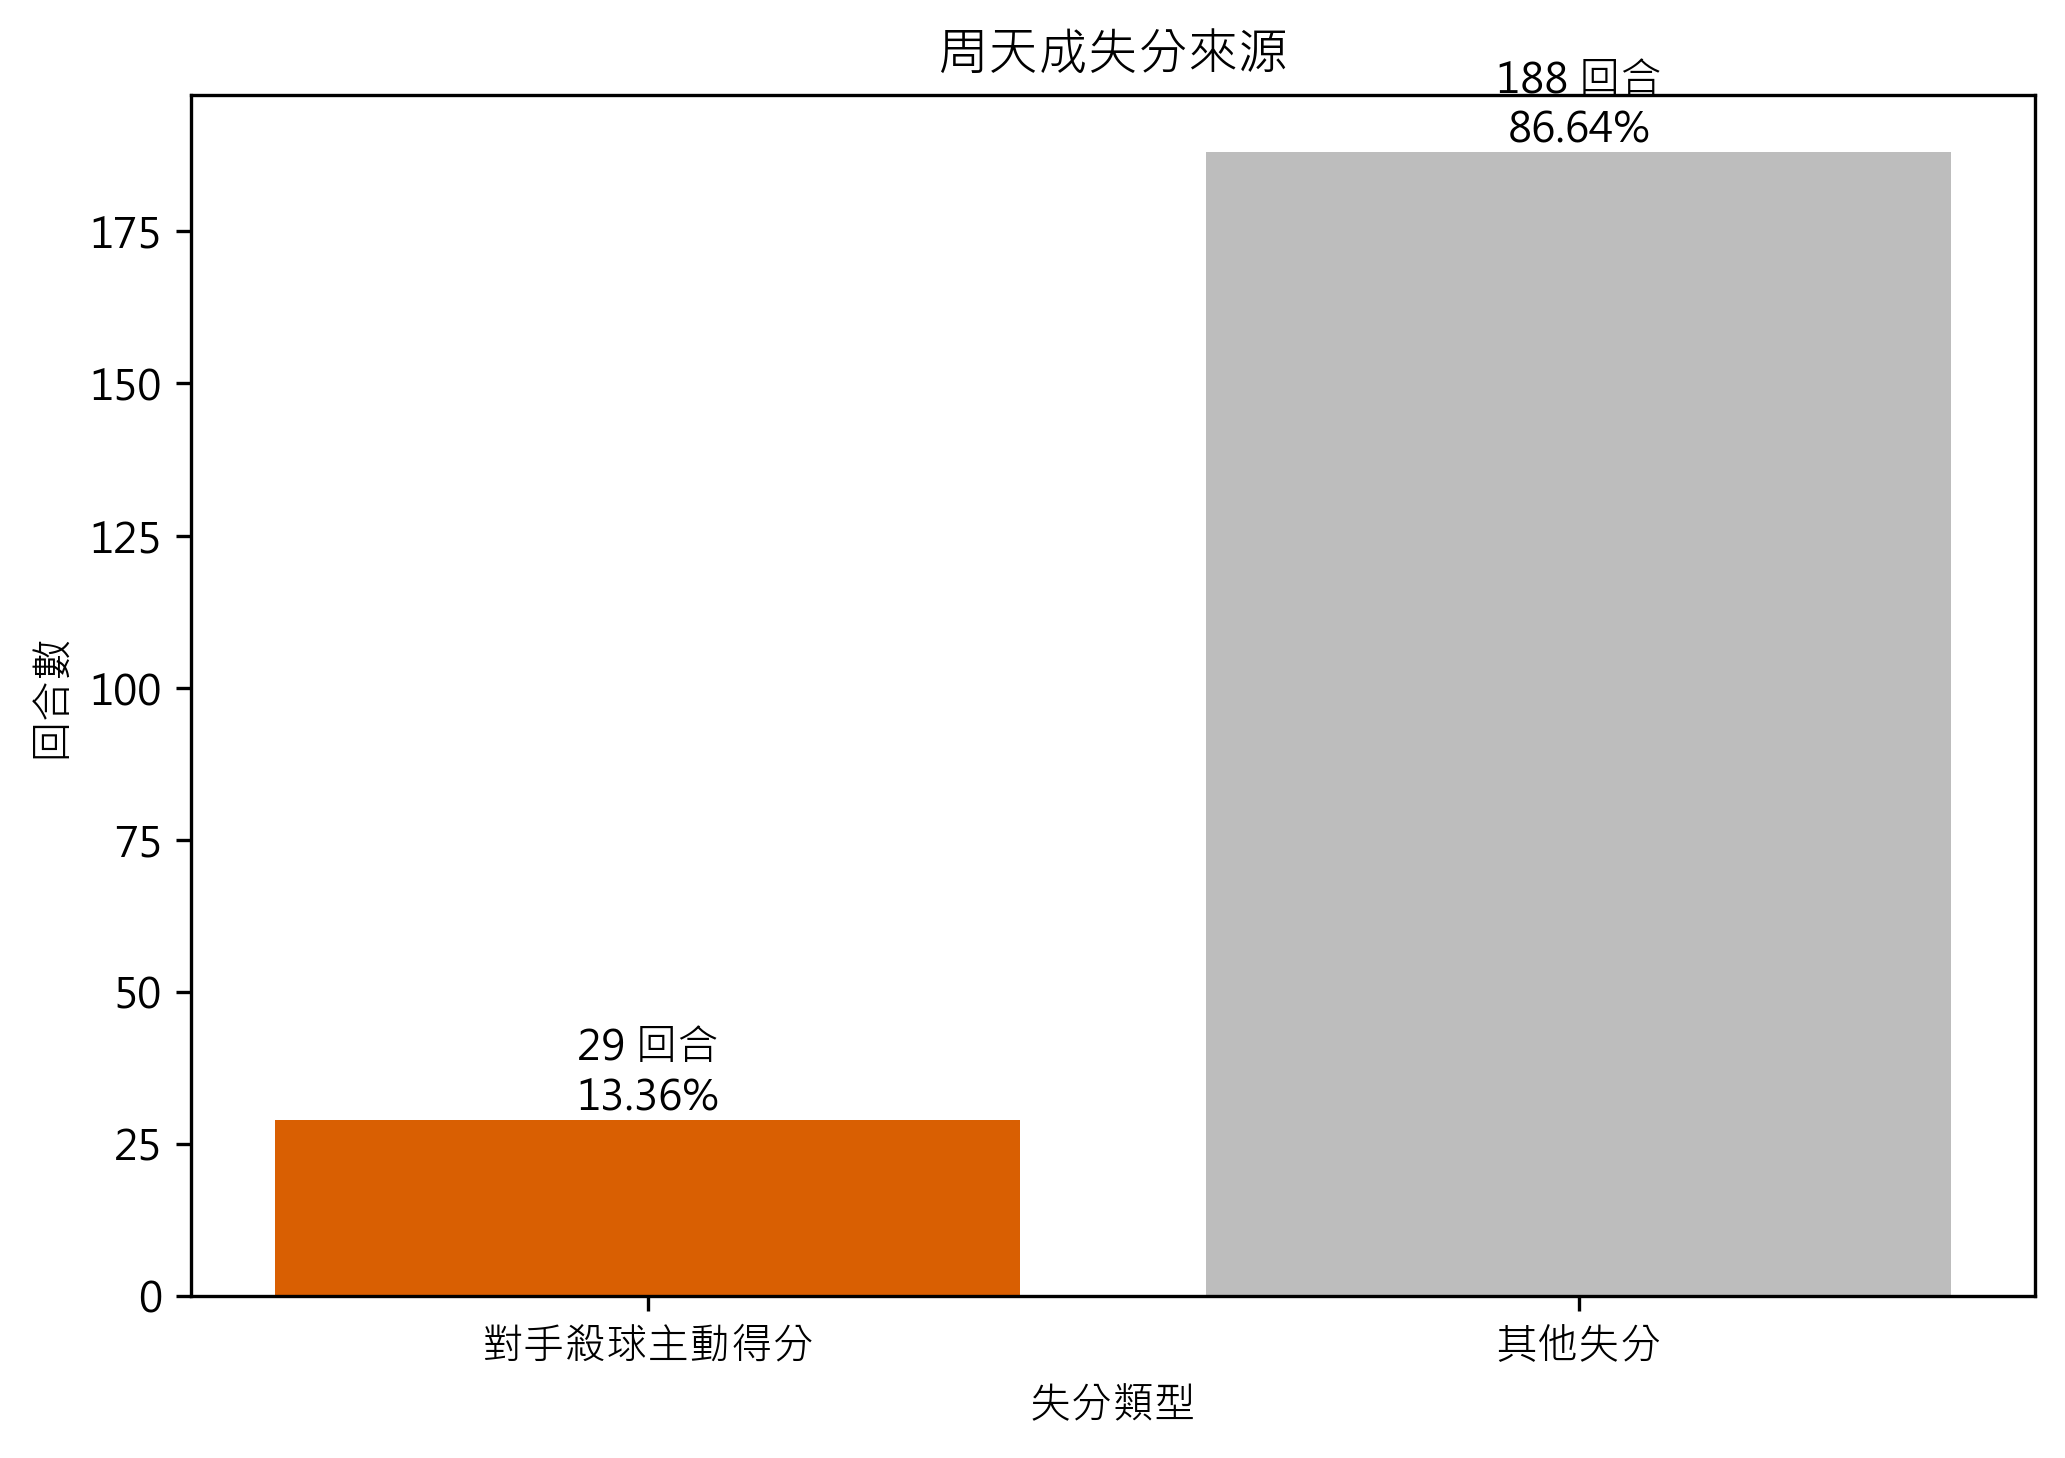

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法計算。')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title('周天成失分分析')
    ax.axis('off')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_title('周天成失分分析')
        ax.axis('off')
    else:
        group_cols = ['match_id', 'set', 'rally']

        work_df = df.sort_values(
            group_cols + ['ball_round']
        ).copy()

        rally_end_df = (
            work_df
            .groupby(group_cols, sort=False, as_index=False)
            .tail(1)
            .copy()
        )

        chou_loss_df = rally_end_df[
            rally_end_df['getpoint_player'].eq('Kento MOMOTA')
        ].copy()

        total_chou_losses = len(chou_loss_df)

        opponent_smash_loss_df = chou_loss_df[
            chou_loss_df['player'].eq('Kento MOMOTA')
            & chou_loss_df['getpoint_player'].eq('Kento MOMOTA')
            & chou_loss_df['type'].eq('殺球')
        ].copy()

        smash_loss_count = len(opponent_smash_loss_df)

        if total_chou_losses > 0:
            smash_loss_percentage = (
                smash_loss_count / total_chou_losses * 100
            )
        else:
            smash_loss_percentage = 0.0

        result_df = pd.DataFrame({
            '失分類型': ['對手殺球主動得分', '其他失分'],
            '回合數': [
                smash_loss_count,
                total_chou_losses - smash_loss_count
            ]
        })

        print(f'周天成總失分回合數：{total_chou_losses}')
        print(f'對手殺球主動得分造成的失分回合數：{smash_loss_count}')
        print(f'對手殺球造成的失分比例：{smash_loss_percentage:.2f}%')

        fig, ax = plt.subplots(figsize=(7, 5))

        if total_chou_losses > 0:
            bars = ax.bar(
                result_df['失分類型'],
                result_df['回合數'],
                color=['#d95f02', '#bdbdbd']
            )
            ax.set_title('周天成失分來源')
            ax.set_xlabel('失分類型')
            ax.set_ylabel('回合數')

            for bar, value in zip(bars, result_df['回合數']):
                percentage = value / total_chou_losses * 100
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f'{int(value)} 回合\n{percentage:.2f}%',
                    ha='center',
                    va='bottom'
                )
        else:
            ax.set_title('周天成失分來源')
            ax.text(
                0.5, 0.5,
                '沒有可分析的周天成失分回合',
                ha='center',
                va='center'
            )
            ax.axis('off')

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 42
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階中，他的「殺球」使用比例以及得分率，是否有顯著變化？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
1. 比分階段以每回合開始時周天成的比分判定。
2. 殺球使用比例 = 周天成殺球次數 / 周天成全部擊球次數。
3. 殺球得分率 = 殺球主動得分次數 / 周天成殺球嘗試次數。
4. 主動得分限定為 player == getpoint_player。

各比分階段統計：
             總擊球數  殺球數  殺球使用比例（%）  殺球嘗試數  殺球主動得分數  殺球得分率（%）
score_stage                                                
開局（0-4分）      673   79      11.74     79       20     25.32
中局（5-17分）    1754  199      11.35    199       37     18.59
關鍵分（18分以上）    182   21      11.54     21        4     19.05

殺球使用比例卡方檢定 p-value：0.9631
殺球使用比例是否有顯著變化：否
殺球得分率卡方檢定 p-value：0.4494
殺球得分率是否有顯著變化：否


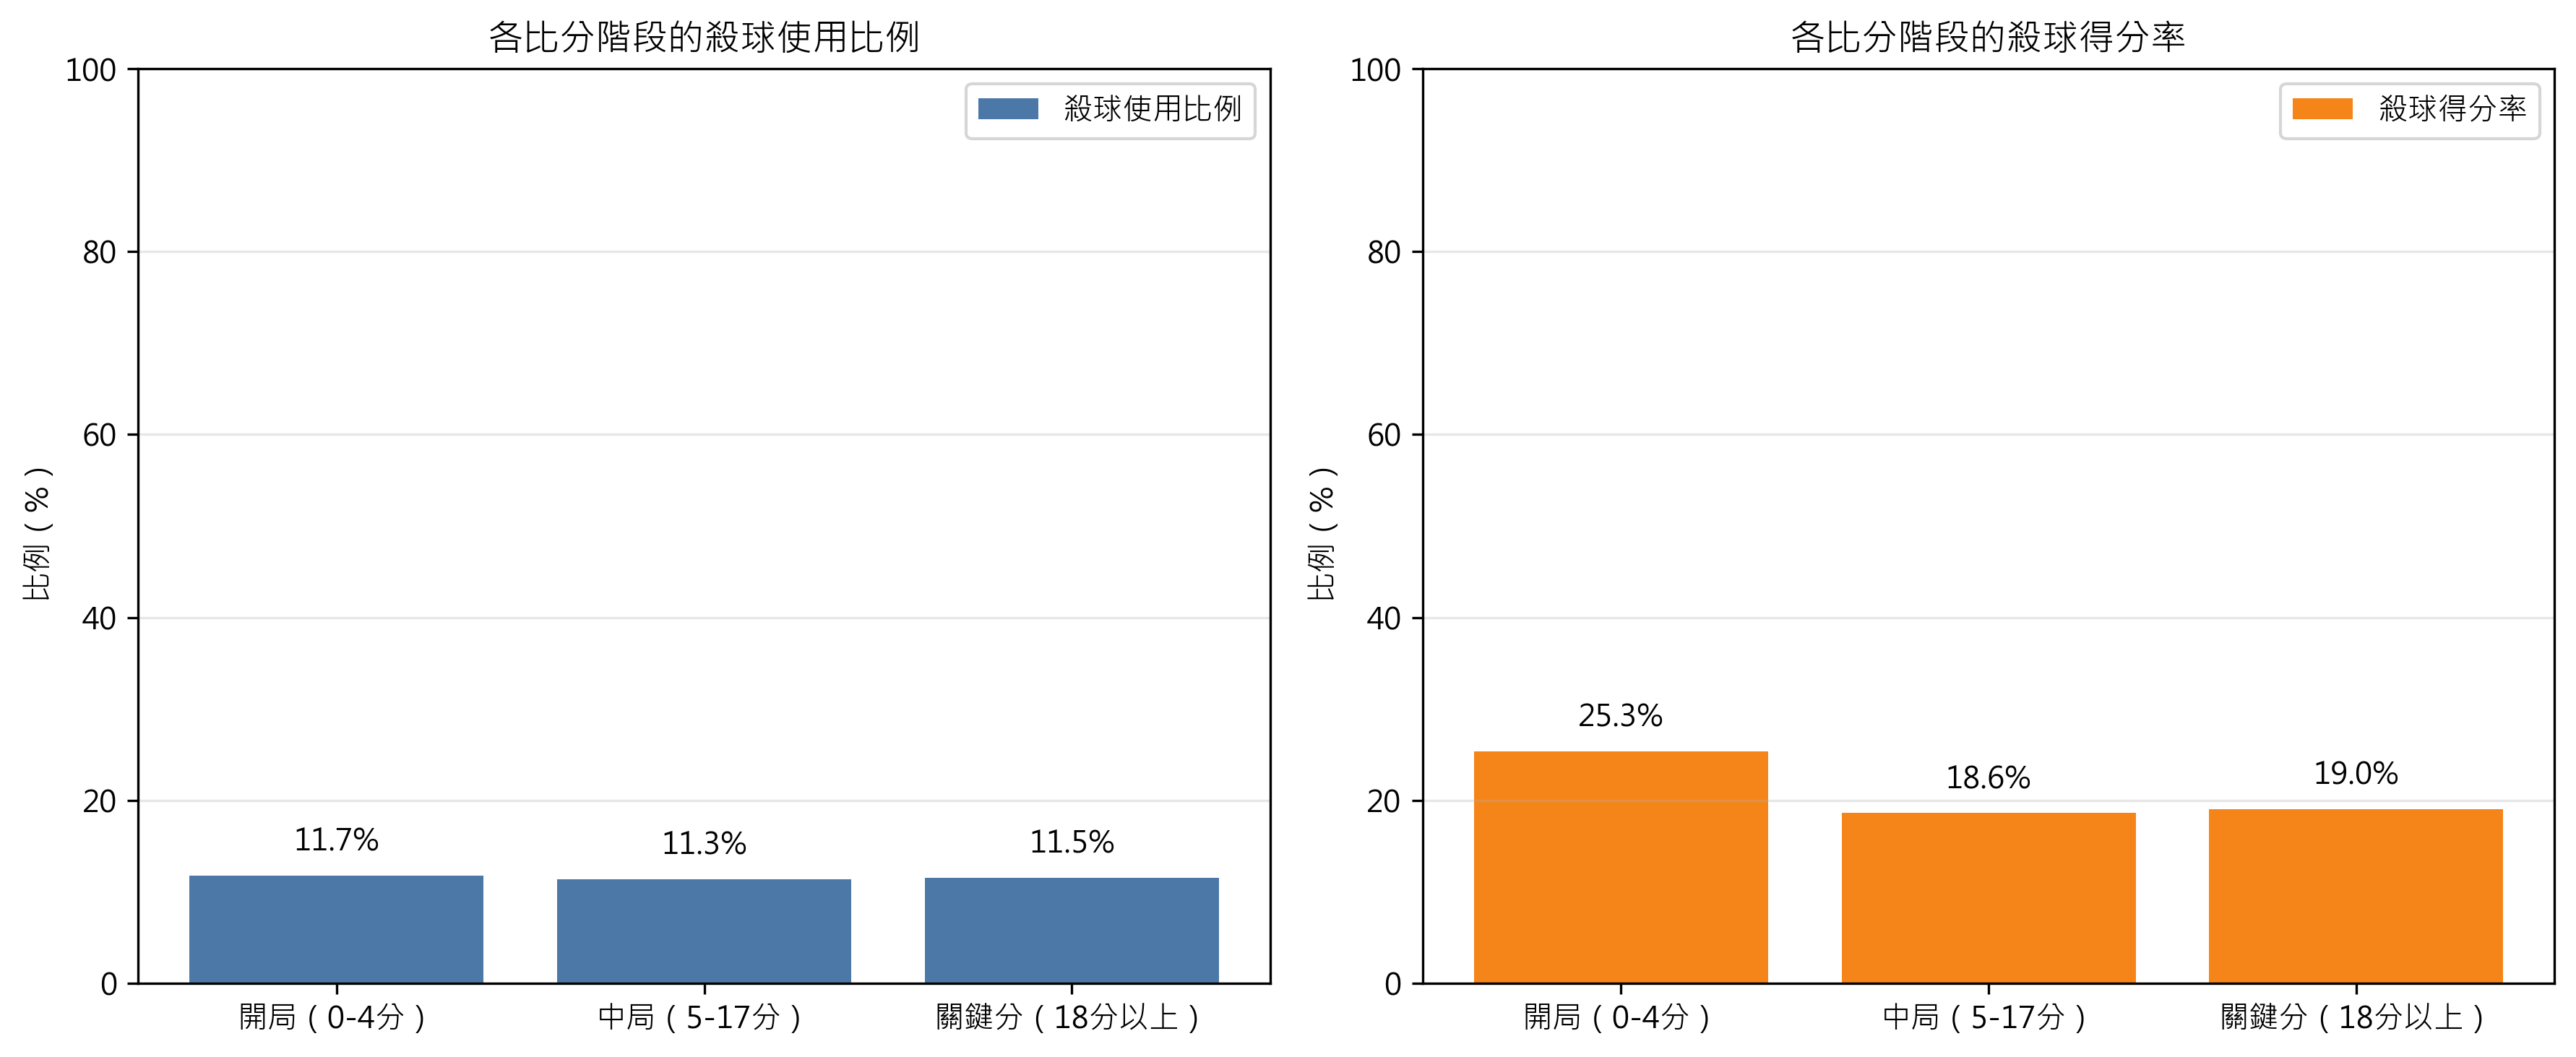

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

required_cols = [
    'match_id',
    'set',
    'rally',
    'ball_round',
    'player',
    'type',
    'getpoint_player',
    'CHOU Tien Chen_score'
]

if len(df) == 0:
    print('資料為空，無法分析。')
    fig = plt.figure(figsize=(8, 5))
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig = plt.figure(figsize=(8, 5))
    else:
        data = df[required_cols].copy()

        data = data.dropna(
            subset=[
                'match_id',
                'set',
                'rally',
                'ball_round',
                'player',
                'type',
                'CHOU Tien Chen_score'
            ]
        )

        if len(data) == 0:
            print('必要欄位沒有有效資料，無法分析。')
            fig = plt.figure(figsize=(8, 5))
        else:
            data = data.sort_values(
                ['match_id', 'set', 'rally', 'ball_round']
            ).reset_index(drop=True)

            rally_keys = ['match_id', 'set', 'rally']
            stage_order = [
                '開局（0-4分）',
                '中局（5-17分）',
                '關鍵分（18分以上）'
            ]

            data['rally_start_score'] = (
                data.groupby(rally_keys)['CHOU Tien Chen_score']
                .transform('first')
            )

            conditions = [
                data['rally_start_score'].between(0, 4),
                data['rally_start_score'].between(5, 17),
                data['rally_start_score'] >= 18
            ]

            # default 使用字串，避免 np.select 的字串與浮點型別衝突
            data['score_stage'] = np.select(
                conditions,
                stage_order,
                default='未分類'
            )

            player_data = data[
                (data['player'] == 'CHOU Tien Chen') &
                (data['score_stage'].isin(stage_order))
            ].copy()

            if len(player_data) == 0:
                print('找不到周天成在有效比分階段的擊球資料。')
                fig = plt.figure(figsize=(8, 5))
            else:
                player_data['is_smash'] = player_data['type'].eq('殺球')

                # 主動得分必須同時符合擊球者與回合得分者相同
                player_data['active_win'] = (
                    player_data['player'] ==
                    player_data['getpoint_player']
                )

                usage_summary = (
                    player_data
                    .groupby('score_stage', observed=False)
                    .agg(
                        總擊球數=('is_smash', 'size'),
                        殺球數=('is_smash', 'sum')
                    )
                    .reindex(stage_order)
                    .fillna(0)
                )

                usage_summary['殺球使用比例（%）'] = np.where(
                    usage_summary['總擊球數'] > 0,
                    usage_summary['殺球數'] /
                    usage_summary['總擊球數'] * 100,
                    np.nan
                )

                smash_data = player_data[
                    player_data['is_smash']
                ].copy()

                scoring_summary = (
                    smash_data
                    .groupby('score_stage', observed=False)
                    .agg(
                        殺球嘗試數=('active_win', 'size'),
                        殺球主動得分數=('active_win', 'sum')
                    )
                    .reindex(stage_order)
                    .fillna(0)
                )

                scoring_summary['殺球得分率（%）'] = np.where(
                    scoring_summary['殺球嘗試數'] > 0,
                    scoring_summary['殺球主動得分數'] /
                    scoring_summary['殺球嘗試數'] * 100,
                    np.nan
                )

                result = usage_summary.join(scoring_summary)

                usage_table = []
                usage_valid_stages = []

                for stage in stage_order:
                    stage_data = player_data[
                        player_data['score_stage'] == stage
                    ]

                    total_shots = len(stage_data)
                    smash_shots = int(stage_data['is_smash'].sum())

                    if total_shots > 0:
                        usage_table.append([
                            smash_shots,
                            total_shots - smash_shots
                        ])
                        usage_valid_stages.append(stage)

                if len(usage_table) >= 2:
                    usage_chi2, usage_p, _, _ = chi2_contingency(
                        np.asarray(usage_table)
                    )
                else:
                    usage_chi2, usage_p = np.nan, np.nan

                scoring_table = []
                scoring_valid_stages = []

                for stage in stage_order:
                    stage_data = smash_data[
                        smash_data['score_stage'] == stage
                    ]

                    attempts = len(stage_data)
                    active_wins = int(stage_data['active_win'].sum())

                    if attempts > 0:
                        scoring_table.append([
                            active_wins,
                            attempts - active_wins
                        ])
                        scoring_valid_stages.append(stage)

                if len(scoring_table) >= 2:
                    scoring_chi2, scoring_p, _, _ = chi2_contingency(
                        np.asarray(scoring_table)
                    )
                else:
                    scoring_chi2, scoring_p = np.nan, np.nan

                print('統計口徑：')
                print('1. 比分階段以每回合開始時周天成的比分判定。')
                print('2. 殺球使用比例 = 周天成殺球次數 / 周天成全部擊球次數。')
                print('3. 殺球得分率 = 殺球主動得分次數 / 周天成殺球嘗試次數。')
                print('4. 主動得分限定為 player == getpoint_player。')
                print()
                print('各比分階段統計：')
                print(
                    result[
                        [
                            '總擊球數',
                            '殺球數',
                            '殺球使用比例（%）',
                            '殺球嘗試數',
                            '殺球主動得分數',
                            '殺球得分率（%）'
                        ]
                    ].round(2).to_string()
                )

                print()
                print(
                    f'殺球使用比例卡方檢定 p-value：'
                    f'{usage_p:.4f}'
                    if pd.notna(usage_p)
                    else '殺球使用比例卡方檢定：資料不足'
                )
                print(
                    '殺球使用比例是否有顯著變化：'
                    f'{"是" if pd.notna(usage_p) and usage_p < 0.05 else "否"}'
                    if pd.notna(usage_p)
                    else '殺球使用比例是否有顯著變化：無法判定'
                )

                print(
                    f'殺球得分率卡方檢定 p-value：'
                    f'{scoring_p:.4f}'
                    if pd.notna(scoring_p)
                    else '殺球得分率卡方檢定：資料不足'
                )
                print(
                    '殺球得分率是否有顯著變化：'
                    f'{"是" if pd.notna(scoring_p) and scoring_p < 0.05 else "否"}'
                    if pd.notna(scoring_p)
                    else '殺球得分率是否有顯著變化：無法判定'
                )

                usage_values = (
                    result['殺球使用比例（%）']
                    .astype(float)
                    .to_numpy()
                )
                scoring_values = (
                    result['殺球得分率（%）']
                    .astype(float)
                    .to_numpy()
                )

                fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                x = np.arange(len(stage_order))

                axes[0].bar(
                    x,
                    usage_values,
                    color='#4C78A8',
                    label='殺球使用比例'
                )
                axes[0].set_title('各比分階段的殺球使用比例')
                axes[0].set_ylabel('比例（%）')
                axes[0].set_xticks(x)
                axes[0].set_xticklabels(stage_order)
                axes[0].set_ylim(0, 100)
                axes[0].grid(axis='y', alpha=0.3)
                axes[0].legend()

                axes[1].bar(
                    x,
                    scoring_values,
                    color='#F58518',
                    label='殺球得分率'
                )
                axes[1].set_title('各比分階段的殺球得分率')
                axes[1].set_ylabel('比例（%）')
                axes[1].set_xticks(x)
                axes[1].set_xticklabels(stage_order)
                axes[1].set_ylim(0, 100)
                axes[1].grid(axis='y', alpha=0.3)
                axes[1].legend()

                for ax, values in zip(
                    axes,
                    [usage_values, scoring_values]
                ):
                    for index, value in enumerate(values):
                        if pd.notna(value):
                            ax.text(
                                index,
                                min(value + 2, 98),
                                f'{value:.1f}%',
                                ha='center',
                                va='bottom'
                            )

                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 45
**問題**: 統整周天成每個場次中各局的表現(例如，球種變化、殺球頻與失誤率、失誤原因等等)
> **使用的資料欄位群組**: `全欄位 (Fallback)`


=== 周天成各場次、各局整體表現 ===
 match_id  set  進行回合數  已判定回合數  得分回合數    勝利率  主動得分回合數  被動得分回合數  失分回合數  自身失誤回合數  對手主動得分回合數  失誤率_失誤除以進行回合  失分中自身失誤比例  周天成總擊球數  球種種類數  殺球數  周天成擊球數   殺球頻率 最常使用球種  最常使用球種次數
      1.0    1     35      35     14 0.4000        6        8     21       18          3        0.5143     0.8571      261     10   32     261 0.1226    推撲球        51
      1.0    2     33      33     18 0.5455       10        8     15        8          7        0.2424     0.5333      225     10   21     225 0.0933   接殺防守        40
      1.0    3     39      39     18 0.4615        8       10     21       16          5        0.4103     0.7619      293     10   28     293 0.0956   接殺防守        64
      3.0    1     33      33     15 0.4545        9        6     18       12          6        0.3636     0.6667      206      9   24     206 0.1165    網前球        52
      3.0    2     34      34     16 0.4706        7        9     18       14          4        0.4118     0.7778      199      9   26     199 

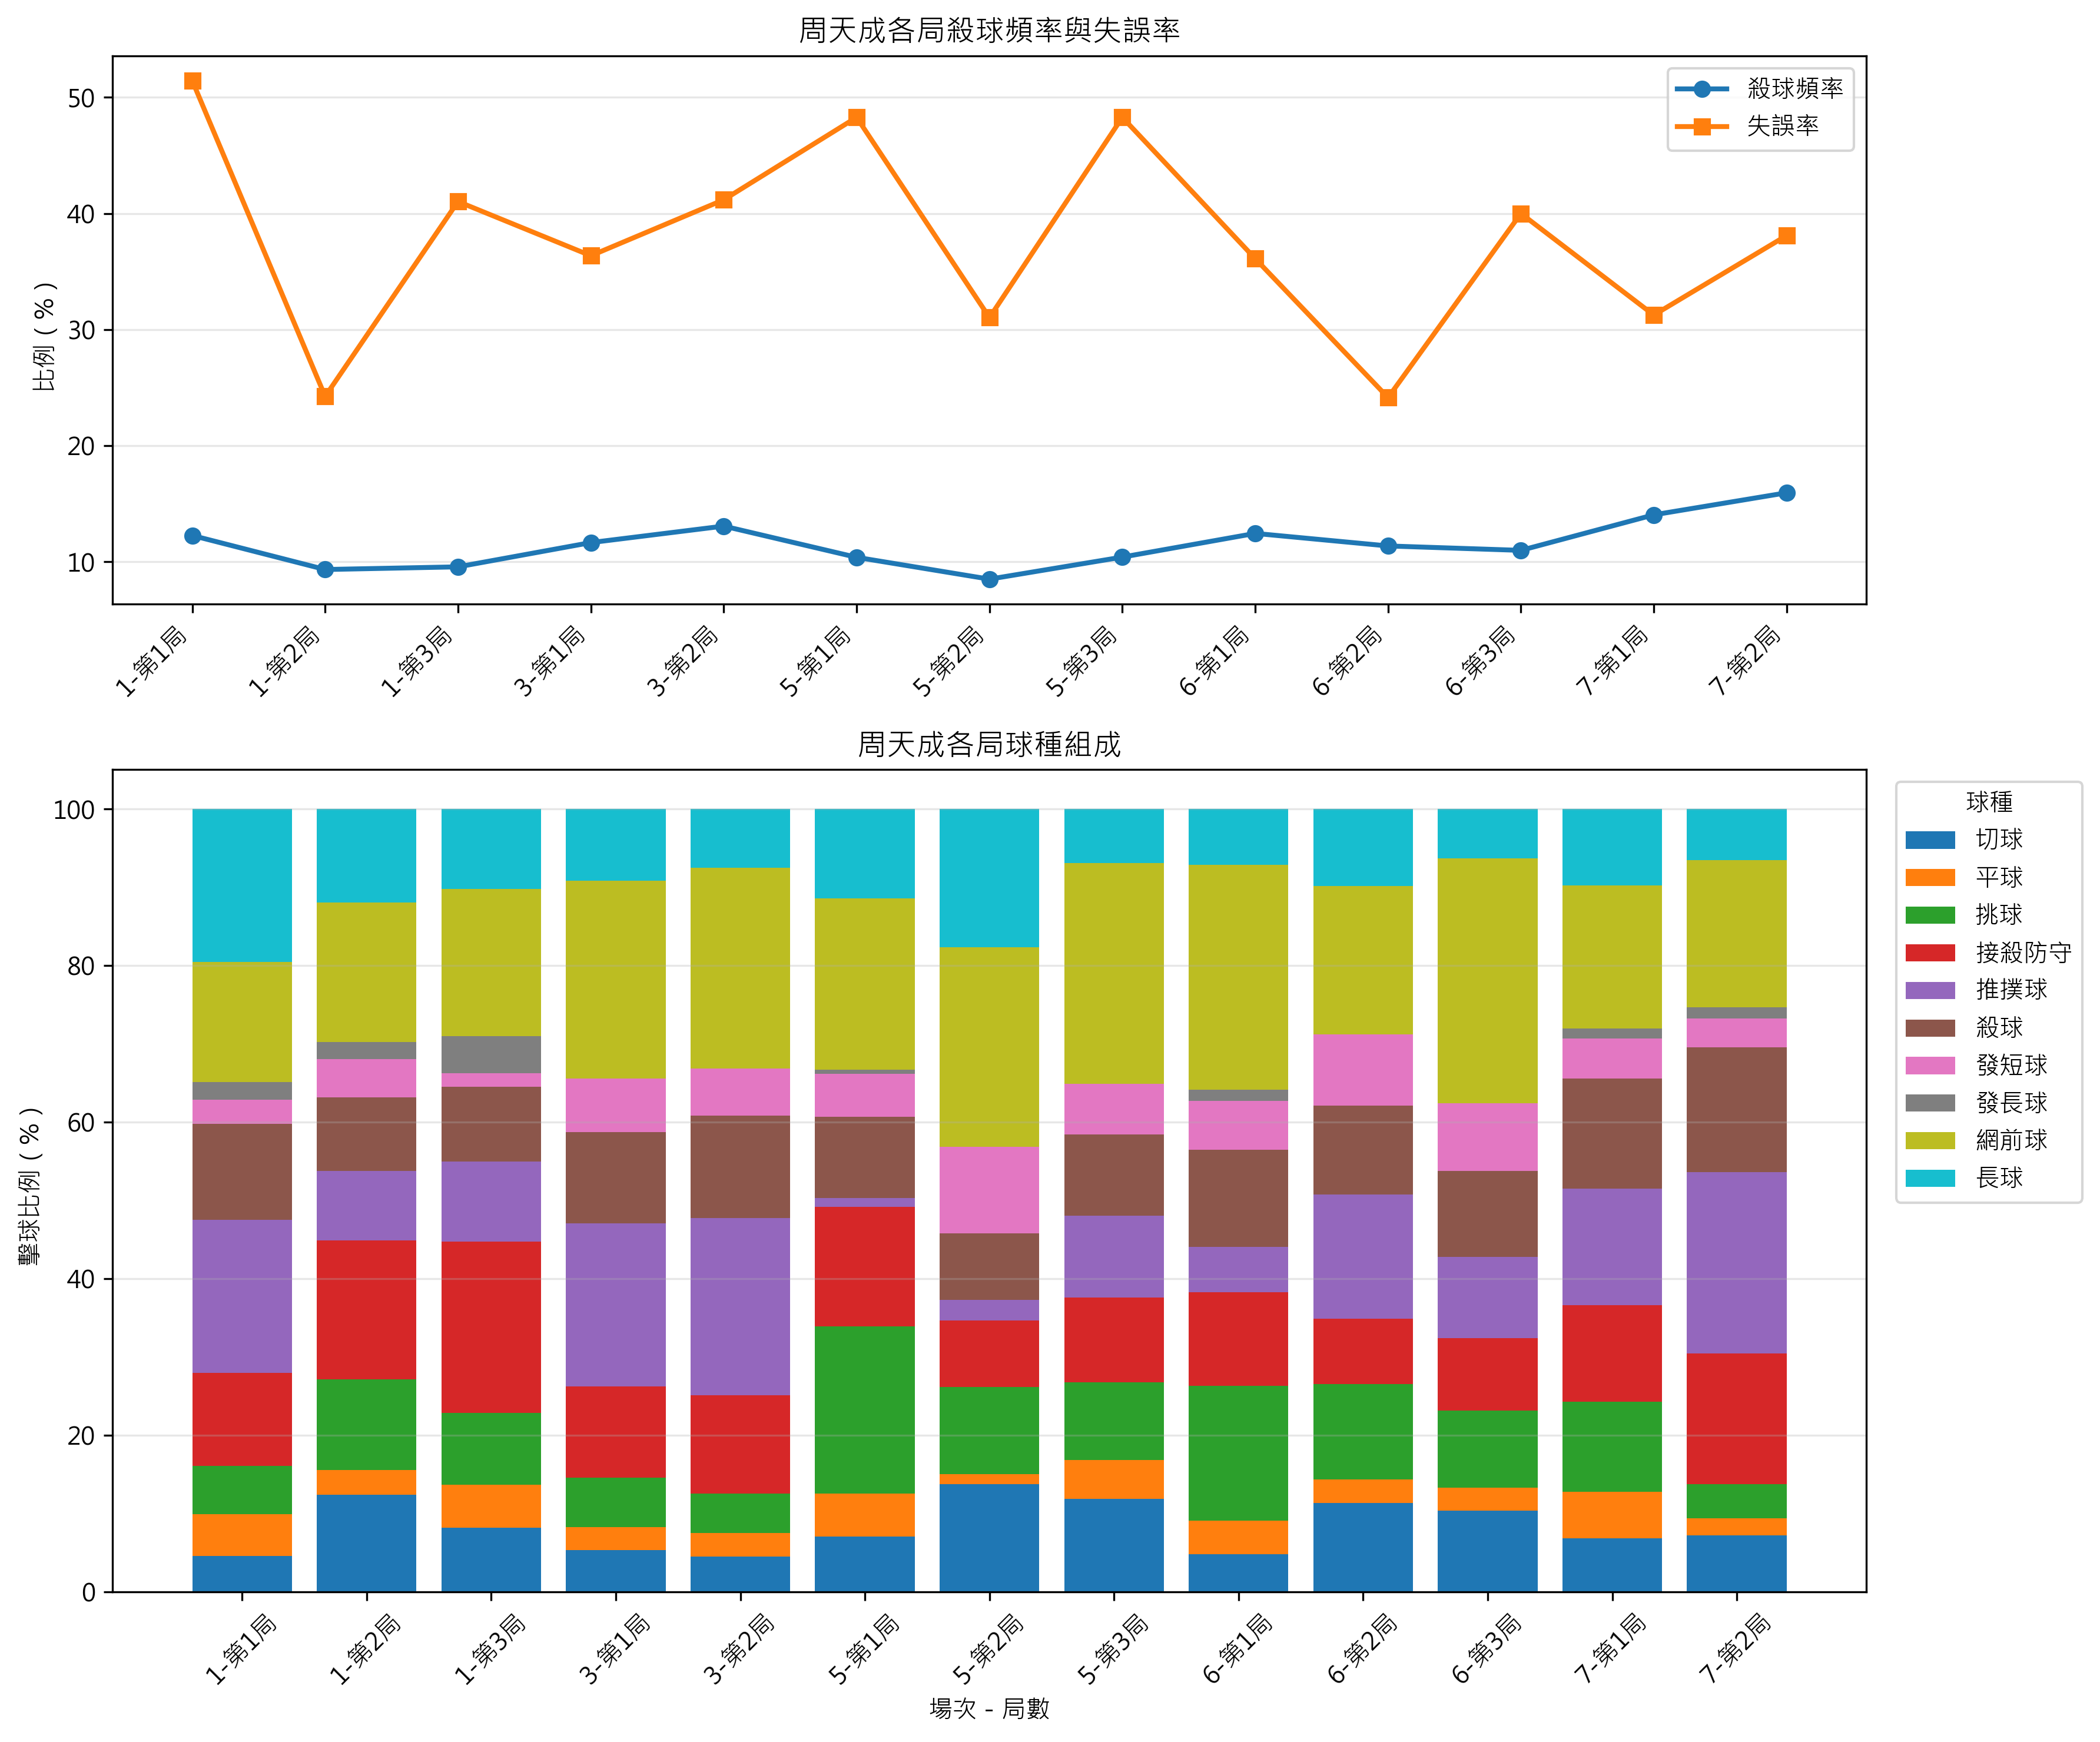

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player', 'lose_reason'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print("資料為空，無法進行分析。")
elif len(missing_cols) > 0:
    print(f"缺少必要欄位：{missing_cols}")
else:
    player_name = 'CHOU Tien Chen'
    opponent_name = 'Kento MOMOTA'

    data = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_keys = ['match_id', 'set', 'rally']

    # 先在完整資料上建立同一回合內的下一拍資訊，避免跨回合污染
    grouped = data.groupby(rally_keys, sort=False)
    data['next_player'] = grouped['player'].shift(-1)
    data['next_type'] = grouped['type'].shift(-1)
    data['next_match_id'] = grouped['match_id'].shift(-1)
    data['next_set'] = grouped['set'].shift(-1)
    data['next_rally'] = grouped['rally'].shift(-1)

    data['same_rally_next'] = (
        data['match_id'].eq(data['next_match_id']) &
        data['set'].eq(data['next_set']) &
        data['rally'].eq(data['next_rally'])
    )

    player_strokes = data[
        data['player'].eq(player_name)
    ].copy()

    if len(player_strokes) == 0:
        print(f"資料中沒有 {player_name} 的擊球紀錄。")
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.set_title(f"{player_name} 各局表現")
        ax.text(0.5, 0.5, "沒有可分析資料", ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()
    else:
        # 每個 match_id、set、rally 的最後一列即為回合結束事件
        rally_end = (
            data.sort_values(['match_id', 'set', 'rally', 'ball_round'])
            .groupby(rally_keys, as_index=False, sort=False)
            .tail(1)
            .copy()
        )

        rally_end['rally_winner'] = rally_end['getpoint_player']

        rally_end['chou_won'] = rally_end['rally_winner'].eq(player_name)
        rally_end['chou_lost'] = rally_end['rally_winner'].eq(opponent_name)

        # Active Win：最後一拍擊球者就是得分者
        rally_end['chou_active_win'] = (
            rally_end['chou_won'] &
            rally_end['player'].eq(player_name)
        )

        # Passive Win：對手擊球失誤，周天成取得該回合
        rally_end['chou_passive_win'] = (
            rally_end['chou_won'] &
            rally_end['player'].eq(opponent_name)
        )

        # 周天成失誤：最後一拍由周天成擊球且對手得分
        rally_end['chou_unforced_error'] = (
            rally_end['chou_lost'] &
            rally_end['player'].eq(player_name)
        )

        # 對手主動得分：最後一拍由對手擊球且對手得分
        rally_end['opponent_active_win'] = (
            rally_end['chou_lost'] &
            rally_end['player'].eq(opponent_name)
        )

        rally_end['scored_rally'] = rally_end['rally_winner'].notna()

        summary = (
            rally_end.groupby(['match_id', 'set'], as_index=False)
            .agg(
                進行回合數=('rally', 'size'),
                已判定回合數=('scored_rally', 'sum'),
                得分回合數=('chou_won', 'sum'),
                勝利率=('chou_won', 'mean'),
                主動得分回合數=('chou_active_win', 'sum'),
                被動得分回合數=('chou_passive_win', 'sum'),
                失分回合數=('chou_lost', 'sum'),
                自身失誤回合數=('chou_unforced_error', 'sum'),
                對手主動得分回合數=('opponent_active_win', 'sum')
            )
        )

        summary['失誤率_失誤除以進行回合'] = (
            summary['自身失誤回合數'] /
            summary['進行回合數'].replace(0, pd.NA)
        )

        summary['失分中自身失誤比例'] = (
            summary['自身失誤回合數'] /
            summary['失分回合數'].replace(0, pd.NA)
        )

        # 周天成各局擊球球種統計
        shot_counts = (
            player_strokes.groupby(['match_id', 'set', 'type'])
            .size()
            .rename('擊球數')
            .reset_index()
        )

        shot_totals = (
            shot_counts.groupby(['match_id', 'set'])['擊球數']
            .sum()
            .rename('周天成總擊球數')
            .reset_index()
        )

        shot_counts = shot_counts.merge(
            shot_totals,
            on=['match_id', 'set'],
            how='left'
        )

        shot_counts['擊球比例'] = (
            shot_counts['擊球數'] /
            shot_counts['周天成總擊球數'].replace(0, pd.NA)
        )

        shot_mix = (
            shot_counts.pivot_table(
                index=['match_id', 'set'],
                columns='type',
                values='擊球比例',
                fill_value=0
            )
            .reset_index()
        )

        shot_number_summary = (
            shot_counts.groupby(['match_id', 'set'], as_index=False)
            .agg(
                周天成總擊球數=('擊球數', 'sum'),
                球種種類數=('type', 'nunique')
            )
        )

        smash_counts = (
            player_strokes.assign(
                殺球=lambda x: x['type'].eq('殺球')
            )
            .groupby(['match_id', 'set'], as_index=False)
            .agg(
                殺球數=('殺球', 'sum'),
                周天成擊球數=('殺球', 'size')
            )
        )

        smash_counts['殺球頻率'] = (
            smash_counts['殺球數'] /
            smash_counts['周天成擊球數'].replace(0, pd.NA)
        )

        summary = (
            summary
            .merge(shot_number_summary, on=['match_id', 'set'], how='left')
            .merge(smash_counts, on=['match_id', 'set'], how='left')
        )

        # 各局失誤原因
        error_rows = rally_end[
            rally_end['chou_unforced_error'] &
            rally_end['lose_reason'].notna()
        ].copy()

        if len(error_rows) > 0:
            error_reason = (
                error_rows.groupby(
                    ['match_id', 'set', 'lose_reason']
                )
                .size()
                .rename('失誤次數')
                .reset_index()
                .rename(columns={'lose_reason': '失誤原因'})
                .sort_values(
                    ['match_id', 'set', '失誤次數'],
                    ascending=[True, True, False]
                )
            )
        else:
            error_reason = pd.DataFrame(
                columns=['match_id', 'set', '失誤原因', '失誤次數']
            )

        # 周天成擊球後，對手在同一回合的下一拍球種
        response_rows = player_strokes[
            player_strokes['same_rally_next'] &
            player_strokes['next_player'].eq(opponent_name) &
            player_strokes['type'].notna() &
            player_strokes['next_type'].notna()
        ].copy()

        if len(response_rows) > 0:
            response_transition = (
                response_rows.groupby(
                    ['match_id', 'set', 'type', 'next_type']
                )
                .size()
                .rename('次數')
                .reset_index()
                .rename(
                    columns={
                        'type': '周天成球種',
                        'next_type': '對手下一拍球種'
                    }
                )
                .sort_values(
                    ['match_id', 'set', '次數'],
                    ascending=[True, True, False]
                )
            )

            response_transition['排名'] = (
                response_transition
                .groupby(['match_id', 'set'])['次數']
                .rank(method='first', ascending=False)
            )

            top_response_transition = response_transition[
                response_transition['排名'] <= 5
            ].drop(columns='排名')
        else:
            top_response_transition = pd.DataFrame(
                columns=[
                    'match_id', 'set', '周天成球種',
                    '對手下一拍球種', '次數'
                ]
            )

        # 各局最常使用球種
        top_shot = (
            shot_counts.sort_values(
                ['match_id', 'set', '擊球數'],
                ascending=[True, True, False]
            )
            .groupby(['match_id', 'set'], as_index=False)
            .head(1)
            [['match_id', 'set', 'type', '擊球數']]
            .rename(
                columns={
                    'type': '最常使用球種',
                    '擊球數': '最常使用球種次數'
                }
            )
        )

        summary = summary.merge(
            top_shot,
            on=['match_id', 'set'],
            how='left'
        )

        percentage_cols = [
            '勝利率',
            '失誤率_失誤除以進行回合',
            '失分中自身失誤比例',
            '殺球頻率'
        ]

        for col in percentage_cols:
            if col in summary.columns:
                summary[col] = summary[col].astype(float).round(4)

        print('=== 周天成各場次、各局整體表現 ===')
        print(summary.sort_values(['match_id', 'set']).to_string(index=False))

        print('\n=== 周天成各場次、各局球種比例 ===')
        shot_mix_display = shot_mix.copy()
        shot_mix_value_cols = [
            col for col in shot_mix_display.columns
            if col not in ['match_id', 'set']
        ]
        shot_mix_display[shot_mix_value_cols] = (
            shot_mix_display[shot_mix_value_cols] * 100
        ).round(2)
        print(shot_mix_display.sort_values(['match_id', 'set']).to_string(index=False))

        print('\n=== 周天成各場次、各局失誤原因 ===')
        if len(error_reason) > 0:
            print(error_reason.to_string(index=False))
        else:
            print("沒有可辨識的周天成自身失誤原因。")

        print('\n=== 周天成擊球後對手下一拍的主要球種變化（每局前五名） ===')
        if len(top_response_transition) > 0:
            print(top_response_transition.to_string(index=False))
        else:
            print("沒有足夠的同回合相鄰擊球資料可分析球種變化。")

        # 視覺化：上圖呈現殺球頻率與失誤率，下圖呈現球種比例
        plot_summary = summary.sort_values(['match_id', 'set']).copy()
        plot_summary['場次_局'] = (
            plot_summary['match_id'].astype(int).astype(str) +
            '-第' +
            plot_summary['set'].astype(int).astype(str) +
            '局'
        )

        fig, axes = plt.subplots(
            2, 1,
            figsize=(max(12, len(plot_summary) * 0.8), 10),
            gridspec_kw={'height_ratios': [1, 1.5]}
        )

        x_labels = plot_summary['場次_局'].tolist()
        x_pos = range(len(plot_summary))

        axes[0].plot(
            x_pos,
            plot_summary['殺球頻率'].fillna(0) * 100,
            marker='o',
            linewidth=2,
            label='殺球頻率'
        )
        axes[0].plot(
            x_pos,
            plot_summary['失誤率_失誤除以進行回合'].fillna(0) * 100,
            marker='s',
            linewidth=2,
            label='失誤率'
        )
        axes[0].set_xticks(list(x_pos))
        axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
        axes[0].set_ylabel('比例（%）')
        axes[0].set_title('周天成各局殺球頻率與失誤率')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        mix_plot = shot_mix.copy()
        mix_plot['場次_局'] = (
            mix_plot['match_id'].astype(int).astype(str) +
            '-第' +
            mix_plot['set'].astype(int).astype(str) +
            '局'
        )
        mix_plot = mix_plot.set_index('場次_局')
        mix_cols = [
            col for col in mix_plot.columns
            if col not in ['match_id', 'set']
        ]

        bottom = pd.Series(0.0, index=mix_plot.index)

        for shot_type in mix_cols:
            values = mix_plot[shot_type].astype(float)
            axes[1].bar(
                mix_plot.index,
                values * 100,
                bottom=bottom * 100,
                label=str(shot_type)
            )
            bottom = bottom + values

        axes[1].set_ylabel('擊球比例（%）')
        axes[1].set_xlabel('場次－局數')
        axes[1].set_title('周天成各局球種組成')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend(
            title='球種',
            bbox_to_anchor=(1.01, 1),
            loc='upper left'
        )
        axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 47
**問題**: 比較周天成與他的對手的球種使用頻率與其得分率。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
1. 使用頻率 = 該球員使用該球種的擊球數 ÷ 該球員總擊球數。
2. 主動得分率 = 該球種主動得分數 ÷ 該球種使用次數。
3. 主動得分須同時符合 player == getpoint_player；未記錄得分者的球不列為主動得分。

周天成與對手的球種使用頻率及主動得分率：
 球員   球種  使用次數  總擊球數  使用頻率  主動得分次數  主動得分率
周天成   切球   211  2609  8.09       2   0.95
 對手   切球   325  2595 12.52       4   1.23
周天成   平球   106  2609  4.06       2   1.89
 對手   平球    76  2595  2.93       1   1.32
周天成   挑球   270  2609 10.35       0   0.00
 對手   挑球   435  2595 16.76       2   0.46
周天成 接殺防守   351  2609 13.45       5   1.42
 對手 接殺防守   362  2595 13.95       3   0.83
周天成  推撲球   334  2609 12.80       9   2.69
 對手  推撲球   220  2595  8.48      17   7.73
周天成   殺球   299  2609 11.46      61  20.40
 對手   殺球   296  2595 11.41      31  10.47
周天成  發短球   147  2609  5.63       0   0.00
…（輸出已截斷；notebook 僅保留重點）


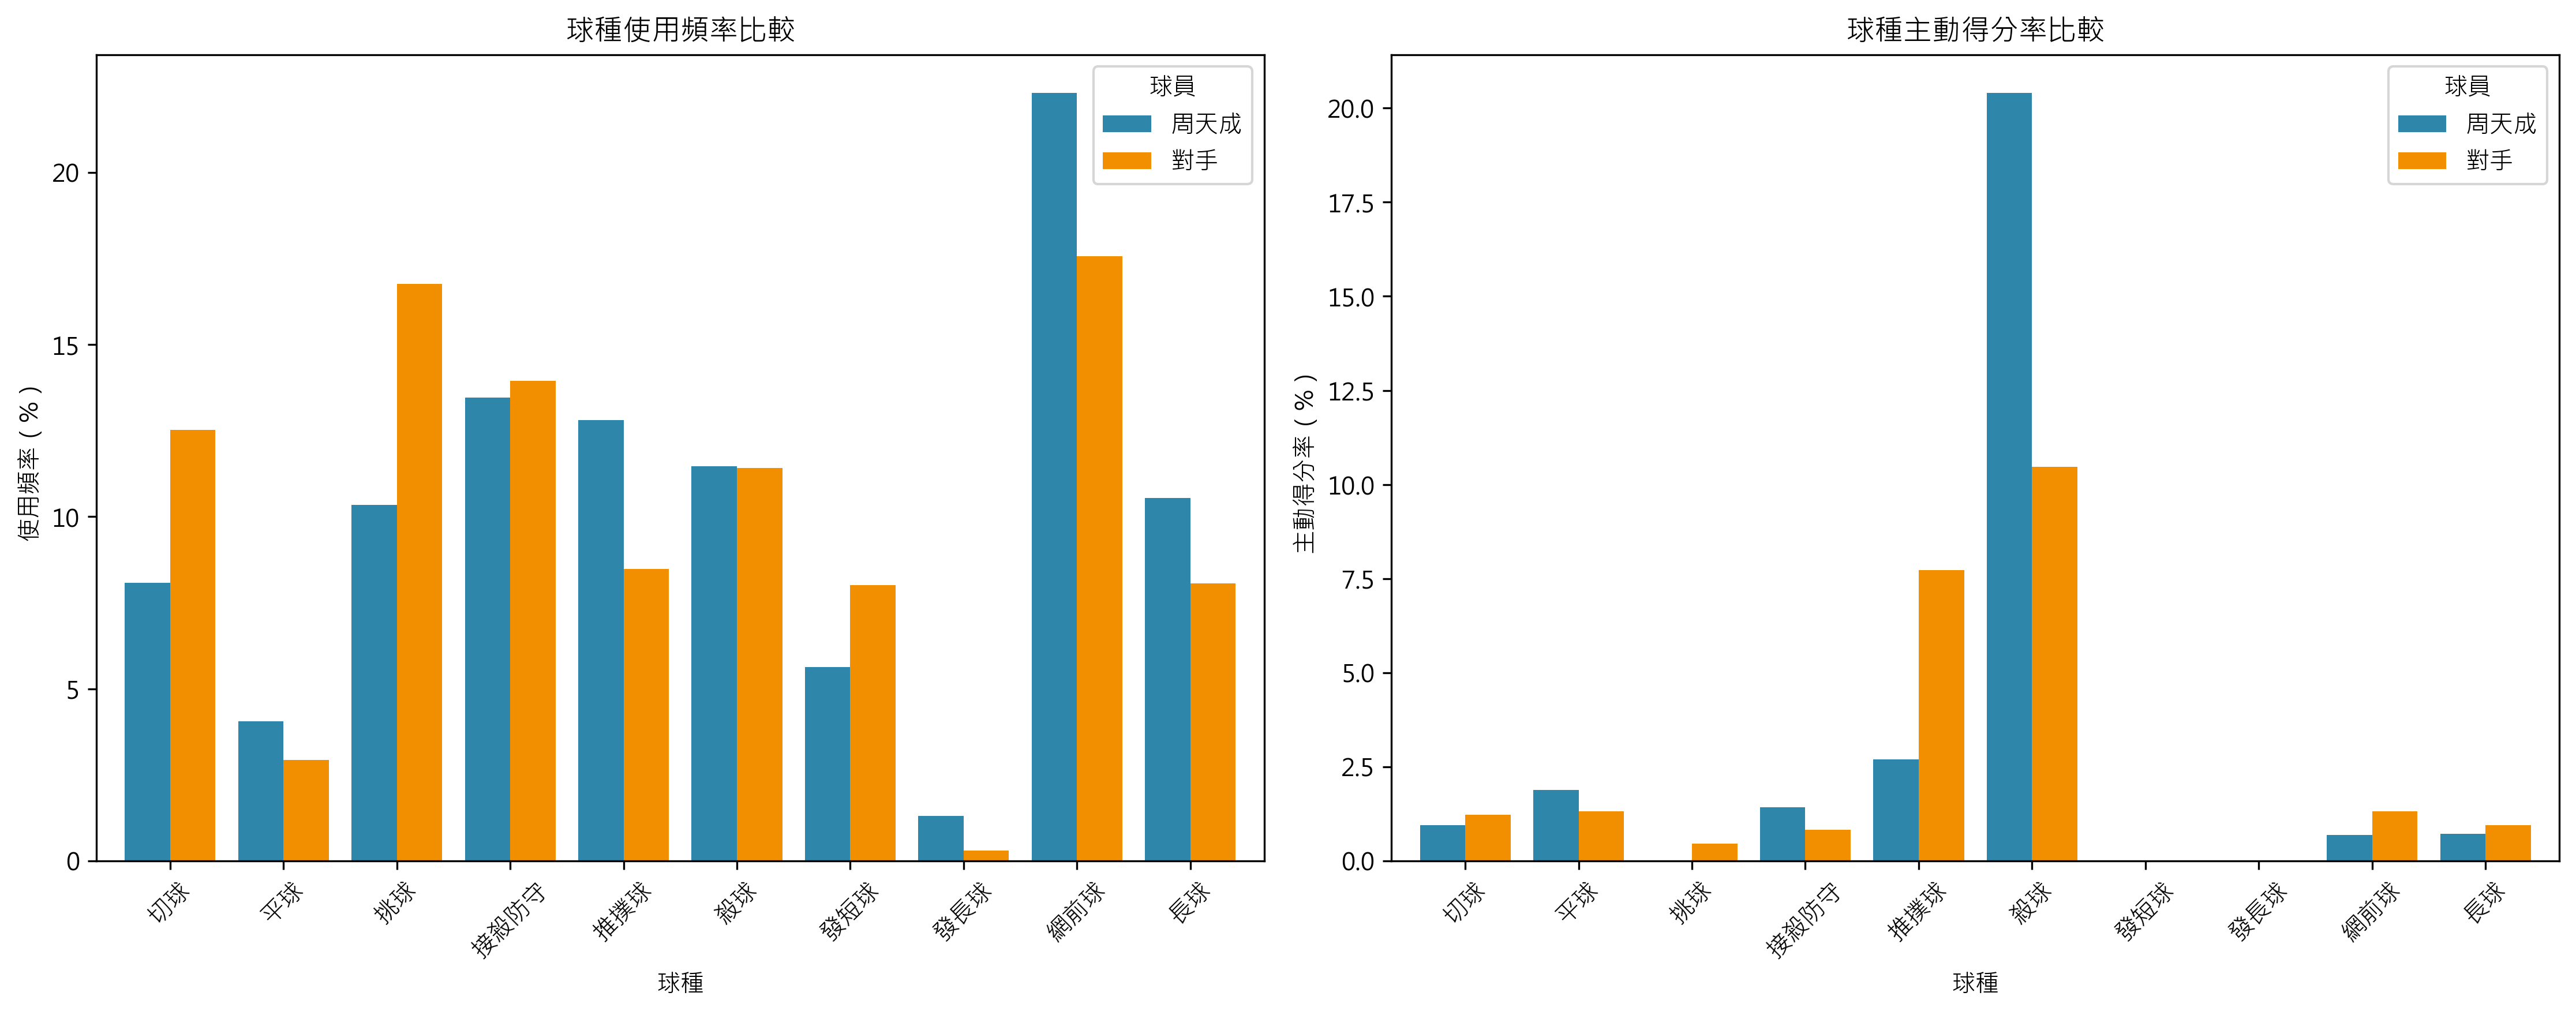

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'player', 'type', 'getpoint_player']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"缺少必要欄位：{missing_cols}")
elif len(df) == 0:
    print("資料為空，無法分析。")
else:
    data = df[required_cols].copy()

    chou_name = 'CHOU Tien Chen'
    opponent_names = [
        name for name in data['player'].dropna().unique()
        if name != chou_name
    ]

    if chou_name not in data['player'].dropna().unique():
        print("資料中找不到周天成（CHOU Tien Chen）。")
    elif len(opponent_names) == 0:
        print("資料中找不到周天成的對手。")
    else:
        opponent_name = opponent_names[0]

        analysis_df = data[
            data['player'].isin([chou_name, opponent_name]) &
            data['type'].notna()
        ].copy()

        if len(analysis_df) == 0:
            print("沒有可用的球種資料。")
        else:
            analysis_df['球員'] = analysis_df['player'].map({
                chou_name: '周天成',
                opponent_name: '對手'
            })
            analysis_df['主動得分'] = (
                analysis_df['player'] == analysis_df['getpoint_player']
            )

            total_shots = (
                analysis_df
                .groupby('球員', observed=True)
                .size()
                .rename('總擊球數')
            )

            summary = (
                analysis_df
                .groupby(['球員', 'type'], observed=True)
                .agg(
                    使用次數=('type', 'size'),
                    主動得分次數=('主動得分', 'sum')
                )
                .reset_index()
            )

            summary['總擊球數'] = summary['球員'].map(total_shots)
            summary['使用頻率'] = (
                summary['使用次數'] / summary['總擊球數'] * 100
            )
            summary['主動得分率'] = (
                summary['主動得分次數'] / summary['使用次數'] * 100
            )

            summary = summary.sort_values(
                ['type', '球員']
            ).reset_index(drop=True)

            output = summary[
                [
                    '球員', 'type', '使用次數', '總擊球數',
                    '使用頻率', '主動得分次數', '主動得分率'
                ]
            ].copy()

            output = output.rename(columns={'type': '球種'})
            output['使用頻率'] = output['使用頻率'].round(2)
            output['主動得分率'] = output['主動得分率'].round(2)

            print("統計口徑：")
            print("1. 使用頻率 = 該球員使用該球種的擊球數 ÷ 該球員總擊球數。")
            print("2. 主動得分率 = 該球種主動得分數 ÷ 該球種使用次數。")
            print("3. 主動得分須同時符合 player == getpoint_player；未記錄得分者的球不列為主動得分。")
            print("\n周天成與對手的球種使用頻率及主動得分率：")
            print(output.to_string(index=False))

            plot_df = summary.copy()
            plot_df['球種'] = plot_df['type'].astype(str)

            frequency_df = plot_df.pivot(
                index='球種',
                columns='球員',
                values='使用頻率'
            ).fillna(0)

            scoring_df = plot_df.pivot(
                index='球種',
                columns='球員',
                values='主動得分率'
            ).fillna(0)

            ordered_types = sorted(
                plot_df['球種'].unique(),
                key=lambda x: list(plot_df['球種'].unique()).index(x)
            )
            frequency_df = frequency_df.reindex(ordered_types)
            scoring_df = scoring_df.reindex(ordered_types)

            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            frequency_df.plot(
                kind='bar',
                ax=axes[0],
                color=['#2E86AB', '#F18F01'],
                width=0.8
            )
            axes[0].set_title('球種使用頻率比較')
            axes[0].set_xlabel('球種')
            axes[0].set_ylabel('使用頻率（%）')
            axes[0].tick_params(axis='x', rotation=45)
            axes[0].legend(title='球員')

            scoring_df.plot(
                kind='bar',
                ax=axes[1],
                color=['#2E86AB', '#F18F01'],
                width=0.8
            )
            axes[1].set_title('球種主動得分率比較')
            axes[1].set_xlabel('球種')
            axes[1].set_ylabel('主動得分率（%）')
            axes[1].tick_params(axis='x', rotation=45)
            axes[1].legend(title='球員')

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 50
**問題**: 分析周天成接發球策略：長球、網前球、平球的比例與得分影響。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
1. 接發球定義為：周天成的擊球，且前一拍為同回合對手的發球（server=1）。
2. 使用比例分母為三種指定接發球策略的總使用次數。
3. 得分率、主動得分與被動得分均以回合得分者為判定基準；失分代表對手贏得該回合。
4. 淨得分影響 = 周天成得分回合數 - 對手得分回合數。

接發球策略使用比例與得分影響：
 策略  使用次數  使用比例(%)  有效得分回合數  周天成得分回合  得分率(%)  主動得分回合  被動得分回合  直接主動得分回合  對手得分回合  淨得分影響
 長球     5     5.21        5        3   60.00       1       2         0       2      1
網前球    87    90.62       87       44   50.57      17      27         0      43      1
 平球     4     4.17        4        1   25.00       1       0         0       3     -2


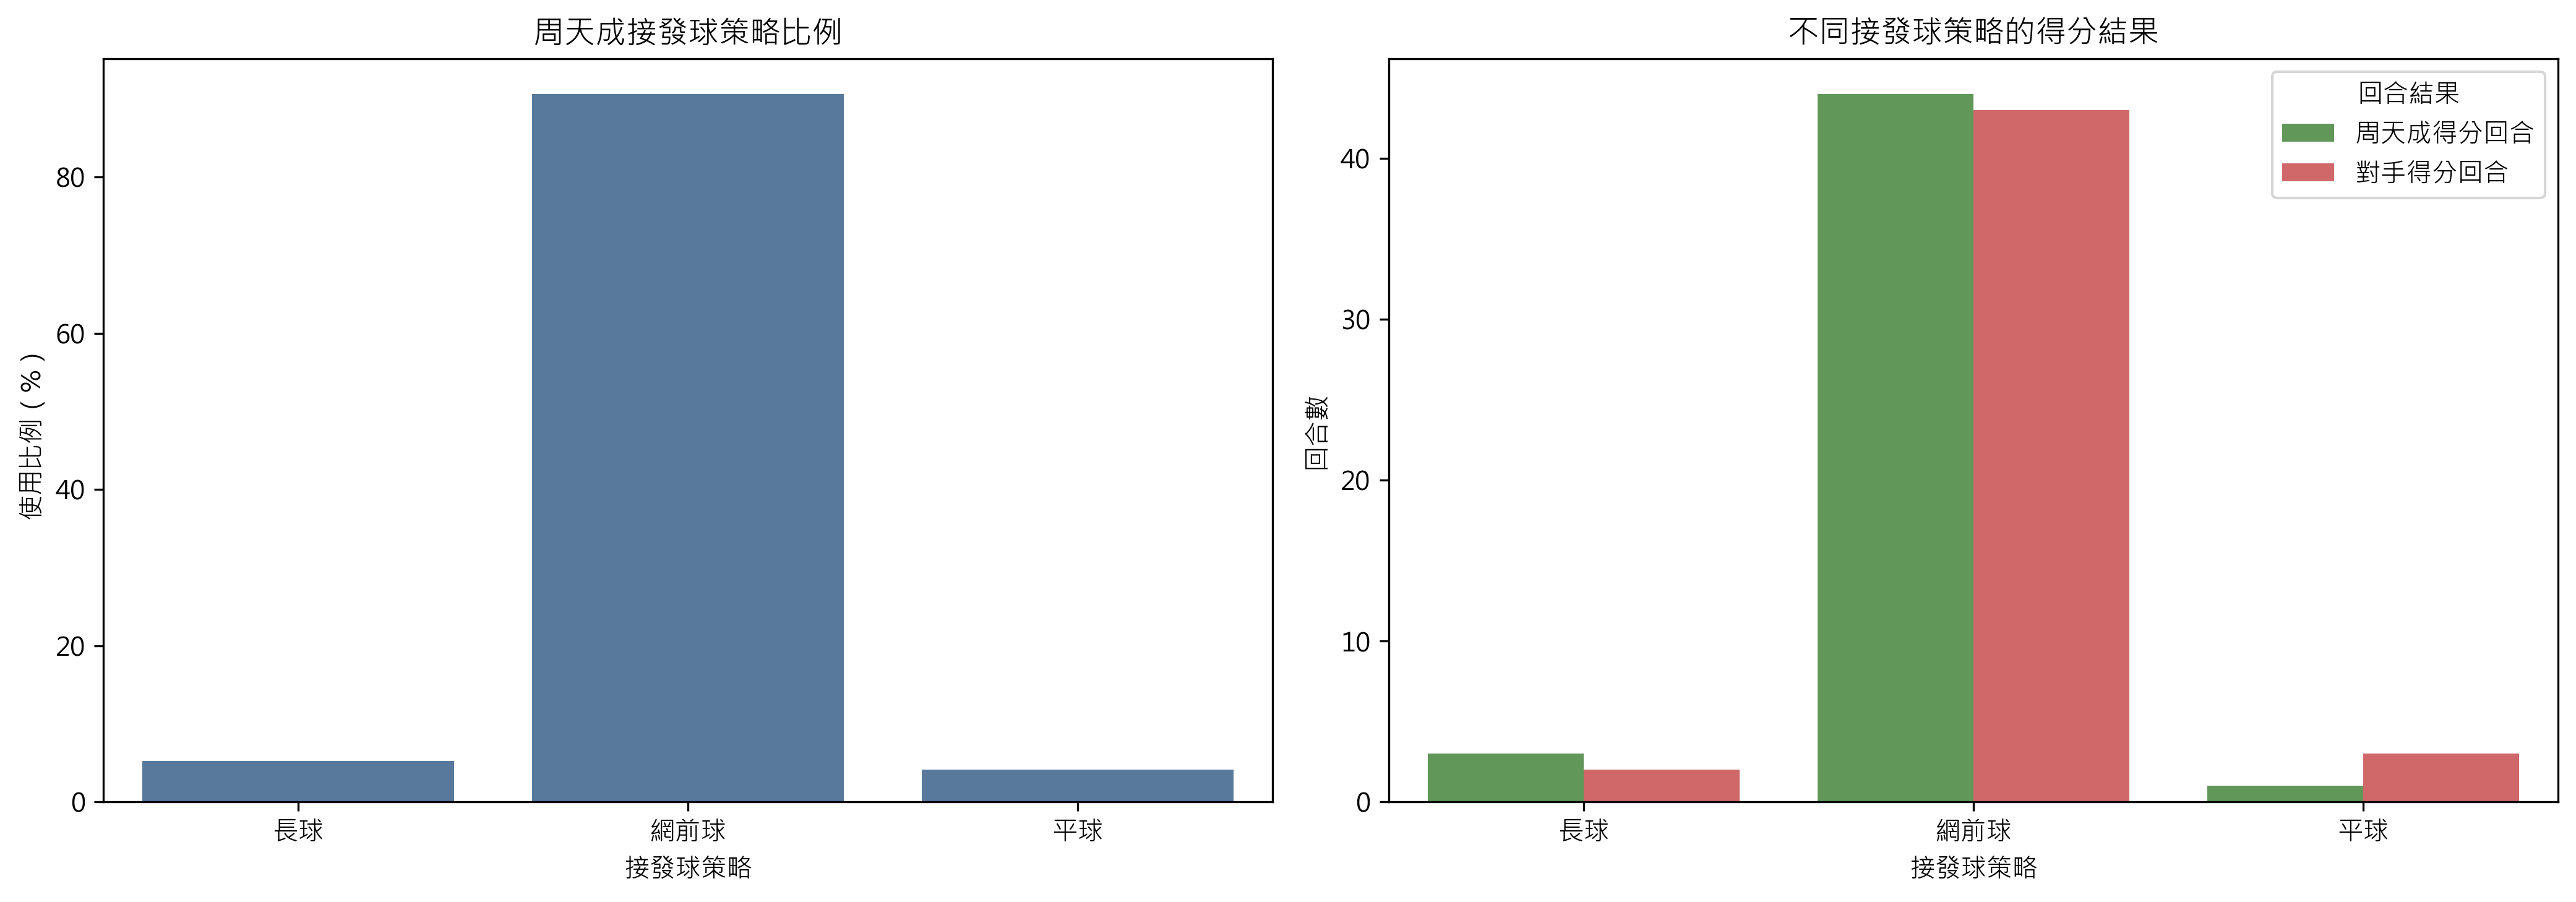

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'server', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法分析。')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.text(0.5, 0.5, '資料為空', ha='center', va='center')
    ax.axis('off')
    plt.tight_layout()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, '缺少必要欄位', ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()
    else:
        group_cols = ['match_id', 'set', 'rally']
        player_name = 'CHOU Tien Chen'

        work = df.sort_values(
            group_cols + ['ball_round'],
            kind='mergesort'
        ).copy()

        grouped = work.groupby(group_cols, sort=False)

        work['prev_player'] = grouped['player'].shift(1)
        work['prev_type'] = grouped['type'].shift(1)
        work['prev_server'] = grouped['server'].shift(1)

        work['rally_winner'] = grouped['getpoint_player'].transform('last')
        work['final_player'] = grouped['player'].transform('last')
        work['final_ball_round'] = grouped['ball_round'].transform('max')

        receive_types = ['長球', '網前球', '平球']

        receive_df = work[
            (work['player'] == player_name) &
            (work['prev_player'] == work['opponent']) &
            (work['prev_server'] == 1) &
            (work['prev_type'].isin(['發短球', '發長球'])) &
            (work['type'].isin(receive_types))
        ].copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        if len(receive_df) == 0:
            print('找不到周天成接發球後使用長球、網前球或平球的資料。')
            for ax in axes:
                ax.text(0.5, 0.5, '無符合資料', ha='center', va='center')
                ax.axis('off')
            plt.tight_layout()
        else:
            receive_df['策略'] = receive_df['type']

            total_attempts = len(receive_df)
            usage = (
                receive_df['策略']
                .value_counts()
                .reindex(receive_types, fill_value=0)
                .rename('使用次數')
                .to_frame()
            )
            usage['使用比例(%)'] = usage['使用次數'] / total_attempts * 100

            scored_df = receive_df[
                receive_df['rally_winner'].notna()
            ].copy()

            scored_df['結果'] = scored_df['rally_winner'].map({
                player_name: '周天成得分',
                scored_df['opponent'].iloc[0] if len(scored_df) > 0 else '':
                    '對手得分'
            })

            scored_df['結果'] = scored_df.apply(
                lambda row: (
                    '周天成得分'
                    if row['rally_winner'] == player_name
                    else '對手得分'
                    if row['rally_winner'] == row['opponent']
                    else '其他'
                ),
                axis=1
            )

            scored_df['主動得分'] = (
                (scored_df['rally_winner'] == player_name) &
                (scored_df['final_player'] == player_name)
            )

            scored_df['被動得分'] = (
                (scored_df['rally_winner'] == player_name) &
                (scored_df['final_player'] == scored_df['opponent'])
            )

            scored_df['直接主動得分'] = (
                scored_df['主動得分'] &
                (scored_df['ball_round'] == scored_df['final_ball_round'])
            )

            outcome_rows = []
            for strategy in receive_types:
                strategy_df = scored_df[scored_df['策略'] == strategy]
                attempts = len(receive_df[receive_df['策略'] == strategy])
                valid_rallies = len(strategy_df)
                wins = (strategy_df['結果'] == '周天成得分').sum()
                losses = (strategy_df['結果'] == '對手得分').sum()
                active_wins = strategy_df['主動得分'].sum()
                passive_wins = strategy_df['被動得分'].sum()
                direct_active_wins = strategy_df['直接主動得分'].sum()

                outcome_rows.append({
                    '策略': strategy,
                    '使用次數': attempts,
                    '使用比例(%)': attempts / total_attempts * 100,
                    '有效得分回合數': valid_rallies,
                    '周天成得分回合': wins,
                    '得分率(%)': wins / valid_rallies * 100
                    if valid_rallies > 0 else 0,
                    '主動得分回合': int(active_wins),
                    '被動得分回合': int(passive_wins),
                    '直接主動得分回合': int(direct_active_wins),
                    '對手得分回合': int(losses),
                    '淨得分影響': int(wins - losses)
                })

            result = pd.DataFrame(outcome_rows)

            print('統計口徑：')
            print('1. 接發球定義為：周天成的擊球，且前一拍為同回合對手的發球（server=1）。')
            print('2. 使用比例分母為三種指定接發球策略的總使用次數。')
            print('3. 得分率、主動得分與被動得分均以回合得分者為判定基準；失分代表對手贏得該回合。')
            print('4. 淨得分影響 = 周天成得分回合數 - 對手得分回合數。')
            print()
            print('接發球策略使用比例與得分影響：')
            print(result.round(2).to_string(index=False))

            usage_plot = usage.reset_index()
            sns.barplot(
                data=usage_plot,
                x='策略',
                y='使用比例(%)',
                order=receive_types,
                color='#4C78A8',
                ax=axes[0]
            )
            axes[0].set_title('周天成接發球策略比例')
            axes[0].set_xlabel('接發球策略')
            axes[0].set_ylabel('使用比例（%）')

            outcome_plot = result.melt(
                id_vars='策略',
                value_vars=['周天成得分回合', '對手得分回合'],
                var_name='結果',
                value_name='回合數'
            )

            sns.barplot(
                data=outcome_plot,
                x='策略',
                y='回合數',
                hue='結果',
                order=receive_types,
                hue_order=['周天成得分回合', '對手得分回合'],
                palette={
                    '周天成得分回合': '#59A14F',
                    '對手得分回合': '#E15759'
                },
                ax=axes[1]
            )
            axes[1].set_title('不同接發球策略的得分結果')
            axes[1].set_xlabel('接發球策略')
            axes[1].set_ylabel('回合數')
            axes[1].legend(title='回合結果')

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 51
**問題**: 分析對手殺球到前中後排後，周天成分別會怎麼去反擊？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


對手殺球後由周天成接續反擊的樣本數：248

各落點排別的反擊球種次數：
next_type  平球  接殺防守  推撲球  殺球  網前球
殺球落點區域                           
前排          0     1    0   0    1
中排          6   215    2   1   22
後排          0     0    0   0    0

各落點排別的反擊球種比例（%）：
next_type    平球  接殺防守   推撲球    殺球    網前球
殺球落點區域                                  
前排         0.00  50.0  0.00  0.00  50.00
中排         2.44  87.4  0.81  0.41   8.94
後排          NaN   NaN   NaN   NaN    NaN

各落點排別的主要反擊方式：
        樣本數 最常使用反擊  比例（%）
殺球落點區域                   
前排        2   接殺防守   50.0
…（輸出已截斷；notebook 僅保留重點）


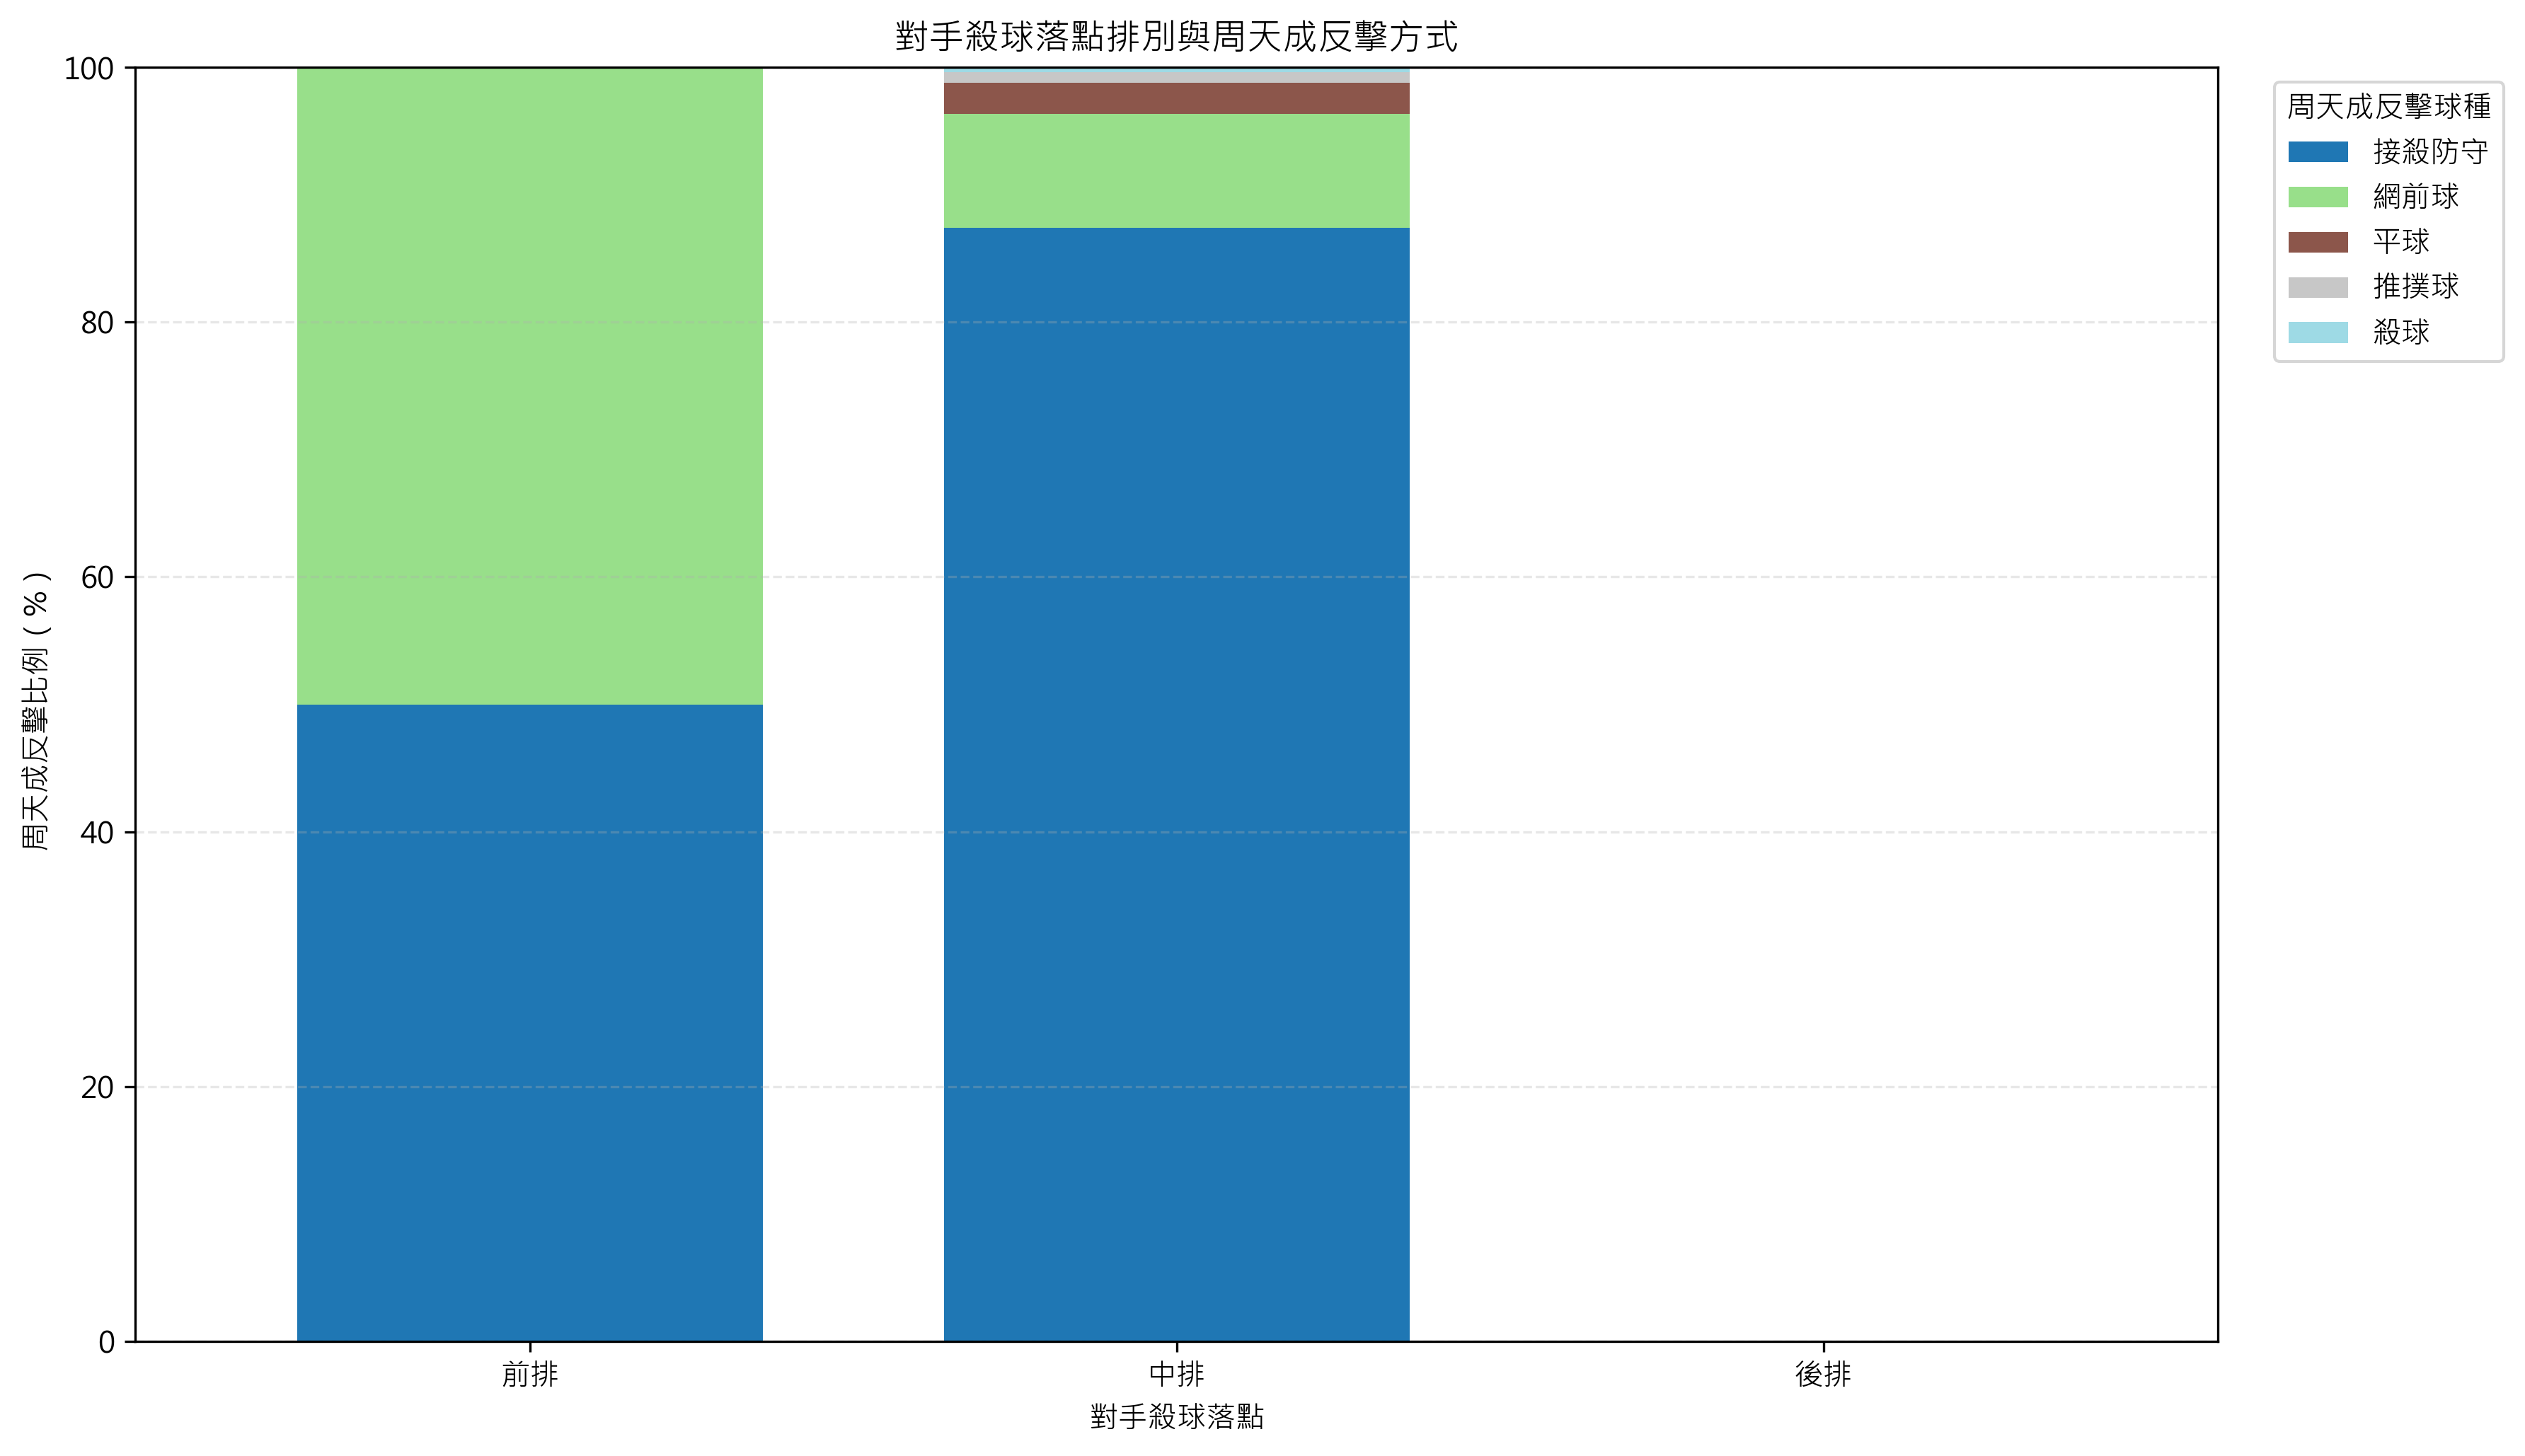

In [ ]:
required_cols = {
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'landing_area'
}

fig, ax = plt.subplots(figsize=(12, 7))

if len(df) == 0:
    print("資料為空，無法進行分析。")
elif not required_cols.issubset(df.columns):
    print(f"缺少必要欄位：{sorted(required_cols - set(df.columns))}")
else:
    chou = 'CHOU Tien Chen'
    opponent = 'Kento MOMOTA'

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_group = work.groupby(
        ['match_id', 'set', 'rally'],
        sort=False
    )

    work['next_player'] = rally_group['player'].shift(-1)
    work['next_type'] = rally_group['type'].shift(-1)
    work['next_ball_round'] = rally_group['ball_round'].shift(-1)

    def court_category(zone):
        if pd.isna(zone):
            return pd.NA
        zone = int(zone)
        if zone in range(17, 25):
            return '前排'
        if zone in range(5, 17):
            return '中排'
        if zone in range(1, 5):
            return '後排'
        return '場外'

    smash = work[
        (work['player'] == opponent) &
        (work['type'] == '殺球') &
        (work['next_player'] == chou) &
        (work['next_ball_round'] == work['ball_round'] + 1)
    ].copy()

    smash['殺球落點區域'] = smash['landing_area'].map(court_category)

    response = smash[
        smash['殺球落點區域'].isin(['前排', '中排', '後排'])
    ].dropna(subset=['殺球落點區域', 'next_type'])

    category_order = ['前排', '中排', '後排']

    if len(response) == 0:
        print("找不到對手殺球後由周天成在同一回合接續反擊的有效資料。")
        ax.set_title('對手殺球落點與周天成反擊')
        ax.axis('off')
    else:
        count_table = pd.crosstab(
            response['殺球落點區域'],
            response['next_type']
        ).reindex(category_order, fill_value=0)

        percent_table = (
            count_table.div(count_table.sum(axis=1), axis=0)
            .mul(100)
            .round(2)
        )

        print(f"對手殺球後由周天成接續反擊的樣本數：{len(response)}")
        print("\n各落點排別的反擊球種次數：")
        print(count_table)

        print("\n各落點排別的反擊球種比例（%）：")
        print(percent_table)

        print("\n各落點排別的主要反擊方式：")
        summary = pd.DataFrame({
            '樣本數': count_table.sum(axis=1),
            '最常使用反擊': count_table.idxmax(axis=1),
            '比例（%）': percent_table.max(axis=1)
        })
        print(summary)

        plot_table = percent_table.loc[:, percent_table.sum(axis=0).sort_values(ascending=False).index]
        plot_table.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            colormap='tab20',
            width=0.72
        )

        ax.set_title('對手殺球落點排別與周天成反擊方式')
        ax.set_xlabel('對手殺球落點')
        ax.set_ylabel('周天成反擊比例（%）')
        ax.set_xticklabels(category_order, rotation=0)
        ax.legend(
            title='周天成反擊球種',
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 60
**問題**: 分析周天成在自己失分回合中，最後一拍前一拍最常使用的球種。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成失分回合數：217
有可辨識前一拍球種的回合數：217
最後一拍前一拍最常使用的球種：網前球，次數：52，比例：23.96%

各球種統計：
前一拍球種  次數  比例(%)
  網前球  52  23.96
   殺球  37  17.05
   挑球  30  13.82
 接殺防守  25  11.52
   長球  21   9.68
  推撲球  18   8.29
   切球  15   6.91
   平球  10   4.61
  發短球   6   2.76
  發長球   3   1.38


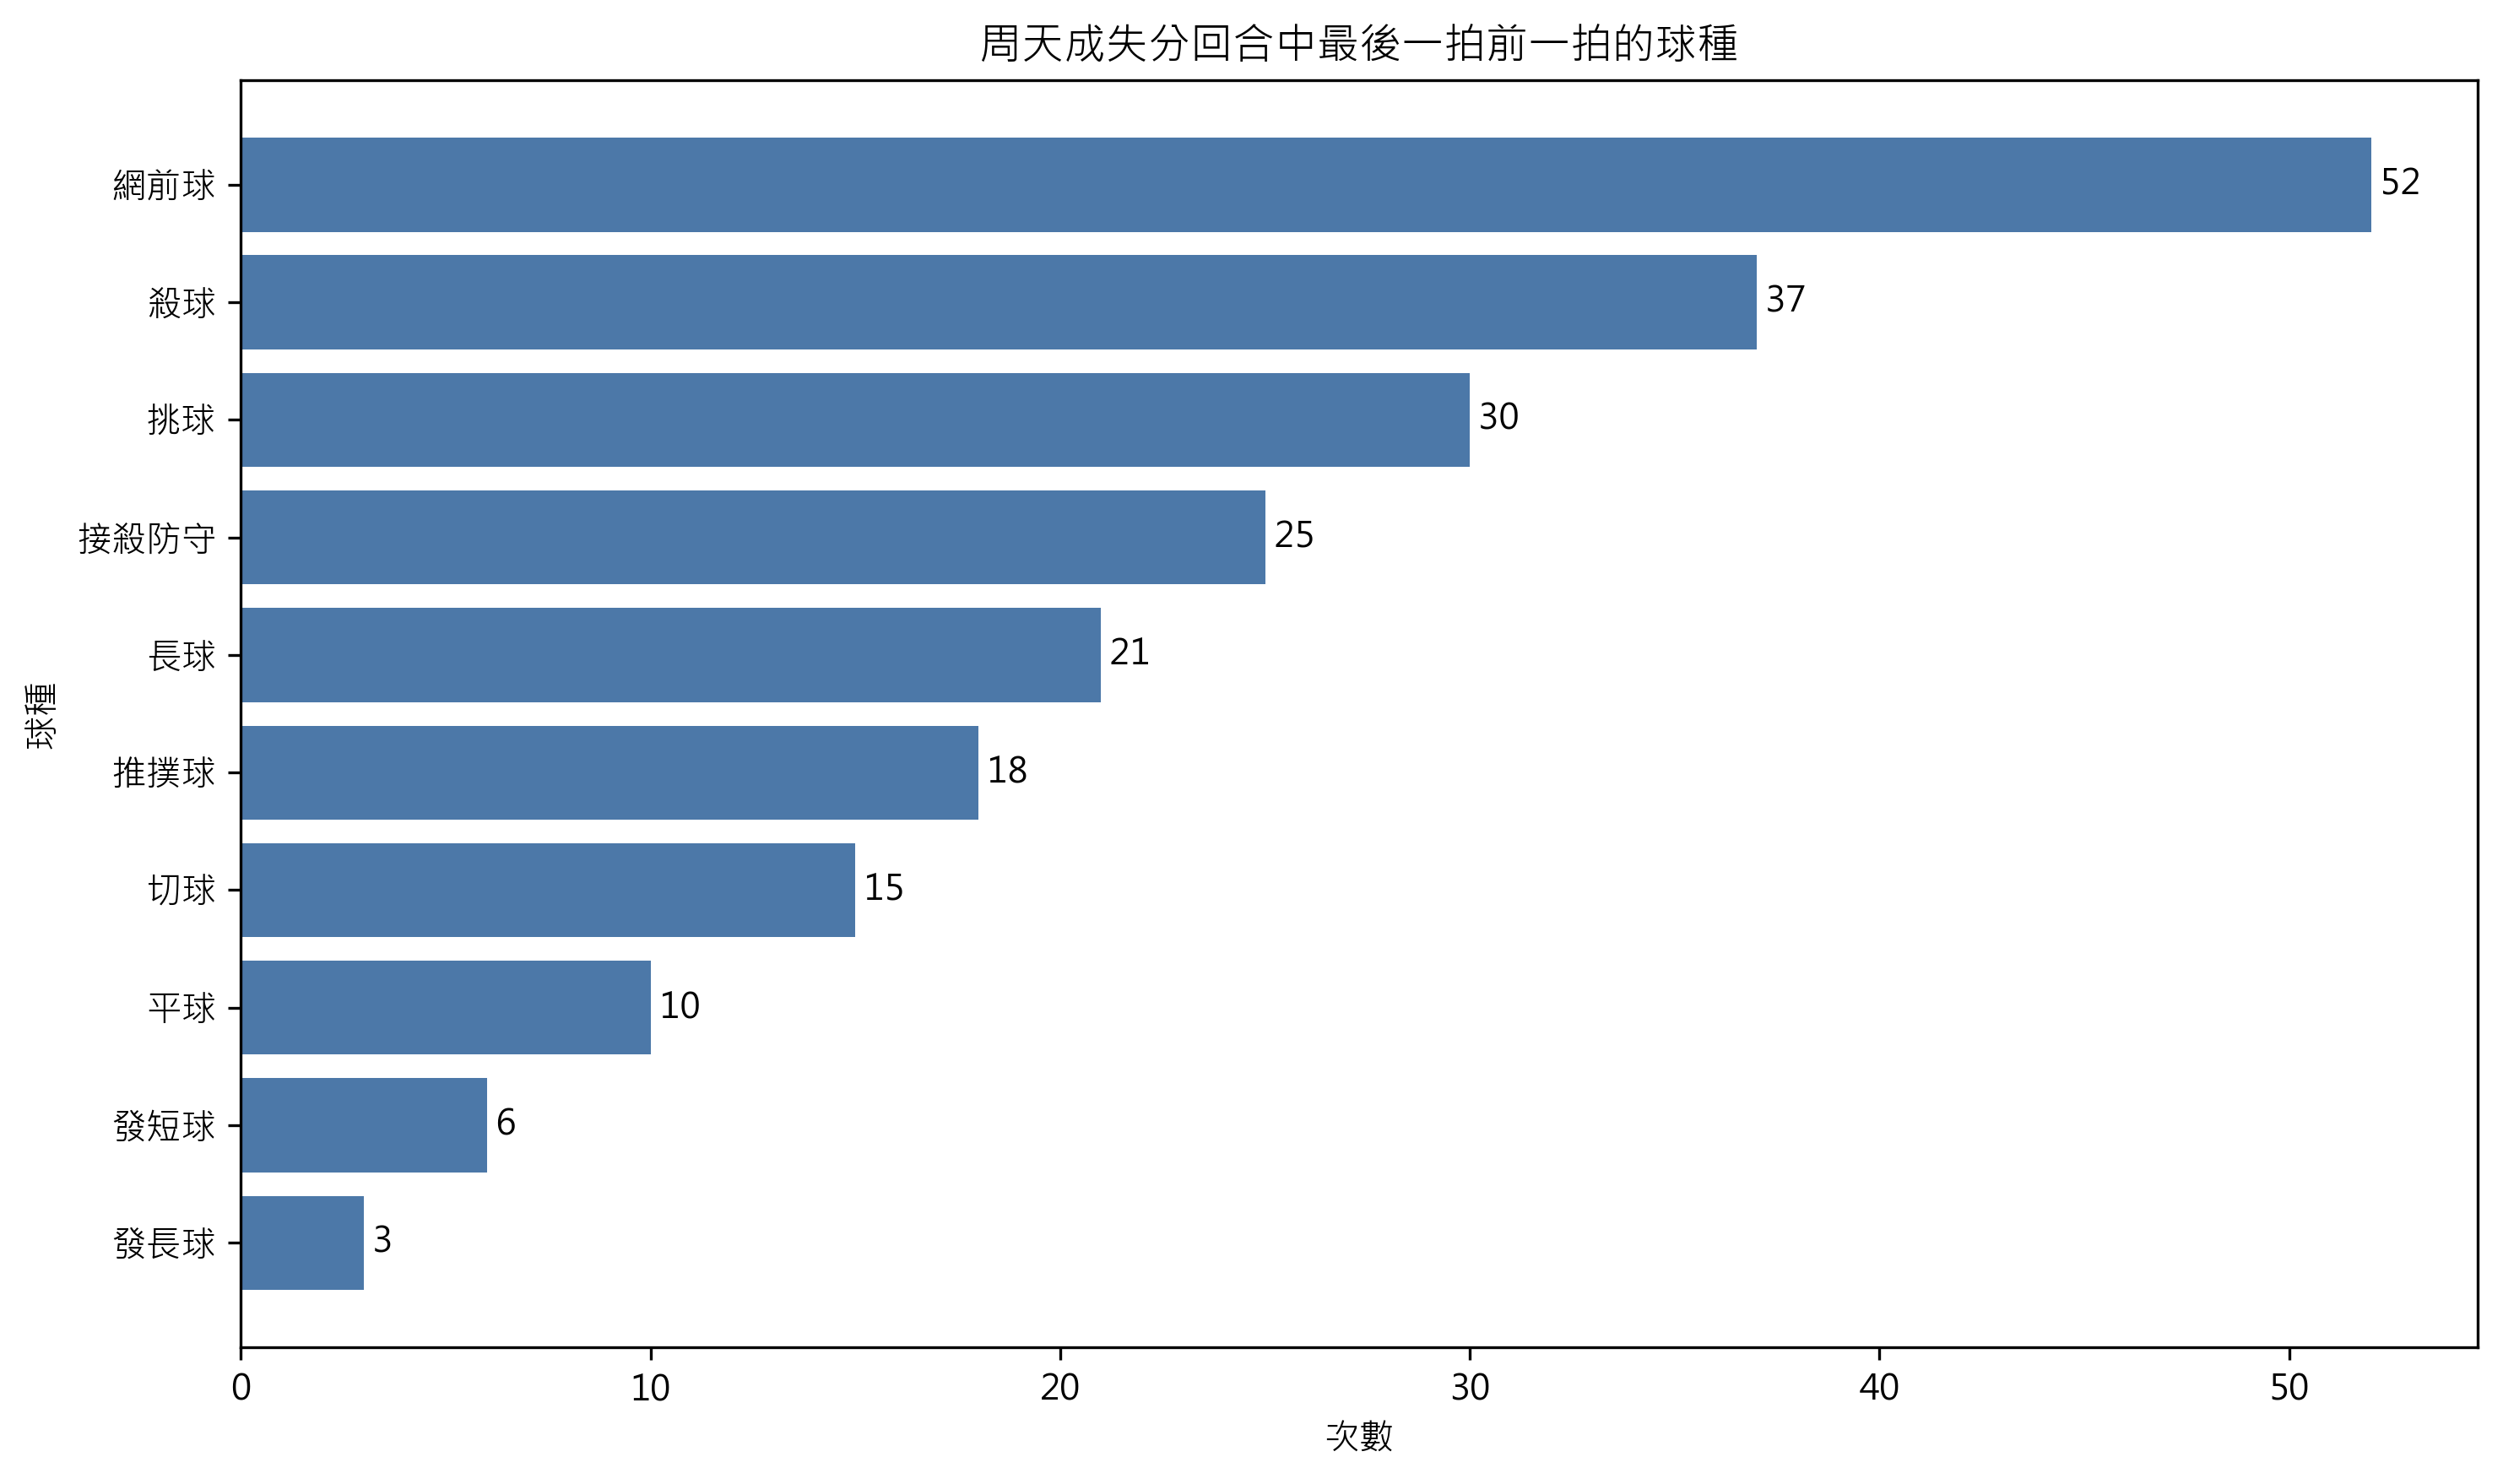

In [ ]:
keys = ['match_id', 'set', 'rally']
target_player = 'CHOU Tien Chen'
opponent_player = 'Kento MOMOTA'

fig, ax = plt.subplots(figsize=(10, 6))

if len(df) == 0:
    print('資料為空，無法分析。')
else:
    work = df.sort_values(keys + ['ball_round']).copy()

    grouped = work.groupby(keys, sort=False)
    work['_prev_type'] = grouped['type'].shift(1)
    work['_prev_player'] = grouped['player'].shift(1)
    work['_is_last_shot'] = grouped.cumcount(ascending=False).eq(0)

    losing_last_shots = work[
        work['_is_last_shot']
        & work['getpoint_player'].eq(opponent_player)
    ].copy()

    valid_previous = losing_last_shots[
        losing_last_shots['_prev_type'].notna()
    ].copy()

    if len(valid_previous) == 0:
        print('找不到周天成失分回合中可辨識的最後一拍前一拍球種。')
    else:
        type_counts = (
            valid_previous['_prev_type']
            .astype(str)
            .value_counts()
            .rename_axis('前一拍球種')
            .reset_index(name='次數')
        )
        type_counts['比例(%)'] = (
            type_counts['次數'] / type_counts['次數'].sum() * 100
        ).round(2)

        most_common = type_counts.iloc[0]

        print(f'周天成失分回合數：{len(losing_last_shots)}')
        print(f'有可辨識前一拍球種的回合數：{len(valid_previous)}')
        print(
            f"最後一拍前一拍最常使用的球種：{most_common['前一拍球種']}，"
            f"次數：{int(most_common['次數'])}，"
            f"比例：{most_common['比例(%)']:.2f}%"
        )
        print('\n各球種統計：')
        print(type_counts.to_string(index=False))

        plot_data = type_counts.sort_values('次數', ascending=True)

        ax.barh(
            plot_data['前一拍球種'],
            plot_data['次數'],
            color='#4C78A8'
        )
        ax.set_title('周天成失分回合中最後一拍前一拍的球種')
        ax.set_xlabel('次數')
        ax.set_ylabel('球種')

        for index, value in enumerate(plot_data['次數']):
            ax.text(value, index, f' {int(value)}', va='center')

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 61
**問題**: 在被對手四角拉吊得回合下，周天成勝率是多少？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `全欄位 (Fallback)`


對手四角拉吊回合數：63
周天成勝回合數：27
對手勝回合數：36
被對手四角拉吊得回合下，周天成勝率：42.86%


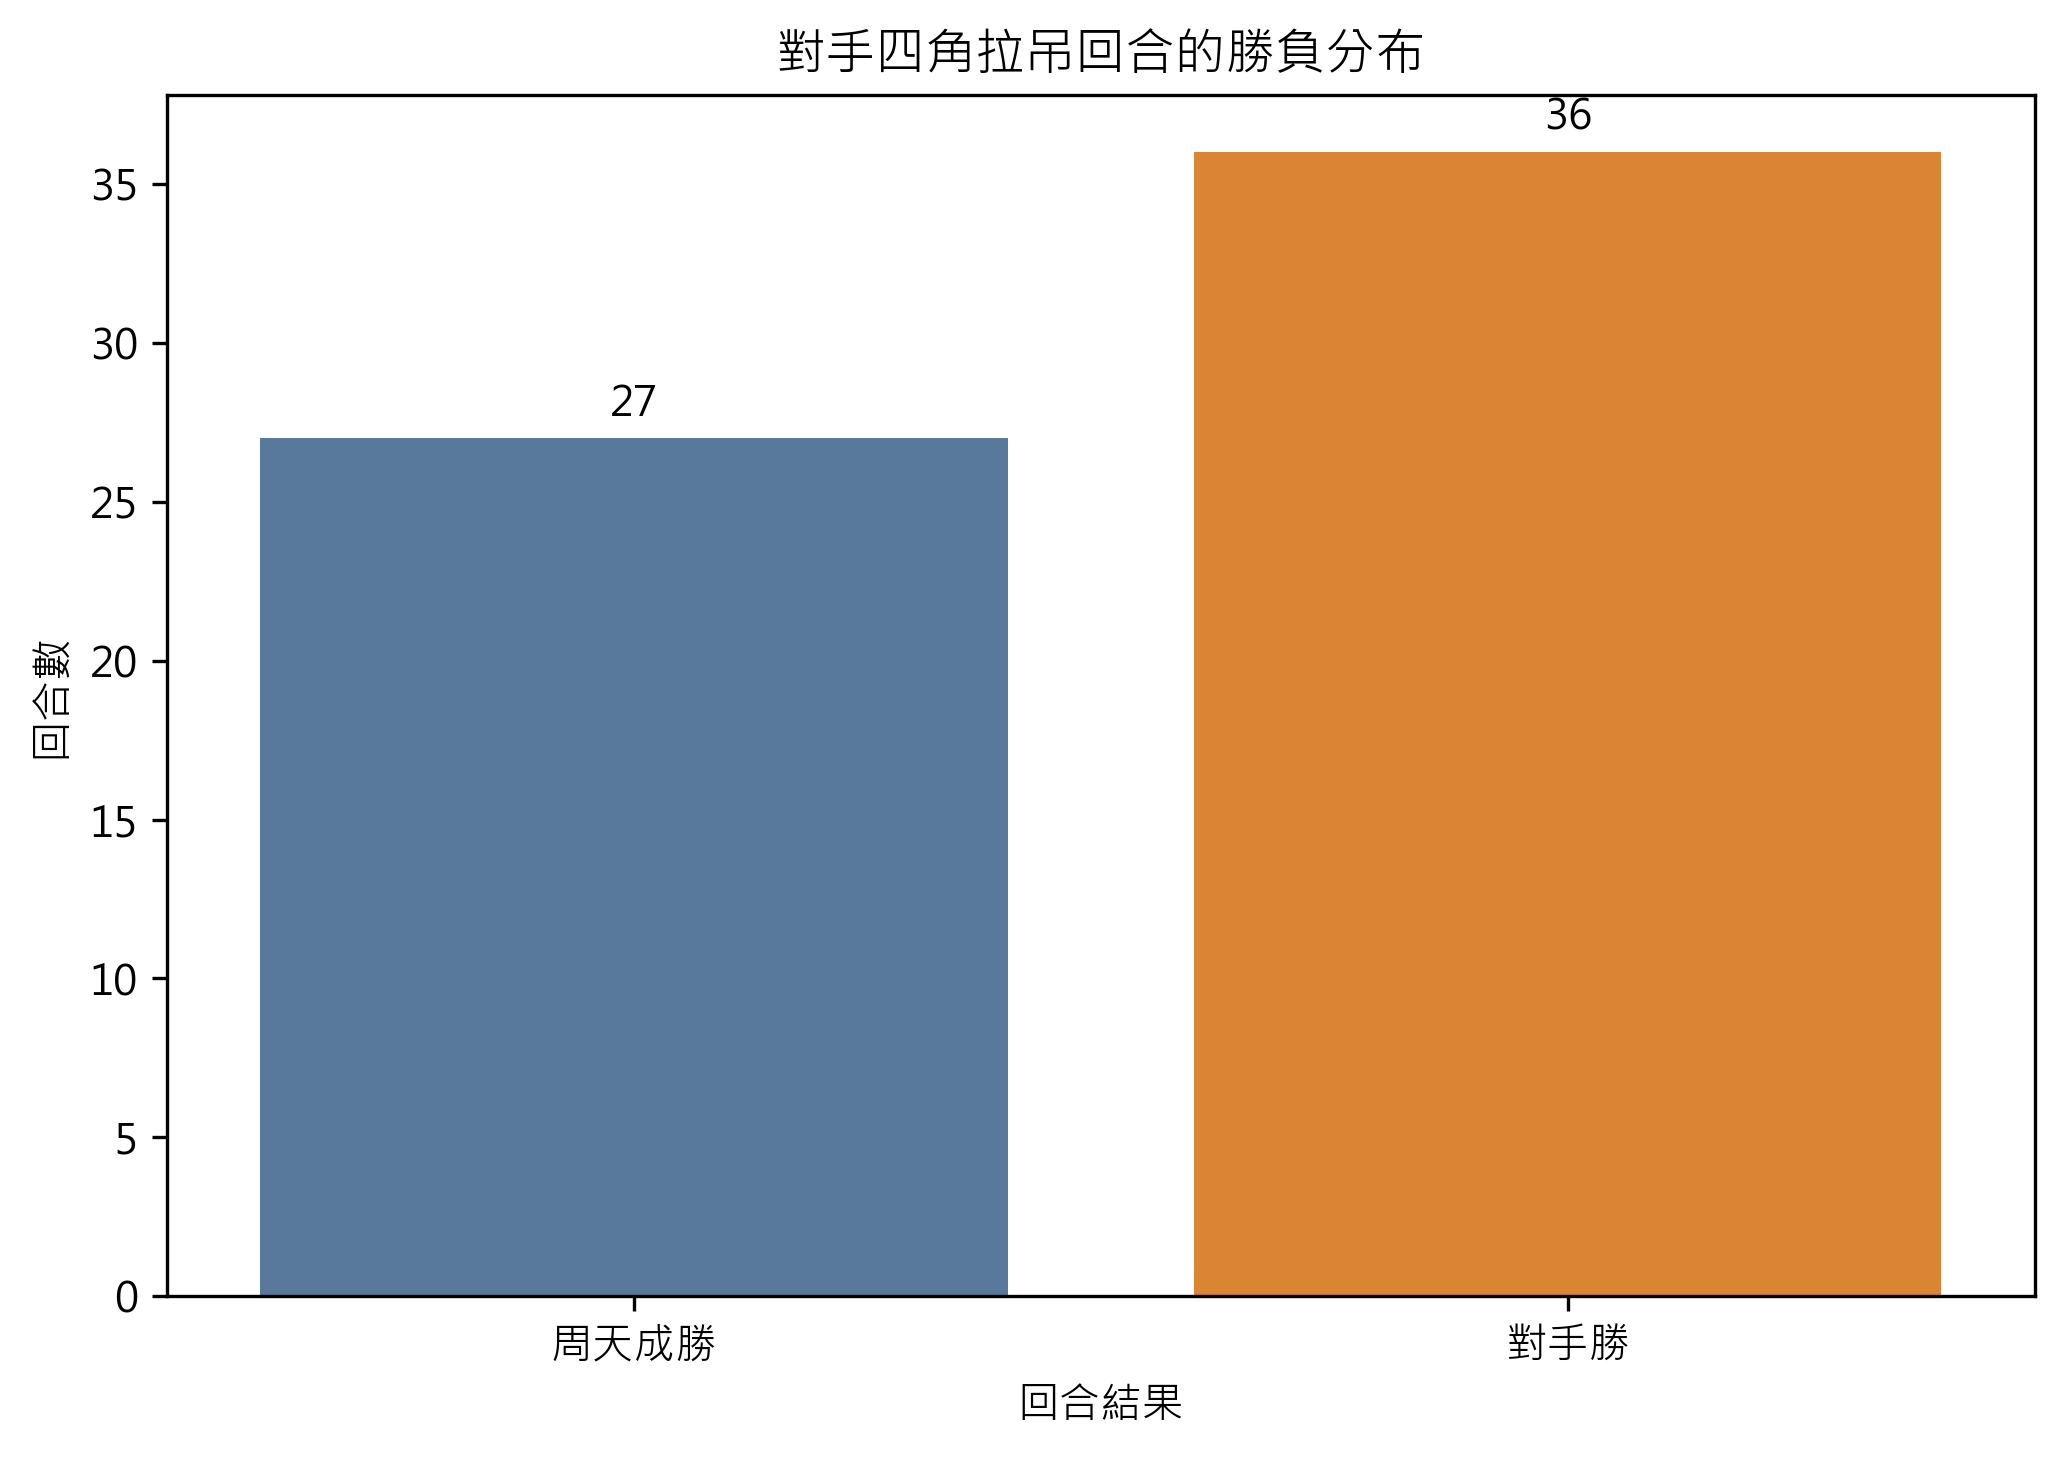

In [ ]:
if len(df) == 0:
    print("資料為空，無法計算。")
else:
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player",
        "hit_area", "getpoint_player"
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        target_player = "CHOU Tien Chen"
        opponent_player = "Kento MOMOTA"
        four_corners = {1, 4, 21, 24}
        rally_keys = ["match_id", "set", "rally"]

        work_df = df.sort_values(
            rally_keys + ["ball_round"],
            kind="mergesort"
        ).copy()

        grouped = work_df.groupby(rally_keys, sort=False)

        work_df["next2_player"] = grouped["player"].shift(-2)
        work_df["next2_hit_area"] = grouped["hit_area"].shift(-2)

        valid_pair = (
            (work_df["player"] == opponent_player) &
            (work_df["next2_player"] == opponent_player) &
            work_df["hit_area"].notna() &
            work_df["next2_hit_area"].notna() &
            work_df["hit_area"].isin(four_corners) &
            work_df["next2_hit_area"].isin(four_corners) &
            (work_df["hit_area"] != work_df["next2_hit_area"])
        )

        four_corner_rallies = (
            work_df.loc[valid_pair, rally_keys]
            .drop_duplicates()
        )

        rally_results = (
            work_df.groupby(rally_keys, sort=False)["getpoint_player"]
            .last()
            .dropna()
            .rename("winner")
            .reset_index()
        )

        qualifying_rallies = four_corner_rallies.merge(
            rally_results,
            on=rally_keys,
            how="inner"
        )

        total_qualifying = len(qualifying_rallies)
        chou_wins = int(
            (qualifying_rallies["winner"] == target_player).sum()
        )
        kento_wins = int(
            (qualifying_rallies["winner"] == opponent_player).sum()
        )

        chou_win_rate = (
            chou_wins / total_qualifying * 100
            if total_qualifying > 0 else float("nan")
        )

        print(f"對手四角拉吊回合數：{total_qualifying}")
        print(f"周天成勝回合數：{chou_wins}")
        print(f"對手勝回合數：{kento_wins}")
        print(
            f"被對手四角拉吊得回合下，周天成勝率："
            f"{chou_win_rate:.2f}%"
            if total_qualifying > 0
            else "被對手四角拉吊得回合下，沒有可計算的有效回合。"
        )

        if total_qualifying > 0:
            summary = pd.DataFrame({
                "結果": ["周天成勝", "對手勝"],
                "回合數": [chou_wins, kento_wins]
            })

            fig, ax = plt.subplots(figsize=(7, 5))
            sns.barplot(
                data=summary,
                x="結果",
                y="回合數",
                hue="結果",
                palette=["#4C78A8", "#F58518"],
                legend=False,
                ax=ax
            )
            ax.set_title("對手四角拉吊回合的勝負分布")
            ax.set_xlabel("回合結果")
            ax.set_ylabel("回合數")

            for container in ax.containers:
                ax.bar_label(container, fmt="%d", padding=3)

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 63
**問題**: 哪些球種組合是周天成最常使用的，反而讓對手主動攻擊？(可能是周天成連續打長球，讓對手抓時機殺球)
> **使用的資料欄位群組**: `全欄位 (Fallback)`


對手主動攻擊定義：對手下一拍球種為「殺球、推撲球或平球」。
統計單位：同一 match_id、set、rally 內，周天成擊球後對手的下一拍。

周天成球種→對手球種  組合次數  對手主動攻擊次數 對手主動攻擊比例  對手主動得分次數
   長球 → 殺球   102       102   100.0%        15
 網前球 → 推撲球    83        83   100.0%         9
   挑球 → 殺球    81        81   100.0%         7
  推撲球 → 殺球    76        76   100.0%         2
接殺防守 → 推撲球    55        55   100.0%         3
 發短球 → 推撲球    45        45   100.0%         0
  推撲球 → 平球    26        26   100.0%         0
  切球 → 推撲球    24        24   100.0%         4
  發長球 → 殺球    19        19   100.0%         3
   平球 → 平球    18        18   100.0%         1
 接殺防守 → 殺球    12        12   100.0%         2
 接殺防守 → 平球    11        11   100.0%         0
   挑球 → 平球     8         8   100.0%         0
  平球 → 推撲球     7         7   100.0%         0
   切球 → 平球     6         6   100.0%         0


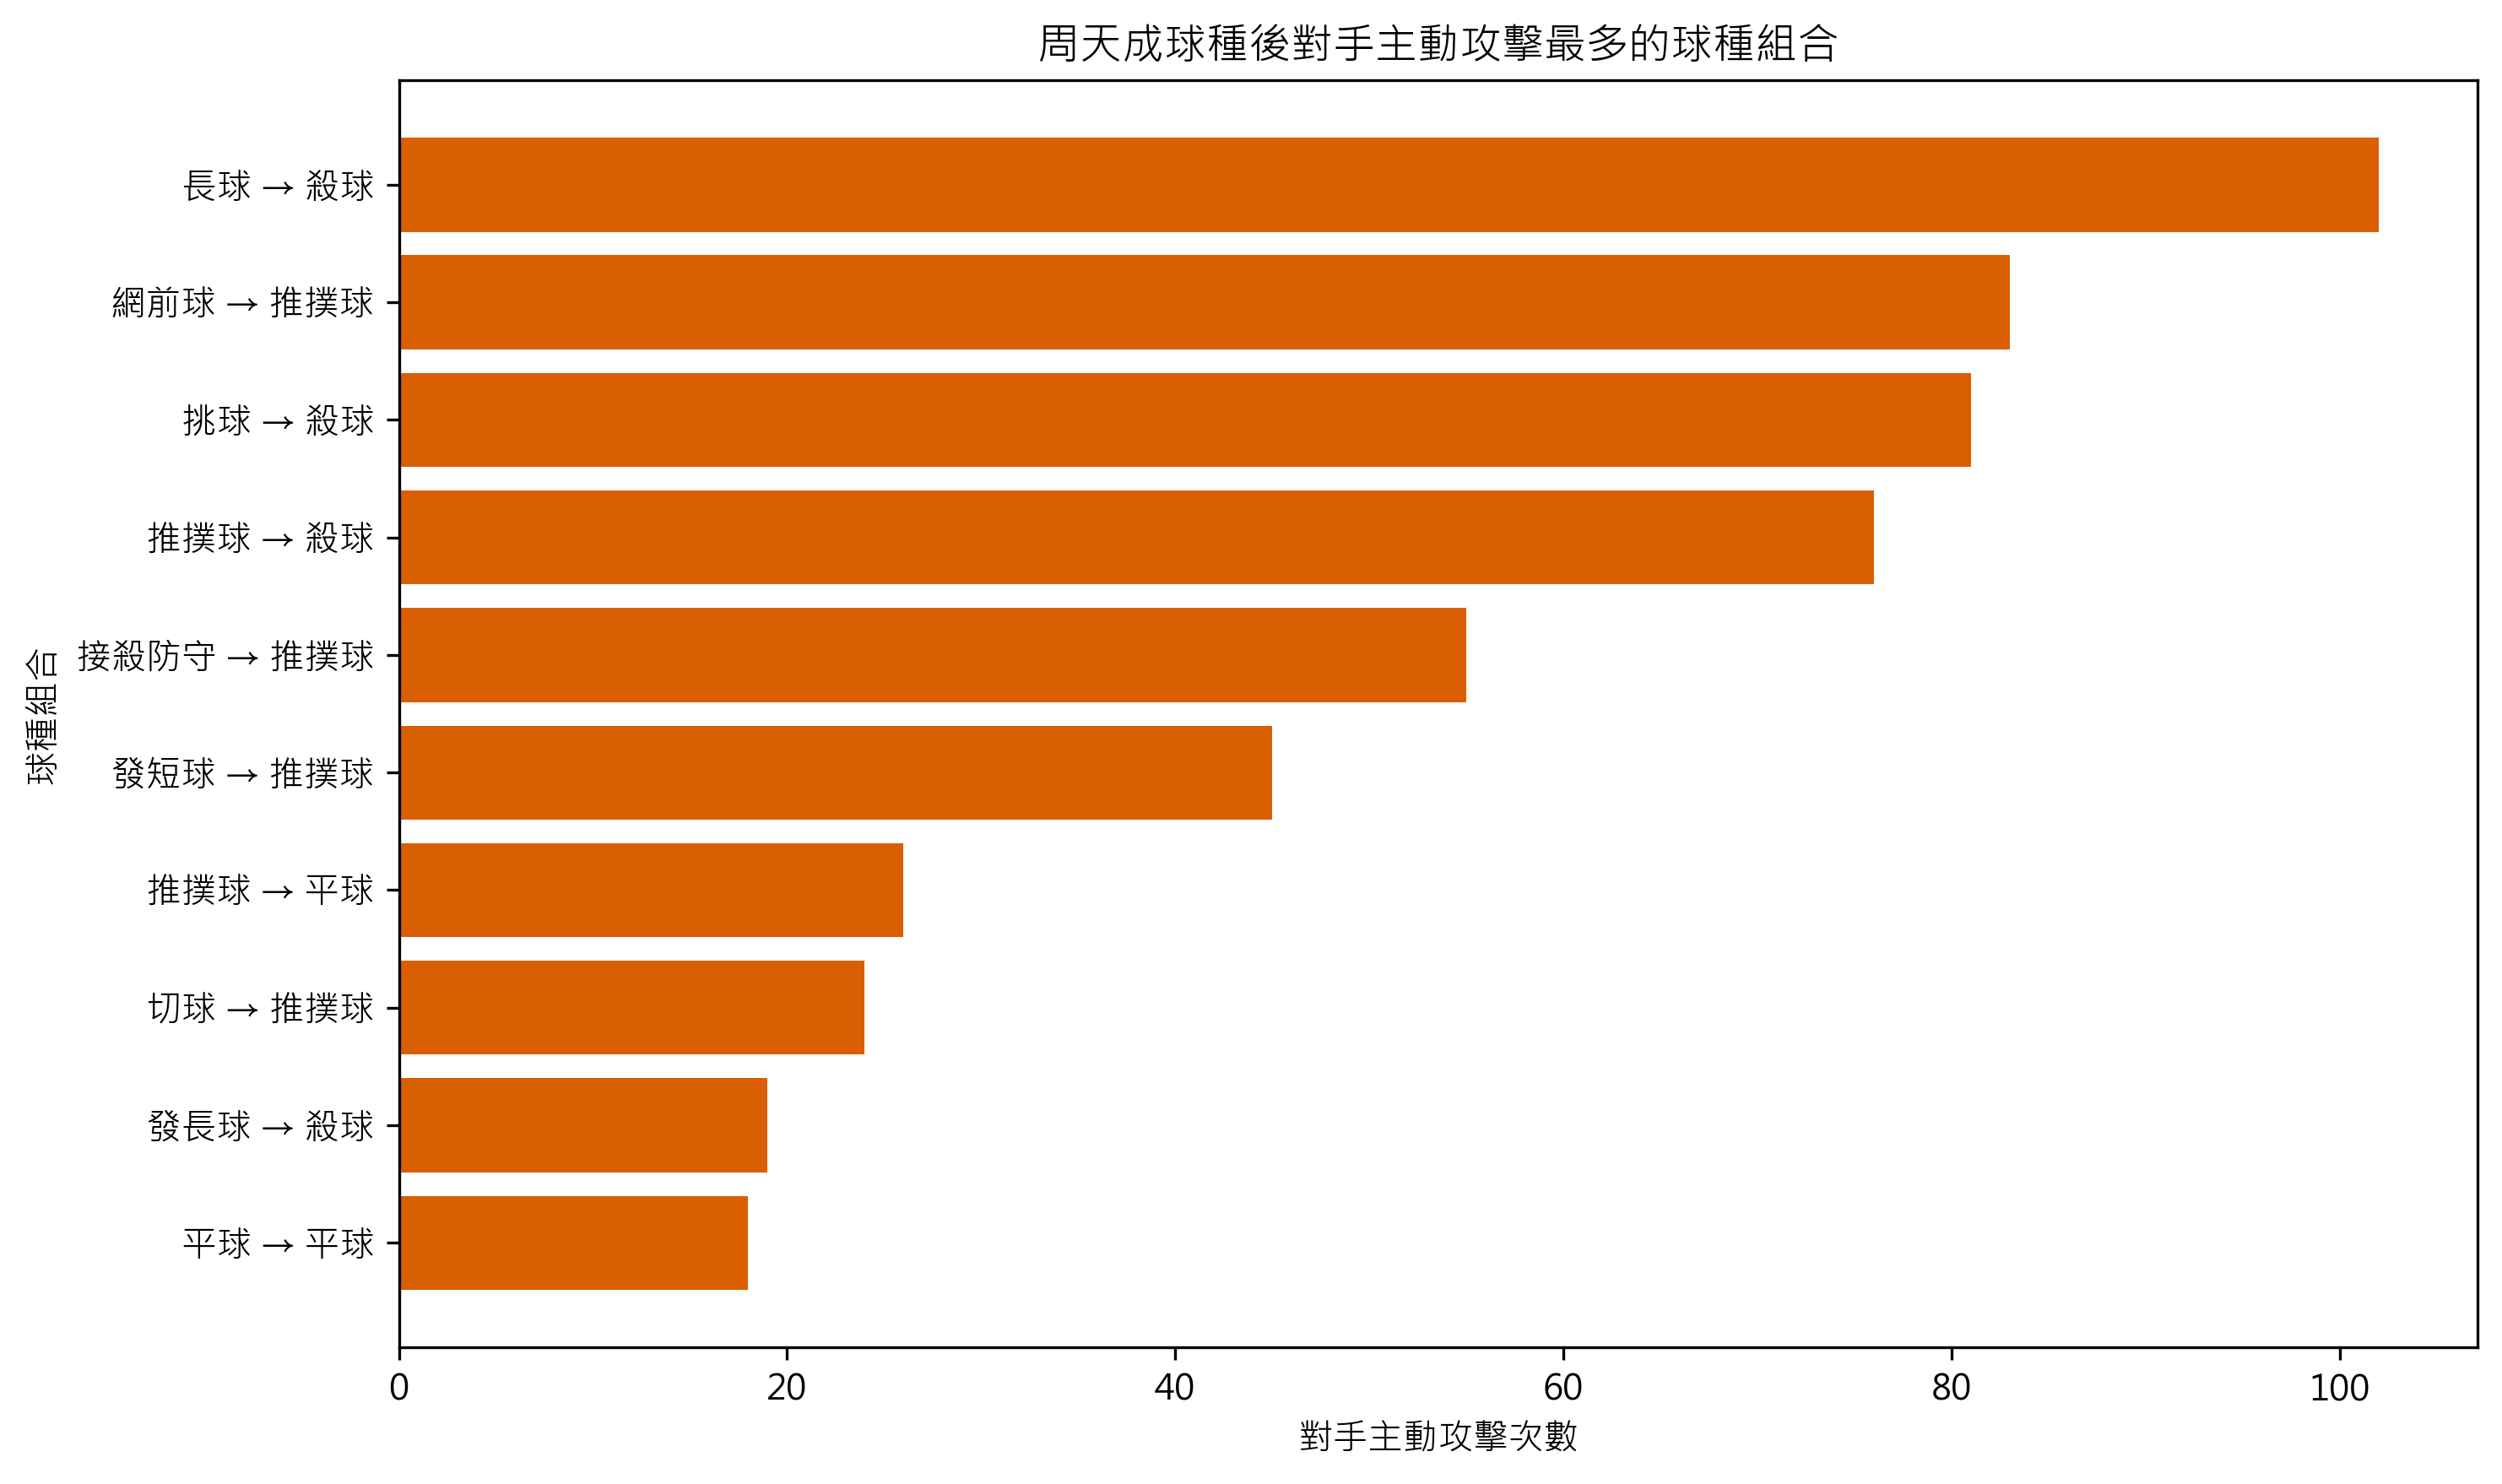

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print('資料為空，無法分析。')
elif missing_cols:
    print(f'缺少必要欄位：{missing_cols}')
else:
    target_player = 'CHOU Tien Chen'
    attack_types = ['殺球', '推撲球', '平球']

    data = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    group_cols = ['match_id', 'set', 'rally']

    data['next_player'] = data.groupby(group_cols)['player'].shift(-1)
    data['next_type'] = data.groupby(group_cols)['type'].shift(-1)
    data['next_getpoint_player'] = data.groupby(group_cols)['getpoint_player'].shift(-1)

    valid_next_shot = (
        (data['player'] == target_player) &
        (data['next_player'] == data['opponent']) &
        data['type'].notna() &
        data['next_type'].notna()
    )

    sequence_df = data.loc[
        valid_next_shot,
        ['type', 'next_type', 'next_getpoint_player']
    ].copy()

    if len(sequence_df) == 0:
        print(f'找不到 {target_player} 後由對手回擊的有效連續球資料。')
    else:
        sequence_df['對手是否主動攻擊'] = (
            sequence_df['next_type'].isin(attack_types)
        )

        sequence_df['對手是否以該拍主動得分'] = (
            sequence_df['next_getpoint_player'].notna() &
            (sequence_df['next_getpoint_player'] == data.loc[
                sequence_df.index, 'next_player'
            ].values)
        )

        summary = (
            sequence_df
            .groupby(['type', 'next_type'], as_index=False)
            .agg(
                組合次數=('next_type', 'size'),
                對手主動攻擊次數=('對手是否主動攻擊', 'sum'),
                對手主動得分次數=('對手是否以該拍主動得分', 'sum')
            )
        )

        summary['對手主動攻擊比例'] = (
            summary['對手主動攻擊次數'] / summary['組合次數'] * 100
        )

        attack_summary = summary[
            summary['對手主動攻擊次數'] > 0
        ].copy()

        attack_summary = attack_summary.sort_values(
            ['對手主動攻擊次數', '組合次數', '對手主動攻擊比例'],
            ascending=[False, False, False]
        ).reset_index(drop=True)

        attack_summary['周天成球種→對手球種'] = (
            attack_summary['type'] + ' → ' + attack_summary['next_type']
        )

        output_cols = [
            '周天成球種→對手球種',
            '組合次數',
            '對手主動攻擊次數',
            '對手主動攻擊比例',
            '對手主動得分次數'
        ]

        print('對手主動攻擊定義：對手下一拍球種為「殺球、推撲球或平球」。')
        print('統計單位：同一 match_id、set、rally 內，周天成擊球後對手的下一拍。')
        print()
        print(
            attack_summary[output_cols]
            .head(15)
            .to_string(
                index=False,
                formatters={
                    '對手主動攻擊比例': '{:.1f}%'.format
                }
            )
        )

        plot_df = attack_summary.head(10).sort_values(
            '對手主動攻擊次數',
            ascending=True
        )

        if len(plot_df) > 0:
            fig, ax = plt.subplots(figsize=(10, 6))

            ax.barh(
                plot_df['周天成球種→對手球種'],
                plot_df['對手主動攻擊次數'],
                color='#D95F02'
            )

            ax.set_title('周天成球種後對手主動攻擊最多的球種組合')
            ax.set_xlabel('對手主動攻擊次數')
            ax.set_ylabel('球種組合')
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 65
**問題**: 在周天成連續失分3分(含)以上時，他的打擊策略選擇是否變得激進或過於保守？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析口徑：以 match_id → set → rally 判定回合；周天成在某回合的得分者不是周天成，即視為失分。
比較單位：周天成在「連續失分達3分以上的回合」與其他回合中的擊球球種比例。
進攻型代理球種：殺球、推撲球、平球；防守拉吊型代理球種：長球、挑球、接殺防守。

策略比例：
           擊球數  進攻型代理比例  防守拉吊型代理比例
情境                                
連續失分3分以上   255    25.10      45.49
其他回合      2354    28.67      33.14

球種比例比較（百分點變化＝連續失分3分以上 − 其他回合）：
type  其他回合  連續失分3分以上  比例變化
 發短球  6.20      0.39 -5.81
 發長球  1.44      0.00 -1.44
  長球 10.41     11.76  1.36
  殺球 11.47     11.37 -0.10
  切球  8.24      6.67 -1.57
  挑球  9.77     15.69  5.92
  平球  3.99      4.71  0.71
 網前球 22.30     22.35  0.05
…（輸出已截斷；notebook 僅保留重點）


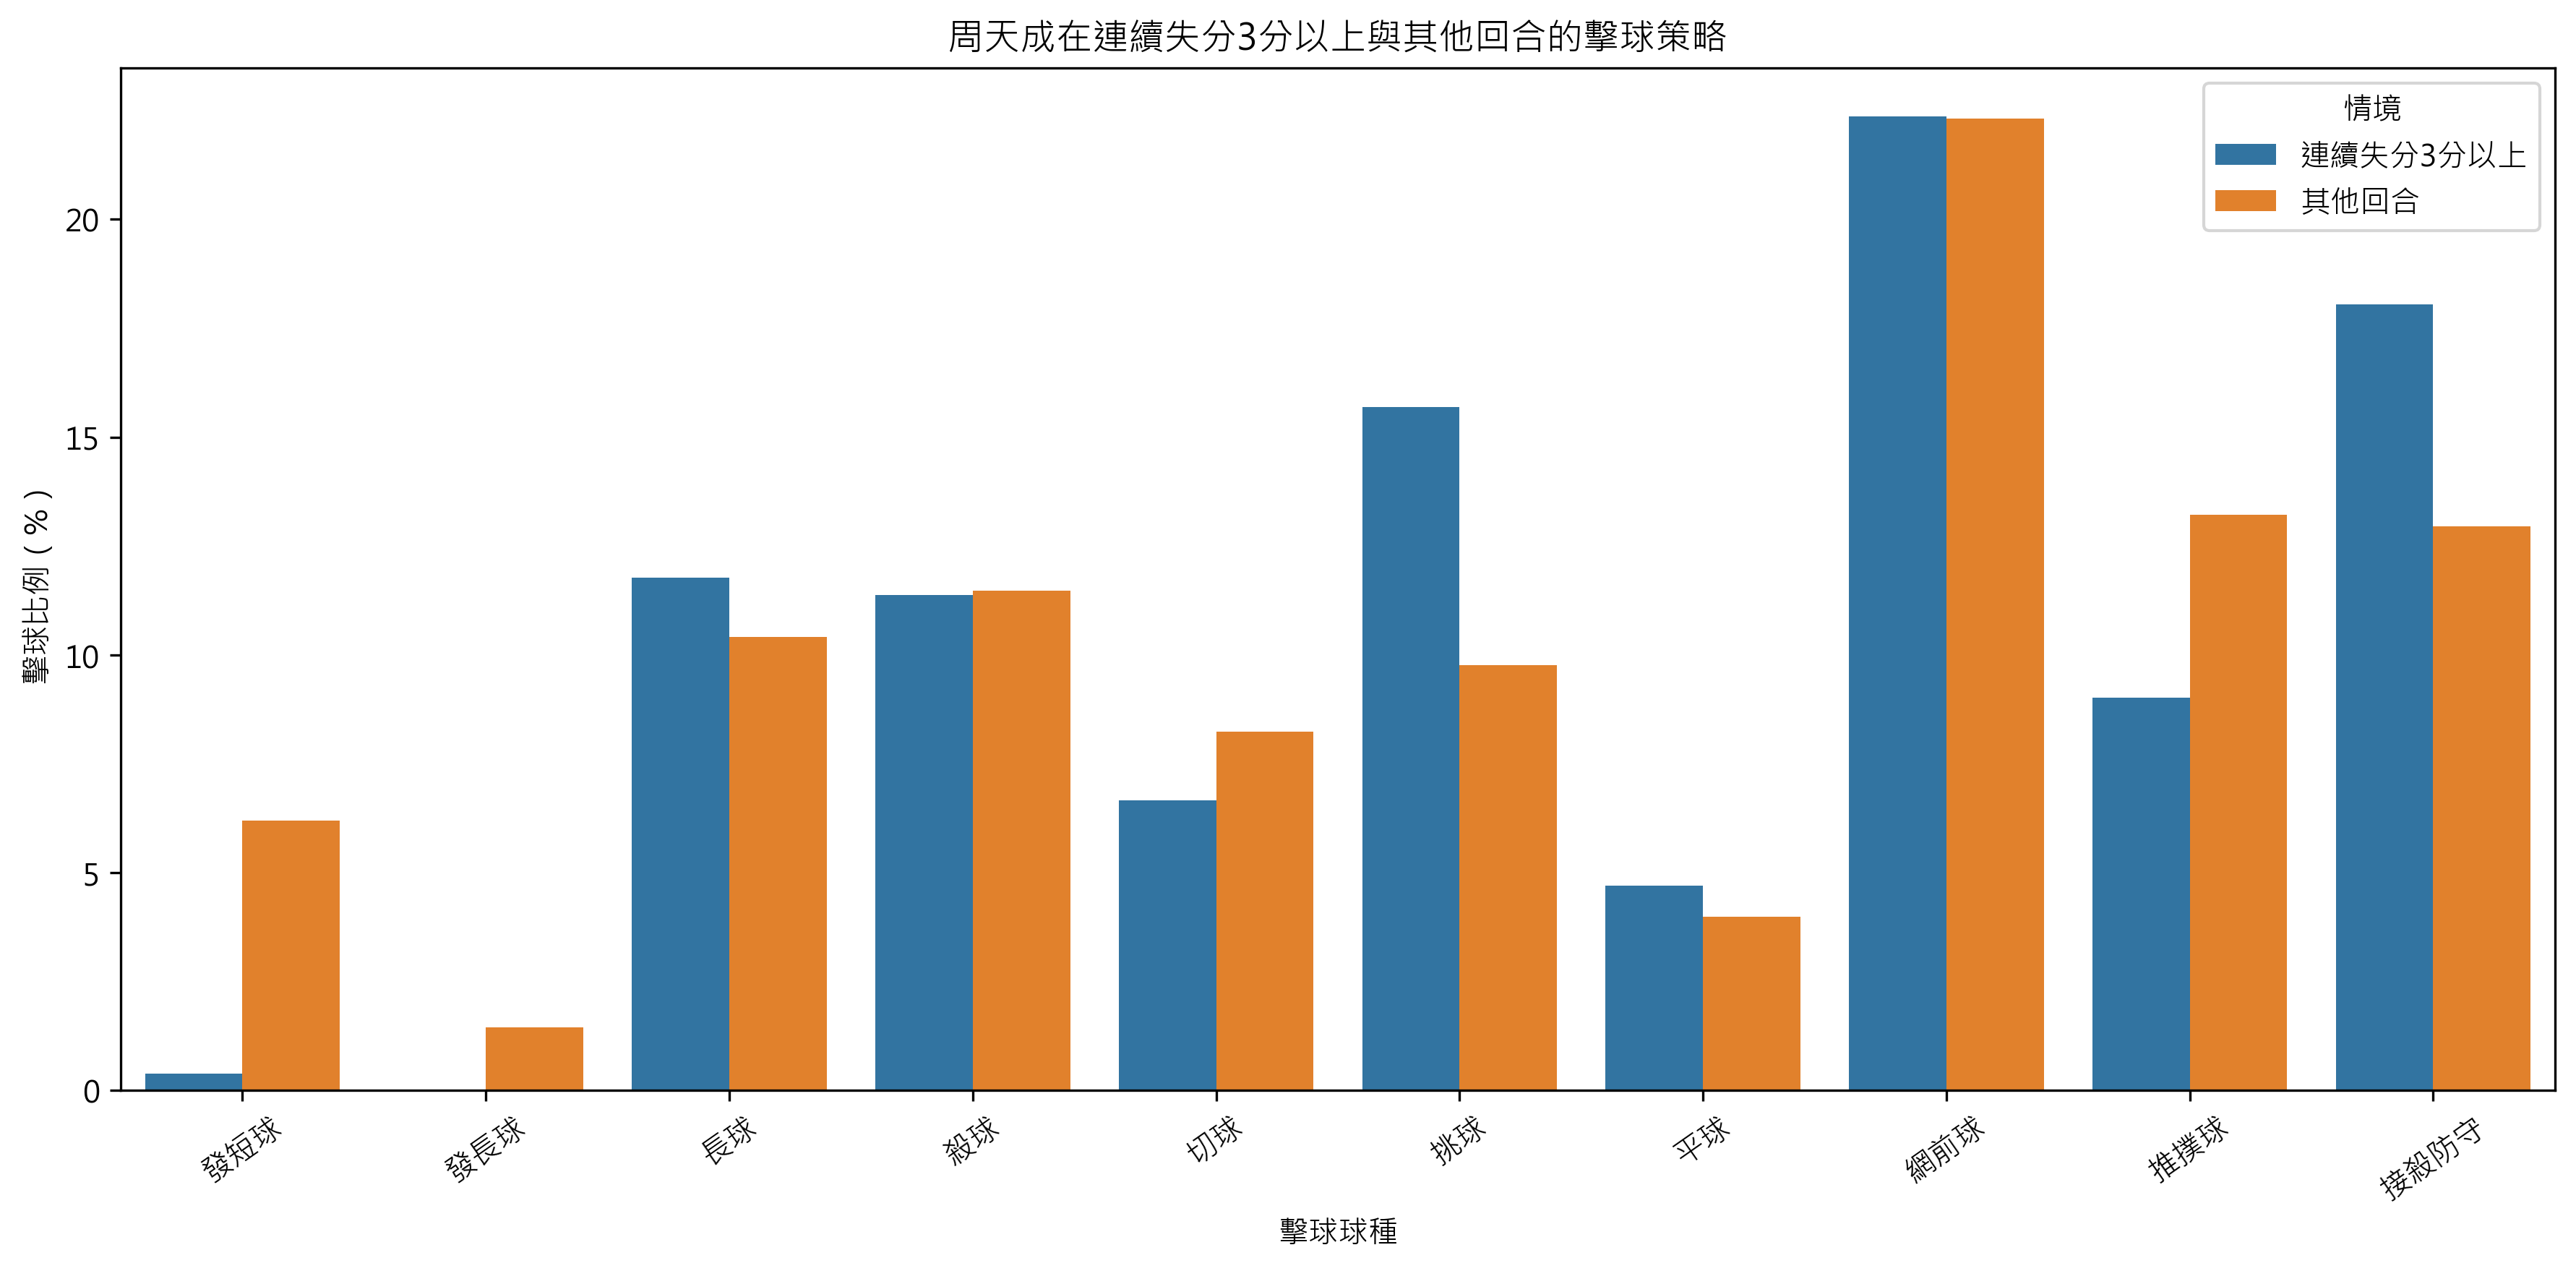

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'ball_round', 'player', 'type', 'getpoint_player']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

if len(df) == 0:
    print("資料為空，無法分析。")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title("周天成連續失分策略分析")
    ax.axis("off")
else:
    player_name = 'CHOU Tien Chen'

    data = df[required_cols].copy()
    data = data.sort_values(
        ['match_id', 'set', 'rally', 'ball_round'],
        kind='stable'
    ).reset_index(drop=True)

    def last_non_null(series):
        valid = series.dropna()
        return valid.iloc[-1] if len(valid) > 0 else pd.NA

    rally_tbl = (
        data.groupby(['match_id', 'set', 'rally'], sort=False, dropna=False)
        .agg(
            getpoint_player=('getpoint_player', last_non_null),
            first_ball_round=('ball_round', 'first')
        )
        .reset_index()
    )

    rally_tbl['is_chou_loss'] = (
        rally_tbl['getpoint_player'].notna() &
        rally_tbl['getpoint_player'].ne(player_name)
    )

    def consecutive_streak(series):
        streak = 0
        result = []
        for value in series:
            streak = streak + 1 if bool(value) else 0
            result.append(streak)
        return pd.Series(result, index=series.index)

    rally_tbl['chou_loss_streak'] = (
        rally_tbl.groupby(['match_id', 'set'], sort=False)['is_chou_loss']
        .transform(consecutive_streak)
    )

    rally_tbl['losing_streak_3plus'] = rally_tbl['chou_loss_streak'] >= 3

    data = data.merge(
        rally_tbl[
            ['match_id', 'set', 'rally', 'getpoint_player',
             'chou_loss_streak', 'losing_streak_3plus']
        ],
        on=['match_id', 'set', 'rally'],
        how='left',
        validate='many_to_one'
    )

    chou_shots = data[
        (data['player'] == player_name) &
        data['type'].notna()
    ].copy()

    chou_shots['情境'] = chou_shots['losing_streak_3plus'].map({
        True: '連續失分3分以上',
        False: '其他回合'
    })

    shot_order = [
        '發短球', '發長球', '長球', '殺球', '切球',
        '挑球', '平球', '網前球', '推撲球', '接殺防守', '接不到'
    ]

    if len(chou_shots) == 0:
        print("找不到周天成的有效擊球資料，無法分析。")
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title("周天成連續失分策略分析")
        ax.axis("off")
    else:
        summary = (
            chou_shots.groupby(['情境', 'type'])
            .size()
            .rename('擊球數')
            .reset_index()
        )

        summary['比例'] = (
            summary['擊球數'] /
            summary.groupby('情境')['擊球數'].transform('sum') * 100
        )

        comparison = (
            summary.pivot(index='type', columns='情境', values='比例')
            .reindex(shot_order)
            .fillna(0)
            .reset_index()
        )

        for col in ['連續失分3分以上', '其他回合']:
            if col not in comparison.columns:
                comparison[col] = 0.0

        comparison['比例變化'] = (
            comparison['連續失分3分以上'] - comparison['其他回合']
        )

        aggressive_types = ['殺球', '推撲球', '平球']
        defensive_types = ['長球', '挑球', '接殺防守']

        chou_shots['進攻型代理'] = chou_shots['type'].isin(aggressive_types)
        chou_shots['防守拉吊型代理'] = chou_shots['type'].isin(defensive_types)

        strategy_summary = (
            chou_shots.groupby('情境')
            .agg(
                擊球數=('type', 'size'),
                進攻型代理比例=('進攻型代理', 'mean'),
                防守拉吊型代理比例=('防守拉吊型代理', 'mean')
            )
            .reindex(['連續失分3分以上', '其他回合'])
        )

        strategy_summary['進攻型代理比例'] *= 100
        strategy_summary['防守拉吊型代理比例'] *= 100

        aggressive_delta = (
            strategy_summary.loc['連續失分3分以上', '進攻型代理比例'] -
            strategy_summary.loc['其他回合', '進攻型代理比例']
        )

        defensive_delta = (
            strategy_summary.loc['連續失分3分以上', '防守拉吊型代理比例'] -
            strategy_summary.loc['其他回合', '防守拉吊型代理比例']
        )

        if aggressive_delta >= 5:
            conclusion = "連續失分3分以上時，進攻型擊球比例明顯上升，策略較為激進。"
        elif aggressive_delta <= -5 and defensive_delta >= 5:
            conclusion = "連續失分3分以上時，進攻型擊球比例下降且防守拉吊型比例上升，策略較為保守。"
        else:
            conclusion = "連續失分3分以上時，尚無足夠證據判定策略明顯變得激進或過於保守。"

        print("分析口徑：以 match_id → set → rally 判定回合；周天成在某回合的得分者不是周天成，即視為失分。")
        print("比較單位：周天成在「連續失分達3分以上的回合」與其他回合中的擊球球種比例。")
        print("進攻型代理球種：殺球、推撲球、平球；防守拉吊型代理球種：長球、挑球、接殺防守。")
        print("\n策略比例：")
        print(strategy_summary.round(2).to_string())
        print("\n球種比例比較（百分點變化＝連續失分3分以上 − 其他回合）：")
        print(comparison.round(2).to_string(index=False))
        print(f"\n結論：{conclusion}")

        plot_data = comparison.melt(
            id_vars='type',
            value_vars=['連續失分3分以上', '其他回合'],
            var_name='情境',
            value_name='擊球比例'
        )

        plot_data = plot_data[plot_data['擊球比例'] > 0]

        fig, ax = plt.subplots(figsize=(12, 6))

        if len(plot_data) > 0:
            sns.barplot(
                data=plot_data,
                x='type',
                y='擊球比例',
                hue='情境',
                order=[shot for shot in shot_order if shot in plot_data['type'].unique()],
                ax=ax
            )
            ax.set_xlabel('擊球球種')
            ax.set_ylabel('擊球比例（%）')
            ax.set_title('周天成在連續失分3分以上與其他回合的擊球策略')
            ax.legend(title='情境')
            ax.tick_params(axis='x', rotation=35)
        else:
            ax.set_title("無可繪製的擊球策略資料")
            ax.axis("off")

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 66
**問題**: 分析周天成在「領先 3 分以上」時的擊球策略是否更保守？請統計球種比例。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天有效擊球數：2609
情境
領先3分以上      445
未領先3分以上    2164

球種比例比較（百分比）：
      領先3分以上_次數  領先3分以上_比例  未領先3分以上_次數  未領先3分以上_比例  比例差_百分點
發短球          39       8.76         108        4.99     3.77
發長球           5       1.12          29        1.34    -0.22
長球           68      15.28         207        9.57     5.72
殺球           34       7.64         265       12.25    -4.61
切球           58      13.03         153        7.07     5.96
挑球           59      13.26         211        9.75     3.51
平球           16       3.60          90        4.16    -0.56
網前球          79      17.75         503       23.24    -5.49
推撲球          35       7.87         299       13.82    -5.95
接殺防守         52      11.69         299       13.82    -2.13
接不到           0       0.00           0        0.00     0.00

偏保守球種代理定義：接殺防守、挑球
…（輸出已截斷；notebook 僅保留重點）


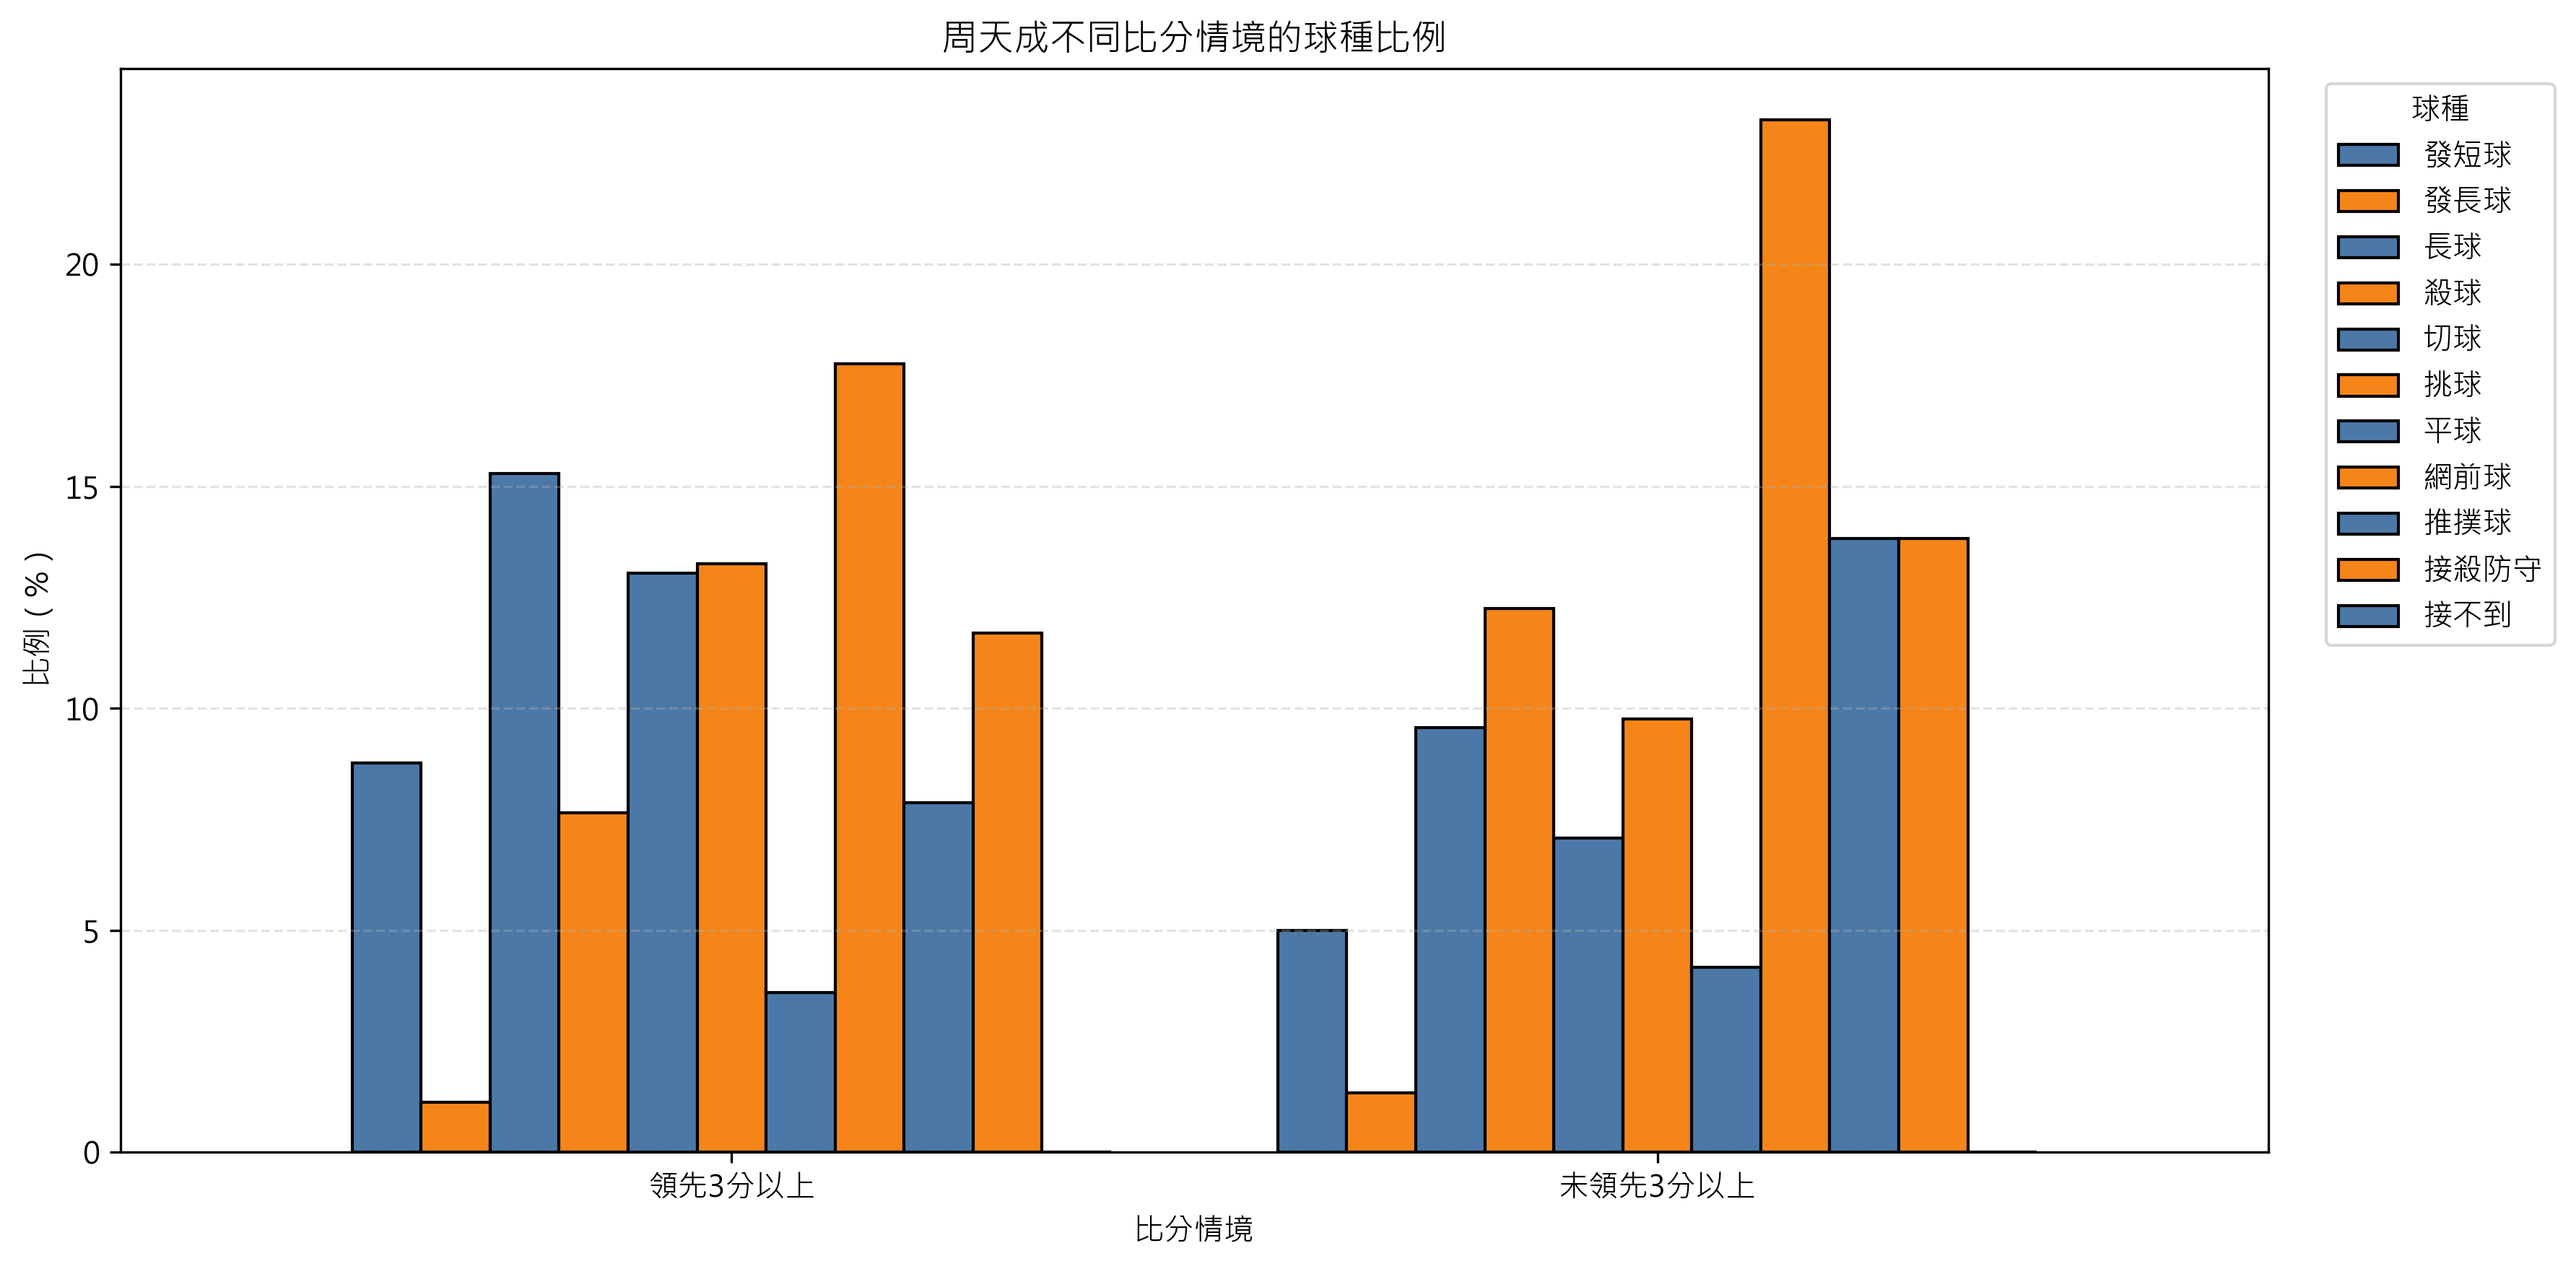

In [ ]:
required_cols = {
    'match_id', 'set', 'rally', 'player', 'type',
    'Kento MOMOTA_score', 'CHOU Tien Chen_score'
}
missing_cols = sorted(required_cols - set(df.columns))

fig, ax = plt.subplots(figsize=(12, 6))

if len(df) == 0:
    print("資料為空，無法分析。")
elif missing_cols:
    print(f"缺少必要欄位：{missing_cols}")
else:
    work = df.copy()

    analysis_cols = [
        'match_id', 'set', 'rally', 'player', 'type',
        'Kento MOMOTA_score', 'CHOU Tien Chen_score'
    ]
    work = work[analysis_cols].dropna(subset=[
        'player', 'type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
    ])

    chou_df = work[work['player'] == 'CHOU Tien Chen'].copy()
    chou_df['分差'] = (
        chou_df['CHOU Tien Chen_score'] -
        chou_df['Kento MOMOTA_score']
    )
    chou_df['情境'] = chou_df['分差'].ge(3).map({
        True: '領先3分以上',
        False: '未領先3分以上'
    })

    shot_order = [
        '發短球', '發長球', '長球', '殺球', '切球',
        '挑球', '平球', '網前球', '推撲球', '接殺防守', '接不到'
    ]

    if len(chou_df) == 0:
        print("找不到周天成且具有有效比分與球種的擊球紀錄。")
    else:
        count_table = pd.crosstab(
            chou_df['type'],
            chou_df['情境']
        ).reindex(index=shot_order, columns=[
            '領先3分以上', '未領先3分以上'
        ], fill_value=0)

        proportion_table = count_table.div(
            count_table.sum(axis=0).replace(0, pd.NA),
            axis=1
        ).fillna(0)

        output_table = pd.DataFrame(index=shot_order)
        output_table['領先3分以上_次數'] = count_table['領先3分以上']
        output_table['領先3分以上_比例'] = proportion_table['領先3分以上']
        output_table['未領先3分以上_次數'] = count_table['未領先3分以上']
        output_table['未領先3分以上_比例'] = proportion_table['未領先3分以上']
        output_table['比例差_百分點'] = (
            output_table['領先3分以上_比例'] -
            output_table['未領先3分以上_比例']
        ) * 100

        print(f"周天有效擊球數：{len(chou_df)}")
        print(
            chou_df.groupby('情境', observed=False)
            .size()
            .reindex(['領先3分以上', '未領先3分以上'], fill_value=0)
            .rename('擊球數')
            .to_string()
        )

        display_table = output_table.copy()
        display_table['領先3分以上_比例'] = (
            display_table['領先3分以上_比例'] * 100
        ).round(2)
        display_table['未領先3分以上_比例'] = (
            display_table['未領先3分以上_比例'] * 100
        ).round(2)
        display_table = display_table.round({
            '比例差_百分點': 2
        })

        print("\n球種比例比較（百分比）：")
        print(display_table.to_string())

        conservative_types = ['接殺防守', '挑球']
        conservative_table = (
            chou_df.assign(
                偏保守代理球種=chou_df['type'].isin(conservative_types)
            )
            .groupby('情境', observed=False)['偏保守代理球種']
            .agg(['sum', 'count'])
            .reindex(['領先3分以上', '未領先3分以上'])
        )
        conservative_table['比例'] = (
            conservative_table['sum'] /
            conservative_table['count'].replace(0, pd.NA)
        ).fillna(0)

        lead_conservative = conservative_table.loc[
            '領先3分以上', '比例'
        ]
        nonlead_conservative = conservative_table.loc[
            '未領先3分以上', '比例'
        ]
        conservative_diff = (
            lead_conservative - nonlead_conservative
        ) * 100

        print(
            "\n偏保守球種代理定義：接殺防守、挑球"
        )
        print(
            f"領先3分以上比例：{lead_conservative * 100:.2f}%"
        )
        print(
            f"未領先3分以上比例：{nonlead_conservative * 100:.2f}%"
        )
        print(f"比例差：{conservative_diff:+.2f} 個百分點")

        if conservative_diff > 0:
            conclusion = (
                "依此代理指標，周天成在領先3分以上時較為保守；"
                "但這是球種比例上的描述，並非因果推論。"
            )
        elif conservative_diff < 0:
            conclusion = (
                "依此代理指標，周天成在領先3分以上時沒有更保守，"
                "反而較少使用接殺防守與挑球；但這是描述性結果。"
            )
        else:
            conclusion = (
                "依此代理指標，周天成在領先3分以上與其他情境的保守球種比例相同。"
            )

        print(f"\n結論：{conclusion}")

        plot_table = proportion_table.T * 100
        plot_table.plot(
            kind='bar',
            ax=ax,
            width=0.82,
            color=['#4C78A8', '#F58518'],
            edgecolor='black'
        )
        ax.set_title('周天成不同比分情境的球種比例')
        ax.set_xlabel('比分情境')
        ax.set_ylabel('比例（%）')
        ax.set_xticklabels(
            ['領先3分以上', '未領先3分以上'],
            rotation=0
        )
        ax.legend(title='球種', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(axis='y', linestyle='--', alpha=0.35)

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 67
**問題**: 當分數差距逐漸縮小時（領先轉膠著），周天成殺球成功率是否下降？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
1. 以同一場、同一局的前一回合與當前回合結束比分比較。
2. 領先轉膠著：周天成前一回合領先、當前仍未落後、分差縮小，且當前分差不超過 2 分。
3. 殺球成功率：周天成殺球未直接導致對手得分的比例。

周天成殺球成功率比較：
 state  殺球次數  成功次數    成功率
其他領先狀態    48    42 87.50%
 領先轉膠著    27    26 96.30%

結論：否，領先轉膠著時反而上升 8.80 個百分點。


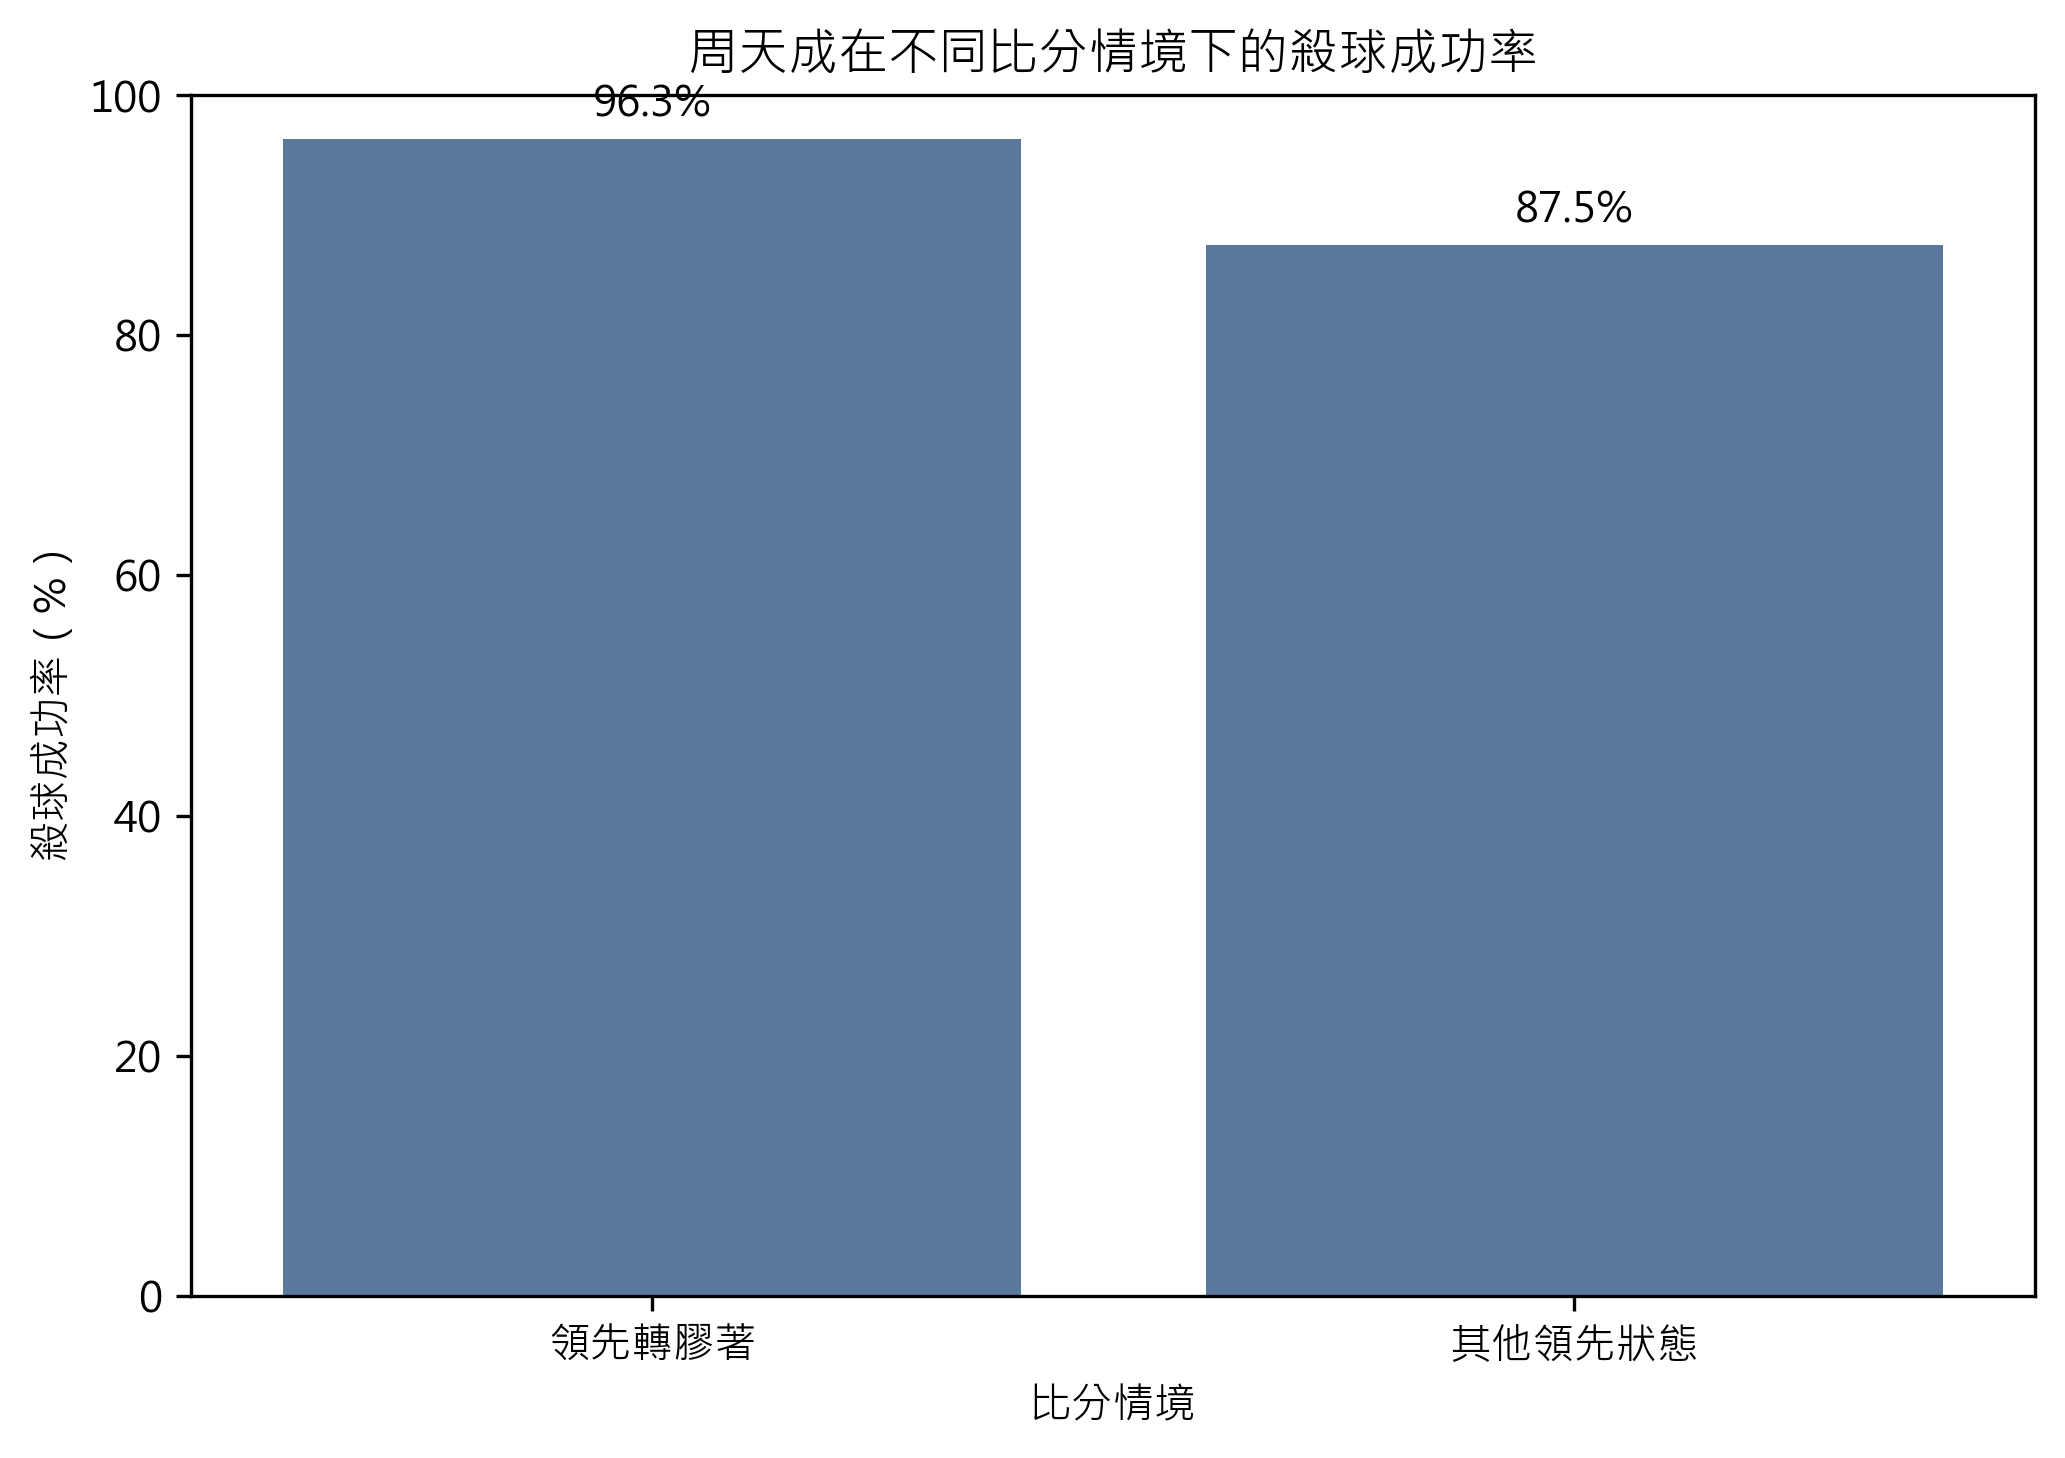

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'type',
    'getpoint_player', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print("資料為空，無法分析。")
elif missing_cols:
    print(f"缺少必要欄位：{missing_cols}")
else:
    chou = 'CHOU Tien Chen'
    opponent = 'Kento MOMOTA'
    rally_keys = ['match_id', 'set', 'rally']

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    # 每個回合以最後一拍的比分代表該回合結束後的比分
    rally_end = (
        work.groupby(rally_keys, sort=False, as_index=False)
        .tail(1)
        .copy()
    )

    score_cols = ['Kento MOMOTA_score', 'CHOU Tien Chen_score']
    rally_end = rally_end.dropna(subset=score_cols).copy()

    if len(rally_end) == 0:
        print("沒有完整比分資料，無法判斷分數差距變化。")
    else:
        rally_end['chou_margin'] = (
            rally_end['CHOU Tien Chen_score']
            - rally_end['Kento MOMOTA_score']
        )

        # 僅在同一場、同一局內比較前一個回合，避免跨局或跨場污染
        rally_end['previous_margin'] = (
            rally_end.groupby(['match_id', 'set'])['chou_margin']
            .shift(1)
        )

        rally_end['is_chou_leading'] = rally_end['chou_margin'] > 0
        rally_end['is_leading_to_close'] = (
            (rally_end['previous_margin'] > 0) &
            (rally_end['chou_margin'] >= 0) &
            (rally_end['chou_margin'] < rally_end['previous_margin']) &
            (rally_end['chou_margin'] <= 2)
        )

        # 對照組：周天成仍領先，但不是「領先轉膠著」的回合
        rally_end['is_other_leading_state'] = (
            (rally_end['previous_margin'] > 0) &
            (rally_end['chou_margin'] > 0) &
            (~rally_end['is_leading_to_close'])
        )

        transition_rallies = rally_end.loc[
            rally_end['is_leading_to_close'],
            rally_keys
        ].copy()

        other_leading_rallies = rally_end.loc[
            rally_end['is_other_leading_state'],
            rally_keys
        ].copy()

        transition_rallies['state'] = '領先轉膠著'
        other_leading_rallies['state'] = '其他領先狀態'

        state_rallies = pd.concat(
            [transition_rallies, other_leading_rallies],
            ignore_index=True
        )

        if len(state_rallies) > 0:
            analysis_df = work.merge(
                state_rallies,
                on=rally_keys,
                how='inner'
            )

            smash_df = analysis_df.loc[
                (analysis_df['player'] == chou) &
                (analysis_df['type'] == '殺球')
            ].copy()

            if len(smash_df) > 0:
                # 成功率定義：該殺球未直接導致對手得分
                smash_df['is_success'] = (
                    smash_df['getpoint_player'] != smash_df['opponent']
                )

                result = (
                    smash_df.groupby('state', sort=False)
                    .agg(
                        殺球次數=('is_success', 'size'),
                        成功次數=('is_success', 'sum')
                    )
                    .reset_index()
                )
                result['成功率'] = (
                    result['成功次數'] / result['殺球次數'] * 100
                )

                print("統計口徑：")
                print("1. 以同一場、同一局的前一回合與當前回合結束比分比較。")
                print("2. 領先轉膠著：周天成前一回合領先、當前仍未落後、分差縮小，且當前分差不超過 2 分。")
                print("3. 殺球成功率：周天成殺球未直接導致對手得分的比例。")
                print("\n周天成殺球成功率比較：")
                print(result.to_string(index=False, formatters={'成功率': '{:.2f}%'.format}))

                transition_rate = result.loc[
                    result['state'] == '領先轉膠著', '成功率'
                ]
                other_rate = result.loc[
                    result['state'] == '其他領先狀態', '成功率'
                ]

                if len(transition_rate) > 0 and len(other_rate) > 0:
                    difference = transition_rate.iloc[0] - other_rate.iloc[0]
                    if difference < 0:
                        conclusion = f"是，領先轉膠著時下降 {abs(difference):.2f} 個百分點。"
                    elif difference > 0:
                        conclusion = f"否，領先轉膠著時反而上升 {difference:.2f} 個百分點。"
                    else:
                        conclusion = "沒有下降，兩種情境的成功率相同。"
                    print(f"\n結論：{conclusion}")
                else:
                    print("\n結論：缺少可比較的兩種情境，無法判斷是否下降。")

                fig, ax = plt.subplots(figsize=(7, 5))
                plot_df = result.copy()
                sns.barplot(
                    data=plot_df,
                    x='state',
                    y='成功率',
                    order=['領先轉膠著', '其他領先狀態'],
                    color='#4C78A8',
                    ax=ax
                )
                ax.set_title('周天成在不同比分情境下的殺球成功率')
                ax.set_xlabel('比分情境')
                ax.set_ylabel('殺球成功率（%）')
                ax.set_ylim(0, 100)

                for container in ax.containers:
                    ax.bar_label(
                        container,
                        fmt='%.1f%%',
                        padding=3
                    )

                plt.tight_layout()
            else:
                print("符合情境的回合中沒有周天成殺球資料。")
                fig, ax = plt.subplots(figsize=(7, 5))
                ax.set_title('符合情境的回合中沒有周天成殺球資料')
                ax.set_axis_off()
                plt.tight_layout()
        else:
            print("沒有符合「領先轉膠著」或對照領先狀態的回合。")
            fig, ax = plt.subplots(figsize=(7, 5))
            ax.set_title('沒有可分析的比分轉換情境')
            ax.set_axis_off()
            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 71
**問題**: 分析周天成在自己領先時與落後時，網前球的使用比例差異。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：以周天成每一拍擊球為統計單位，排除平分；
領先/落後依當前拍的周天成比分與對手比分比較判定。
       周天成總擊球數  網前球次數  網前球使用比例
比分狀態                          
周天成領先      947    203    21.44
周天成落後     1359    316    23.25

領先時相較落後時的網前球使用比例差異：-1.82 個百分點


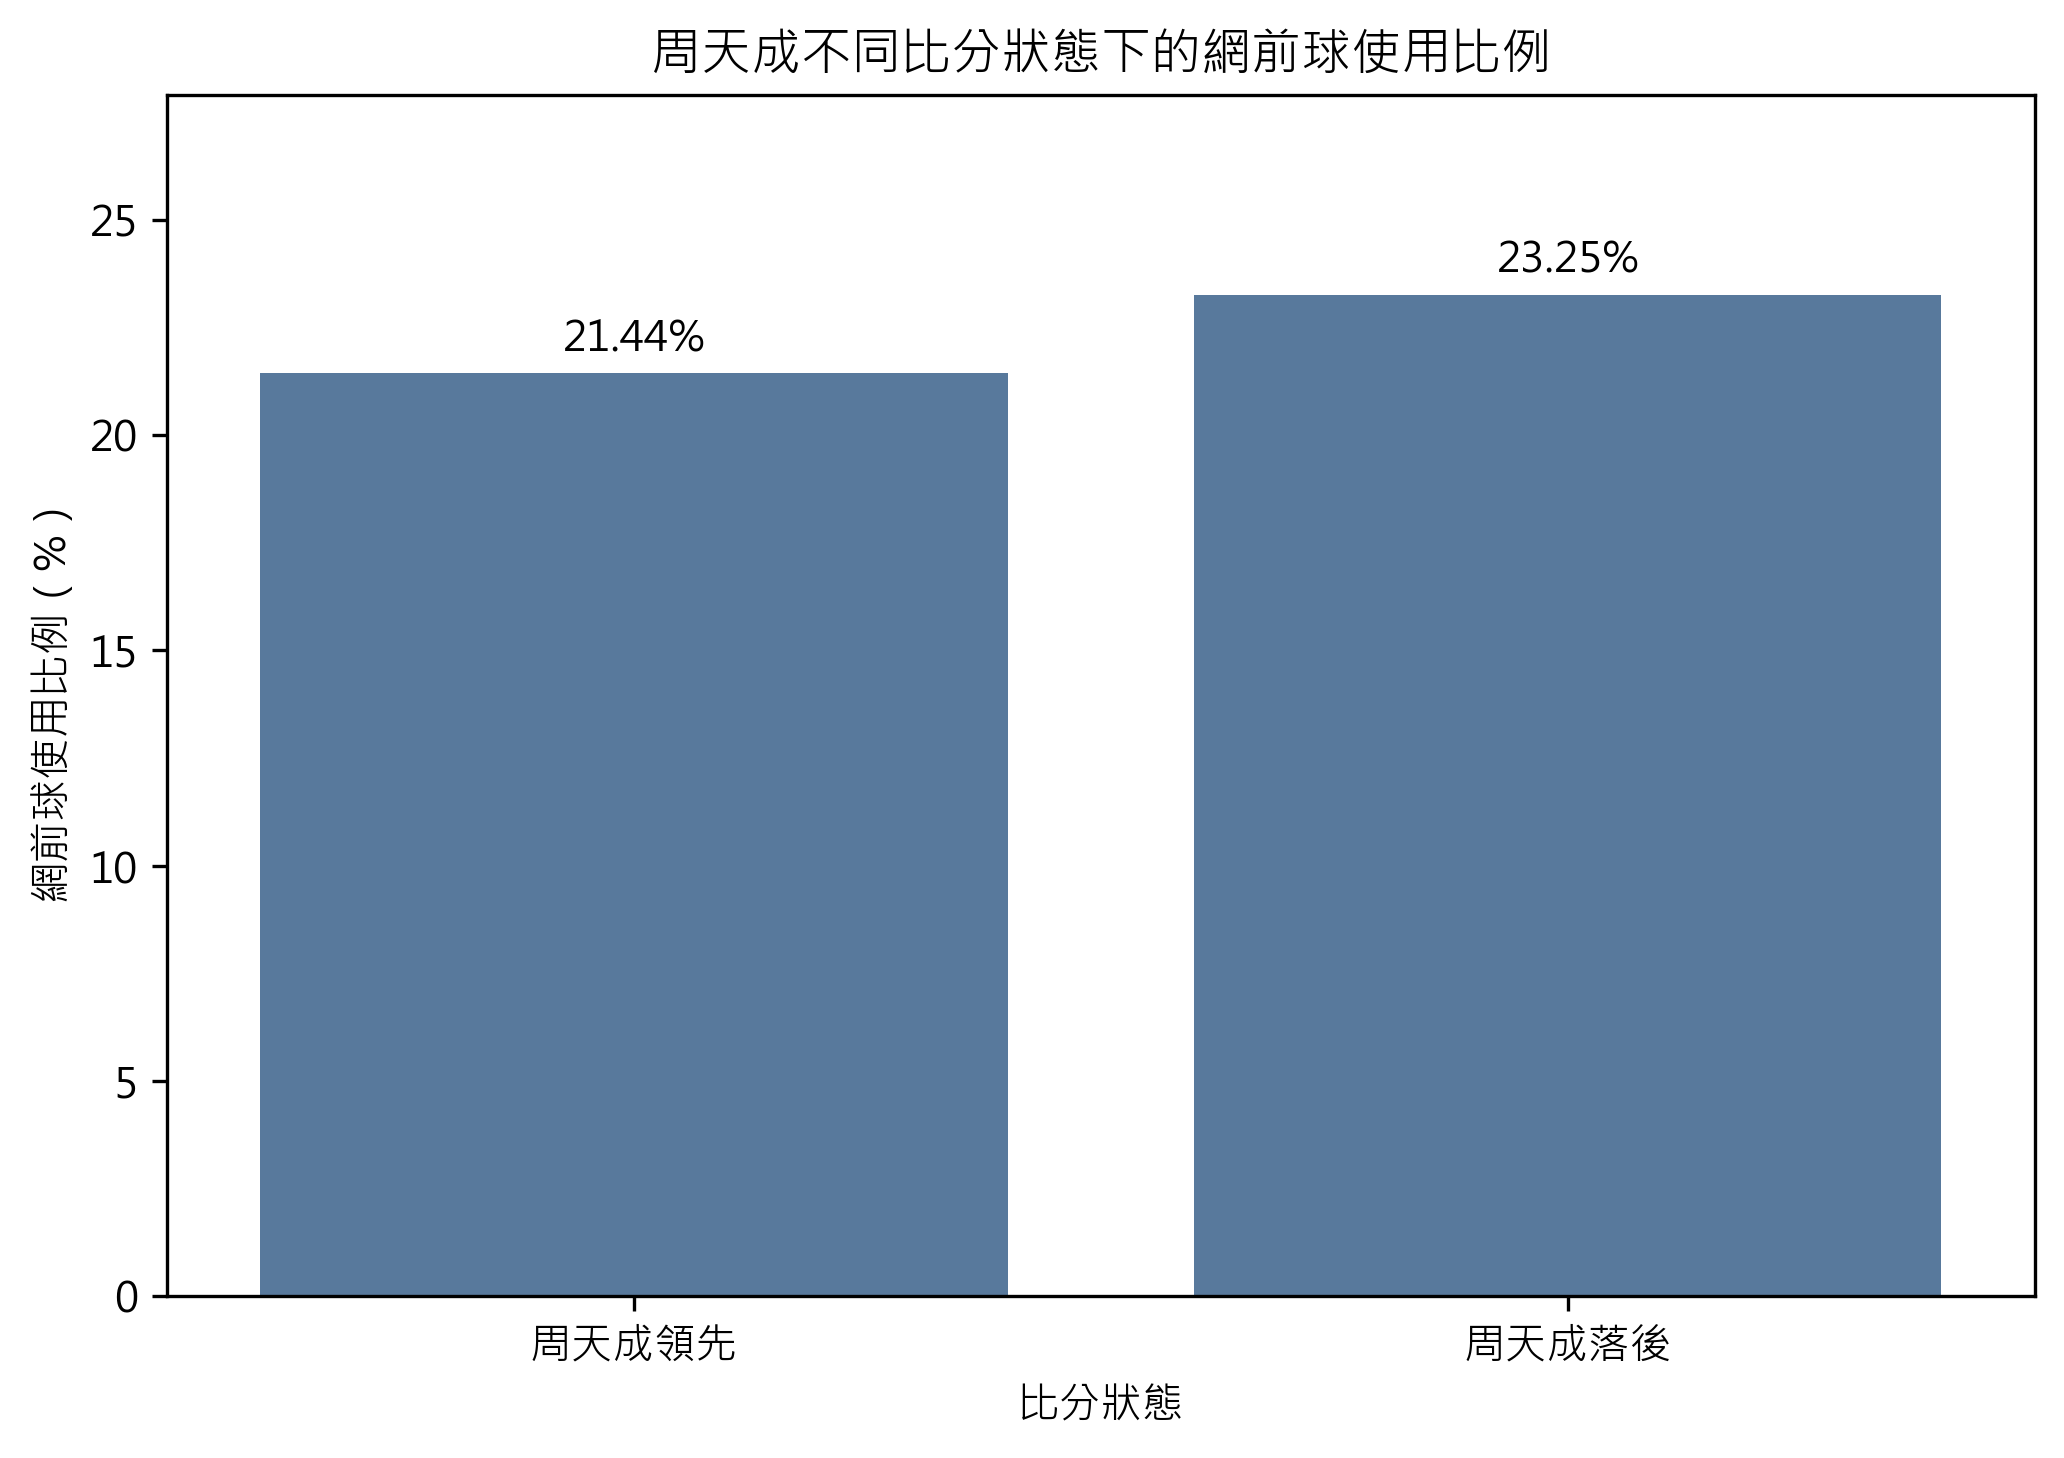

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    player_name = "CHOU Tien Chen"
    opponent_name = "Kento MOMOTA"
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player", "type",
        f"{player_name}_score", f"{opponent_name}_score"
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        analysis_df = df[required_cols].dropna(
            subset=[
                "match_id", "set", "rally", "ball_round", "player", "type",
                f"{player_name}_score", f"{opponent_name}_score"
            ]
        ).copy()

        analysis_df = analysis_df.sort_values(
            ["match_id", "set", "rally", "ball_round"]
        )

        chou_df = analysis_df[analysis_df["player"] == player_name].copy()
        chou_df["比分狀態"] = "平分"
        chou_df.loc[
            chou_df[f"{player_name}_score"] > chou_df[f"{opponent_name}_score"],
            "比分狀態"
        ] = "周天成領先"
        chou_df.loc[
            chou_df[f"{player_name}_score"] < chou_df[f"{opponent_name}_score"],
            "比分狀態"
        ] = "周天成落後"

        state_order = ["周天成領先", "周天成落後"]
        state_df = chou_df[chou_df["比分狀態"].isin(state_order)].copy()

        if len(state_df) == 0:
            print("沒有周天成在領先或落後狀態下的有效擊球資料。")
        else:
            summary = (
                state_df.groupby("比分狀態", observed=False)
                .agg(
                    周天成總擊球數=("type", "size"),
                    網前球次數=("type", lambda s: (s == "網前球").sum())
                )
                .reindex(state_order)
                .fillna(0)
            )
            summary["網前球使用比例"] = (
                summary["網前球次數"] / summary["周天成總擊球數"] * 100
            )

            print("統計口徑：以周天成每一拍擊球為統計單位，排除平分；")
            print("領先/落後依當前拍的周天成比分與對手比分比較判定。")
            print(summary.round({"網前球使用比例": 2}))

            if summary["網前球使用比例"].notna().all():
                difference = (
                    summary.loc["周天成領先", "網前球使用比例"]
                    - summary.loc["周天成落後", "網前球使用比例"]
                )
                print(f"\n領先時相較落後時的網前球使用比例差異：{difference:.2f} 個百分點")

            plot_df = summary.reset_index()

            fig, ax = plt.subplots(figsize=(7, 5))
            sns.barplot(
                data=plot_df,
                x="比分狀態",
                y="網前球使用比例",
                order=state_order,
                color="#4C78A8",
                ax=ax
            )
            ax.set_title("周天成不同比分狀態下的網前球使用比例")
            ax.set_xlabel("比分狀態")
            ax.set_ylabel("網前球使用比例（%）")
            ax.set_ylim(0, max(1, plot_df["網前球使用比例"].max() * 1.2))

            for container in ax.containers:
                ax.bar_label(container, fmt="%.2f%%", padding=3)

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 73
**問題**: 周天成對直線 vs 斜線殺球的對手回擊效果（得失分比較）。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析口徑：
1. 僅納入周天成擊出的殺球。
2. 必須存在同一 match_id、set、rally 的下一拍，且下一拍擊球者為對手。
3. hit_area 與 landing_area 同欄定義為直線，不同欄定義為斜線。
4. 得失分依該回合最後一拍的 getpoint_player 判定。
5. 僅統計已產生得分者的完整回合。

場地區域定義：
後排：1-4；中排：5-16；前排：17-24；出界：25-32。
每排由左至右分為 A、B、C、D 四欄。

直線 vs 斜線殺球得失分比較：
result           周天成得分  周天成失分  總回合    得分率    失分率
smash_direction                                 
直線                  16     20   36  44.44  55.56
斜線                  81    101  182  44.51  55.49

不同對手回擊球種下的得失分效果：
smash_direction next_type  周天成失分  周天成得分  總回合  周天成得分率
             斜線      接殺防守     76     63  139   45.32
…（輸出已截斷；notebook 僅保留重點）


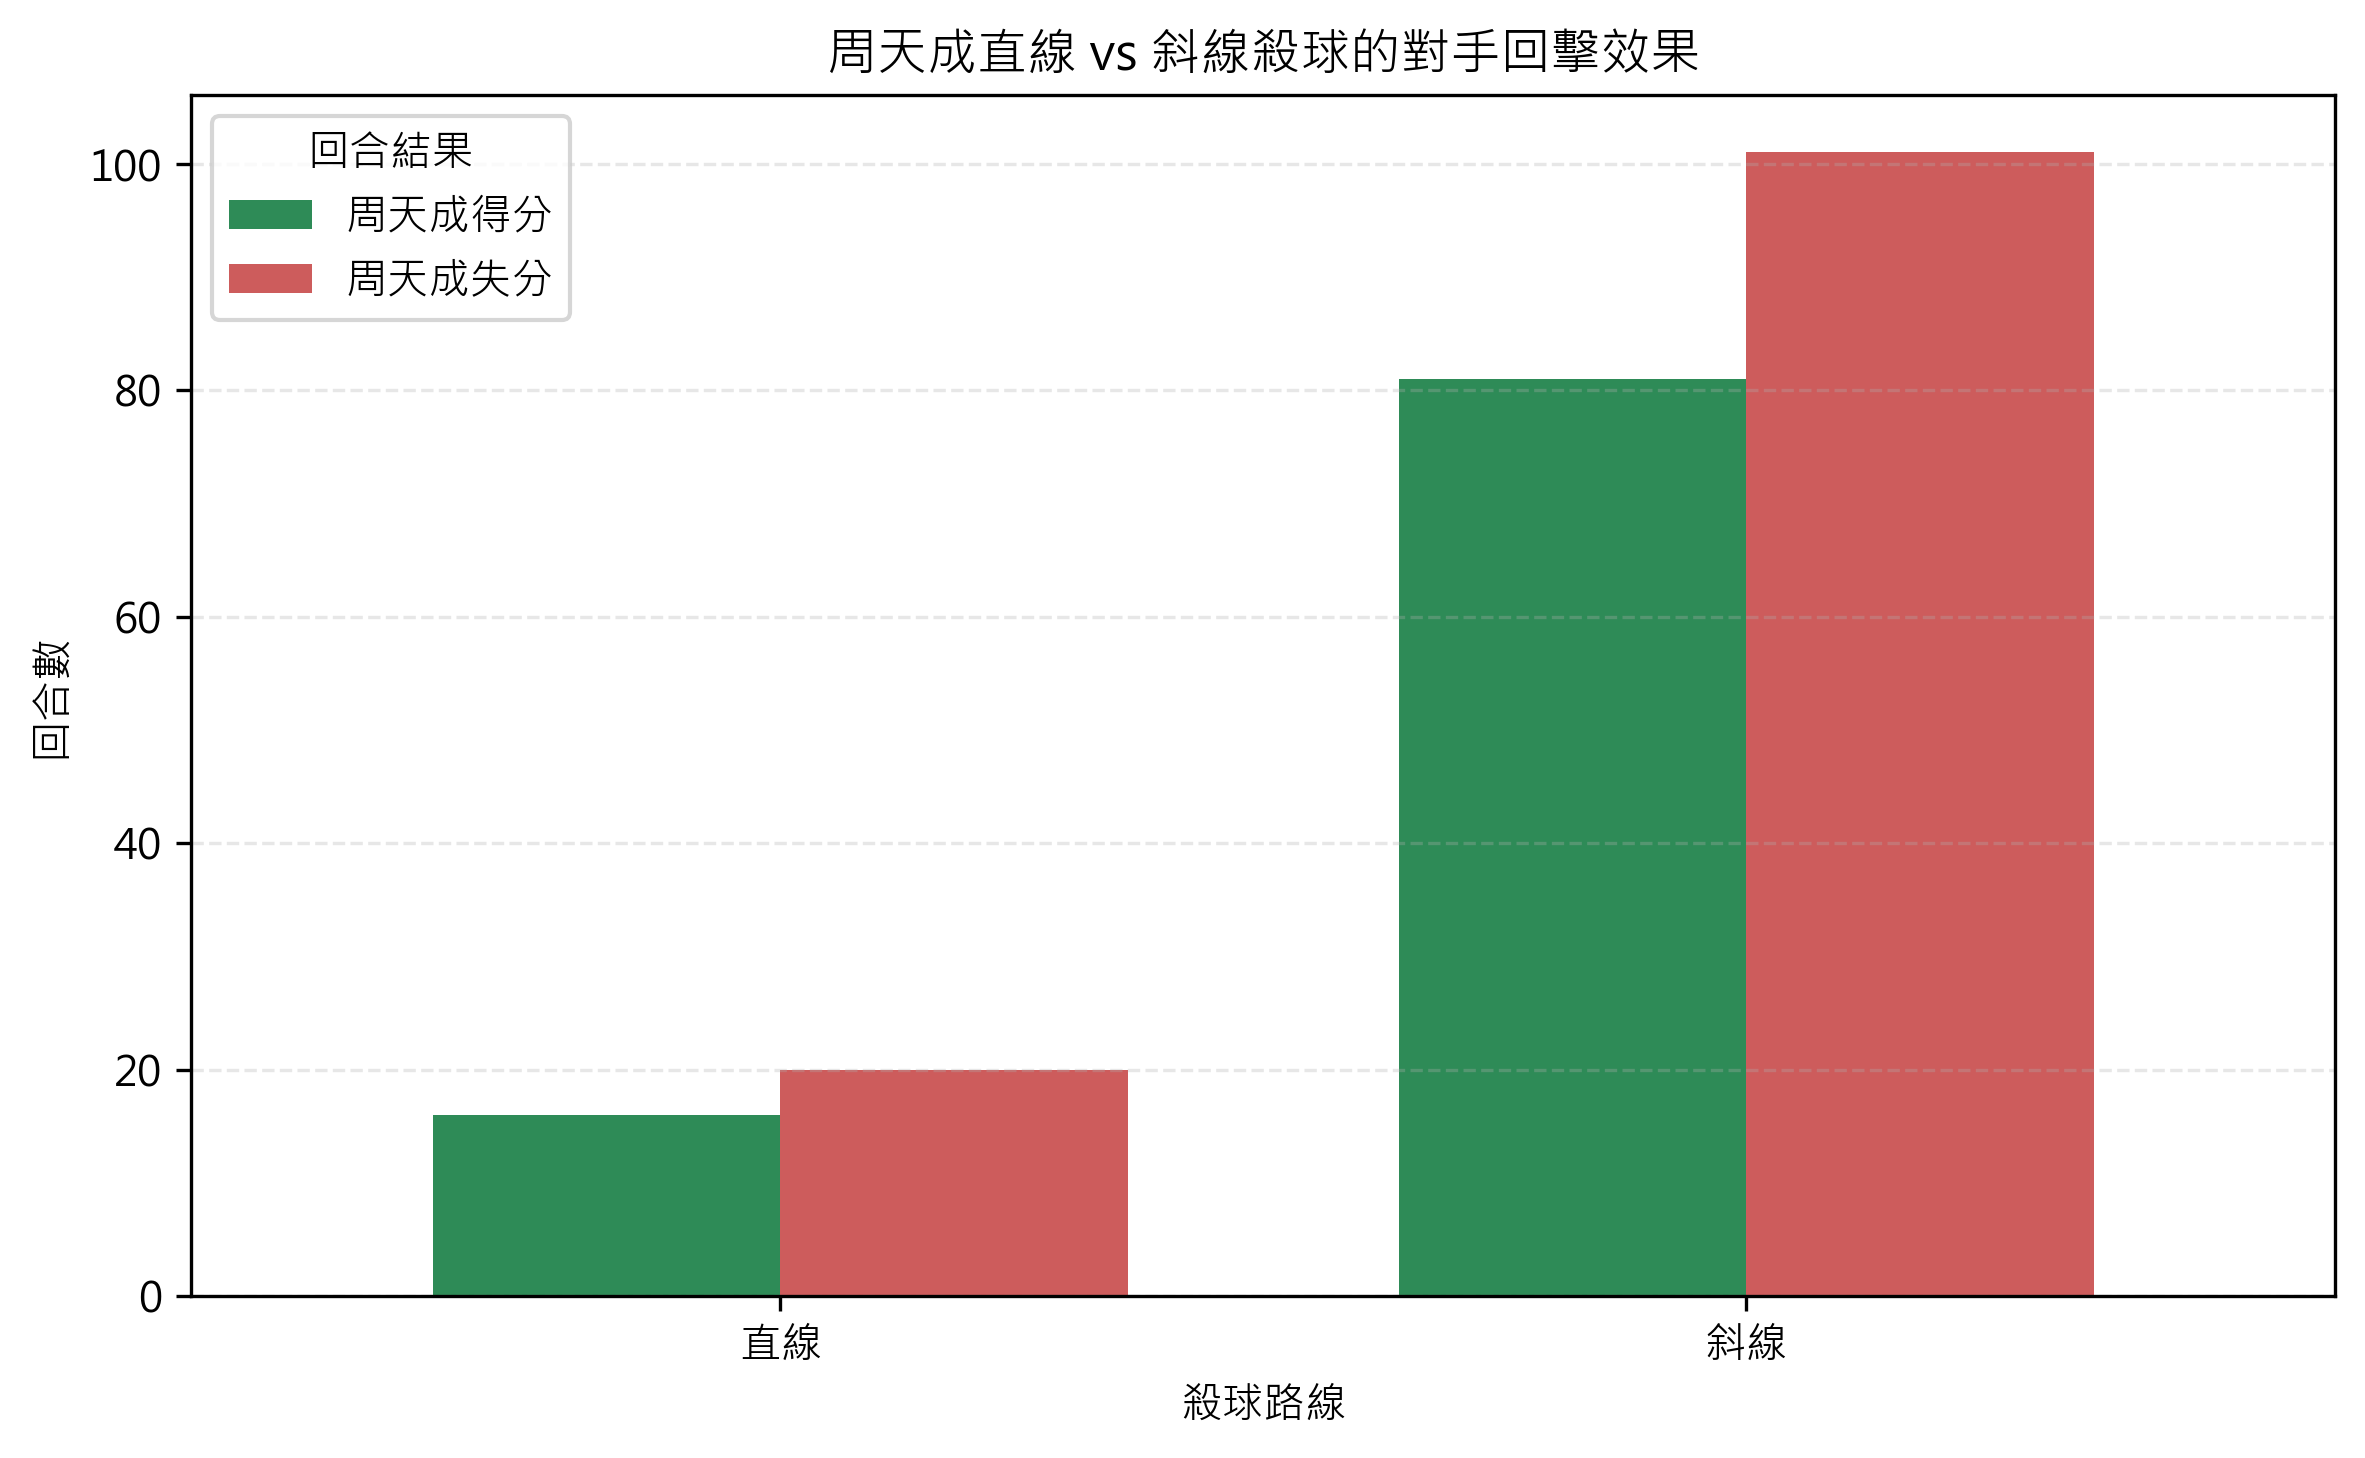

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'hit_area', 'landing_area', 'getpoint_player'
]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

if len(df) == 0:
    print("資料為空，無法分析。")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title("周天成直線 vs 斜線殺球的對手回擊效果")
    ax.axis("off")
else:
    player_name = 'CHOU Tien Chen'
    rally_keys = ['match_id', 'set', 'rally']

    data = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    data['rally_winner'] = data.groupby(rally_keys)['getpoint_player'].transform(
        lambda s: s.iloc[-1]
    )

    grouped = data.groupby(rally_keys, sort=False)

    data['next_player'] = grouped['player'].shift(-1)
    data['next_type'] = grouped['type'].shift(-1)
    data['next_ball_round'] = grouped['ball_round'].shift(-1)
    data['next_match_id'] = grouped['match_id'].shift(-1)
    data['next_set'] = grouped['set'].shift(-1)
    data['next_rally'] = grouped['rally'].shift(-1)

    same_rally_next = (
        data['next_match_id'].eq(data['match_id']) &
        data['next_set'].eq(data['set']) &
        data['next_rally'].eq(data['rally']) &
        data['next_player'].eq(data['opponent'])
    )

    smash = data[
        data['player'].eq(player_name) &
        data['type'].eq('殺球') &
        data['hit_area'].notna() &
        data['landing_area'].notna() &
        same_rally_next
    ].copy()

    def court_column(zone):
        zone = int(zone)
        if 1 <= zone <= 24:
            return (zone - 1) % 4
        return None

    smash['hit_column'] = smash['hit_area'].map(court_column)
    smash['landing_column'] = smash['landing_area'].map(court_column)

    smash = smash[
        smash['hit_column'].notna() &
        smash['landing_column'].notna()
    ].copy()

    smash['smash_direction'] = smash.apply(
        lambda row: (
            '直線'
            if row['hit_column'] == row['landing_column']
            else '斜線'
        ),
        axis=1
    )

    smash = smash[
        smash['rally_winner'].isin(
            [player_name, smash['opponent'].iloc[0] if len(smash) > 0 else '']
        )
    ].copy()

    smash['result'] = smash['rally_winner'].map({
        player_name: '周天成得分',
        'Kento MOMOTA': '周天成失分'
    })

    smash = smash[smash['result'].notna()].copy()

    direction_order = ['直線', '斜線']

    if len(smash) == 0:
        print("找不到符合條件的周天成殺球及同回合對手回擊資料。")
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title("周天成直線 vs 斜線殺球的對手回擊效果")
        ax.axis("off")
    else:
        summary = (
            smash.groupby(['smash_direction', 'result'])
            .size()
            .unstack(fill_value=0)
            .reindex(direction_order, fill_value=0)
        )

        for col in ['周天成得分', '周天成失分']:
            if col not in summary.columns:
                summary[col] = 0

        summary = summary[['周天成得分', '周天成失分']]
        summary['總回合'] = summary.sum(axis=1)
        summary['得分率'] = (
            summary['周天成得分'] / summary['總回合'] * 100
        ).round(2)
        summary['失分率'] = (
            summary['周天成失分'] / summary['總回合'] * 100
        ).round(2)

        print("分析口徑：")
        print("1. 僅納入周天成擊出的殺球。")
        print("2. 必須存在同一 match_id、set、rally 的下一拍，且下一拍擊球者為對手。")
        print("3. hit_area 與 landing_area 同欄定義為直線，不同欄定義為斜線。")
        print("4. 得失分依該回合最後一拍的 getpoint_player 判定。")
        print("5. 僅統計已產生得分者的完整回合。")
        print()
        print("場地區域定義：")
        print("後排：1-4；中排：5-16；前排：17-24；出界：25-32。")
        print("每排由左至右分為 A、B、C、D 四欄。")
        print()
        print("直線 vs 斜線殺球得失分比較：")
        print(summary)

        return_table = (
            smash.groupby(['smash_direction', 'next_type', 'result'])
            .size()
            .unstack(fill_value=0)
            .reset_index()
        )

        for col in ['周天成得分', '周天成失分']:
            if col not in return_table.columns:
                return_table[col] = 0

        return_table['總回合'] = (
            return_table['周天成得分'] + return_table['周天成失分']
        )
        return_table['周天成得分率'] = (
            return_table['周天成得分'] /
            return_table['總回合'] * 100
        ).round(2)

        return_table = return_table.sort_values(
            ['smash_direction', '總回合'],
            ascending=[True, False]
        )

        print()
        print("不同對手回擊球種下的得失分效果：")
        print(return_table.to_string(index=False))

        plot_data = summary[['周天成得分', '周天成失分']].copy()

        fig, ax = plt.subplots(figsize=(8, 5))
        plot_data.plot(
            kind='bar',
            ax=ax,
            color=['#2E8B57', '#CD5C5C'],
            width=0.72
        )
        ax.set_title("周天成直線 vs 斜線殺球的對手回擊效果")
        ax.set_xlabel("殺球路線")
        ax.set_ylabel("回合數")
        ax.set_xticklabels(direction_order, rotation=0)
        ax.legend(title="回合結果")
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 76
**問題**: 在被動情況下（跨步救球），下一拍攻擊性球種的成功機率。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
1. 被動情況以「接殺防守」作為跨步救球的資料代理。
2. 只保留同一 match_id、set、rally 的下一拍，且下一拍擊球者必須為原球員的對手。
3. 攻擊性球種定義為：殺球、推撲球、平球、網前球。
4. 下一拍攻擊成功：該拍未直接造成擊球者失分；回合尚未結束或擊球者主動得分均視為成功。

符合條件的被動後攻擊樣本數：409
成功次數：386
整體下一拍攻擊成功率：94.38%

下一拍攻擊性球種  次數  成功次數        成功率
      殺球  20    20 100.000000
      平球  20    19  95.000000
     網前球 214   203  94.859813
     推撲球 155   144  92.903226


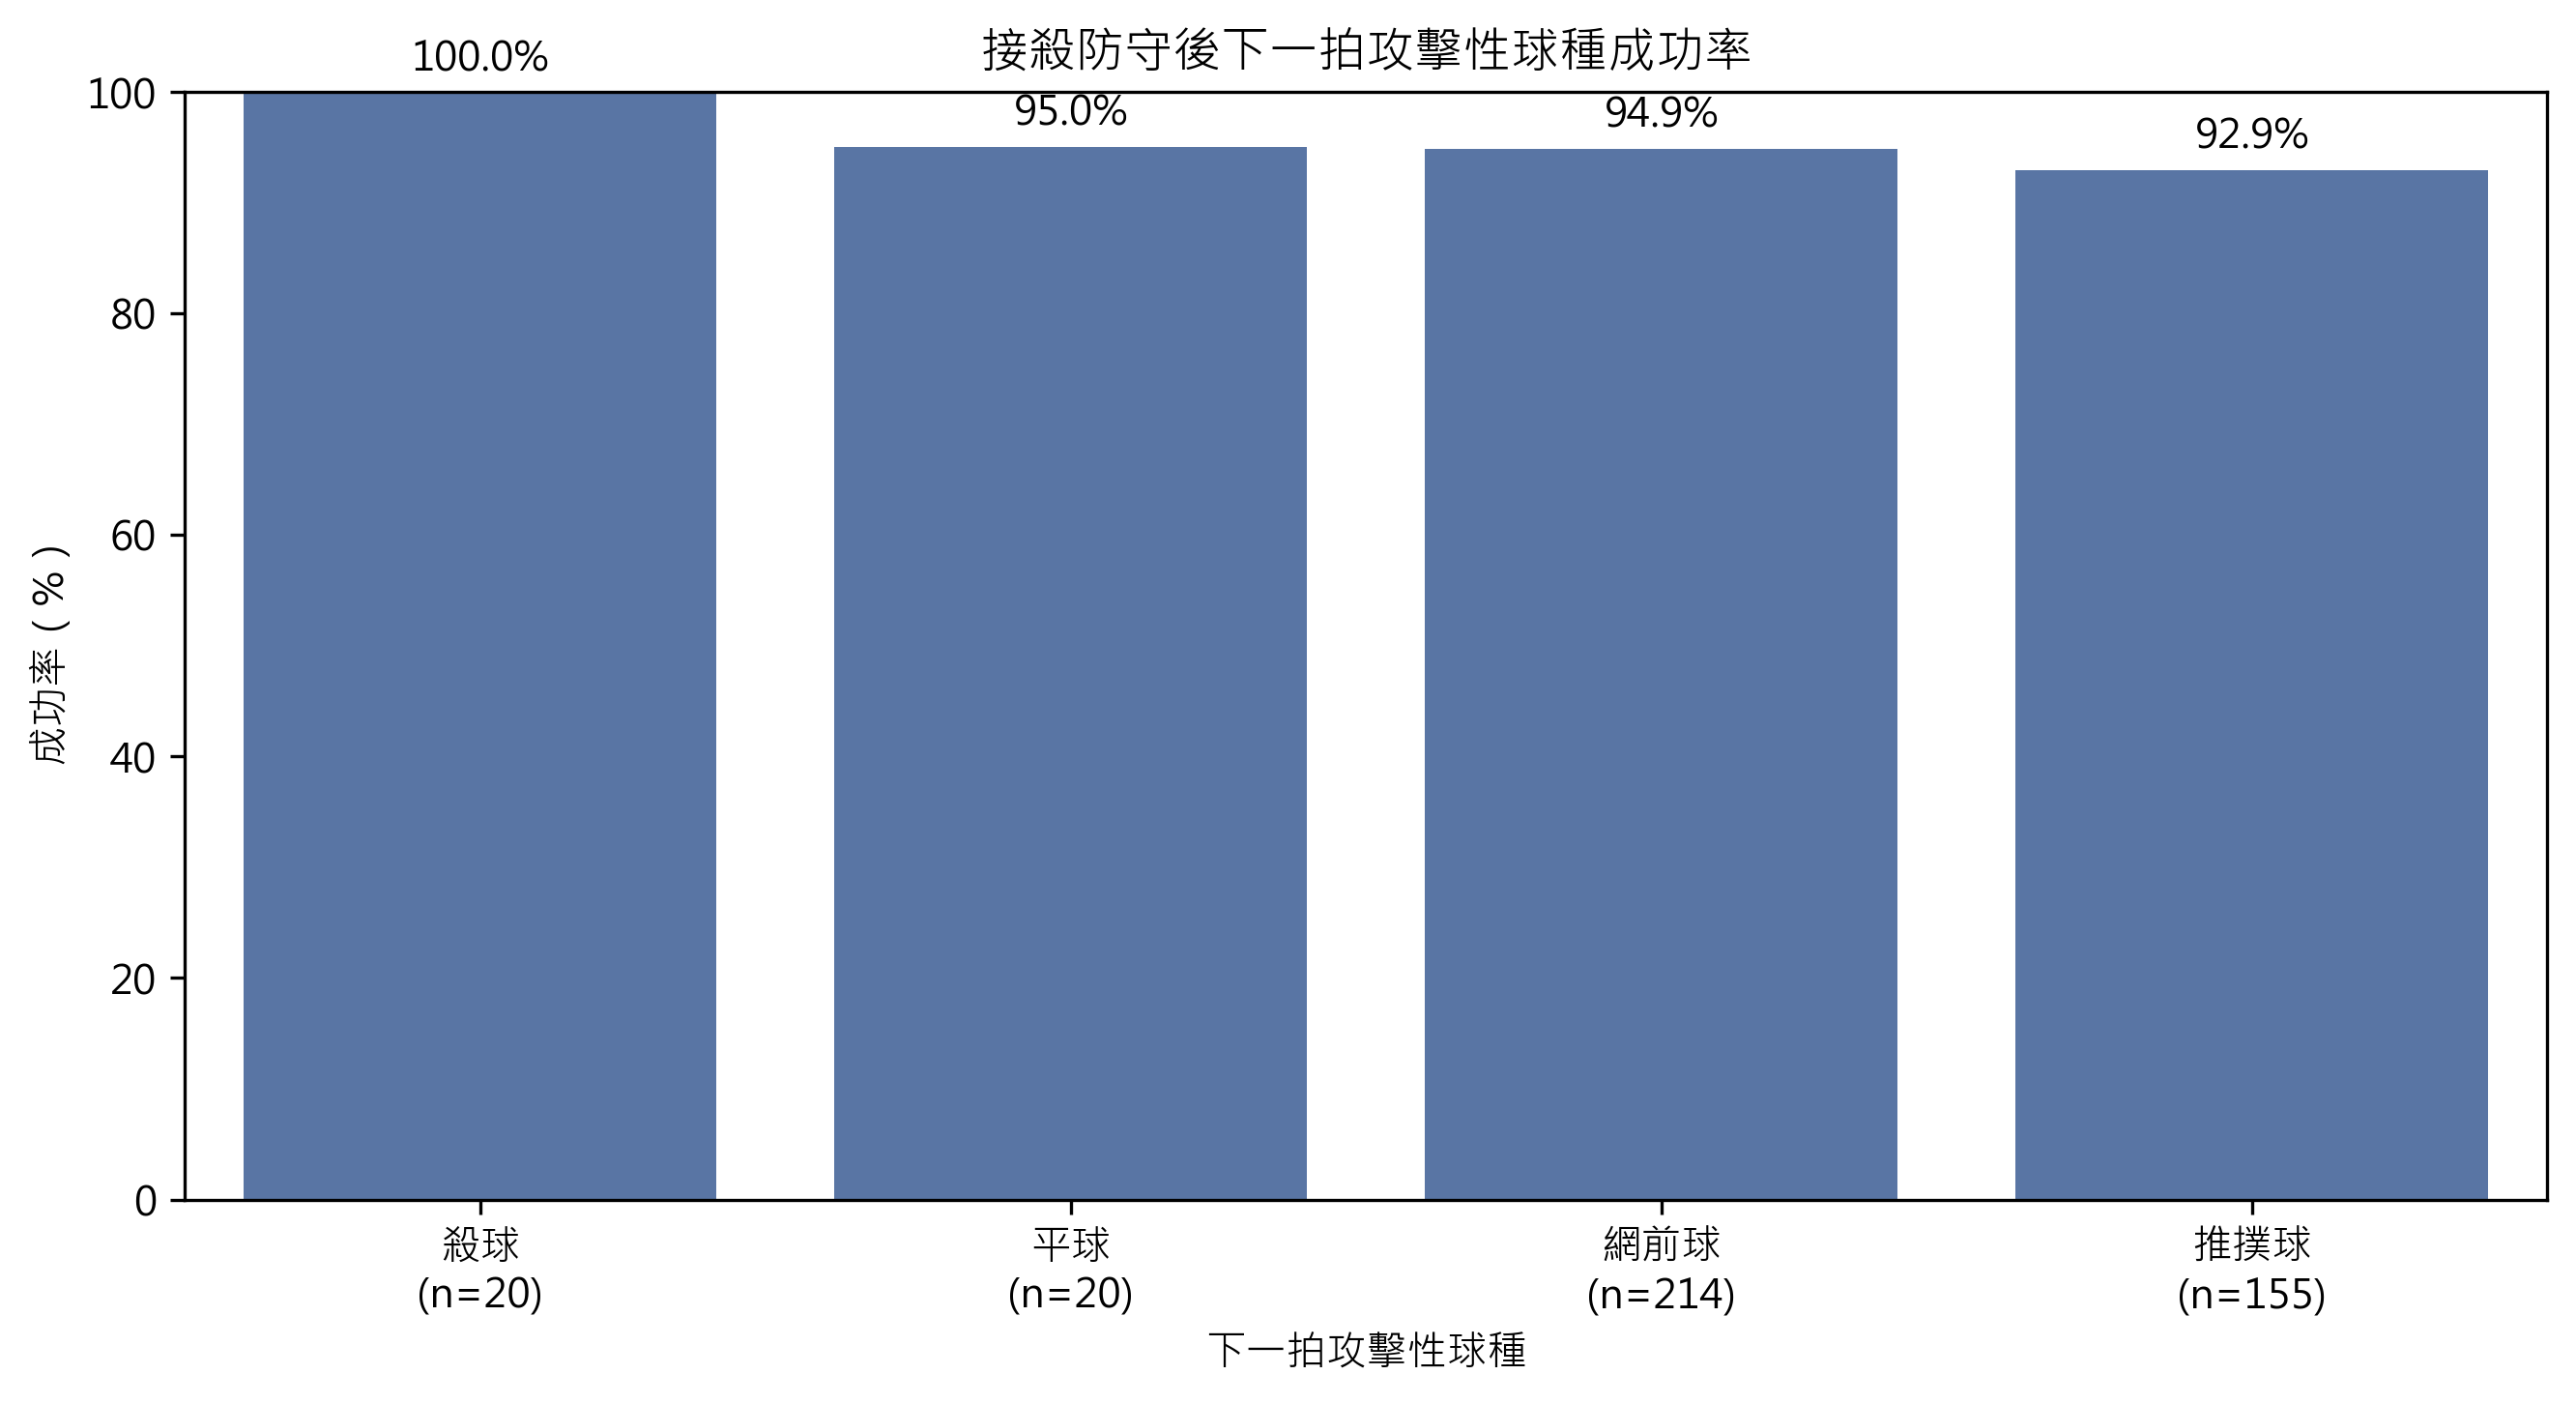

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player'
]

if len(df) == 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('資料為空，無法分析')
    ax.axis('off')
    plt.tight_layout()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title('缺少必要欄位，無法分析')
        ax.axis('off')
        plt.tight_layout()
    else:
        work_df = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        rally_cols = ['match_id', 'set', 'rally']

        work_df['next_player'] = (
            work_df.groupby(rally_cols, sort=False)['player'].shift(-1)
        )
        work_df['next_type'] = (
            work_df.groupby(rally_cols, sort=False)['type'].shift(-1)
        )
        work_df['next_getpoint_player'] = (
            work_df.groupby(rally_cols, sort=False)['getpoint_player'].shift(-1)
        )
        work_df['next_match_id'] = (
            work_df.groupby(rally_cols, sort=False)['match_id'].shift(-1)
        )
        work_df['next_set'] = (
            work_df.groupby(rally_cols, sort=False)['set'].shift(-1)
        )
        work_df['next_rally'] = (
            work_df.groupby(rally_cols, sort=False)['rally'].shift(-1)
        )

        attack_types = ['殺球', '推撲球', '平球', '網前球']

        passive_mask = (
            work_df['type'].eq('接殺防守') &
            work_df['next_match_id'].eq(work_df['match_id']) &
            work_df['next_set'].eq(work_df['set']) &
            work_df['next_rally'].eq(work_df['rally']) &
            work_df['next_player'].eq(work_df['opponent']) &
            work_df['next_type'].isin(attack_types)
        )

        analysis_df = work_df.loc[
            passive_mask,
            [
                'match_id', 'set', 'rally', 'player', 'opponent',
                'next_player', 'next_type', 'next_getpoint_player'
            ]
        ].copy()

        if len(analysis_df) == 0:
            print('沒有找到「接殺防守」後，同一回合由對手打出攻擊性球種的下一拍。')
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.set_title('沒有符合條件的資料')
            ax.axis('off')
            plt.tight_layout()
        else:
            analysis_df['next_attack_success'] = (
                analysis_df['next_getpoint_player'].isna() |
                analysis_df['next_getpoint_player'].eq(
                    analysis_df['next_player']
                )
            )

            total_attempts = len(analysis_df)
            successful_attempts = int(
                analysis_df['next_attack_success'].sum()
            )
            overall_success_rate = (
                successful_attempts / total_attempts * 100
            )

            result_by_type = (
                analysis_df.groupby('next_type', sort=False)
                .agg(
                    次數=('next_attack_success', 'size'),
                    成功次數=('next_attack_success', 'sum'),
                    成功率=('next_attack_success', 'mean')
                )
                .reset_index()
                .rename(columns={'next_type': '下一拍攻擊性球種'})
            )
            result_by_type['成功率'] = result_by_type['成功率'] * 100
            result_by_type['成功次數'] = result_by_type['成功次數'].astype(int)
            result_by_type = result_by_type.sort_values(
                ['成功率', '次數'],
                ascending=[False, False]
            ).reset_index(drop=True)

            print('統計口徑：')
            print('1. 被動情況以「接殺防守」作為跨步救球的資料代理。')
            print('2. 只保留同一 match_id、set、rally 的下一拍，且下一拍擊球者必須為原球員的對手。')
            print('3. 攻擊性球種定義為：殺球、推撲球、平球、網前球。')
            print('4. 下一拍攻擊成功：該拍未直接造成擊球者失分；回合尚未結束或擊球者主動得分均視為成功。')
            print()
            print(f'符合條件的被動後攻擊樣本數：{total_attempts}')
            print(f'成功次數：{successful_attempts}')
            print(f'整體下一拍攻擊成功率：{overall_success_rate:.2f}%')
            print()
            print(result_by_type.to_string(index=False))

            plot_df = result_by_type.copy()
            plot_df['標籤'] = (
                plot_df['下一拍攻擊性球種'] + '\n(n=' +
                plot_df['次數'].astype(str) + ')'
            )

            fig, ax = plt.subplots(figsize=(9, 5))
            sns.barplot(
                data=plot_df,
                x='標籤',
                y='成功率',
                color='#4C72B0',
                ax=ax
            )
            ax.set_title('接殺防守後下一拍攻擊性球種成功率')
            ax.set_xlabel('下一拍攻擊性球種')
            ax.set_ylabel('成功率（%）')
            ax.set_ylim(0, 100)

            for container in ax.containers:
                ax.bar_label(
                    container,
                    labels=[
                        f'{value:.1f}%'
                        for value in plot_df['成功率']
                    ],
                    padding=3
                )

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 79
**問題**: 計算對手挑球過短時，周天成球種的選擇統計。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
1. 以同一 match_id、set、rally 內的前一拍作為對手上一拍。
2. 前一拍球種為「挑球」，且落點位於中排或前排 Zone 5–24，定義為挑球過短。
3. 統計周天成緊接著的下一拍球種選擇。

符合條件的周天成回擊拍數：96

周天成球種選擇統計：
type  次數    比例
  殺球  58 60.42
  長球  18 18.75
  切球  13 13.54
  平球   5  5.21
 推撲球   2  2.08


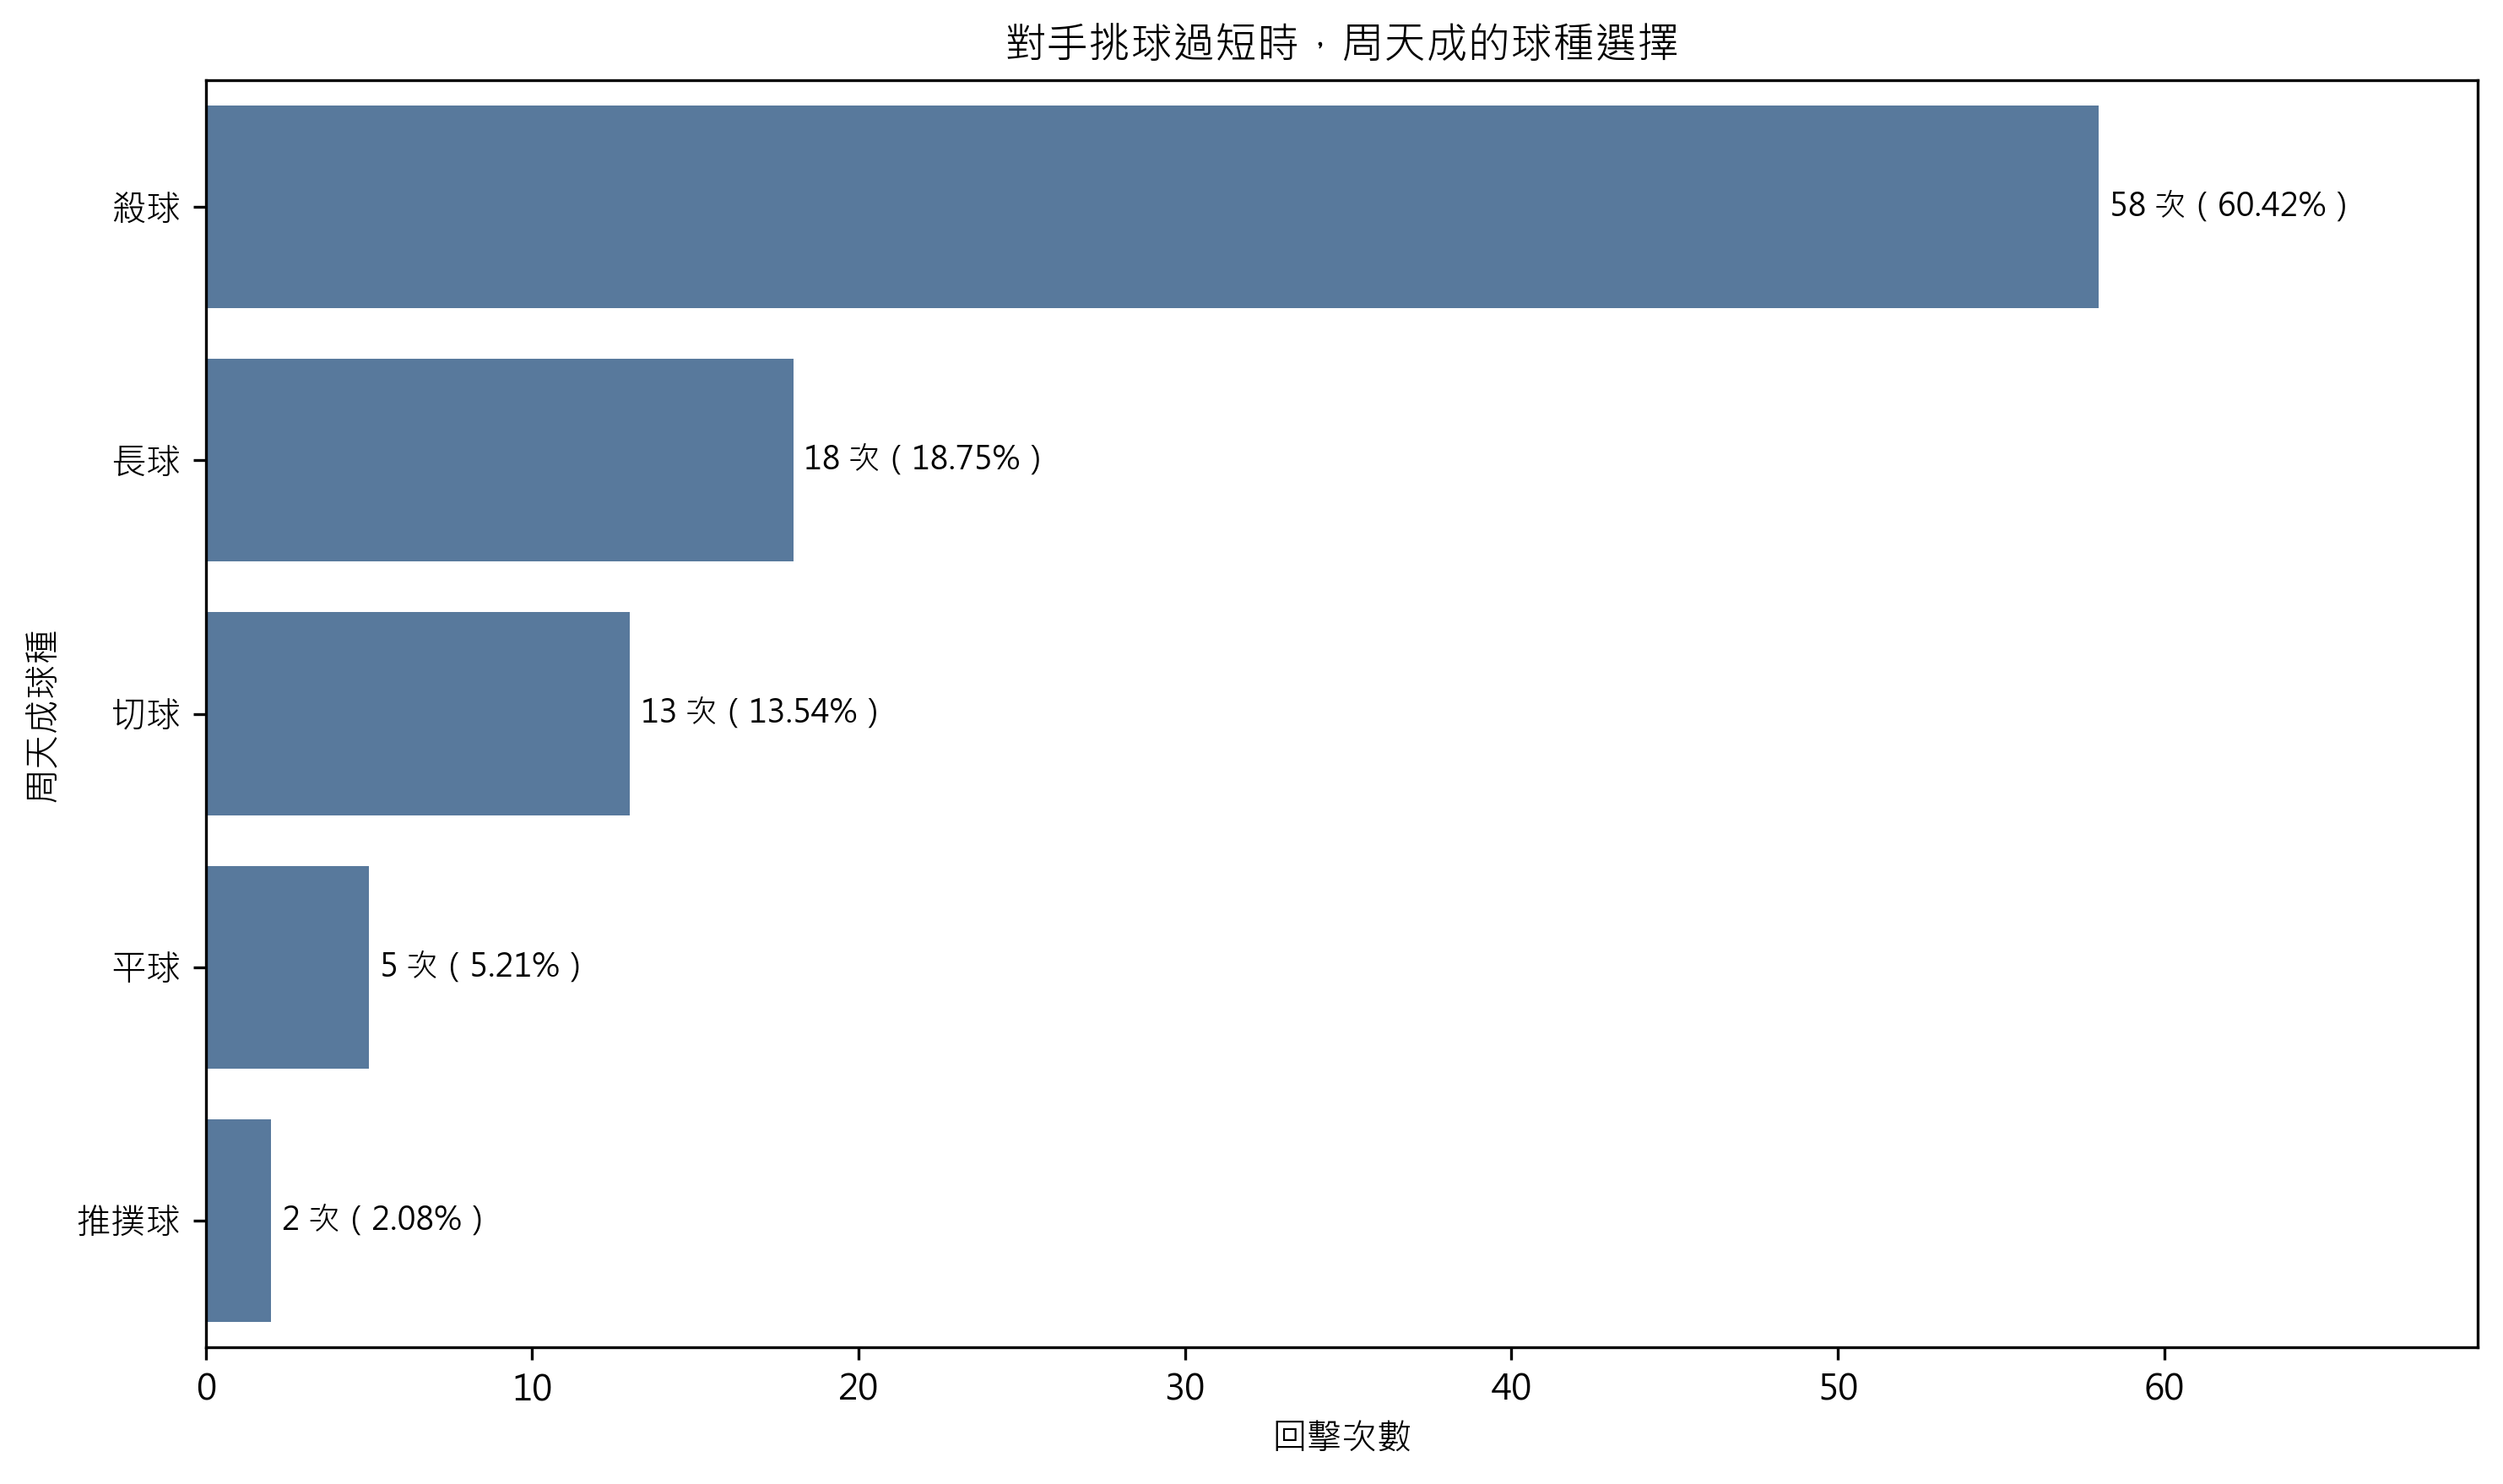

In [ ]:
if len(df) == 0:
    print("資料為空，無法計算。")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.text(0.5, 0.5, "無資料", ha="center", va="center")
    ax.axis("off")
else:
    target_player = "CHOU Tien Chen"

    court_grid = {
        "後排": [1, 2, 3, 4],
        "中排": [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
        "前排": [17, 18, 19, 20, 21, 22, 23, 24],
        "出界": [25, 26, 27, 28, 29, 30, 31, 32],
    }

    in_court_short_lift_zones = (
        court_grid["中排"] + court_grid["前排"]
    )

    work = (
        df.sort_values(["match_id", "set", "rally", "ball_round"])
          .copy()
    )

    group_cols = ["match_id", "set", "rally"]
    grouped = work.groupby(group_cols, sort=False)

    work["prev_player"] = grouped["player"].shift(1)
    work["prev_type"] = grouped["type"].shift(1)
    work["prev_landing_area"] = grouped["landing_area"].shift(1)

    response_mask = (
        (work["player"] == target_player)
        & (work["prev_player"] == work["opponent"])
        & (work["prev_type"] == "挑球")
        & (work["prev_landing_area"].isin(in_court_short_lift_zones))
        & work["type"].notna()
    )

    response_df = work.loc[
        response_mask,
        ["match_id", "set", "rally", "ball_round", "prev_landing_area", "type"]
    ].copy()

    if len(response_df) == 0:
        print("找不到對手挑球落在中排或前排的有效回擊資料。")
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, "無符合條件的資料", ha="center", va="center")
        ax.axis("off")
    else:
        total_responses = len(response_df)

        selection_stats = (
            response_df.groupby("type", as_index=False)
                       .size()
                       .rename(columns={"size": "次數"})
                       .sort_values(["次數", "type"], ascending=[False, True])
        )
        selection_stats["比例"] = (
            selection_stats["次數"] / total_responses * 100
        ).round(2)

        print("統計口徑：")
        print("1. 以同一 match_id、set、rally 內的前一拍作為對手上一拍。")
        print("2. 前一拍球種為「挑球」，且落點位於中排或前排 Zone 5–24，定義為挑球過短。")
        print("3. 統計周天成緊接著的下一拍球種選擇。")
        print(f"\n符合條件的周天成回擊拍數：{total_responses}")
        print("\n周天成球種選擇統計：")
        print(selection_stats.to_string(index=False))

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(
            data=selection_stats,
            x="次數",
            y="type",
            color="#4C78A8",
            ax=ax
        )
        ax.set_title("對手挑球過短時，周天成的球種選擇")
        ax.set_xlabel("回擊次數")
        ax.set_ylabel("周天成球種")
        ax.set_xlim(0, max(selection_stats["次數"]) * 1.2)

        for container in ax.containers:
            ax.bar_label(
                container,
                labels=[
                    f"{int(value)} 次（{ratio:.2f}%）"
                    for value, ratio in zip(
                        selection_stats["次數"],
                        selection_stats["比例"]
                    )
                ],
                padding=3,
                fontsize=9
            )

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 80
**問題**: 當周天成發現自己較容易掛網時，應該如何調整自己的擊球策略與站位，以減少掛網失誤的發生？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析球員：CHOU Tien Chen
完整資料筆數：5204
總回合數：409
CHOU Tien Chen擊球筆數：2609
CHOU Tien Chen掛網失誤次數：60
每次擊球掛網率：2.30%

各球種掛網風險：
      擊球次數  掛網次數   掛網率
type                  
接殺防守   351    18 5.13%
網前球    582    29 4.98%
平球     106     3 2.83%
殺球     299     3 1.00%
切球     211     2 0.95%
推撲球    334     3 0.90%
挑球     270     2 0.74%
長球     275     0 0.00%
發短球    147     0 0.00%
發長球     34     0 0.00%
…（輸出已截斷；notebook 僅保留重點）


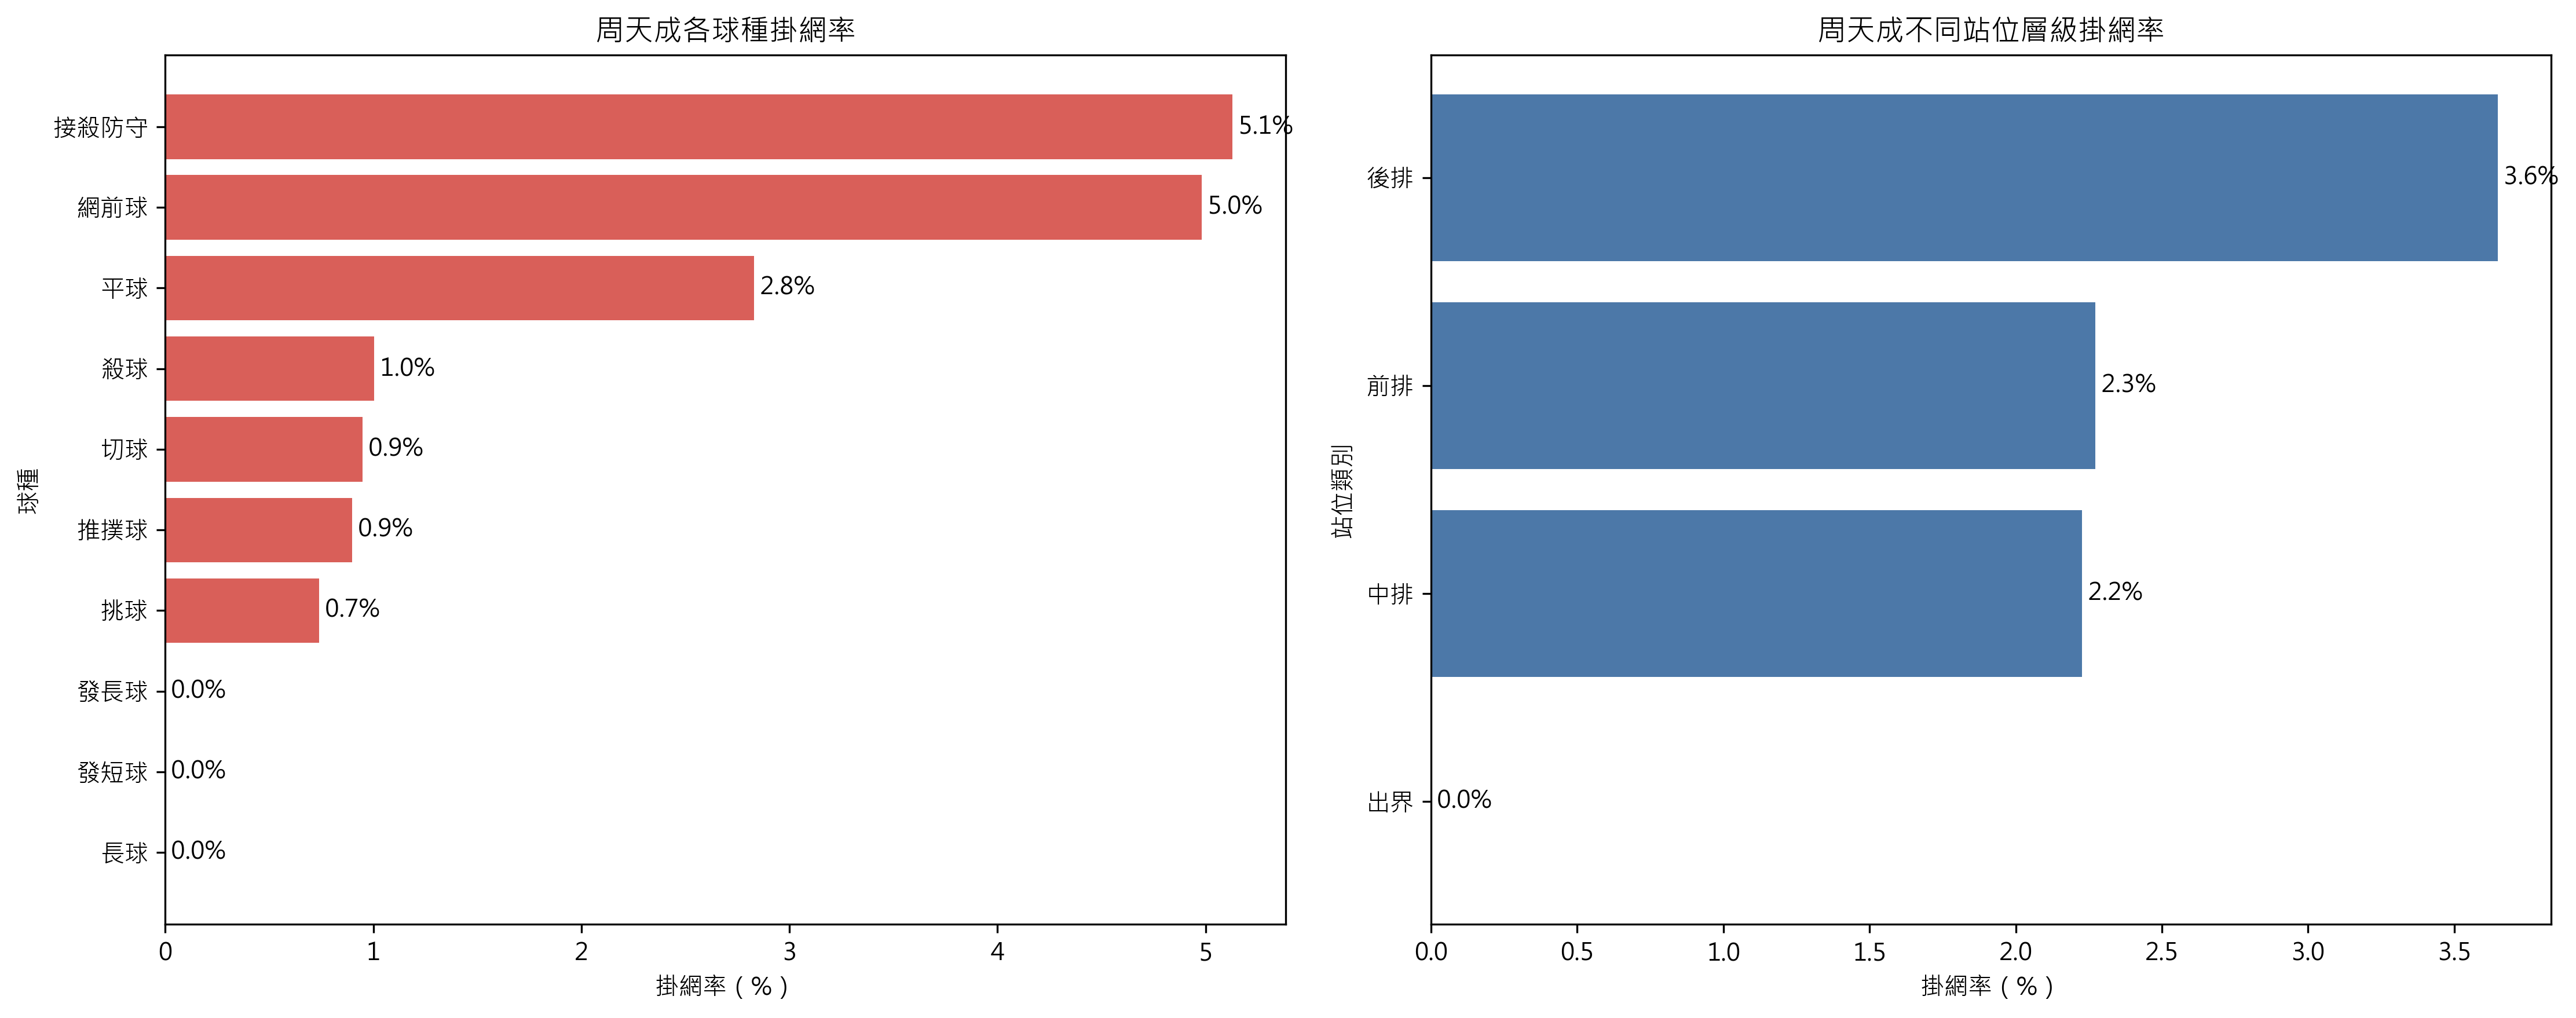

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    import numpy as np

    player_name = "CHOU Tien Chen"
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player", "opponent",
        "type", "getpoint_player", "lose_reason", "player_location_area",
        "hit_area"
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        data = df.copy()
        data = data.sort_values(
            ["match_id", "set", "rally", "ball_round"]
        ).reset_index(drop=True)

        rally_keys = ["match_id", "set", "rally"]
        data["rally_getpoint_player"] = (
            data.groupby(rally_keys)["getpoint_player"].transform("last")
        )

        # 建立完整資料上的前後拍欄位，避免先篩選後 shift 造成跨拍污染
        grouped = data.groupby(rally_keys, sort=False)
        data["prev_player"] = grouped["player"].shift(1)
        data["prev_type"] = grouped["type"].shift(1)
        data["prev_hit_area"] = grouped["hit_area"].shift(1)
        data["prev_player_location_area"] = (
            grouped["player_location_area"].shift(1)
        )
        data["next_player"] = grouped["player"].shift(-1)
        data["next_type"] = grouped["type"].shift(-1)

        # 失誤定義：周天成最後一拍擊球，且對手取得該回合分數
        chou_shots = data[data["player"] == player_name].copy()
        chou_errors = chou_shots[
            (chou_shots["getpoint_player"] == chou_shots["opponent"])
            & (chou_shots["lose_reason"] == "掛網")
        ].copy()

        total_rallies = data.groupby(rally_keys).ngroups
        chou_rallies = chou_shots.groupby(rally_keys).ngroups
        net_error_count = len(chou_errors)

        print(f"分析球員：{player_name}")
        print(f"完整資料筆數：{len(data)}")
        print(f"總回合數：{total_rallies}")
        print(f"{player_name}擊球筆數：{len(chou_shots)}")
        print(f"{player_name}掛網失誤次數：{net_error_count}")

        if len(chou_shots) > 0:
            overall_net_error_rate = net_error_count / len(chou_shots)
            print(f"每次擊球掛網率：{overall_net_error_rate:.2%}")
        else:
            overall_net_error_rate = np.nan
            print("沒有周天成的擊球資料。")

        # 球種掛網風險：分母為周天成該球種的所有擊球
        type_stats = (
            chou_shots.groupby("type", dropna=False)
            .size()
            .rename("擊球次數")
            .to_frame()
        )
        type_stats["掛網次數"] = (
            chou_errors.groupby("type", dropna=False)
            .size()
            .reindex(type_stats.index, fill_value=0)
        )
        type_stats["掛網率"] = (
            type_stats["掛網次數"] / type_stats["擊球次數"]
        )
        type_stats = type_stats.sort_values(
            ["掛網率", "掛網次數", "擊球次數"],
            ascending=[False, False, False]
        )

        print("\n各球種掛網風險：")
        print(type_stats.to_string(formatters={"掛網率": "{:.2%}".format}))

        # Court Grid Definitions
        front_zones = {21, 22, 23, 24, 17, 18, 19, 20}
        mid_zones = {5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}
        back_zones = {1, 2, 3, 4}
        out_zones = {25, 26, 27, 28, 29, 30, 31, 32}

        row_names = {
            1: "後排", 2: "中排", 3: "中排",
            4: "中排", 5: "前排", 6: "前排"
        }
        col_names = {1: "左", 2: "中左", 3: "中右", 4: "右"}

        def zone_label(zone):
            if pd.isna(zone):
                return "未知"
            zone = int(zone)

            if zone in back_zones:
                col = ((zone - 1) % 4) + 1
                return f"後排-{col_names[col]}"

            if zone in mid_zones:
                row = ((zone - 1) // 4) + 1
                col = ((zone - 1) % 4) + 1
                return f"{row_names[row]}-{col_names[col]}"

            if zone in front_zones:
                row = ((zone - 1) // 4) + 1
                col = ((zone - 1) % 4) + 1
                return f"{row_names[row]}-{col_names[col]}"

            if zone in {25, 26, 27}:
                return "右側出界"
            if zone in {29, 30, 31}:
                return "左側出界"
            if zone in {28, 32}:
                return "後方出界"
            return "未知"

        def zone_category(zone):
            if pd.isna(zone):
                return "未知"
            zone = int(zone)
            if zone in front_zones:
                return "前排"
            if zone in mid_zones:
                return "中排"
            if zone in back_zones:
                return "後排"
            if zone in out_zones:
                return "出界"
            return "未知"

        chou_shots["站位區域"] = chou_shots["player_location_area"].map(
            zone_label
        )
        chou_errors["站位區域"] = chou_errors["player_location_area"].map(
            zone_label
        )

        position_stats = (
            chou_shots.groupby("站位區域", dropna=False)
            .size()
            .rename("擊球次數")
            .to_frame()
        )
        position_stats["掛網次數"] = (
            chou_errors.groupby("站位區域", dropna=False)
            .size()
            .reindex(position_stats.index, fill_value=0)
        )
        position_stats["掛網率"] = (
            position_stats["掛網次數"] / position_stats["擊球次數"]
        )
        position_stats = position_stats.sort_values(
            ["掛網率", "掛網次數", "擊球次數"],
            ascending=[False, False, False]
        )

        print("\n不同站位的掛網風險：")
        print(
            position_stats.to_string(
                formatters={"掛網率": "{:.2%}".format}
            )
        )

        # 以較穩定的區域層級補充站位建議
        chou_shots["站位類別"] = chou_shots["player_location_area"].map(
            zone_category
        )
        chou_errors["站位類別"] = chou_errors["player_location_area"].map(
            zone_category
        )

        category_stats = (
            chou_shots.groupby("站位類別", dropna=False)
            .size()
            .rename("擊球次數")
            .to_frame()
        )
        category_stats["掛網次數"] = (
            chou_errors.groupby("站位類別", dropna=False)
            .size()
            .reindex(category_stats.index, fill_value=0)
        )
        category_stats["掛網率"] = (
            category_stats["掛網次數"] / category_stats["擊球次數"]
        )
        category_stats = category_stats.sort_values(
            "掛網率", ascending=False
        )

        print("\n前、中、後排的掛網風險：")
        print(
            category_stats.to_string(
                formatters={"掛網率": "{:.2%}".format}
            )
        )

        # 掛網前一拍情境：只在同一 match/set/rally 內分析
        error_context = chou_errors[
            chou_errors["prev_player"].notna()
            & (chou_errors["prev_player"] == chou_errors["opponent"])
        ].copy()

        if len(error_context) > 0:
            previous_type_stats = (
                error_context.groupby("prev_type", dropna=False)
                .size()
                .rename("掛網前一拍次數")
                .sort_values(ascending=False)
            )
            print("\n掛網前一拍對手球種分布：")
            print(previous_type_stats.to_string())
        else:
            previous_type_stats = pd.Series(dtype="int64")
            print("\n沒有足夠資料分析掛網前一拍。")

        # 產生資料支持的策略建議
        print("\n資料導向的調整建議：")

        reliable_types = type_stats[type_stats["擊球次數"] >= 10]
        if len(reliable_types) > 0:
            highest_risk_type = reliable_types.iloc[0]
            safest_type = reliable_types.sort_values(
                ["掛網率", "擊球次數"],
                ascending=[True, False]
            ).iloc[0]

            print(
                f"1. 優先檢視「{reliable_types.index[0]}」："
                f"在至少10次使用的球種中，掛網率為"
                f"{highest_risk_type['掛網率']:.2%}。"
                f"在壓力較大或擊球點較低時，可降低該球種的使用比例，"
                f"改以掛網率較低的「{safest_type.name}」或較保守的高球處理。"
            )
        else:
            print(
                "1. 各球種有效樣本不足10次，暫不宜據此大幅改變球種選擇，"
                "應先累積更多比賽樣本。"
            )

        reliable_positions = position_stats[
            position_stats["擊球次數"] >= 10
        ]
        if len(reliable_positions) > 0:
            high_position = reliable_positions.iloc[0]
            print(
                f"2. 站位方面，「{reliable_positions.index[0]}」的掛網率為"
                f"{high_position['掛網率']:.2%}。"
                "在該區域擊球時，應提早回位、避免身體重心落後於擊球點，"
                "並保留較高的過網安全高度；若非必要，避免在失去平衡時強行下壓。"
            )
        else:
            print(
                "2. 各細部站位樣本不足10次，先以擊球點與身體平衡作為站位調整依據。"
            )

        if len(category_stats) > 0:
            high_category = category_stats.iloc[0]
            print(
                f"3. 站位層級上，「{category_stats.index[0]}」掛網率最高，"
                f"為{high_category['掛網率']:.2%}。"
                "進入此區域時，應縮短移動後的急停時間，"
                "讓擊球點保持在身前，並優先使用可控的直線球或高弧線球。"
            )

        if len(previous_type_stats) > 0:
            previous_type = previous_type_stats.index[0]
            print(
                f"4. 掛網失誤最常出現在對手前一拍為「{previous_type}」之後。"
                "面對此類來球，應先確保擊球高度與身體平衡，"
                "不要只追求快速下壓；若擊球點不足，改採較高容錯的回球。"
            )

        print(
            "\n口徑說明：掛網失誤僅計算 "
            "player=周天成、getpoint_player=對手且lose_reason=掛網；"
            "掛網率分母為周天成該球種或該站位的全部擊球次數。"
        )
        print(
            "Court Grid：1-4為後排、5-16為中排、17-24為前排；"
            "25-27為右側出界、29-31為左側出界、28與32為後方出界。"
        )

        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        if len(type_stats) > 0:
            plot_type = type_stats.sort_values("掛網率", ascending=True)
            axes[0].barh(
                plot_type.index.astype(str),
                plot_type["掛網率"] * 100,
                color="#D95F59"
            )
            axes[0].set_title("周天成各球種掛網率")
            axes[0].set_xlabel("掛網率（%）")
            axes[0].set_ylabel("球種")
            for i, value in enumerate(plot_type["掛網率"] * 100):
                axes[0].text(value, i, f" {value:.1f}%", va="center")
        else:
            axes[0].set_title("沒有球種資料")

        if len(category_stats) > 0:
            plot_category = category_stats.sort_values(
                "掛網率", ascending=True
            )
            axes[1].barh(
                plot_category.index.astype(str),
                plot_category["掛網率"] * 100,
                color="#4C78A8"
            )
            axes[1].set_title("周天成不同站位層級掛網率")
            axes[1].set_xlabel("掛網率（%）")
            axes[1].set_ylabel("站位類別")
            for i, value in enumerate(plot_category["掛網率"] * 100):
                axes[1].text(value, i, f" {value:.1f}%", va="center")
        else:
            axes[1].set_title("沒有站位資料")

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 82
**問題**: 統計周天成成功逼迫對手挑球的頻率，以及最常造成的球種來源。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成成功逼迫對手挑球次數：432
有效逼迫機會數（周天成擊球後有對手回擊）：2364
成功逼迫對手挑球頻率：18.27%
最常造成對手挑球的球種：網前球 （293 次，67.82%）
造成挑球的球種  次數  佔成功逼迫挑球比例
    網前球 293  67.824074
   接殺防守  79  18.287037
    發短球  40   9.259259
     切球  17   3.935185
     殺球   1   0.231481
     平球   1   0.231481
    推撲球   1   0.231481


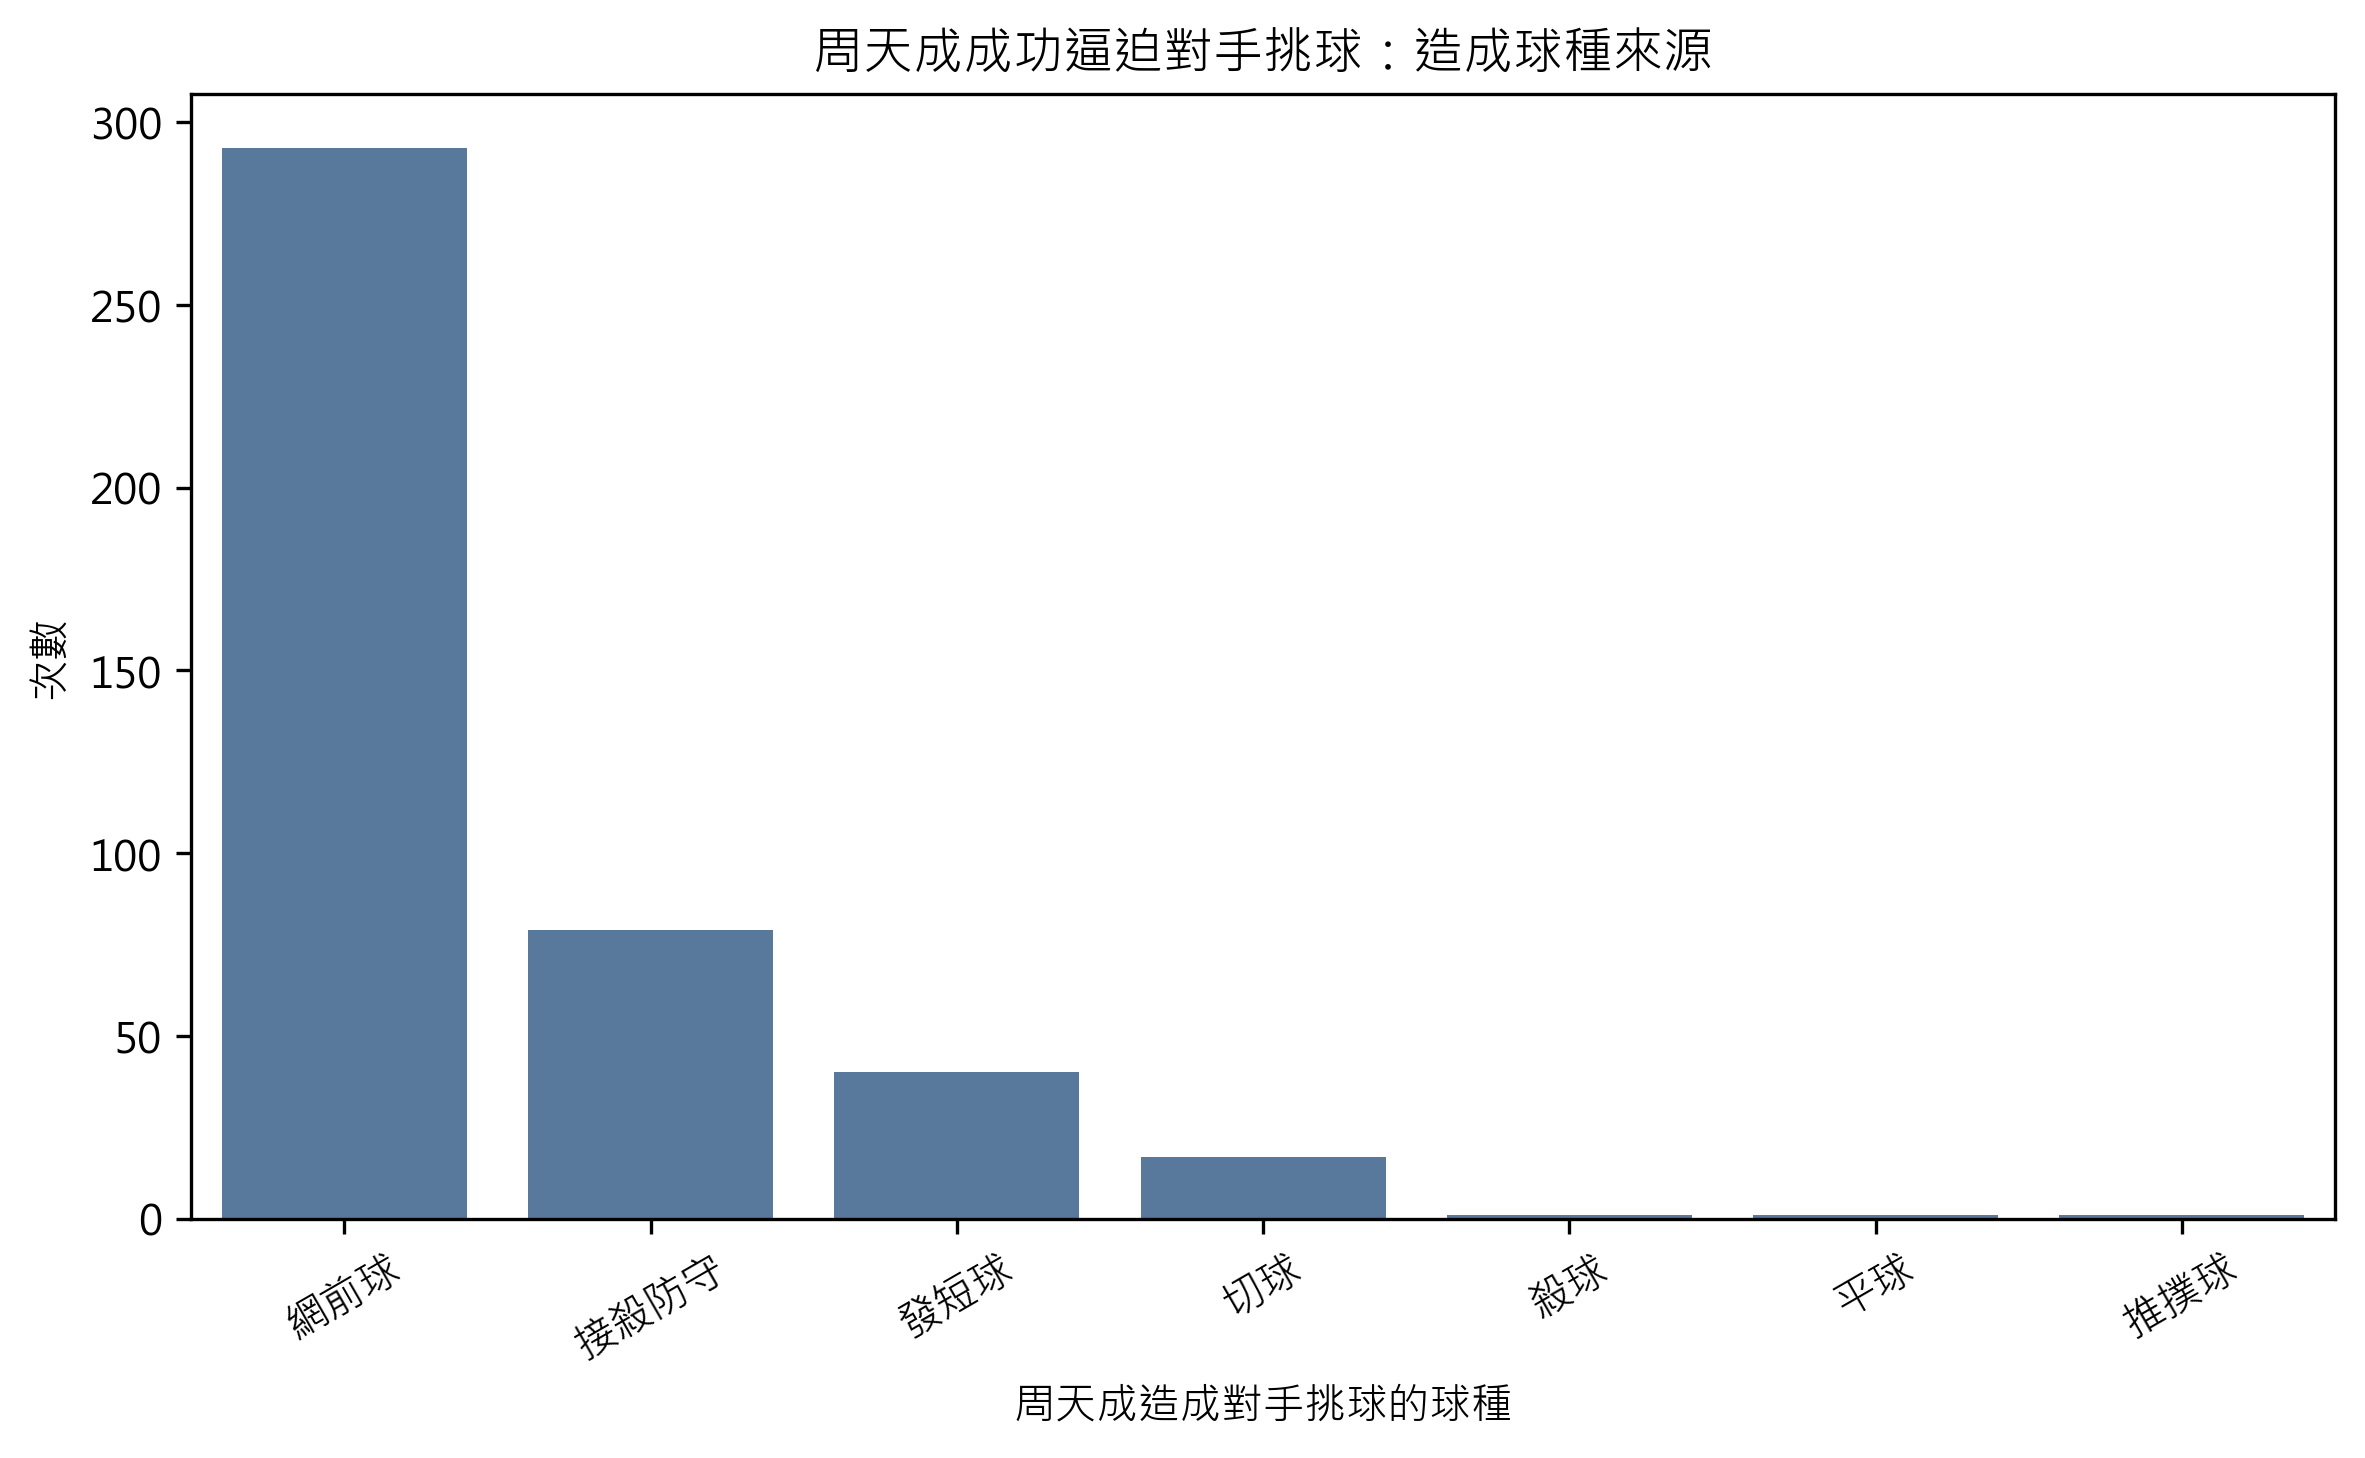

In [ ]:
if len(df) == 0:
    print("資料為空，無法統計。")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.text(0.5, 0.5, "無資料", ha="center", va="center")
    ax.set_axis_off()
else:
    player_name = "CHOU Tien Chen"
    target_return = "挑球"

    data = df.sort_values(
        ["match_id", "set", "rally", "ball_round"]
    ).copy()

    rally_group = data.groupby(
        ["match_id", "set", "rally"],
        sort=False
    )

    data["next_player"] = rally_group["player"].shift(-1)
    data["next_type"] = rally_group["type"].shift(-1)

    # 周天成擊球後，同一回合由對手接續且回擊挑球，視為成功逼迫挑球
    chou_shots = data[
        data["player"].eq(player_name)
        & data["next_player"].eq(data["opponent"])
        & data["next_type"].notna()
    ].copy()

    forced_lob = chou_shots[
        chou_shots["next_type"].eq(target_return)
    ].copy()

    opportunity_count = len(chou_shots)
    forced_count = len(forced_lob)
    forced_frequency = (
        forced_count / opportunity_count * 100
        if opportunity_count > 0 else 0
    )

    print(f"周天成成功逼迫對手挑球次數：{forced_count}")
    print(f"有效逼迫機會數（周天成擊球後有對手回擊）：{opportunity_count}")
    print(f"成功逼迫對手挑球頻率：{forced_frequency:.2f}%")

    source_counts = (
        forced_lob["type"]
        .value_counts()
        .rename_axis("造成挑球的球種")
        .reset_index(name="次數")
    )

    if forced_count > 0:
        source_counts["佔成功逼迫挑球比例"] = (
            source_counts["次數"] / forced_count * 100
        )
        most_common_source = source_counts.iloc[0]
        print(
            f"最常造成對手挑球的球種：{most_common_source['造成挑球的球種']} "
            f"（{int(most_common_source['次數'])} 次，"
            f"{most_common_source['佔成功逼迫挑球比例']:.2f}%）"
        )
        print(source_counts.to_string(index=False))
    else:
        print("沒有觀察到周天成成功逼迫對手挑球的紀錄。")
        source_counts = pd.DataFrame(
            columns=["造成挑球的球種", "次數", "佔成功逼迫挑球比例"]
        )

    fig, ax = plt.subplots(figsize=(8, 5))

    if len(source_counts) > 0:
        sns.barplot(
            data=source_counts,
            x="造成挑球的球種",
            y="次數",
            color="#4C78A8",
            ax=ax
        )
        ax.set_title("周天成成功逼迫對手挑球：造成球種來源")
        ax.set_xlabel("周天成造成對手挑球的球種")
        ax.set_ylabel("次數")
        ax.tick_params(axis="x", rotation=30)
    else:
        ax.text(0.5, 0.5, "無成功逼迫挑球紀錄", ha="center", va="center")
        ax.set_axis_off()

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 83
**問題**: 周天成挑高球的落點分布，是否常造成對手容易得分？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


CHOU Tien Chen「挑球」且有同回合下一拍的次數：253
對手下一拍得分：9 次，得分率：3.56%
其中對手下一拍主動得分：0 次，主動得分率：0.00%

各落點區域分布與對手下一拍得分率：
 落點區域 場地類別 相對位置  挑球次數  對手下一拍得分次數  對手下一拍主動得分次數  對手下一拍被動得分次數 對手下一拍得分率 對手下一拍主動得分率
   10   中排 中場中左     3          1            0            1   33.33%      0.00%
    2   後排 後場中左    10          2            0            2   20.00%      0.00%
    6   中排 中場中左     9          1            0            1   11.11%      0.00%
    8   中排  中場右    19          2            0            2   10.53%      0.00%
    5   中排  中場左    21          2            0            2    9.52%      0.00%
    4   後排  後場右    79          1            0            1    1.27%      0.00%
    3   後排 後場中右    54          0            0            0    0.00%      0.00%
    1   後排  後場左    28          0            0            0    0.00%      0.00%
    7   中排 中場中右    27          0            0            0    0.00%      0.00%
    9   中排  中場左     1          0            0            0    0.00%      0.00%
   11   中排 中場中右     1       

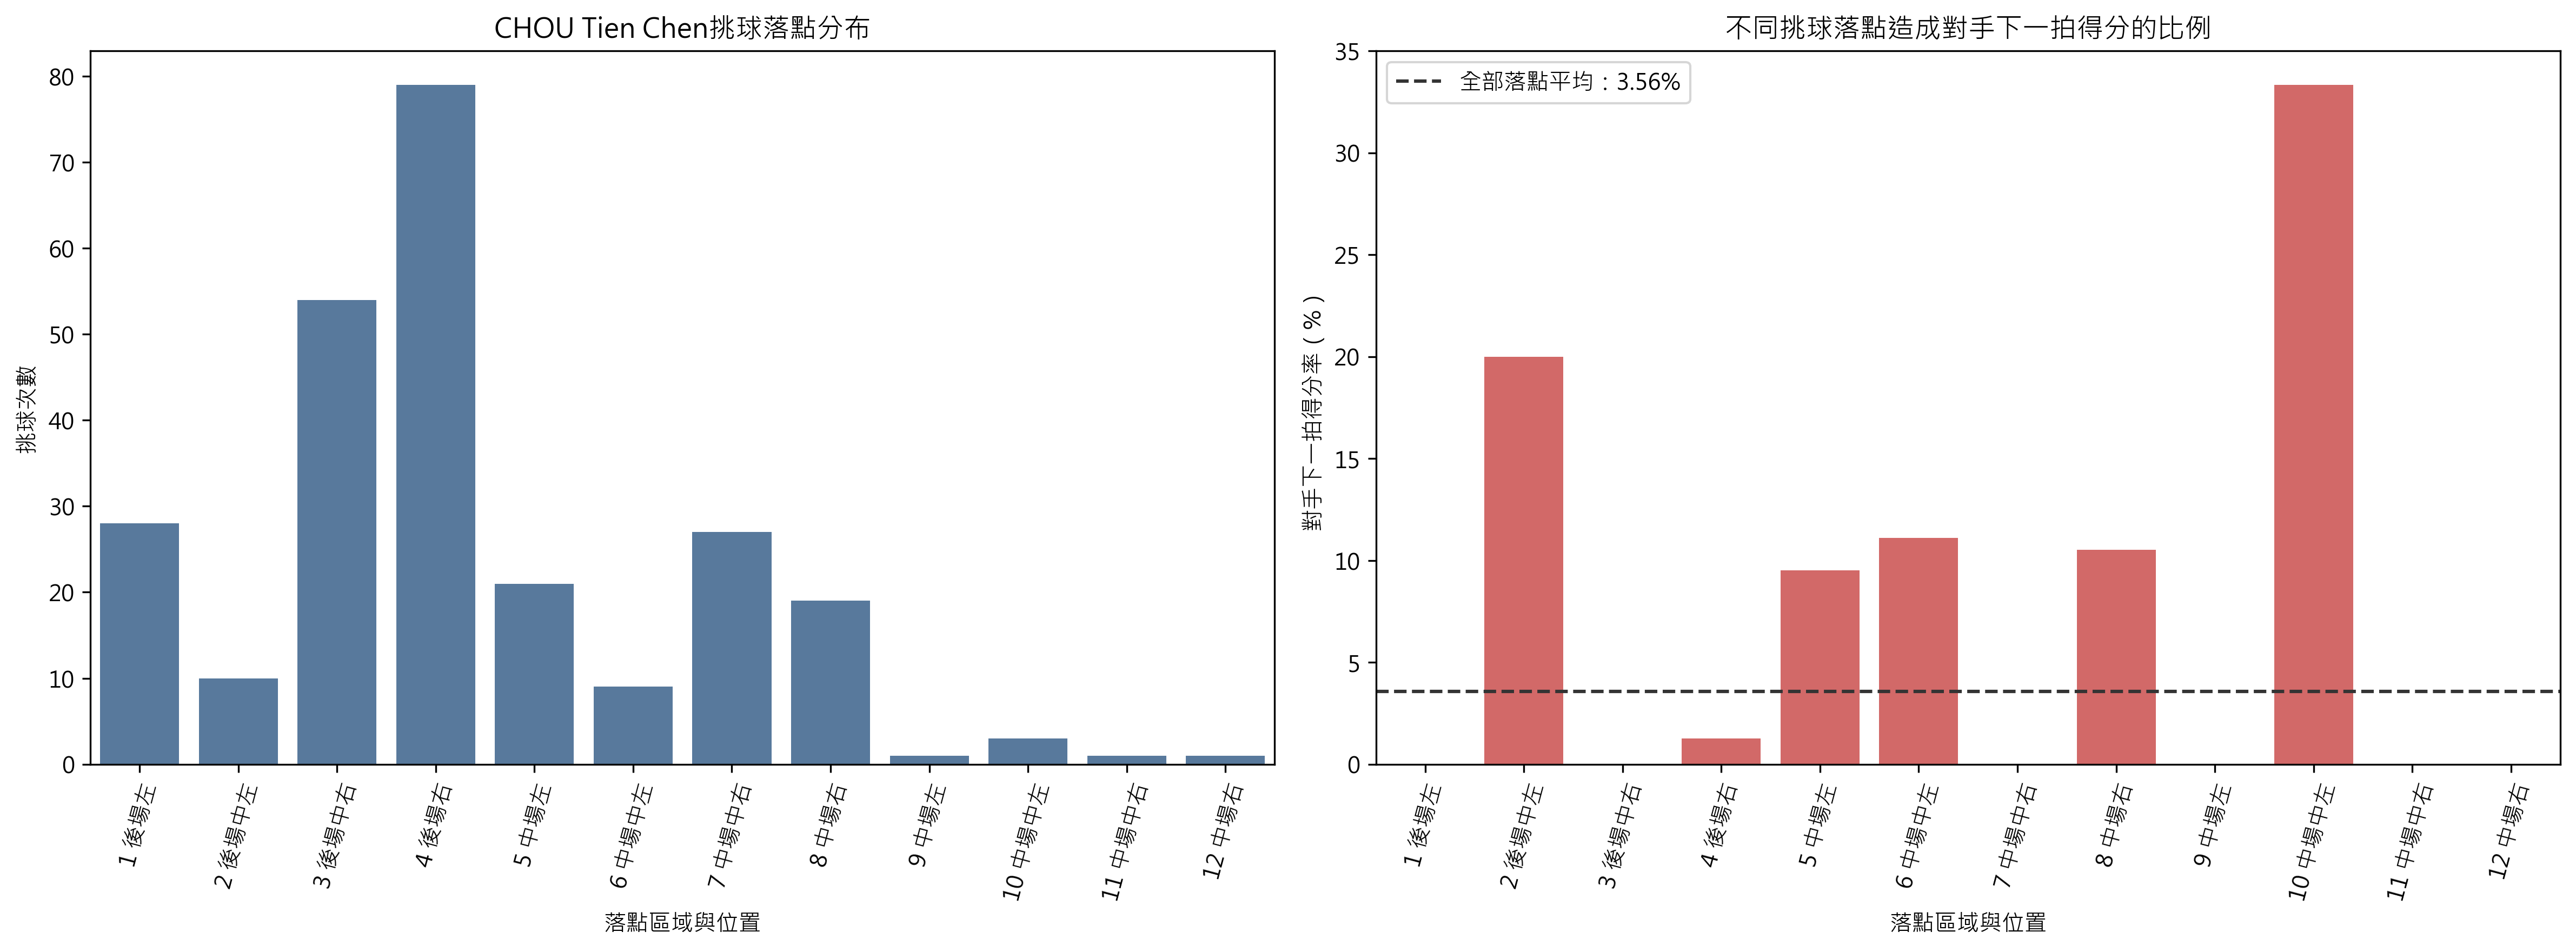

In [ ]:
if len(df) == 0:
    print("資料為空，無法分析。")
else:
    target_player = "CHOU Tien Chen"
    target_type = "挑球"
    required_cols = [
        "match_id", "set", "rally", "ball_round", "player", "opponent",
        "type", "landing_area", "getpoint_player"
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        print(f"缺少必要欄位：{missing_cols}")
    else:
        work = df.sort_values(
            ["match_id", "set", "rally", "ball_round"]
        ).copy()

        rally_keys = ["match_id", "set", "rally"]
        grouped = work.groupby(rally_keys, sort=False)

        work["next_player"] = grouped["player"].shift(-1)
        work["next_opponent"] = grouped["opponent"].shift(-1)
        work["next_getpoint_player"] = grouped["getpoint_player"].shift(-1)
        work["next_type"] = grouped["type"].shift(-1)

        work["has_next_same_rally"] = (
            work["next_player"].notna()
            & (work["next_player"] == work["opponent"])
        )

        work["next_opponent_scored"] = (
            work["has_next_same_rally"]
            & work["next_getpoint_player"].notna()
            & (work["next_getpoint_player"] == target_player)
        )

        work["next_opponent_active_win"] = (
            work["next_opponent_scored"]
            & (work["next_player"] == work["next_getpoint_player"])
        )

        work["next_opponent_passive_win"] = (
            work["next_opponent_scored"]
            & (work["next_player"] != work["next_getpoint_player"])
        )

        lob_df = work[
            (work["player"] == target_player)
            & (work["type"] == target_type)
            & work["landing_area"].notna()
        ].copy()

        if len(lob_df) == 0:
            print(f"找不到 {target_player} 的「{target_type}」資料。")
        else:
            zone_info = {
                1: ("後排", "後場左"),
                2: ("後排", "後場中左"),
                3: ("後排", "後場中右"),
                4: ("後排", "後場右"),
                5: ("中排", "中場左"),
                6: ("中排", "中場中左"),
                7: ("中排", "中場中右"),
                8: ("中排", "中場右"),
                9: ("中排", "中場左"),
                10: ("中排", "中場中左"),
                11: ("中排", "中場中右"),
                12: ("中排", "中場右"),
                13: ("中排", "中場左"),
                14: ("中排", "中場中左"),
                15: ("中排", "中場中右"),
                16: ("中排", "中場右"),
                17: ("前排", "前場左"),
                18: ("前排", "前場中左"),
                19: ("前排", "前場中右"),
                20: ("前排", "前場右"),
                21: ("前排", "網前左"),
                22: ("前排", "網前中左"),
                23: ("前排", "網前中右"),
                24: ("前排", "網前右"),
                25: ("出界", "右側上方出界"),
                26: ("出界", "右側中間出界"),
                27: ("出界", "右側下方出界"),
                28: ("出界", "右後方出界"),
                29: ("出界", "左側上方出界"),
                30: ("出界", "左側中間出界"),
                31: ("出界", "左側下方出界"),
                32: ("出界", "左後方出界"),
            }

            lob_df["落點區域"] = lob_df["landing_area"].astype(int)
            lob_df["場地類別"] = lob_df["落點區域"].map(
                lambda z: zone_info.get(z, ("未知", "未知"))[0]
            )
            lob_df["相對位置"] = lob_df["落點區域"].map(
                lambda z: zone_info.get(z, ("未知", "未知"))[1]
            )

            valid_next = lob_df[lob_df["has_next_same_rally"]].copy()

            if len(valid_next) == 0:
                print("挑球資料存在，但沒有可觀察的同回合下一拍，無法判斷是否立即造成對手得分。")
            else:
                summary = (
                    valid_next.groupby(
                        ["落點區域", "場地類別", "相對位置"],
                        dropna=False
                    )
                    .agg(
                        挑球次數=("落點區域", "size"),
                        對手下一拍得分次數=("next_opponent_scored", "sum"),
                        對手下一拍主動得分次數=("next_opponent_active_win", "sum"),
                        對手下一拍被動得分次數=("next_opponent_passive_win", "sum"),
                    )
                    .reset_index()
                )

                summary["對手下一拍得分率"] = (
                    summary["對手下一拍得分次數"]
                    / summary["挑球次數"]
                    * 100
                )
                summary["對手下一拍主動得分率"] = (
                    summary["對手下一拍主動得分次數"]
                    / summary["挑球次數"]
                    * 100
                )

                total_lobs = len(valid_next)
                total_opponent_scores = int(
                    valid_next["next_opponent_scored"].sum()
                )
                total_opponent_active_wins = int(
                    valid_next["next_opponent_active_win"].sum()
                )

                overall_score_rate = total_opponent_scores / total_lobs * 100
                overall_active_rate = (
                    total_opponent_active_wins / total_lobs * 100
                )

                print(f"{target_player}「{target_type}」且有同回合下一拍的次數：{total_lobs}")
                print(f"對手下一拍得分：{total_opponent_scores} 次，得分率：{overall_score_rate:.2f}%")
                print(
                    f"其中對手下一拍主動得分：{total_opponent_active_wins} 次，"
                    f"主動得分率：{overall_active_rate:.2f}%"
                )
                print("\n各落點區域分布與對手下一拍得分率：")

                output_cols = [
                    "落點區域", "場地類別", "相對位置", "挑球次數",
                    "對手下一拍得分次數", "對手下一拍主動得分次數",
                    "對手下一拍被動得分次數", "對手下一拍得分率",
                    "對手下一拍主動得分率"
                ]
                print(
                    summary.sort_values(
                        ["對手下一拍得分率", "挑球次數"],
                        ascending=[False, False]
                    )[output_cols].to_string(
                        index=False,
                        formatters={
                            "對手下一拍得分率": "{:.2f}%".format,
                            "對手下一拍主動得分率": "{:.2f}%".format,
                        }
                    )
                )

                distribution = (
                    valid_next.groupby(
                        ["落點區域", "相對位置"],
                        dropna=False
                    )
                    .size()
                    .reset_index(name="挑球次數")
                    .sort_values("落點區域")
                )
                distribution["落點標籤"] = (
                    distribution["落點區域"].astype(str)
                    + " "
                    + distribution["相對位置"].astype(str)
                )

                rate_plot = summary.sort_values("落點區域").copy()
                rate_plot["落點標籤"] = (
                    rate_plot["落點區域"].astype(str)
                    + " "
                    + rate_plot["相對位置"].astype(str)
                )

                fig, axes = plt.subplots(1, 2, figsize=(16, 6))

                sns.barplot(
                    data=distribution,
                    x="落點標籤",
                    y="挑球次數",
                    color="#4C78A8",
                    ax=axes[0]
                )
                axes[0].set_title(f"{target_player}挑球落點分布")
                axes[0].set_xlabel("落點區域與位置")
                axes[0].set_ylabel("挑球次數")
                axes[0].tick_params(axis="x", rotation=75)

                sns.barplot(
                    data=rate_plot,
                    x="落點標籤",
                    y="對手下一拍得分率",
                    color="#E45756",
                    ax=axes[1]
                )
                axes[1].axhline(
                    overall_score_rate,
                    color="#333333",
                    linestyle="--",
                    label=f"全部落點平均：{overall_score_rate:.2f}%"
                )
                axes[1].set_title("不同挑球落點造成對手下一拍得分的比例")
                axes[1].set_xlabel("落點區域與位置")
                axes[1].set_ylabel("對手下一拍得分率（%）")
                axes[1].tick_params(axis="x", rotation=75)
                axes[1].legend()

                plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 84
**問題**: 當周天成採取多拍耐心拉吊策略時的平均勝率。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：至少 6 拍，且周天成在該回合至少使用 2 拍「長球」或「切球」；僅納入已產生得分者的回合。
符合策略回合數：124
周天成勝利回合數：52
周天成失利回合數：72
周天成多拍耐心拉吊策略平均勝率：41.94%


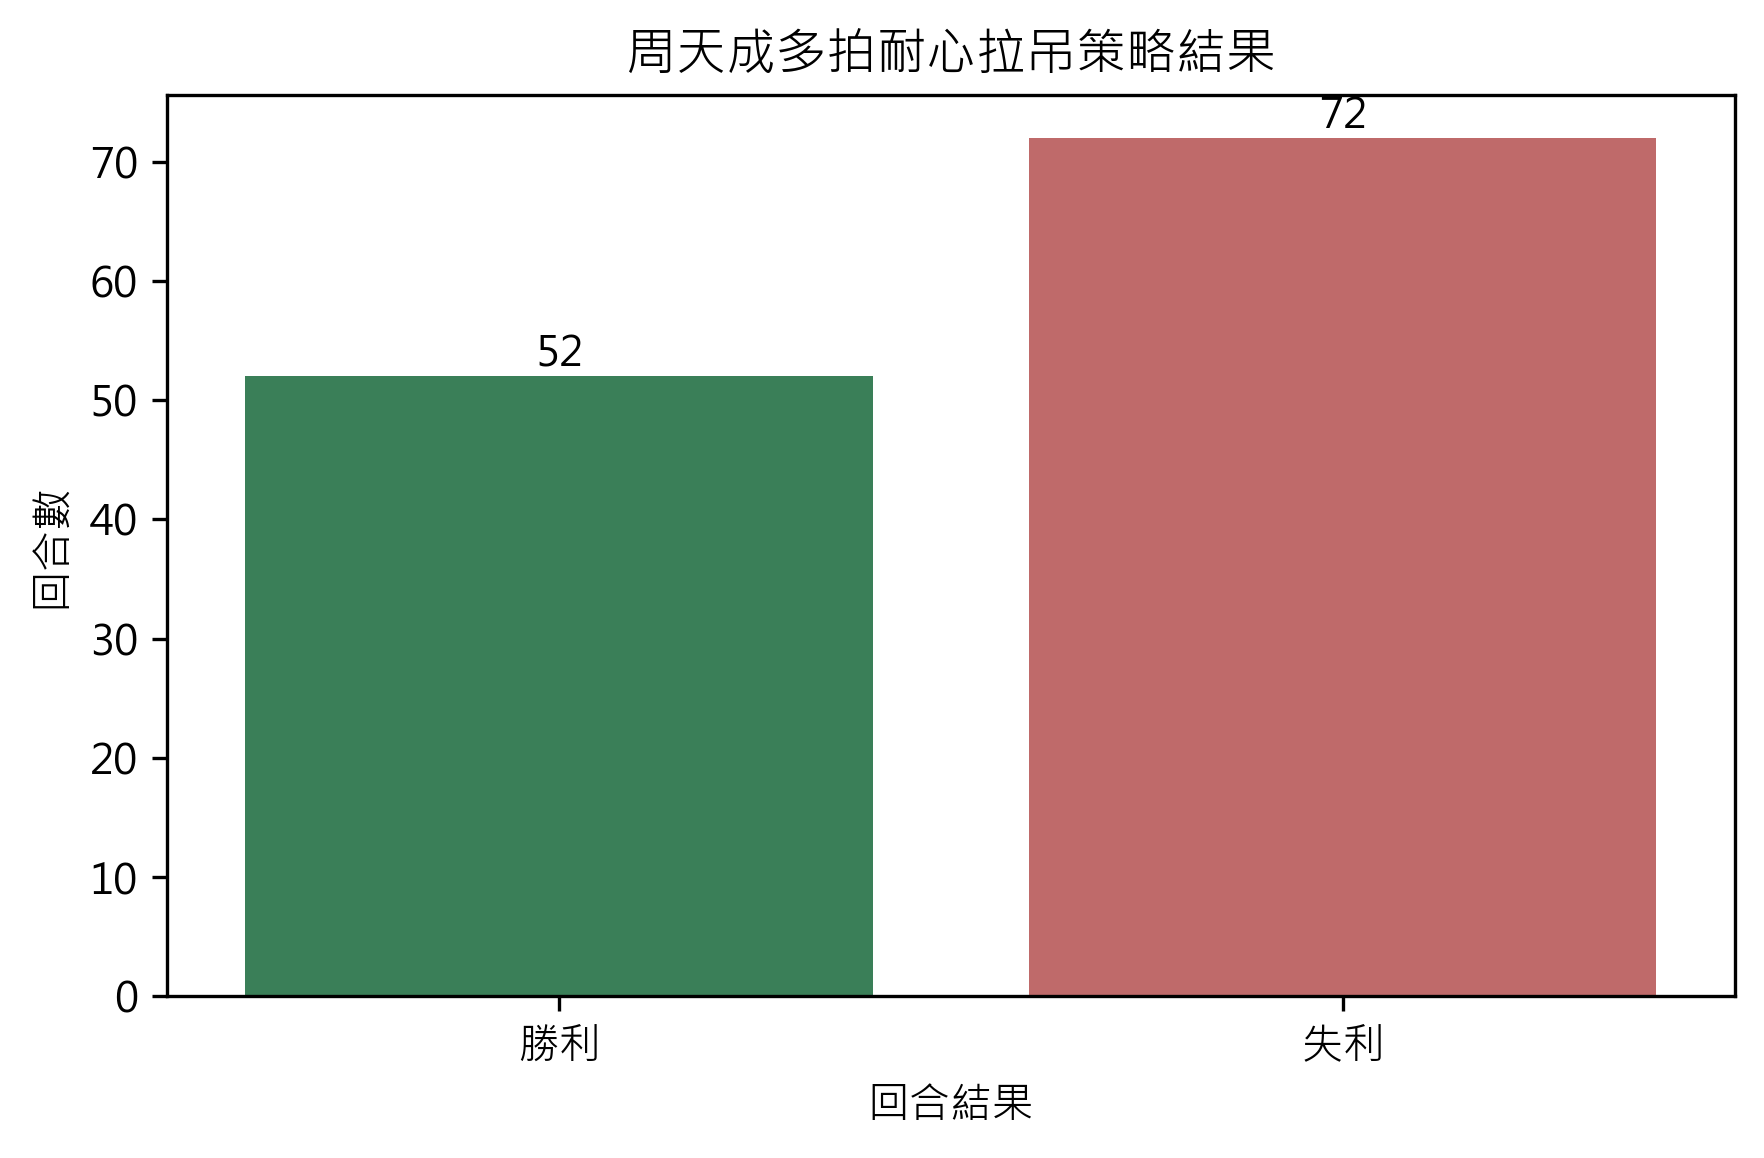

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法計算周天成多拍耐心拉吊策略的平均勝率。')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title('周天成多拍耐心拉吊策略')
    ax.axis('off')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_title('周天成多拍耐心拉吊策略')
        ax.axis('off')
    else:
        rally_keys = ['match_id', 'set', 'rally']
        chou = 'CHOU Tien Chen'
        rally_shot_types = ['長球', '切球']

        work_df = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        work_df['is_chou_rally_shot'] = (
            (work_df['player'] == chou) &
            (work_df['type'].isin(rally_shot_types))
        )

        rally_stats = (
            work_df.groupby(rally_keys, as_index=False, sort=False)
            .agg(
                拍數=('ball_round', 'size'),
                周天成拉吊拍數=('is_chou_rally_shot', 'sum')
            )
        )

        rally_end = (
            work_df.sort_values(
                ['match_id', 'set', 'rally', 'ball_round']
            )
            .drop_duplicates(subset=rally_keys, keep='last')
            [rally_keys + ['getpoint_player']]
            .rename(columns={'getpoint_player': '回合得分者'})
        )

        rally_stats = rally_stats.merge(
            rally_end,
            on=rally_keys,
            how='left',
            validate='one_to_one'
        )

        strategy_rallies = rally_stats[
            (rally_stats['拍數'] >= 6) &
            (rally_stats['周天成拉吊拍數'] >= 2) &
            (rally_stats['回合得分者'].notna())
        ].copy()

        total_strategy_rallies = len(strategy_rallies)

        if total_strategy_rallies == 0:
            print('沒有符合條件的周天成多拍耐心拉吊策略回合。')
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.set_title('周天成多拍耐心拉吊策略')
            ax.axis('off')
        else:
            strategy_rallies['周天成是否勝利'] = (
                strategy_rallies['回合得分者'] == chou
            )

            wins = int(strategy_rallies['周天成是否勝利'].sum())
            losses = total_strategy_rallies - wins
            win_rate = wins / total_strategy_rallies * 100

            print(
                '統計口徑：至少 6 拍，且周天成在該回合至少使用 2 拍「長球」或「切球」；'
                '僅納入已產生得分者的回合。'
            )
            print(f'符合策略回合數：{total_strategy_rallies}')
            print(f'周天成勝利回合數：{wins}')
            print(f'周天成失利回合數：{losses}')
            print(f'周天成多拍耐心拉吊策略平均勝率：{win_rate:.2f}%')

            plot_df = pd.DataFrame({
                '結果': ['勝利', '失利'],
                '回合數': [wins, losses]
            })

            fig, ax = plt.subplots(figsize=(6, 4))
            sns.barplot(
                data=plot_df,
                x='結果',
                y='回合數',
                hue='結果',
                palette=['#2E8B57', '#CD5C5C'],
                legend=False,
                ax=ax
            )

            ax.set_title('周天成多拍耐心拉吊策略結果')
            ax.set_xlabel('回合結果')
            ax.set_ylabel('回合數')

            for container in ax.containers:
                ax.bar_label(container, fmt='%d')

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 85
**問題**: 統計周天成經常「從防守轉攻擊得分」的常見回合模式。
> **使用的資料欄位群組**: `全欄位 (Fallback)`


統計口徑：
- 以每個 match_id、set、rally 為一個回合單位。
- 周天成的得分必須是主動得分：player == getpoint_player。
- 防守轉攻擊定義為：周天成「接殺防守」→ 對手回球 → 周天成以攻擊型球種主動得分。
- 攻擊型球種包含：殺球、推撲球、平球、網前球、切球。

周天成主動得分總數：85
符合防守轉攻擊的主動得分回合數：4
防守轉攻擊回合占周天成主動得分比例：4.71%

最常見的防守轉攻擊回合模式：
prev2_type prev_type type  回合數 占防守轉攻擊比例
      接殺防守        挑球   殺球    2   50.00%
      接殺防守       推撲球   殺球    1   25.00%
      接殺防守        長球   殺球    1   25.00%

防守轉攻擊後的得分球種：
周天成主動攻擊得分球種  回合數 占防守轉攻擊比例
         殺球    4  100.00%


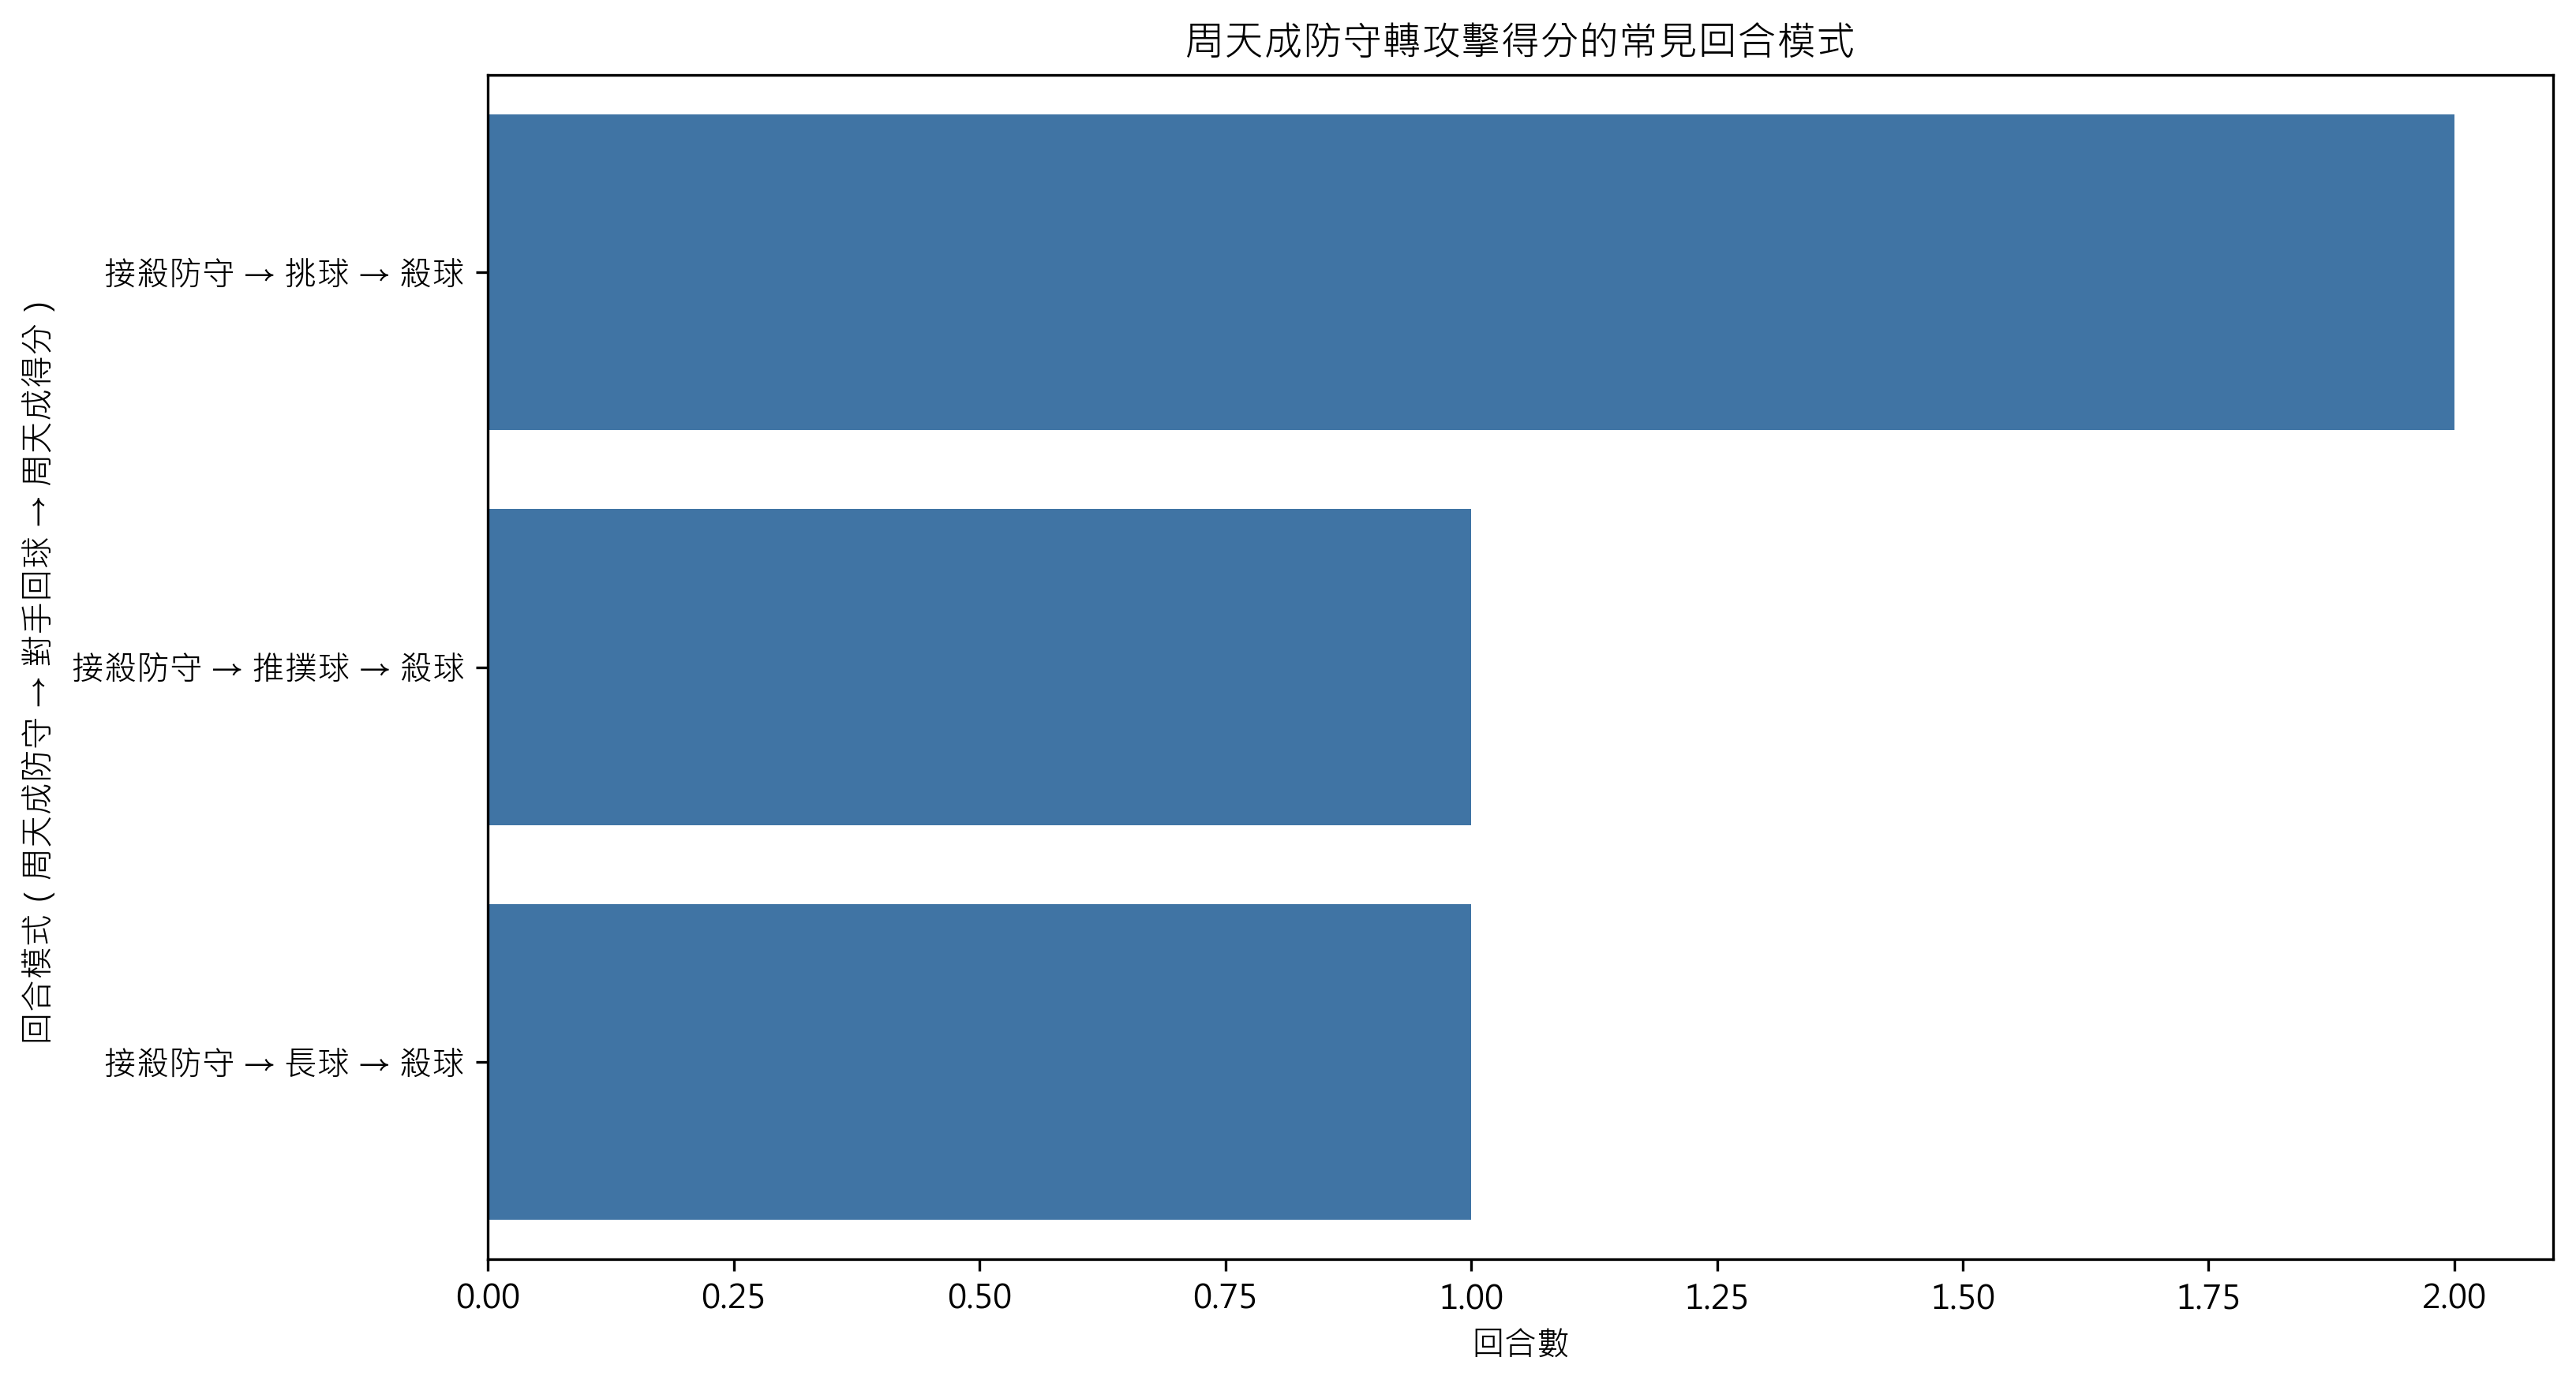

In [ ]:
if len(df) == 0:
    print("資料為空，無法進行統計。")
else:
    target_player = "CHOU Tien Chen"
    defensive_types = {"接殺防守"}
    attacking_types = {"殺球", "推撲球", "平球", "網前球", "切球"}

    required_cols = {
        "match_id", "set", "rally", "ball_round", "player", "opponent",
        "type", "getpoint_player"
    }
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        print(f"缺少必要欄位：{sorted(missing_cols)}")
    else:
        work = df.sort_values(
            ["match_id", "set", "rally", "ball_round"]
        ).copy()

        rally_keys = ["match_id", "set", "rally"]
        grouped = work.groupby(rally_keys, sort=False)

        work["prev_player"] = grouped["player"].shift(1)
        work["prev_type"] = grouped["type"].shift(1)
        work["prev2_player"] = grouped["player"].shift(2)
        work["prev2_type"] = grouped["type"].shift(2)
        work["next_player"] = grouped["player"].shift(-1)
        work["next_type"] = grouped["type"].shift(-1)

        same_prev_rally = (
            work["match_id"].eq(work["match_id"].shift(1))
            & work["set"].eq(work["set"].shift(1))
            & work["rally"].eq(work["rally"].shift(1))
        )
        same_prev2_rally = (
            work["match_id"].eq(work["match_id"].shift(2))
            & work["set"].eq(work["set"].shift(2))
            & work["rally"].eq(work["rally"].shift(2))
        )

        active_winning_shot = (
            work["player"].eq(target_player)
            & work["getpoint_player"].eq(target_player)
            & work["type"].isin(attacking_types)
        )

        defense_to_attack = (
            active_winning_shot
            & same_prev_rally
            & same_prev2_rally
            & work["prev_player"].eq(work["opponent"])
            & work["prev2_player"].eq(target_player)
            & work["prev2_type"].isin(defensive_types)
        )

        transition_df = work.loc[
            defense_to_attack,
            rally_keys + [
                "ball_round", "prev2_type", "prev_type", "type"
            ]
        ].copy()

        total_active_wins = int(
            (
                work["player"].eq(target_player)
                & work["getpoint_player"].eq(target_player)
            ).sum()
        )

        transition_count = len(transition_df)

        print("統計口徑：")
        print("- 以每個 match_id、set、rally 為一個回合單位。")
        print("- 周天成的得分必須是主動得分：player == getpoint_player。")
        print("- 防守轉攻擊定義為：周天成「接殺防守」→ 對手回球 → 周天成以攻擊型球種主動得分。")
        print("- 攻擊型球種包含：殺球、推撲球、平球、網前球、切球。")
        print(f"\n周天成主動得分總數：{total_active_wins}")
        print(f"符合防守轉攻擊的主動得分回合數：{transition_count}")

        if total_active_wins > 0:
            transition_rate = transition_count / total_active_wins * 100
            print(f"防守轉攻擊回合占周天成主動得分比例：{transition_rate:.2f}%")

        if transition_count > 0:
            pattern_summary = (
                transition_df
                .groupby(["prev2_type", "prev_type", "type"], dropna=False)
                .size()
                .reset_index(name="回合數")
                .sort_values(
                    ["回合數", "prev2_type", "prev_type", "type"],
                    ascending=[False, True, True, True]
                )
            )
            pattern_summary["占防守轉攻擊比例"] = (
                pattern_summary["回合數"] / transition_count * 100
            ).round(2)

            print("\n最常見的防守轉攻擊回合模式：")
            print(
                pattern_summary.head(10).to_string(
                    index=False,
                    formatters={"占防守轉攻擊比例": "{:.2f}%".format}
                )
            )

            attack_summary = (
                transition_df["type"]
                .value_counts()
                .rename_axis("周天成主動攻擊得分球種")
                .reset_index(name="回合數")
            )
            attack_summary["占防守轉攻擊比例"] = (
                attack_summary["回合數"] / transition_count * 100
            ).round(2)

            print("\n防守轉攻擊後的得分球種：")
            print(
                attack_summary.to_string(
                    index=False,
                    formatters={"占防守轉攻擊比例": "{:.2f}%".format}
                )
            )

            plot_df = pattern_summary.head(10).copy()
            plot_df["模式"] = (
                plot_df["prev2_type"] + " → "
                + plot_df["prev_type"] + " → "
                + plot_df["type"]
            )

            fig, ax = plt.subplots(figsize=(11, 6))
            sns.barplot(
                data=plot_df,
                x="回合數",
                y="模式",
                color="#2F75B5",
                ax=ax
            )
            ax.set_title("周天成防守轉攻擊得分的常見回合模式")
            ax.set_xlabel("回合數")
            ax.set_ylabel("回合模式（周天成防守 → 對手回球 → 周天成得分）")
            plt.tight_layout()
        else:
            print("\n資料中沒有符合定義的防守轉攻擊主動得分回合。")


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 88
**問題**: 對手若習慣在第三拍主動攻擊，周天成應該如何設計接發策略，在前三拍就破壞對手節奏並轉守為攻？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析對象：周天成接發，Kento MOMOTA 為對手。
第三拍主動攻擊定義：殺球、推撲球、平球。
統計單位：同一 match_id、set、rally 的回合；第三拍為對手擊球，第二拍為周天成接發。
轉守為攻指標：周天成第四拍使用攻擊型球種；並另列第四拍主動得分與整回合得分。

Court Grid Definitions：
後排：1-4；中排：5-16；前排：17-24；出界：25-32。
區域明細：
 區域代碼          區域名稱
    1     1｜後排-後排-左
    2    2｜後排-後排-中左
    3    3｜後排-後排-中右
    4     4｜後排-後排-右
    5   5｜中排-中排後側-左
    6  6｜中排-中排後側-中左
    7  7｜中排-中排後側-中右
    8   8｜中排-中排後側-右
    9     9｜中排-中排-左
   10   10｜中排-中排-中左
   11   11｜中排-中排-中右
…（輸出已截斷；notebook 僅保留重點）


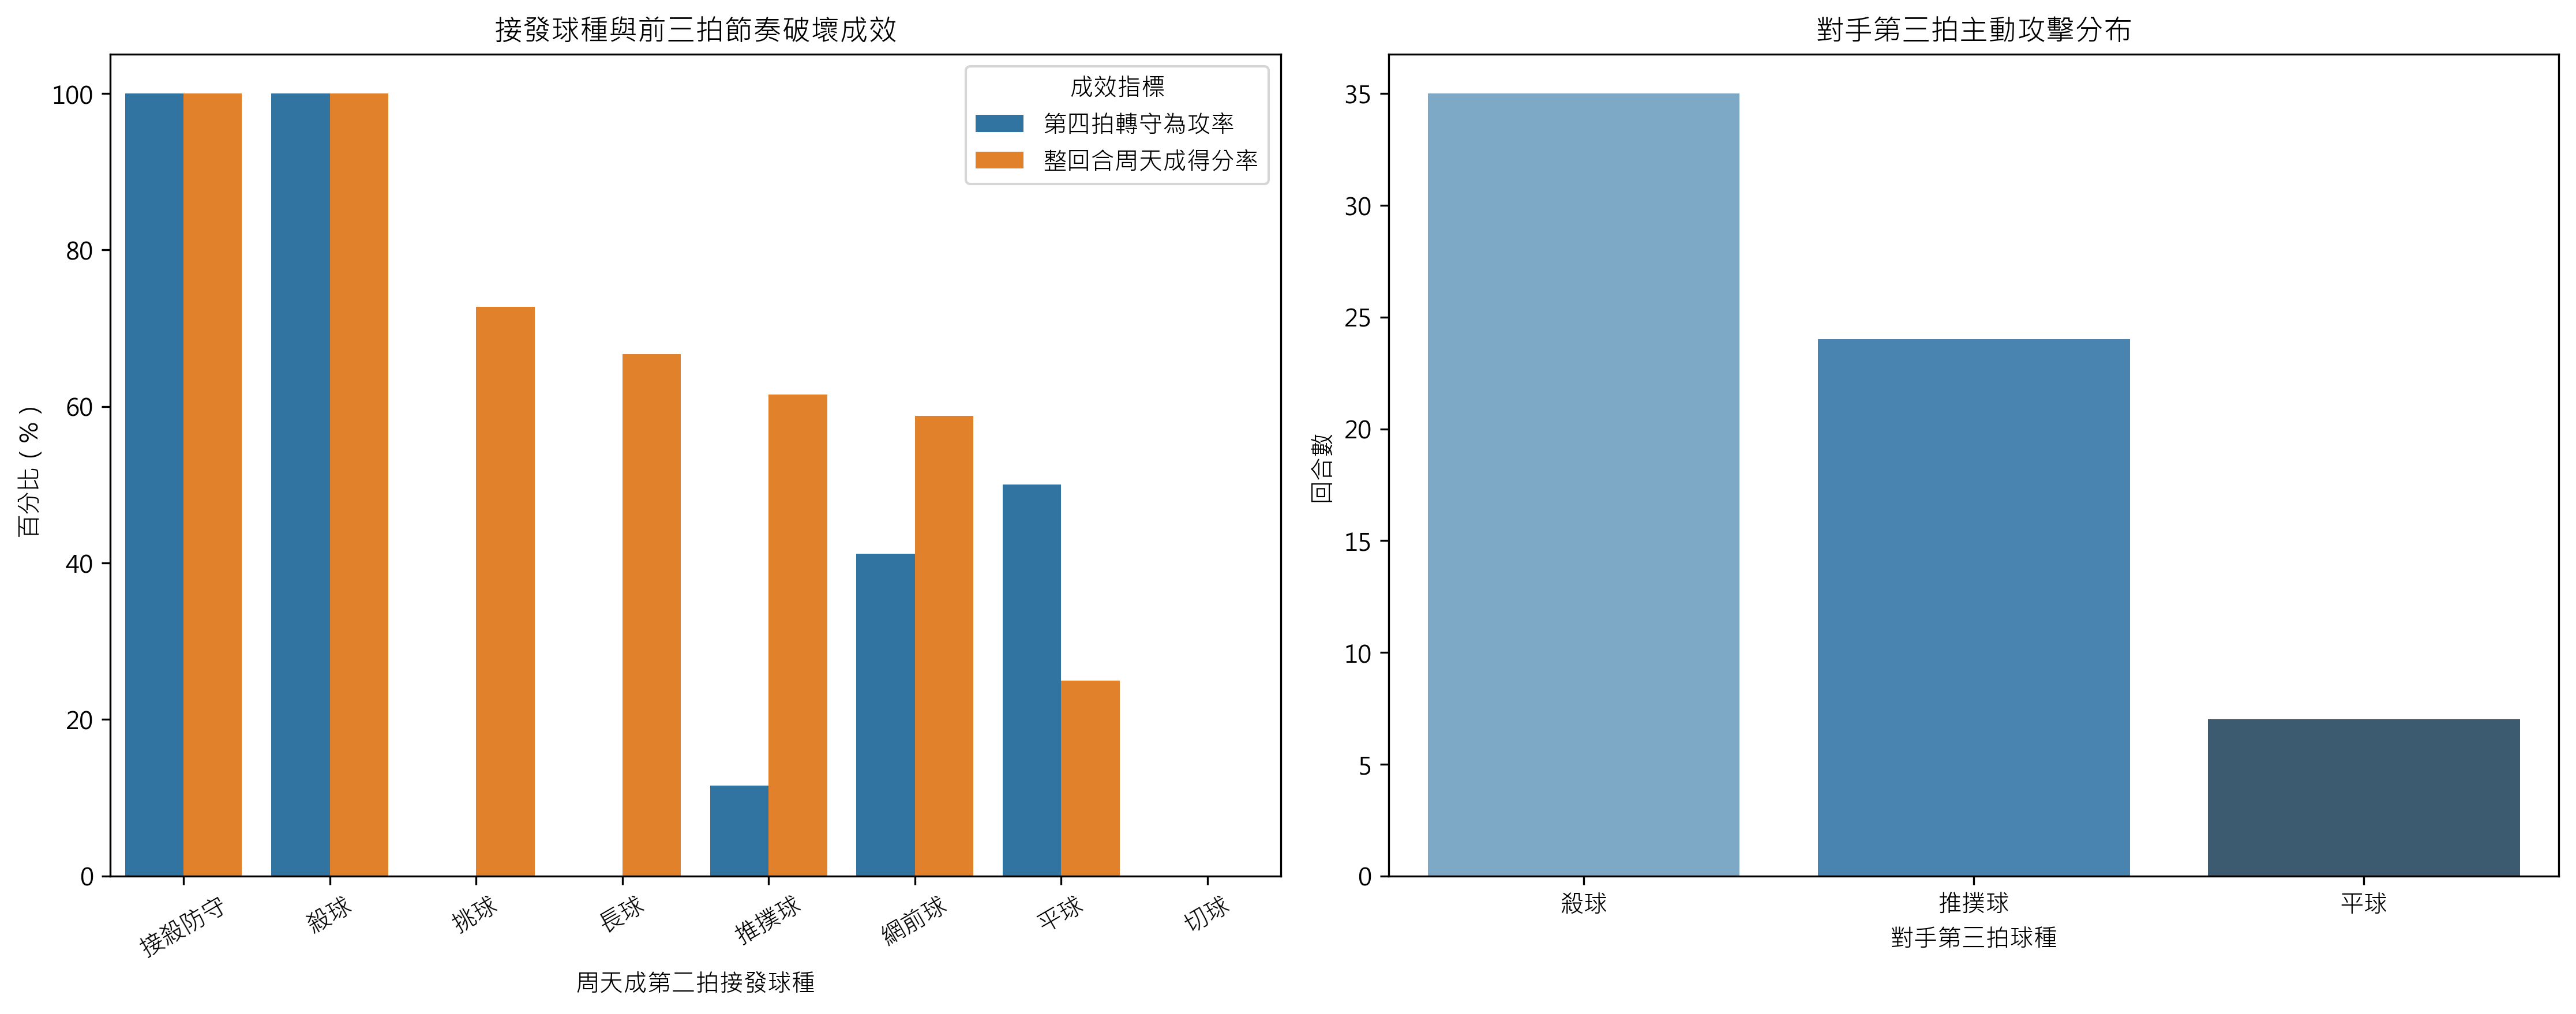

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'server', 'type', 'landing_area', 'getpoint_player'
]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

if len(df) == 0:
    print("資料為空，無法分析。")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.text(0.5, 0.5, "資料為空", ha='center', va='center')
    ax.axis('off')
    plt.tight_layout()
else:
    ctc = 'CHOU Tien Chen'
    opponent = 'Kento MOMOTA'

    # 操作性定義：第三拍主動攻擊包含殺球、推撲球、平球
    attack_types = ['殺球', '推撲球', '平球']

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_keys = ['match_id', 'set', 'rally']
    grouped = work.groupby(rally_keys, sort=False)

    # 必須在完整資料上建立前後拍，避免先篩選造成跨拍污染
    work['prev_player'] = grouped['player'].shift(1)
    work['prev_type'] = grouped['type'].shift(1)
    work['prev_ball_round'] = grouped['ball_round'].shift(1)
    work['prev_landing_area'] = grouped['landing_area'].shift(1)

    work['prev2_player'] = grouped['player'].shift(2)
    work['prev2_ball_round'] = grouped['ball_round'].shift(2)

    work['next_player'] = grouped['player'].shift(-1)
    work['next_type'] = grouped['type'].shift(-1)
    work['next_ball_round'] = grouped['ball_round'].shift(-1)
    work['next_getpoint_player'] = grouped['getpoint_player'].shift(-1)

    work['rally_winner'] = grouped['getpoint_player'].transform('last')

    # 場地 Grid Definitions
    zone_category = {}
    zone_position = {}

    for z in [1, 2, 3, 4]:
        zone_category[z] = '後排'
    for z in range(5, 17):
        zone_category[z] = '中排'
    for z in range(17, 25):
        zone_category[z] = '前排'
    for z in [25, 26, 27, 28, 29, 30, 31, 32]:
        zone_category[z] = '出界'

    row_names = {
        1: '後排', 2: '中排後側', 3: '中排', 4: '中排前側',
        5: '前排後側', 6: '前排網前'
    }
    col_names = {1: '左', 2: '中左', 3: '中右', 4: '右'}

    for row, start_zone in enumerate([1, 5, 9, 13, 17, 21], start=1):
        for col in range(1, 5):
            zone = start_zone + col - 1
            zone_position[zone] = f"{row_names[row]}-{col_names[col]}"

    zone_position.update({
        25: '出界-右上側',
        26: '出界-右中側',
        27: '出界-右下側',
        28: '出界-右後方',
        29: '出界-左上側',
        30: '出界-左中側',
        31: '出界-左下側',
        32: '出界-左後方'
    })

    def zone_label(zone):
        if pd.isna(zone):
            return '未知'
        zone_int = int(zone)
        category = zone_category.get(zone_int, '未知')
        position = zone_position.get(zone_int, '未知位置')
        return f'{zone_int}｜{category}-{position}'

    print("分析對象：周天成接發，Kento MOMOTA 為對手。")
    print("第三拍主動攻擊定義：殺球、推撲球、平球。")
    print("統計單位：同一 match_id、set、rally 的回合；第三拍為對手擊球，第二拍為周天成接發。")
    print("轉守為攻指標：周天成第四拍使用攻擊型球種；並另列第四拍主動得分與整回合得分。")
    print("\nCourt Grid Definitions：")
    print("後排：1-4；中排：5-16；前排：17-24；出界：25-32。")
    print("區域明細：")
    print(pd.DataFrame({
        '區域代碼': list(range(1, 33)),
        '區域名稱': [zone_label(z) for z in range(1, 33)]
    }).to_string(index=False))

    # 先找出所有「對手發球、周天成第二拍接發、對手第三拍」的完整前三拍樣本
    third_candidates = work[
        (work['ball_round'] == 3) &
        (work['player'] == opponent) &
        (work['prev_player'] == ctc) &
        (work['prev_ball_round'] == 2) &
        (work['prev2_player'] == opponent) &
        (work['prev2_ball_round'] == 1)
    ].copy()

    attack_third = third_candidates[
        third_candidates['type'].isin(attack_types)
    ].copy()

    total_third = len(third_candidates)
    attack_third_count = len(attack_third)
    attack_rate = (
        attack_third_count / total_third * 100
        if total_third > 0 else 0
    )

    print("\n【對手第三拍攻擊習慣】")
    print(f"符合前三拍接發結構的回合數：{total_third}")
    print(f"對手第三拍主動攻擊回合數：{attack_third_count}")
    print(f"對手第三拍主動攻擊比例：{attack_rate:.2f}%")

    if attack_third_count > 0:
        print("\n對手第三拍攻擊球種分布：")
        attack_distribution = (
            attack_third['type']
            .value_counts()
            .rename_axis('第三拍攻擊球種')
            .reset_index(name='回合數')
        )
        attack_distribution['比例'] = (
            attack_distribution['回合數'] /
            attack_distribution['回合數'].sum() * 100
        ).round(2)
        print(attack_distribution.to_string(index=False))

        # 第四拍必須是同一回合的下一拍，且球員必須為周天成
        attack_third['has_fourth_shot'] = (
            (attack_third['next_player'] == ctc) &
            (attack_third['next_ball_round'] == 4)
        )
        attack_third['fourth_shot_type'] = attack_third['next_type'].where(
            attack_third['has_fourth_shot']
        )
        attack_third['fourth_attack_response'] = (
            attack_third['has_fourth_shot'] &
            attack_third['next_type'].isin(attack_types)
        )
        attack_third['fourth_active_win'] = (
            attack_third['has_fourth_shot'] &
            (attack_third['next_getpoint_player'] == ctc)
        )
        attack_third['rally_win'] = (
            attack_third['rally_winner'] == ctc
        )

        # 第二拍接發球種策略成效
        strategy_rows = []
        for receive_type, g in attack_third.groupby('prev_type', dropna=False):
            n = len(g)
            strategy_rows.append({
                '第二拍接發球種': '未知' if pd.isna(receive_type) else str(receive_type),
                '樣本數': n,
                '對手第三拍攻擊後第四拍存在率': (
                    g['has_fourth_shot'].mean() * 100
                ),
                '第四拍轉守為攻率': (
                    g['fourth_attack_response'].mean() * 100
                ),
                '第四拍主動得分率': (
                    g['fourth_active_win'].mean() * 100
                ),
                '整回合周天成得分率': (
                    g['rally_win'].mean() * 100
                )
            })

        strategy_table = pd.DataFrame(strategy_rows)
        if len(strategy_table) > 0:
            for col in strategy_table.columns[2:]:
                strategy_table[col] = strategy_table[col].round(2)

            print("\n【接發球種策略比較】")
            print(strategy_table.sort_values(
                ['整回合周天成得分率', '樣本數'],
                ascending=[False, False]
            ).to_string(index=False))

        # 第二拍接發落點：該落點即為對手第三拍的擊球區域
        attack_third['第二拍接發落點'] = attack_third['prev_landing_area'].map(
            zone_label
        )

        landing_rows = []
        for landing, g in attack_third.groupby('第二拍接發落點', dropna=False):
            n = len(g)
            landing_rows.append({
                '第二拍接發落點': landing,
                '樣本數': n,
                '第四拍轉守為攻率': (
                    g['fourth_attack_response'].mean() * 100
                ),
                '第四拍主動得分率': (
                    g['fourth_active_win'].mean() * 100
                ),
                '整回合周天成得分率': (
                    g['rally_win'].mean() * 100
                )
            })

        landing_table = pd.DataFrame(landing_rows)
        if len(landing_table) > 0:
            for col in landing_table.columns[2:]:
                landing_table[col] = landing_table[col].round(2)

            print("\n【第二拍接發落點策略比較】")
            print(landing_table.sort_values(
                ['整回合周天成得分率', '樣本數'],
                ascending=[False, False]
            ).head(15).to_string(index=False))

        # 產生可執行的策略建議：至少 5 個樣本，優先考慮整回合得分率與轉守為攻率
        valid_strategy = strategy_table[
            strategy_table['樣本數'] >= 5
        ].copy() if len(strategy_table) > 0 else pd.DataFrame()

        print("\n【策略建議】")
        if len(valid_strategy) > 0:
            best_strategy = valid_strategy.sort_values(
                ['整回合周天成得分率', '第四拍轉守為攻率', '樣本數'],
                ascending=[False, False, False]
            ).iloc[0]

            print(
                f"優先使用「{best_strategy['第二拍接發球種']}」接發；"
                f"在對手第三拍攻擊樣本中，整回合得分率為 "
                f"{best_strategy['整回合周天成得分率']:.2f}%，"
                f"第四拍轉守為攻率為 "
                f"{best_strategy['第四拍轉守為攻率']:.2f}%。"
            )
            print("接發後應預先準備第四拍，以主動攻擊型球種搶回節奏，避免只做被動擋回。")
        else:
            print("各接發球種樣本數不足 5，無法提出穩健的單一球種建議。")
            print("建議以短、低、貼網的接發為基礎，並針對對手第三拍攻擊方向預先準備第四拍反攻。")

        if len(landing_table) > 0:
            valid_landing = landing_table[
                landing_table['樣本數'] >= 5
            ].copy()
            if len(valid_landing) > 0:
                best_landing = valid_landing.sort_values(
                    ['整回合周天成得分率', '第四拍轉守為攻率', '樣本數'],
                    ascending=[False, False, False]
                ).iloc[0]
                print(
                    f"落點方面，樣本達 5 次以上的最佳觀察區域為"
                    f"「{best_landing['第二拍接發落點']}」；"
                    f"整回合得分率為 {best_landing['整回合周天成得分率']:.2f}%。"
                )
            else:
                print("接發落點的各區域樣本數不足 5，暫不指定單一落點。")

        # 圖表：接發球種與轉守為攻成效
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        plot_strategy = strategy_table.copy()
        if len(plot_strategy) > 0:
            plot_strategy = plot_strategy.sort_values(
                '整回合周天成得分率', ascending=False
            )
            plot_strategy_melt = plot_strategy.melt(
                id_vars=['第二拍接發球種', '樣本數'],
                value_vars=['第四拍轉守為攻率', '整回合周天成得分率'],
                var_name='指標',
                value_name='百分比'
            )
            sns.barplot(
                data=plot_strategy_melt,
                x='第二拍接發球種',
                y='百分比',
                hue='指標',
                ax=axes[0]
            )
            axes[0].set_title('接發球種與前三拍節奏破壞成效')
            axes[0].set_xlabel('周天成第二拍接發球種')
            axes[0].set_ylabel('百分比（%）')
            axes[0].legend(title='成效指標')
            axes[0].tick_params(axis='x', rotation=30)
        else:
            axes[0].text(0.5, 0.5, '無足夠資料', ha='center', va='center')
            axes[0].axis('off')

        attack_plot = (
            attack_third['type']
            .value_counts()
            .rename_axis('第三拍攻擊球種')
            .reset_index(name='回合數')
        )
        if len(attack_plot) > 0:
            sns.barplot(
                data=attack_plot,
                x='第三拍攻擊球種',
                y='回合數',
                hue='第三拍攻擊球種',
                legend=False,
                ax=axes[1],
                palette='Blues_d'
            )
            axes[1].set_title('對手第三拍主動攻擊分布')
            axes[1].set_xlabel('對手第三拍球種')
            axes[1].set_ylabel('回合數')
        else:
            axes[1].text(0.5, 0.5, '無足夠資料', ha='center', va='center')
            axes[1].axis('off')

        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.text(0.5, 0.5, "無法分析", ha='center', va='center')
        ax.axis('off')
        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 89
**問題**: 若對手在回合中主動進攻，周天成可以如何利用「節奏」與「落點深度」讓對手無法進入舒服的進攻狀態？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析口徑：
1. 對手主動進攻定義為：殺球、推撲球、平球。
2. 研究單位為同一 match_id、set、rally 內，對手進攻後周天成的下一拍。
3. 落點深度依 landing_area 判定；前排、中排、後排及出界區域採用 Court Grid Definitions。
4. 「對手仍能主動進攻」指同一回合的下一拍由對手擊球，且球種仍為攻擊球種。
5. 「對手主動得分」僅計算 getpoint_player == 對手最後擊球者，排除周天成失誤造成的被動得分。

有效序列數：515
對手主動進攻球種：['平球', '推撲球', '殺球']
Court Grid Definitions：{'前排': [17, 18, 19, 20, 21, 22, 23, 24], '中排': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], '後排': [1, 2, 3, 4], '出界': [25, 26, 27, 28, 29, 30, 31, 32]}

依周天成回擊節奏與落點深度的效果：
 節奏策略 落點深度  回擊次數  對手仍能主動進攻比例  周天成贏回合比例  對手主動得分比例
 防守化解   出界     6        0.00     16.67      0.00
 主動施壓   出界     5        0.00      0.00      0.00
 拉開深度   出界     2        0.00      0.00      0.00
控網與變速   出界     2        0.00      0.00      0.00
 防守化解   未知     5        0.00      0.00      0.00
控網與變速   前排    42       11.90     45.24     26.19
 主動施壓   中排    86       15.12     45.35     12.79
…（輸出已截斷；notebook 僅保留重點）


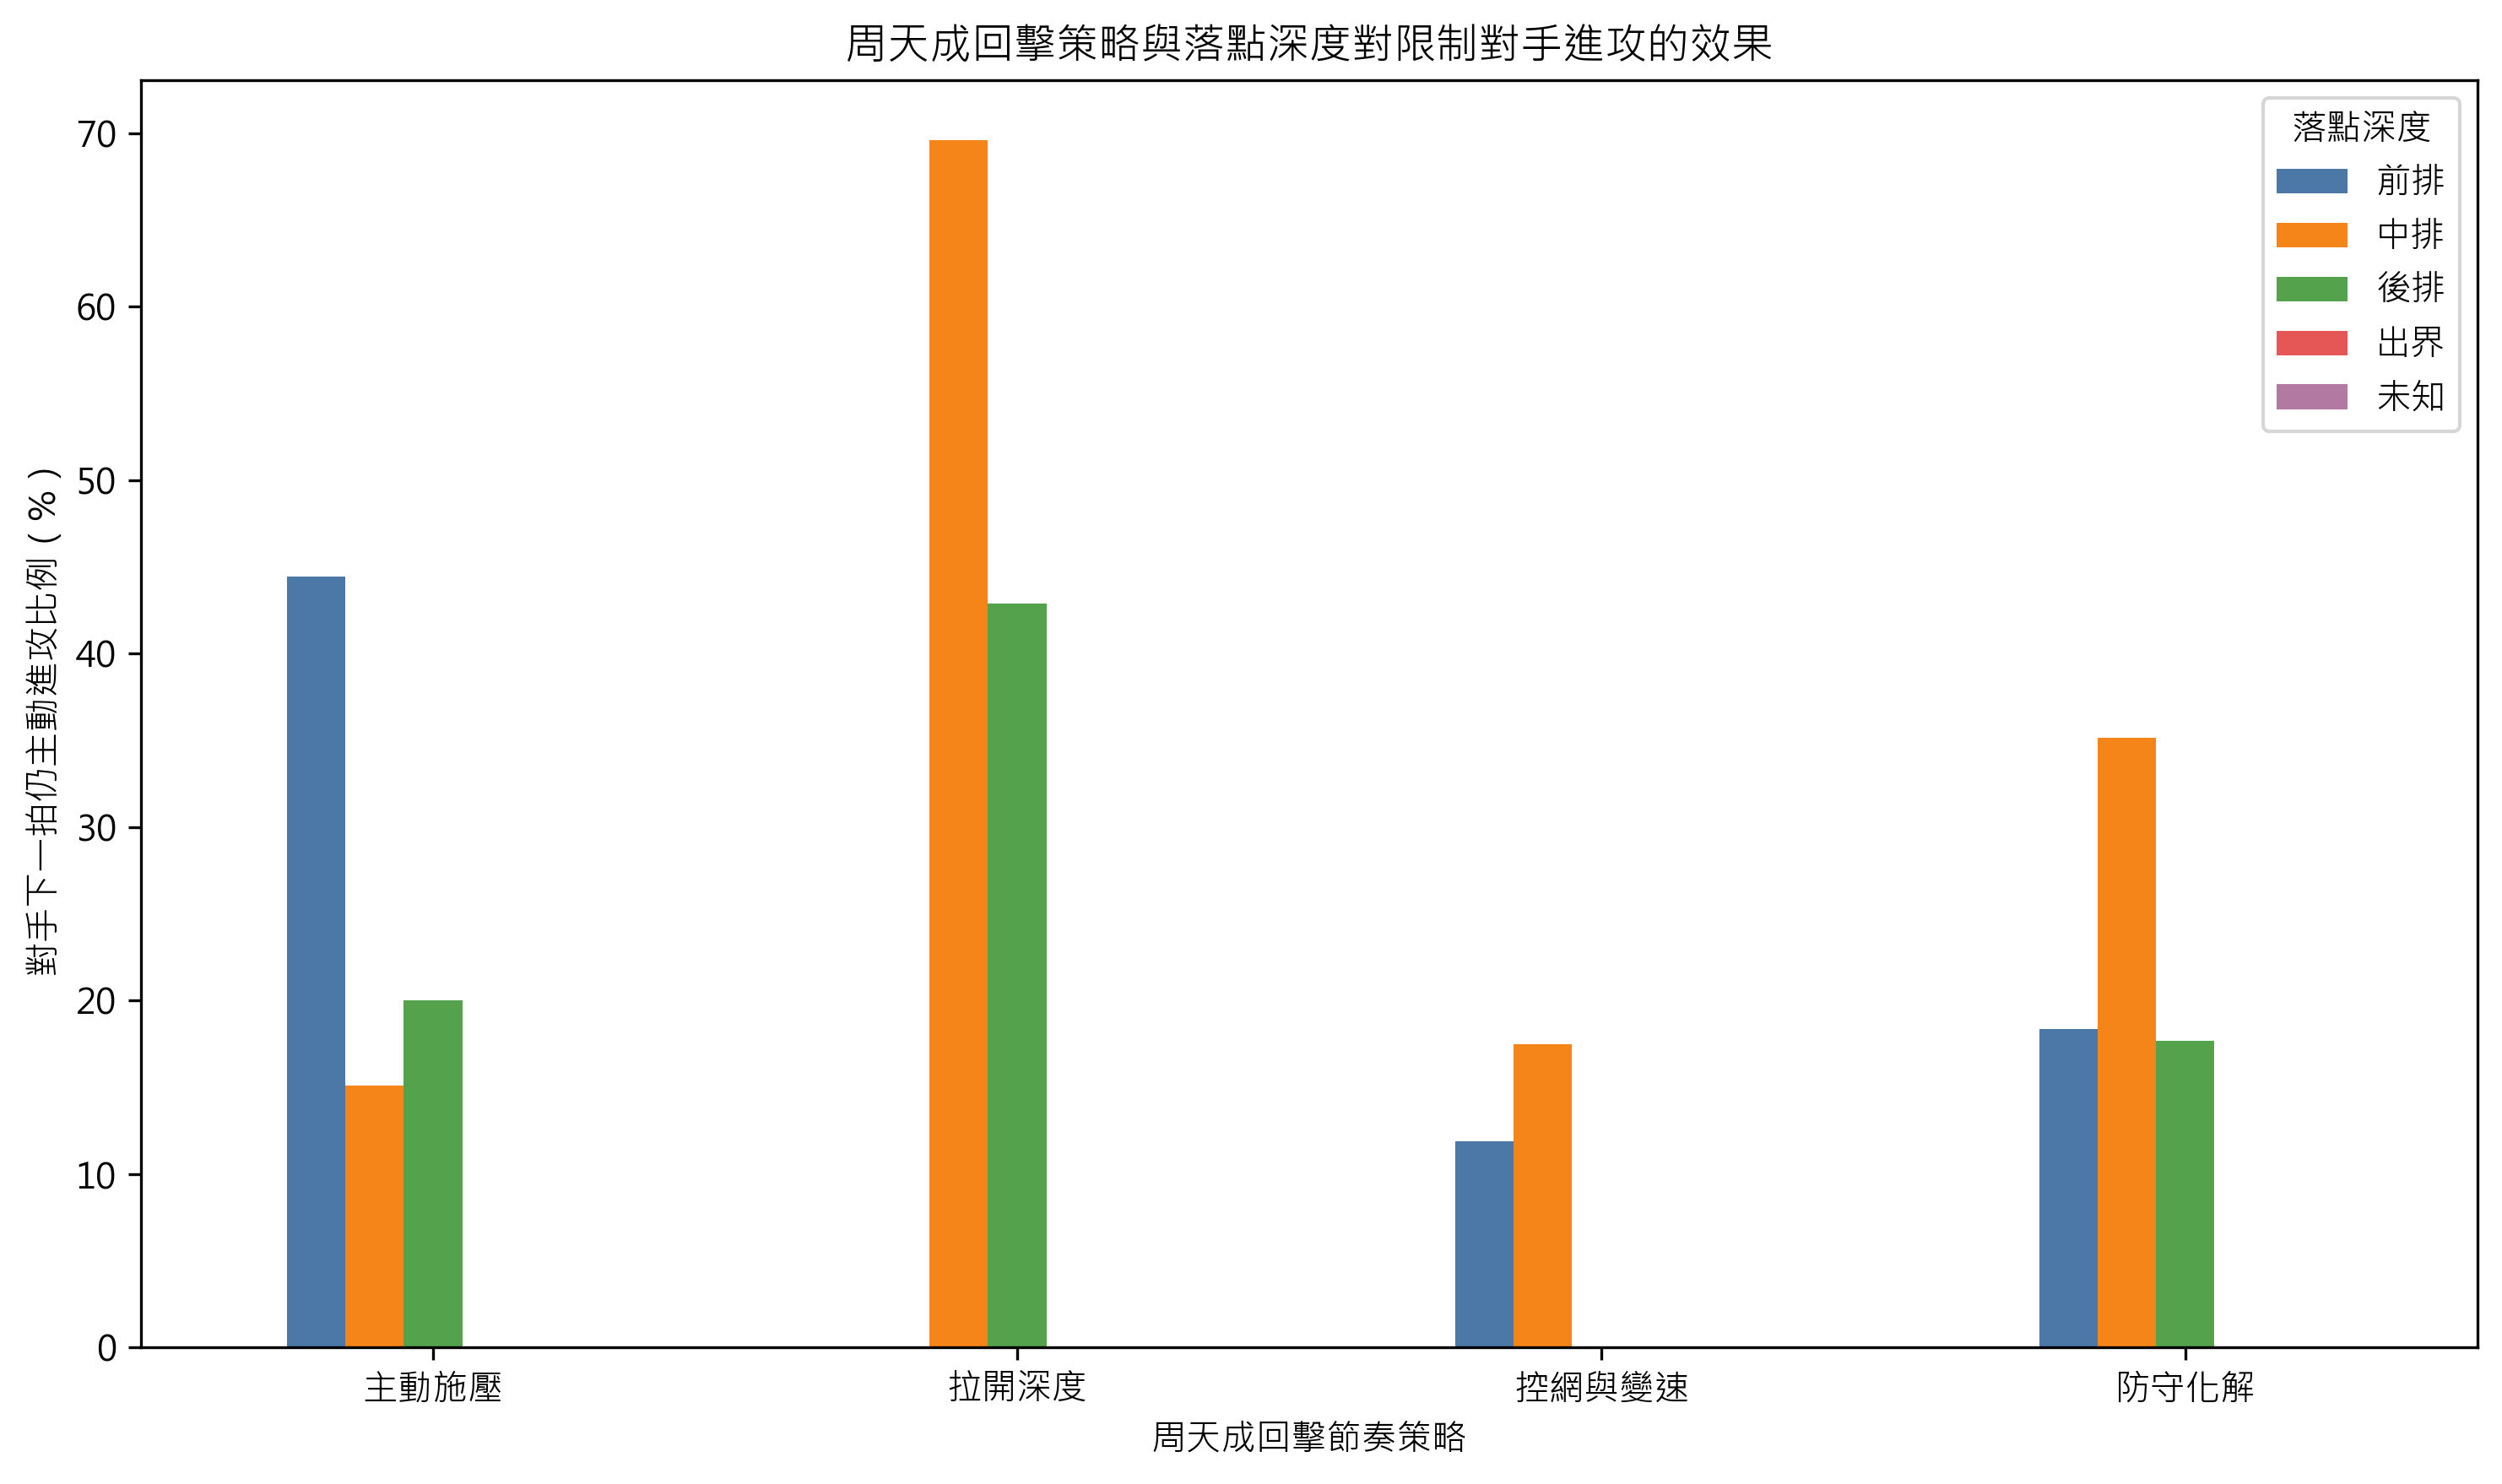

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'landing_area', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法進行分析。')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis('off')
    ax.set_title('無可分析資料')
else:
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        print(f'缺少必要欄位：{missing_cols}')
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.axis('off')
        ax.set_title('欄位不足，無法進行分析')
    else:
        keys = ['match_id', 'set', 'rally']
        chou = 'CHOU Tien Chen'
        attack_types = {'殺球', '推撲球', '平球'}

        court_grid_definitions = {
            '前排': [17, 18, 19, 20, 21, 22, 23, 24],
            '中排': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
            '後排': [1, 2, 3, 4],
            '出界': [25, 26, 27, 28, 29, 30, 31, 32]
        }

        def depth_category(area):
            if pd.isna(area):
                return '未知'
            area = int(area)
            for category, zones in court_grid_definitions.items():
                if area in zones:
                    return category
            return '未知'

        def rhythm_strategy(shot_type):
            if shot_type in {'殺球', '推撲球', '平球'}:
                return '主動施壓'
            if shot_type in {'網前球', '切球'}:
                return '控網與變速'
            if shot_type in {'長球', '挑球'}:
                return '拉開深度'
            if shot_type == '接殺防守':
                return '防守化解'
            return '其他'

        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        grouped = work.groupby(keys, sort=False)

        work['prev_player'] = grouped['player'].shift(1)
        work['prev_type'] = grouped['type'].shift(1)
        work['prev_ball_round'] = grouped['ball_round'].shift(1)

        work['next_player'] = grouped['player'].shift(-1)
        work['next_type'] = grouped['type'].shift(-1)
        work['next_ball_round'] = grouped['ball_round'].shift(-1)

        work['rally_winner'] = grouped['getpoint_player'].transform('last')
        work['rally_last_player'] = grouped['player'].transform('last')

        sequence_filter = (
            (work['player'] == chou) &
            (work['prev_player'] == work['opponent']) &
            (work['prev_type'].isin(attack_types))
        )

        seq = work.loc[sequence_filter].copy()

        if len(seq) == 0:
            print('沒有找到「對手主動進攻後，由周天成立即回擊」的有效序列。')
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.axis('off')
            ax.set_title('無有效進攻後回擊序列')
        else:
            seq['落點深度'] = seq['landing_area'].map(depth_category)
            seq['節奏策略'] = seq['type'].map(rhythm_strategy)

            seq['有下一拍'] = (
                seq['next_player'].notna() &
                (seq['next_player'] == seq['opponent'])
            )

            seq['對手下一拍仍主動進攻'] = (
                seq['有下一拍'] &
                seq['next_type'].isin(attack_types)
            )

            seq['周天成贏得回合'] = seq['rally_winner'].eq(chou)

            seq['對手主動得分'] = (
                seq['rally_winner'].eq(seq['opponent']) &
                seq['rally_last_player'].eq(seq['opponent'])
            )

            summary = (
                seq.groupby(['節奏策略', '落點深度'], dropna=False)
                .agg(
                    回擊次數=('type', 'size'),
                    對手仍能主動進攻比例=('對手下一拍仍主動進攻', 'mean'),
                    周天成贏回合比例=('周天成贏得回合', 'mean'),
                    對手主動得分比例=('對手主動得分', 'mean')
                )
                .reset_index()
            )

            summary['對手仍能主動進攻比例'] *= 100
            summary['周天成贏回合比例'] *= 100
            summary['對手主動得分比例'] *= 100

            summary = summary.sort_values(
                ['對手仍能主動進攻比例', '周天成贏回合比例'],
                ascending=[True, False]
            )

            response_distribution = (
                seq.groupby(['節奏策略', 'type'], dropna=False)
                .size()
                .reset_index(name='次數')
                .sort_values('次數', ascending=False)
            )

            depth_distribution = (
                seq.groupby('落點深度', dropna=False)
                .agg(
                    回擊次數=('type', 'size'),
                    對手下一拍仍主動進攻比例=('對手下一拍仍主動進攻', 'mean'),
                    周天成贏回合比例=('周天成贏得回合', 'mean')
                )
                .reset_index()
            )

            depth_distribution['對手下一拍仍主動進攻比例'] *= 100
            depth_distribution['周天成贏回合比例'] *= 100

            print('分析口徑：')
            print('1. 對手主動進攻定義為：殺球、推撲球、平球。')
            print('2. 研究單位為同一 match_id、set、rally 內，對手進攻後周天成的下一拍。')
            print('3. 落點深度依 landing_area 判定；前排、中排、後排及出界區域採用 Court Grid Definitions。')
            print('4. 「對手仍能主動進攻」指同一回合的下一拍由對手擊球，且球種仍為攻擊球種。')
            print('5. 「對手主動得分」僅計算 getpoint_player == 對手最後擊球者，排除周天成失誤造成的被動得分。')
            print(f'\n有效序列數：{len(seq)}')
            print(f'對手主動進攻球種：{sorted(attack_types)}')
            print(f'Court Grid Definitions：{court_grid_definitions}')

            print('\n依周天成回擊節奏與落點深度的效果：')
            print(summary.round(2).to_string(index=False))

            print('\n周天成回擊策略與球種分布：')
            print(response_distribution.to_string(index=False))

            print('\n不同落點深度的整體效果：')
            print(depth_distribution.round(2).to_string(index=False))

            plot_data = summary[summary['回擊次數'] > 0].copy()

            if len(plot_data) > 0:
                pivot_data = plot_data.pivot(
                    index='節奏策略',
                    columns='落點深度',
                    values='對手仍能主動進攻比例'
                )

                preferred_order = ['前排', '中排', '後排', '出界', '未知']
                pivot_data = pivot_data.reindex(
                    columns=[c for c in preferred_order if c in pivot_data.columns]
                )

                fig, ax = plt.subplots(figsize=(10, 6))
                pivot_data.plot(
                    kind='bar',
                    ax=ax,
                    color=['#4C78A8', '#F58518', '#54A24B', '#E45756', '#B279A2'][:len(pivot_data.columns)]
                )
                ax.set_title('周天成回擊策略與落點深度對限制對手進攻的效果')
                ax.set_xlabel('周天成回擊節奏策略')
                ax.set_ylabel('對手下一拍仍主動進攻比例（%）')
                ax.legend(title='落點深度')
                ax.tick_params(axis='x', rotation=0)
                plt.tight_layout()
            else:
                fig, ax = plt.subplots(figsize=(8, 5))
                ax.axis('off')
                ax.set_title('無可繪製的分析結果')


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 91
**問題**: 若對手的右後場出球不穩，周天成應如何調整策略，攻擊其弱側？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析口徑：
1. 對手右後場定義為 hit_area=4，即後排右側。
2. 對手失誤定義為該回合最後擊球者為對手，且得分者為周天成。
3. 對手主動得分定義為最後擊球者與得分者皆為對手。
4. 對手右後場出球後，只分析同一 match_id、set、rally 的下一拍，且下一拍擊球者必須是周天成。
5. landing_area 是周天成下一拍將球送往的目標區域。

Court Grid Definitions：Zone 4 = 後排右側（Back-Right）；後排區域為 1、2、3、4。

對手右後場出球概況：
       指標     數值
   右後場出球數 220.00
  對手失誤回合數 109.00
    對手失誤率  49.55
對手主動得分回合數 111.00

對手右後場失誤原因：
對手右後場失誤原因  次數  比例(%)
       出界   2   50.0
       犯規   1   25.0
…（輸出已截斷；notebook 僅保留重點）


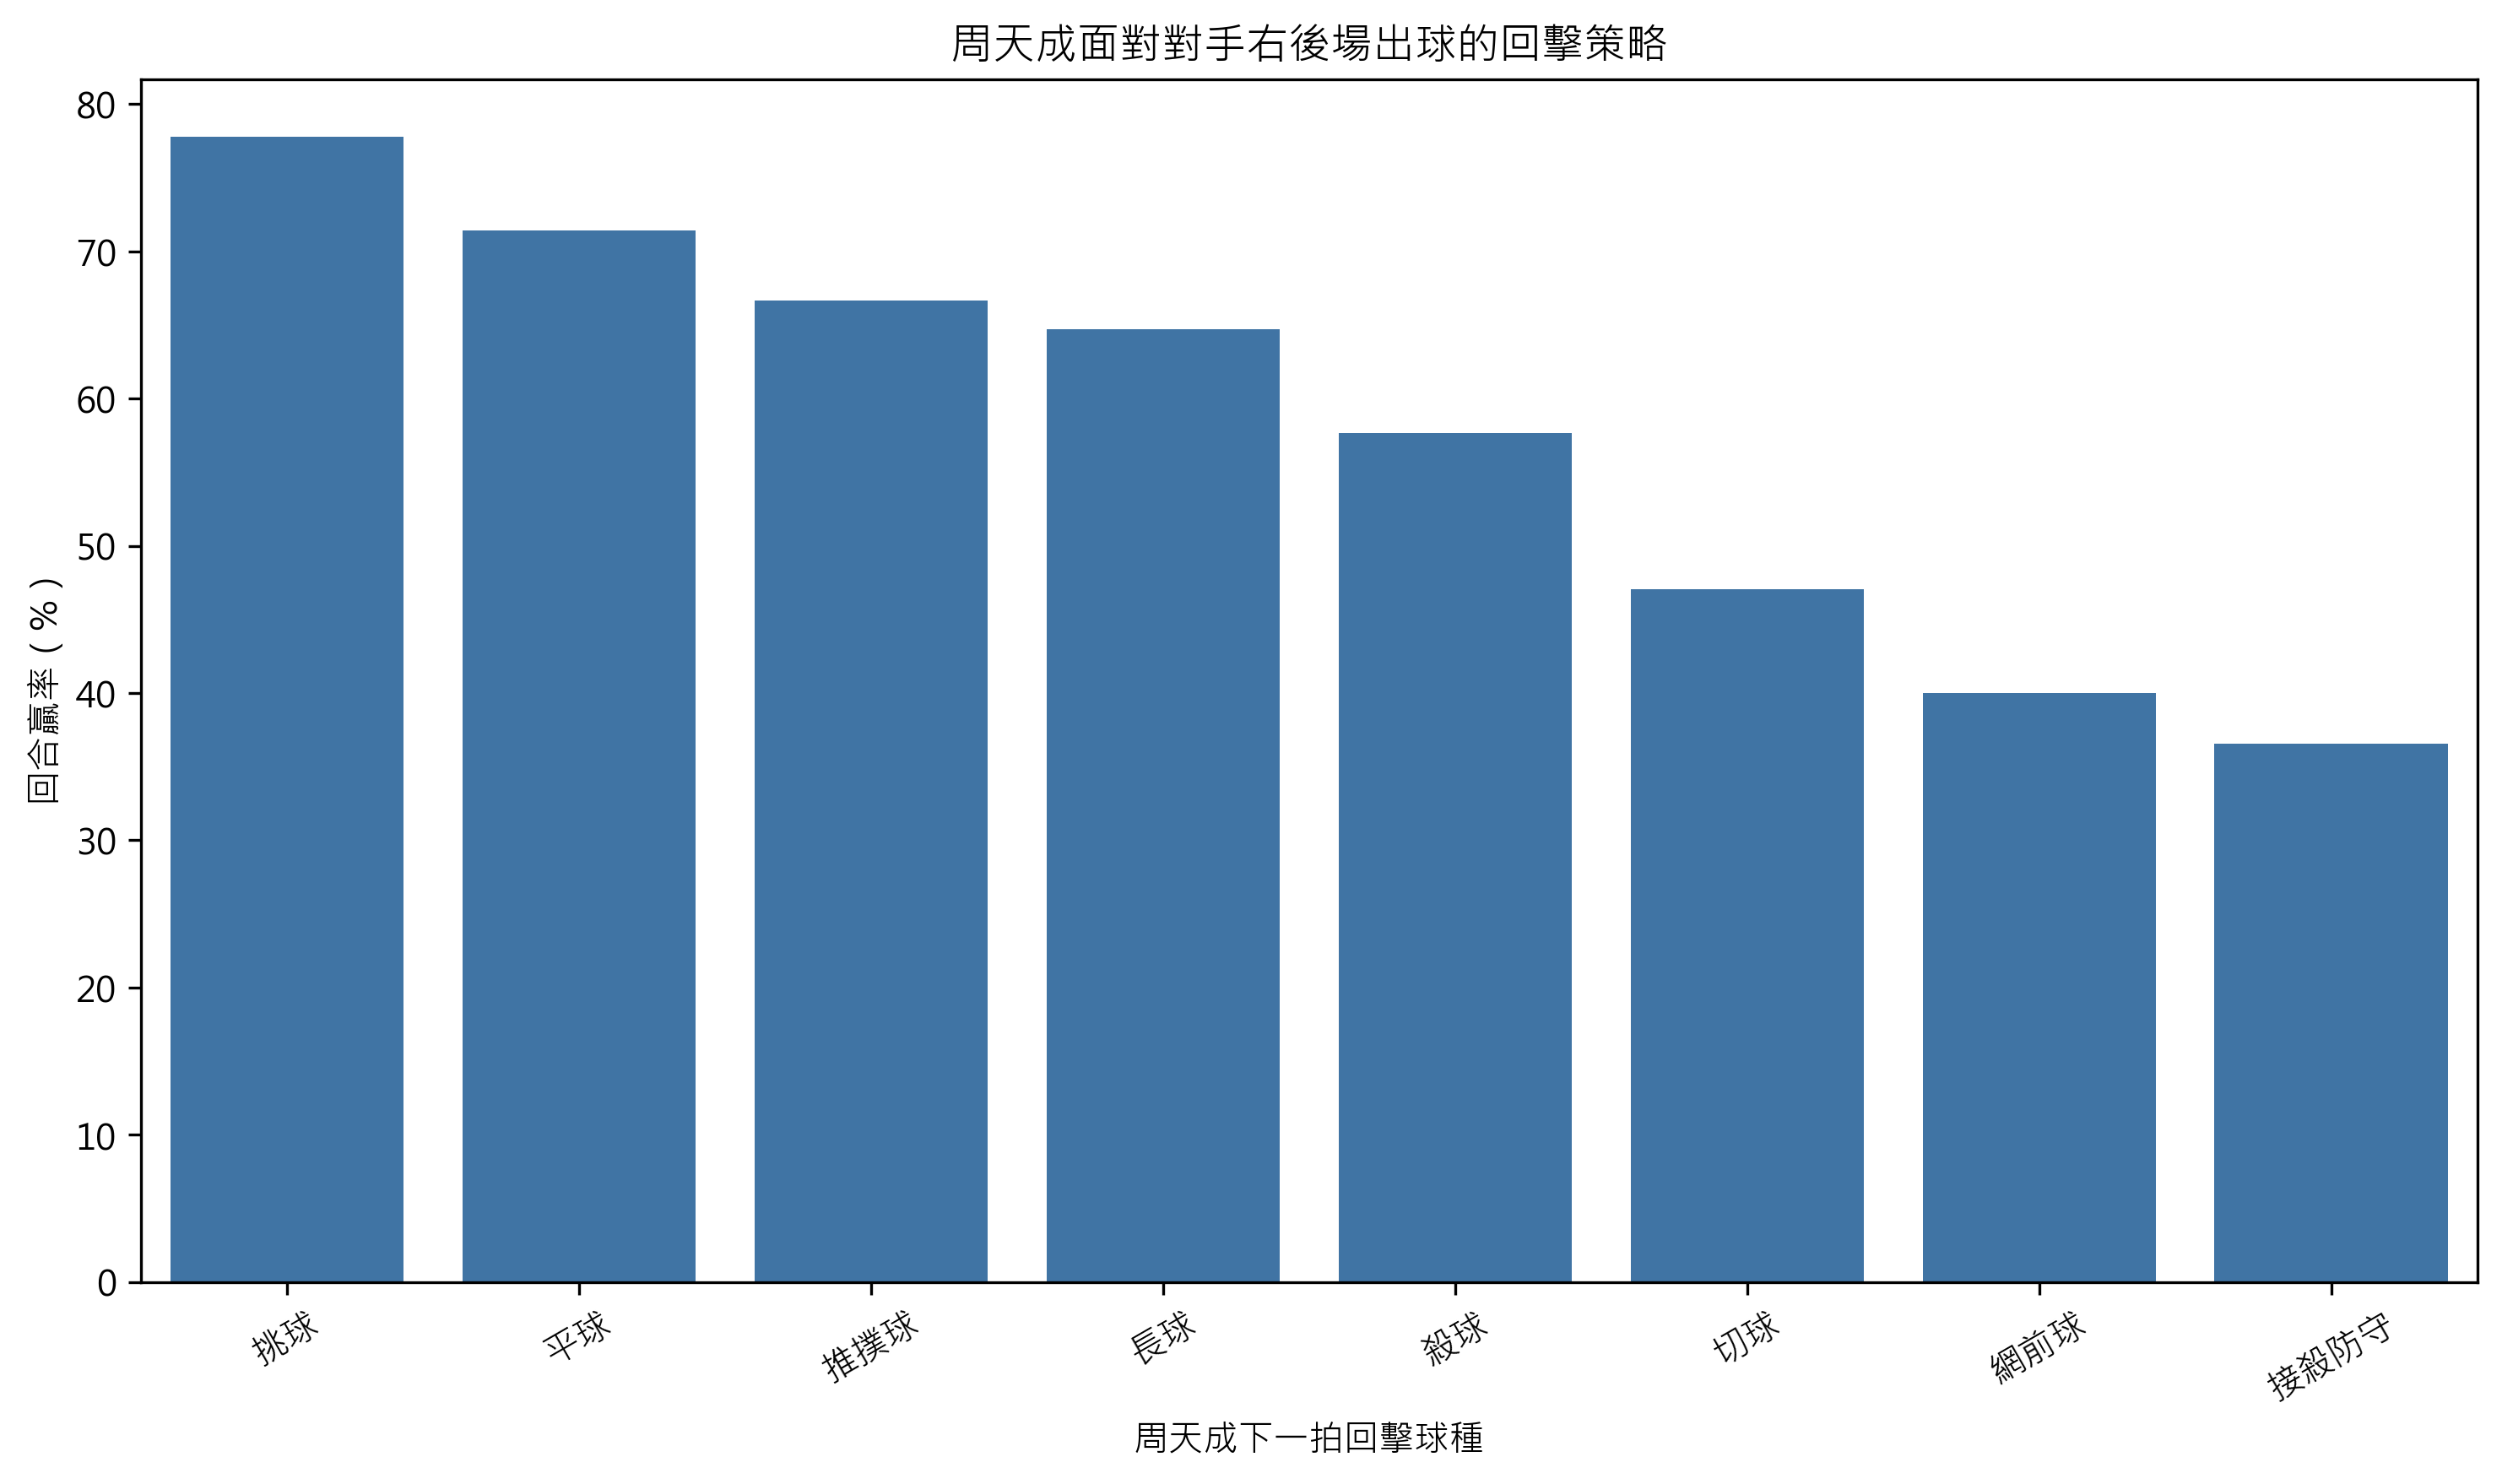

In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'hit_area', 'landing_area', 'getpoint_player', 'lose_reason',
    'win_reason'
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

fig, ax = plt.subplots(figsize=(10, 6))

if len(df) == 0:
    print("資料為空，無法分析。")
else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'
    group_cols = ['match_id', 'set', 'rally']

    data = df.sort_values(group_cols + ['ball_round']).copy()

    data['rally_winner'] = (
        data.groupby(group_cols)['getpoint_player']
        .transform('last')
    )

    grouped = data.groupby(group_cols, sort=False)

    data['next_player'] = grouped['player'].shift(-1)
    data['next_type'] = grouped['type'].shift(-1)
    data['next_hit_area'] = grouped['hit_area'].shift(-1)
    data['next_landing_area'] = grouped['landing_area'].shift(-1)
    data['next_ball_round'] = grouped['ball_round'].shift(-1)

    same_rally_next = (
        data['match_id'].eq(data['match_id'].shift(-1)) &
        data['set'].eq(data['set'].shift(-1)) &
        data['rally'].eq(data['rally'].shift(-1))
    )

    right_back = data[
        (data['player'] == opponent_player) &
        (data['hit_area'] == 4)
    ].copy()

    right_back['is_opponent_error'] = (
        right_back['rally_winner'].eq(target_player) &
        right_back['player'].eq(opponent_player)
    )

    right_back['is_opponent_active_win'] = (
        right_back['rally_winner'].eq(opponent_player) &
        right_back['player'].eq(opponent_player)
    )

    print("分析口徑：")
    print("1. 對手右後場定義為 hit_area=4，即後排右側。")
    print("2. 對手失誤定義為該回合最後擊球者為對手，且得分者為周天成。")
    print("3. 對手主動得分定義為最後擊球者與得分者皆為對手。")
    print("4. 對手右後場出球後，只分析同一 match_id、set、rally 的下一拍，且下一拍擊球者必須是周天成。")
    print("5. landing_area 是周天成下一拍將球送往的目標區域。")
    print()
    print("Court Grid Definitions：Zone 4 = 後排右側（Back-Right）；後排區域為 1、2、3、4。")
    print()

    total_right_back = len(right_back)
    right_back_error_count = int(right_back['is_opponent_error'].sum())
    right_back_active_win_count = int(right_back['is_opponent_active_win'].sum())

    print("對手右後場出球概況：")
    print(pd.DataFrame({
        '指標': ['右後場出球數', '對手失誤回合數', '對手失誤率', '對手主動得分回合數'],
        '數值': [
            total_right_back,
            right_back_error_count,
            round(right_back_error_count / total_right_back * 100, 2)
            if total_right_back > 0 else 0,
            right_back_active_win_count
        ]
    }).to_string(index=False))
    print()

    error_reasons = (
        right_back.loc[
            right_back['is_opponent_error'] &
            right_back['lose_reason'].notna(),
            'lose_reason'
        ]
        .value_counts()
        .rename_axis('對手右後場失誤原因')
        .reset_index(name='次數')
    )

    if len(error_reasons) > 0:
        error_reasons['比例(%)'] = (
            error_reasons['次數'] / error_reasons['次數'].sum() * 100
        ).round(2)
        print("對手右後場失誤原因：")
        print(error_reasons.to_string(index=False))
        print()

    response_df = right_back[
        same_rally_next &
        (right_back['next_player'] == target_player)
    ].copy()

    if len(response_df) == 0:
        print("資料中沒有足夠的同回合下一拍周天成回球紀錄，無法估計具體回擊策略。")
    else:
        response_df['chou_won_rally'] = (
            response_df['rally_winner'] == target_player
        )
        response_df['chou_active_win'] = (
            (response_df['rally_winner'] == target_player) &
            (response_df['next_player'] == target_player)
        )
        response_df['target_area'] = response_df['next_landing_area'].astype('Int64')

        response_by_type = (
            response_df.dropna(subset=['next_type'])
            .groupby('next_type')
            .agg(
                回擊次數=('next_type', 'size'),
                周天成贏回合數=('chou_won_rally', 'sum'),
                周天成主動得分數=('chou_active_win', 'sum')
            )
            .reset_index()
            .rename(columns={'next_type': '周天成回擊球種'})
        )

        if len(response_by_type) > 0:
            response_by_type['回合贏率(%)'] = (
                response_by_type['周天成贏回合數'] /
                response_by_type['回擊次數'] * 100
            ).round(2)
            response_by_type['主動得分率(%)'] = (
                response_by_type['周天成主動得分數'] /
                response_by_type['回擊次數'] * 100
            ).round(2)
            response_by_type = response_by_type.sort_values(
                ['回合贏率(%)', '回擊次數'],
                ascending=[False, False]
            )

            print("周天成面對對手右後場出球的下一拍策略成效：")
            print(response_by_type.to_string(index=False))
            print()

            plot_data = response_by_type.copy()
            plot_data['圖表球種'] = plot_data['周天成回擊球種'].astype(str)

            sns.barplot(
                data=plot_data,
                x='圖表球種',
                y='回合贏率(%)',
                color='#2F75B5',
                ax=ax
            )
            ax.set_title('周天成面對對手右後場出球的回擊策略')
            ax.set_xlabel('周天成下一拍回擊球種')
            ax.set_ylabel('回合贏率（%）')
            ax.tick_params(axis='x', rotation=30)

            eligible_type = response_by_type[
                response_by_type['回擊次數'] >= 3
            ]
            if len(eligible_type) == 0:
                eligible_type = response_by_type

            best_type = eligible_type.sort_values(
                ['回合贏率(%)', '回擊次數'],
                ascending=[False, False]
            ).iloc[0]

            print("策略建議：")
            print(
                f"優先考慮使用「{best_type['周天成回擊球種']}」；"
                f"樣本數 {int(best_type['回擊次數'])}，"
                f"觀察到的回合贏率為 {best_type['回合贏率(%)']:.2f}%、"
                f"主動得分率為 {best_type['主動得分率(%)']:.2f}%。"
            )
            print("實戰上應在對手右後場出球後立即壓迫，避免只等待對手失誤；優先以能直接造成主動得分或限制其下一拍的回擊方式為主。")

        response_by_target = (
            response_df.dropna(subset=['target_area'])
            .groupby('target_area')
            .agg(
                回擊次數=('target_area', 'size'),
                周天成贏回合數=('chou_won_rally', 'sum'),
                周天成主動得分數=('chou_active_win', 'sum')
            )
            .reset_index()
        )

        if len(response_by_target) > 0:
            response_by_target['回合贏率(%)'] = (
                response_by_target['周天成贏回合數'] /
                response_by_target['回擊次數'] * 100
            ).round(2)
            response_by_target['主動得分率(%)'] = (
                response_by_target['周天成主動得分數'] /
                response_by_target['回擊次數'] * 100
            ).round(2)
            response_by_target = response_by_target.sort_values(
                ['回合贏率(%)', '回擊次數'],
                ascending=[False, False]
            )

            print()
            print("周天成下一拍落點目標分析：")
            print(response_by_target.to_string(index=False))

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 93
**問題**: 當對手在關鍵分(18分以上)皆呈現非進攻狀態，周天成應如何調整球路設計來強化關鍵分得分率？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


分析口徑：周天成擊球當下，周天成比分 >= 18 分。
對手進攻型定義：殺球、推撲球、平球；其餘有效球種歸為非進攻型。
得分率 = 該球路設計所處擊球機會中，周天成贏得回合的比例。
主動得分 = getpoint_player == player；同時另列主動得分率，避免把對手失誤誤認為周天成主動得分。

關鍵分下不同對手狀態：
 對手狀態  擊球機會數  周天成得分數  周天成主動得分數  得分率  主動得分率
 進攻狀態     43      12         5 27.9   11.6
非進攻狀態    125      50        35 40.0   28.0

對手非進攻狀態下，周天成各球路表現：
type  擊球機會數  得分數  主動得分數  得分率  主動得分率
  殺球     18   10      7 55.6   38.9
接殺防守      7    3      2 42.9   28.6
 網前球     43   18     15 41.9   34.9
  挑球     10    4      4 40.0   40.0
 推撲球     23    8      4 34.8   17.4
  切球     10    3      1 30.0   10.0
  長球     10    2      2 20.0   20.0

…（輸出已截斷；notebook 僅保留重點）


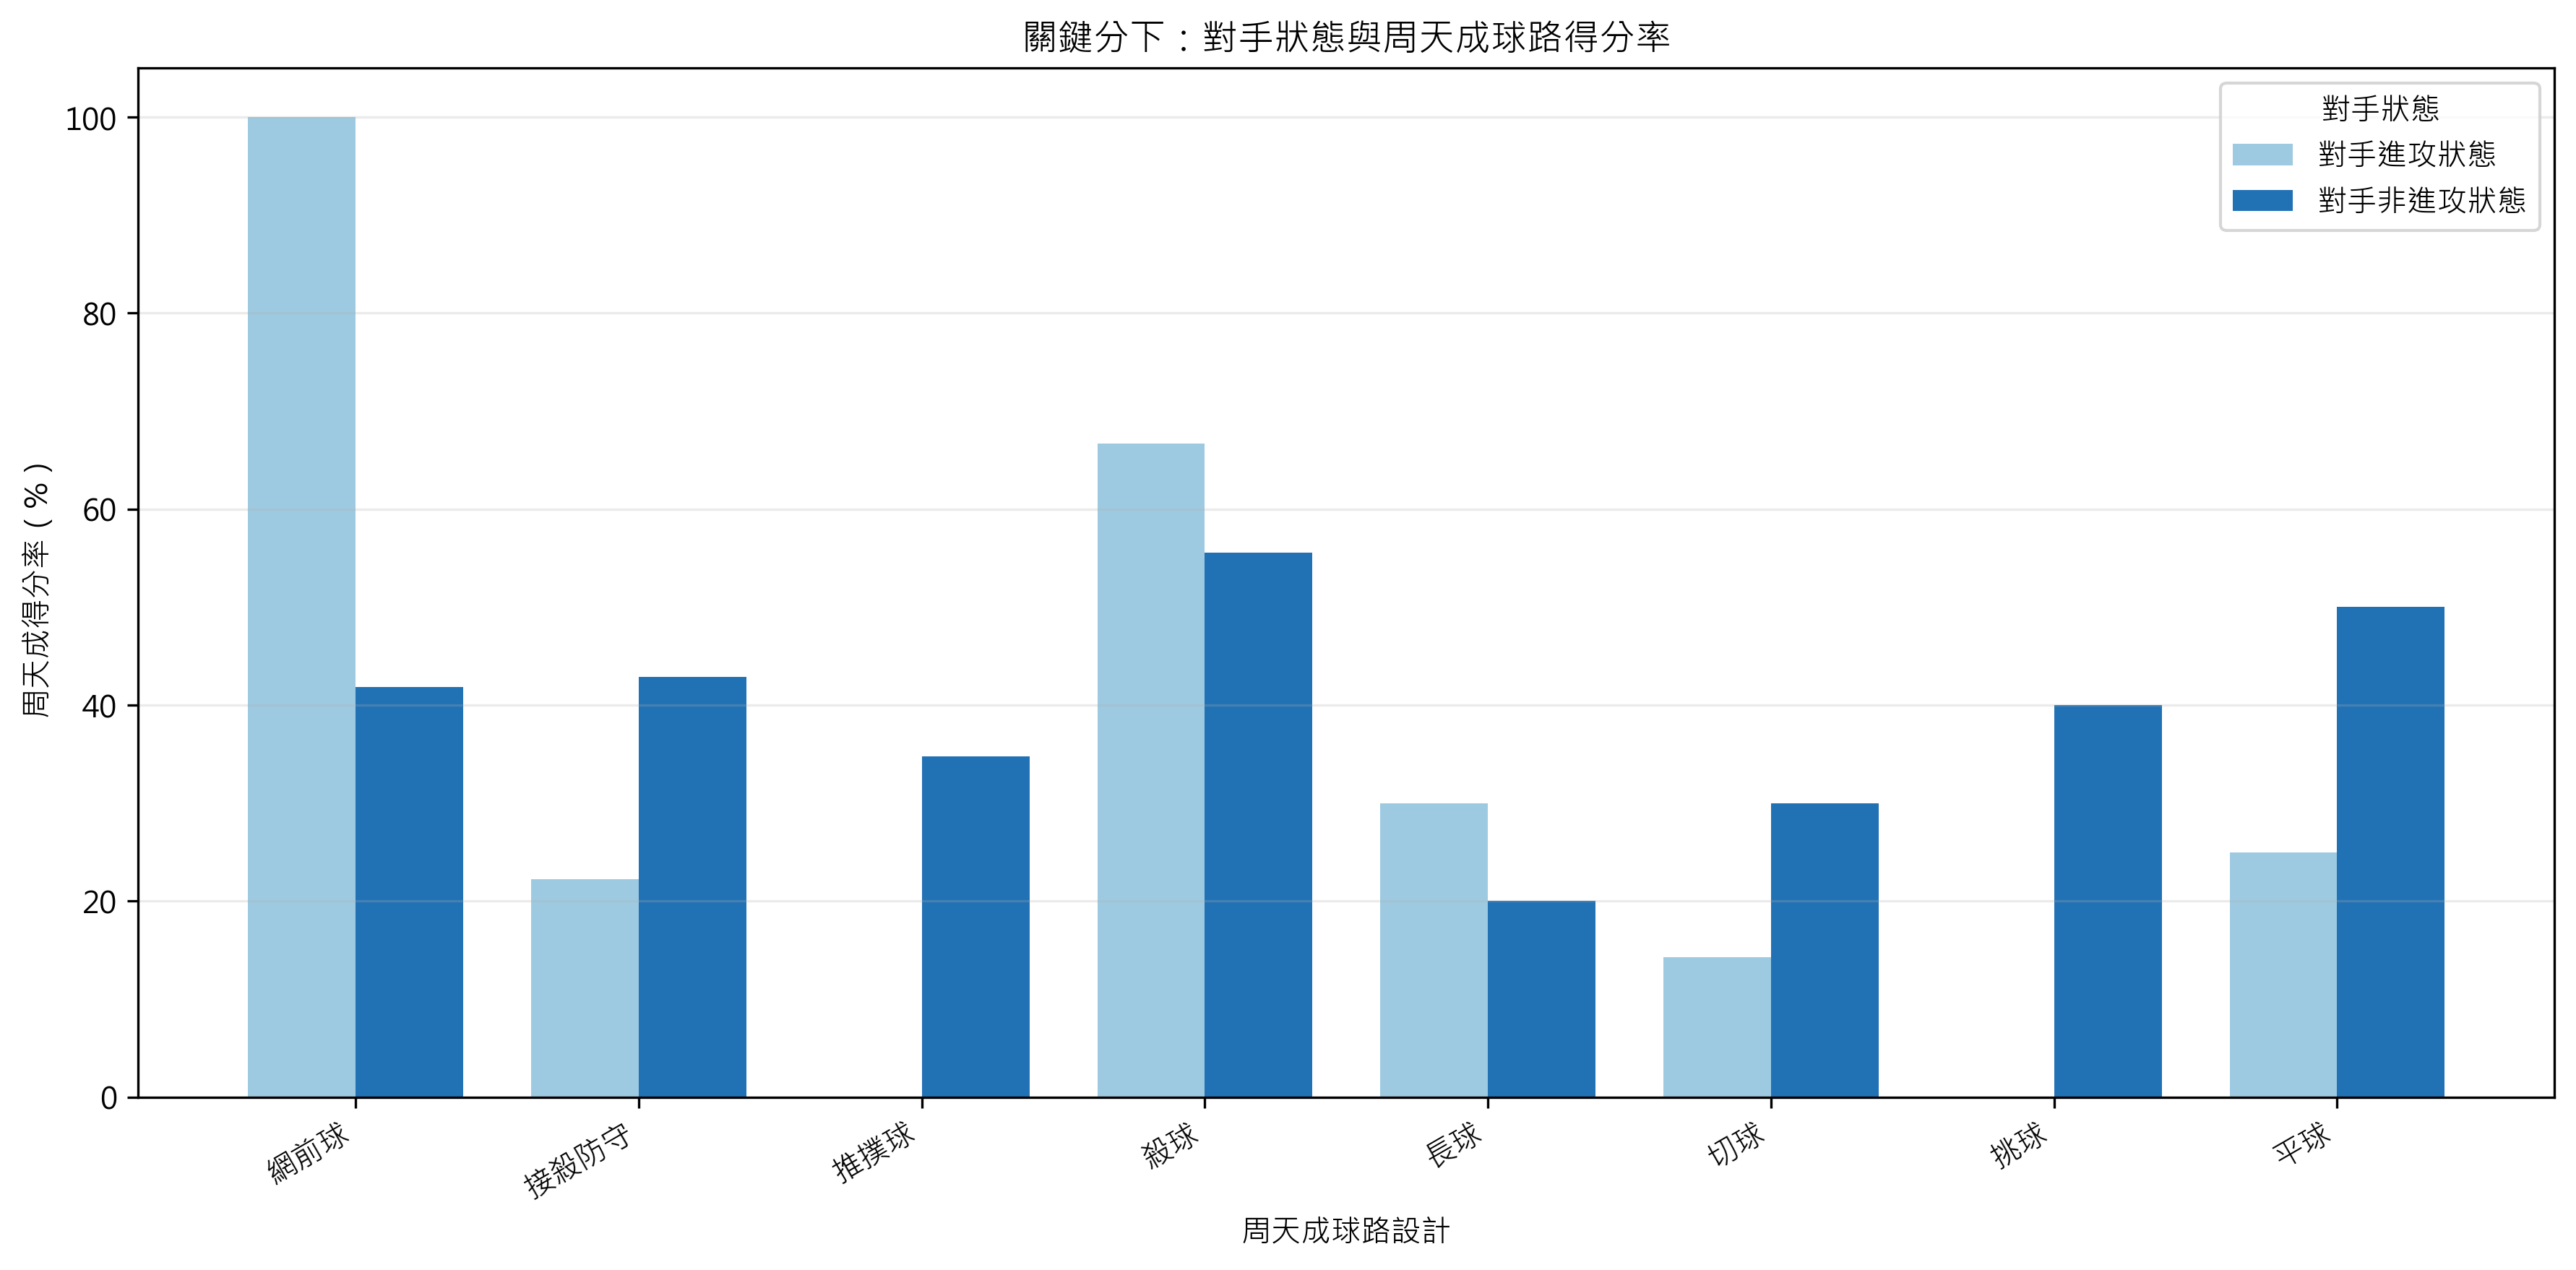

In [ ]:
required_cols = {
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player', 'CHOU Tien Chen_score'
}
missing_cols = required_cols.difference(df.columns)

if len(df) == 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis('off')
    print('資料為空，無法進行分析。')
elif missing_cols:
    raise ValueError(f'缺少必要欄位：{sorted(missing_cols)}')
else:
    chou = 'CHOU Tien Chen'
    key_score = 18

    # 操作性定義：殺球、推撲球、平球視為進攻型球路，其餘有效球種視為非進攻型。
    offensive_types = {'殺球', '推撲球', '平球'}

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_keys = ['match_id', 'set', 'rally']

    # 必須先在完整資料中建立同一回合的前一拍資訊，避免篩選後 shift 造成跨拍污染。
    grouped = work.groupby(rally_keys, sort=False)
    work['prev_player'] = grouped['player'].shift(1)
    work['prev_type'] = grouped['type'].shift(1)

    # 依回合取得得分者及最後擊球者。
    work['rally_getpoint_player'] = grouped['getpoint_player'].transform('last')
    work['rally_last_player'] = grouped['player'].transform('last')

    # 只分析周天成擊球，且前一拍確實是同回合對手擊球。
    analysis = work[
        (work['player'] == chou) &
        (work['prev_player'] == work['opponent']) &
        work['prev_type'].notna() &
        work['CHOU Tien Chen_score'].notna() &
        (work['CHOU Tien Chen_score'] >= key_score) &
        work['rally_getpoint_player'].notna()
    ].copy()

    fig, ax = plt.subplots(figsize=(12, 6))

    print(f'分析口徑：周天成擊球當下，周天成比分 >= {key_score} 分。')
    print('對手進攻型定義：殺球、推撲球、平球；其餘有效球種歸為非進攻型。')
    print('得分率 = 該球路設計所處擊球機會中，周天成贏得回合的比例。')
    print('主動得分 = getpoint_player == player；同時另列主動得分率，避免把對手失誤誤認為周天成主動得分。')

    if len(analysis) == 0:
        ax.axis('off')
        print('符合條件的周天成擊球資料不足，無法分析。')
    else:
        analysis['對手狀態'] = analysis['prev_type'].map(
            lambda x: '進攻狀態' if x in offensive_types else '非進攻狀態'
        )
        analysis['周天成得分'] = (
            analysis['rally_getpoint_player'] == chou
        )
        analysis['周天成主動得分'] = (
            (analysis['rally_getpoint_player'] == chou) &
            (analysis['rally_last_player'] == chou)
        )

        state_summary = (
            analysis.groupby('對手狀態', as_index=False)
            .agg(
                擊球機會數=('type', 'size'),
                周天成得分數=('周天成得分', 'sum'),
                周天成主動得分數=('周天成主動得分', 'sum')
            )
        )
        state_summary['得分率'] = (
            state_summary['周天成得分數'] /
            state_summary['擊球機會數'] * 100
        ).round(1)
        state_summary['主動得分率'] = (
            state_summary['周天成主動得分數'] /
            state_summary['擊球機會數'] * 100
        ).round(1)

        print('\n關鍵分下不同對手狀態：')
        print(state_summary.to_string(index=False))

        non_attack = analysis[
            analysis['對手狀態'] == '非進攻狀態'
        ].copy()

        if len(non_attack) == 0:
            print('\n沒有足夠的「對手非進攻狀態」樣本，無法提出球路調整建議。')
            ax.axis('off')
        else:
            shot_summary = (
                analysis.groupby(['type', '對手狀態'], as_index=False)
                .agg(
                    擊球機會數=('type', 'size'),
                    得分數=('周天成得分', 'sum'),
                    主動得分數=('周天成主動得分', 'sum')
                )
            )
            shot_summary['得分率'] = (
                shot_summary['得分數'] /
                shot_summary['擊球機會數'] * 100
            )
            shot_summary['主動得分率'] = (
                shot_summary['主動得分數'] /
                shot_summary['擊球機會數'] * 100
            )

            non_attack_shots = shot_summary[
                shot_summary['對手狀態'] == '非進攻狀態'
            ].copy()

            # 以至少 5 次機會降低小樣本極端值的影響；若沒有，則退回全部樣本。
            recommended = non_attack_shots[
                non_attack_shots['擊球機會數'] >= 5
            ].copy()
            if len(recommended) == 0:
                recommended = non_attack_shots.copy()

            recommended = recommended.sort_values(
                ['得分率', '主動得分率', '擊球機會數'],
                ascending=[False, False, False]
            )
            recommended['得分率'] = recommended['得分率'].round(1)
            recommended['主動得分率'] = recommended['主動得分率'].round(1)

            print('\n對手非進攻狀態下，周天成各球路表現：')
            print(
                recommended[
                    ['type', '擊球機會數', '得分數', '主動得分數',
                     '得分率', '主動得分率']
                ].to_string(index=False)
            )

            # 比較同一球種在對手非進攻與進攻狀態下的得分率。
            plot_data = shot_summary.copy()
            shot_order = (
                plot_data.groupby('type')['擊球機會數']
                .sum()
                .sort_values(ascending=False)
                .index
                .tolist()
            )

            pivot = plot_data.pivot(
                index='type',
                columns='對手狀態',
                values='得分率'
            ).reindex(shot_order)

            x = list(range(len(pivot)))
            width = 0.38

            if '進攻狀態' in pivot.columns:
                ax.bar(
                    [i - width / 2 for i in x],
                    pivot['進攻狀態'].fillna(0),
                    width=width,
                    label='對手進攻狀態',
                    color='#9ecae1'
                )

            if '非進攻狀態' in pivot.columns:
                ax.bar(
                    [i + width / 2 for i in x],
                    pivot['非進攻狀態'].fillna(0),
                    width=width,
                    label='對手非進攻狀態',
                    color='#2171b5'
                )

            ax.set_xticks(x)
            ax.set_xticklabels(pivot.index, rotation=30, ha='right')
            ax.set_ylabel('周天成得分率（%）')
            ax.set_xlabel('周天成球路設計')
            ax.set_title('關鍵分下：對手狀態與周天成球路得分率')
            ax.legend(title='對手狀態')
            ax.grid(axis='y', alpha=0.25)

            top_shot = recommended.iloc[0]
            print(
                f"\n建議：對手處於非進攻狀態時，優先增加「{top_shot['type']}」"
                f"的使用，該球路在 {int(top_shot['擊球機會數'])} 次機會中的得分率為"
                f"{top_shot['得分率']:.1f}%，主動得分率為"
                f"{top_shot['主動得分率']:.1f}%。"
            )
            print(
                '調整原則：優先選擇具備足夠樣本、得分率與主動得分率同時較高的球路，'
                '避免只依賴對手失誤造成的表面得分率。'
            )

    plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 95
**問題**: 比賽中若觀察到對手因壓力無法耐心打多拍，周天成可如何透過中場拉吊、穩定球路誘發對手躁進失誤？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


場地區域定義：後排=1-4，中排=5-16，前排=17-24，出界=25-32。
分析口徑：中場拉吊定義為周天成在中排區域擊出「長球」或「切球」。
對手失誤定義：同一回合最後一拍由對手擊球，且 getpoint_player 為周天成。

各策略誘發對手失誤與積極回擊：
strategy  機會數  對手失誤數    對手失誤率  對手積極回擊數  對手積極回擊率
    中場拉吊   80     16 0.200000       44 0.550000
   中場穩定球  524    152 0.290076      250 0.477099
  非中場穩定球 1056    257 0.243371      479 0.453598
    其他擊球  704    194 0.275568      266 0.377841

中場拉吊分球種效果：
type  機會數  對手失誤數    對手失誤率  對手積極回擊數  對手積極回擊率
  切球   34      8 0.235294       24 0.705882
  長球   46      8 0.173913       20 0.434783

對手失誤原因：
rally_last_lose_reason  次數
                    出界 359
                    掛網 191
…（輸出已截斷；notebook 僅保留重點）


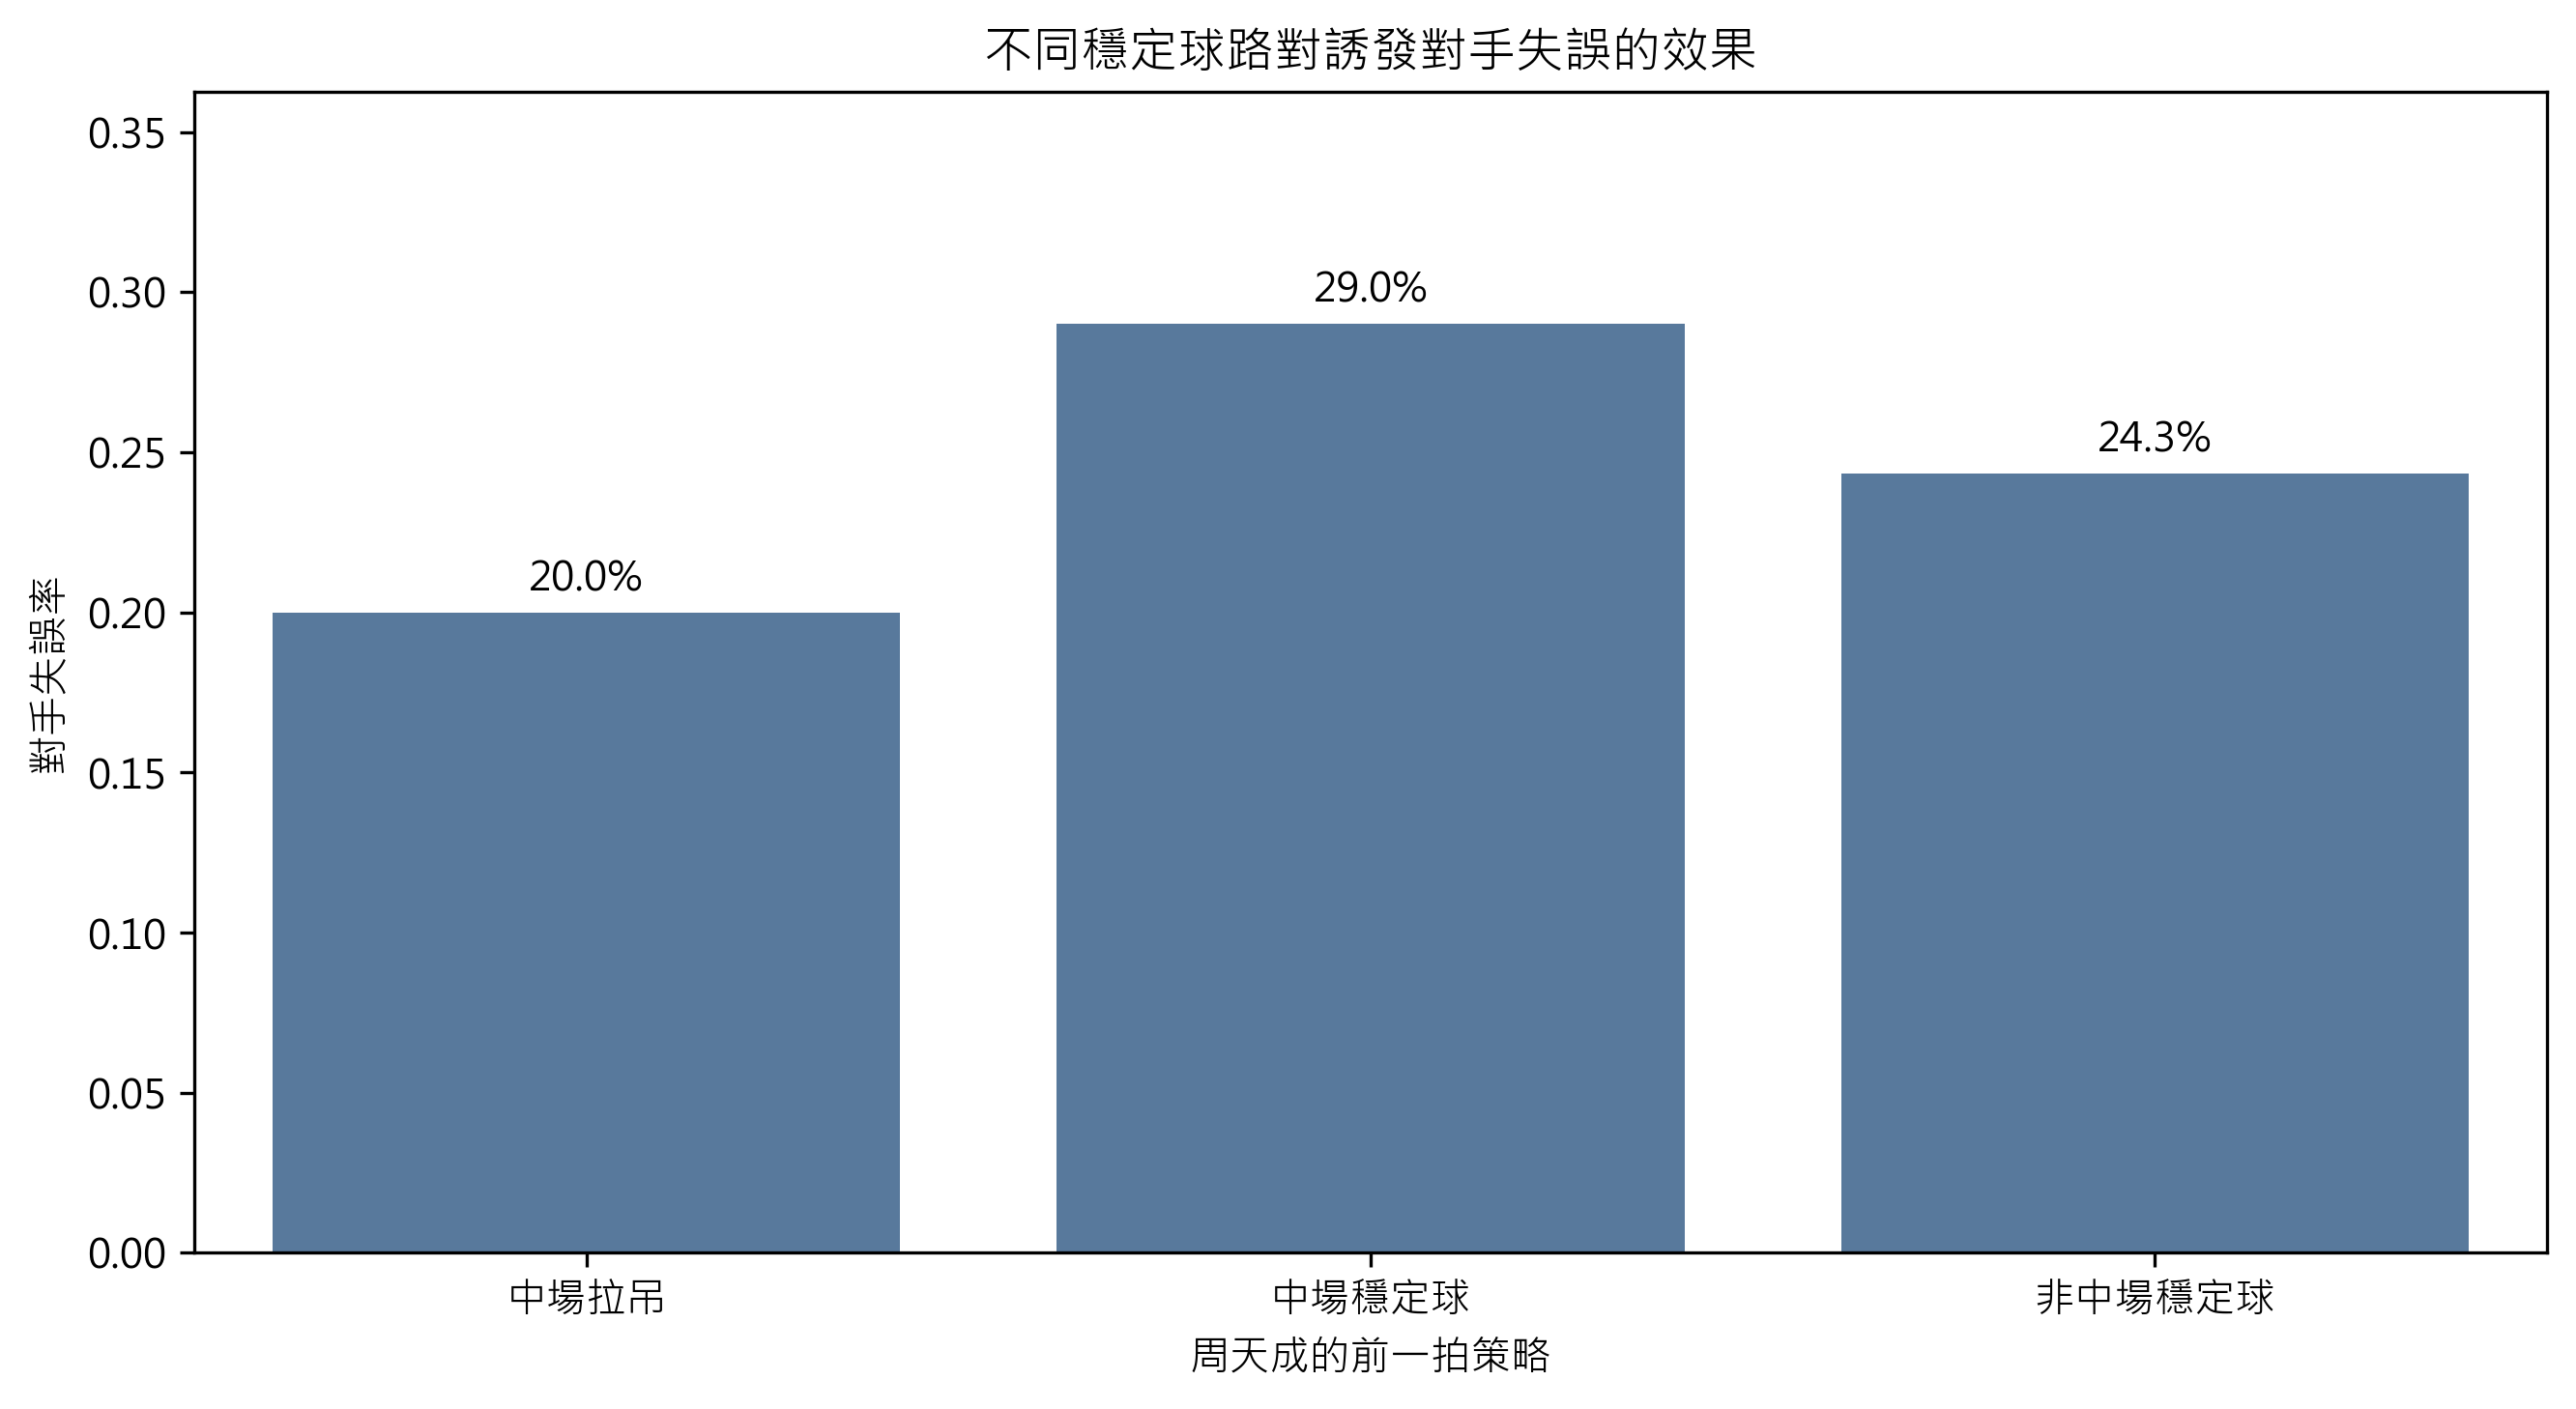

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if len(df) == 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title('資料為空，無法分析')
    ax.axis('off')
    plt.tight_layout()
    print('資料為空，無法進行分析。')
else:
    required_cols = [
        'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
        'type', 'hit_area', 'getpoint_player', 'lose_reason'
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title('欄位不足，無法分析')
        ax.axis('off')
        plt.tight_layout()
        print(f'缺少必要欄位：{missing_cols}')
    else:
        chou = 'CHOU Tien Chen'
        opponent = 'Kento MOMOTA'

        court_grid_definitions = {
            '後排': [1, 2, 3, 4],
            '中排': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
            '前排': [17, 18, 19, 20, 21, 22, 23, 24],
            '出界': [25, 26, 27, 28, 29, 30, 31, 32]
        }

        拉吊球種 = ['長球', '切球']
        穩定球種 = [
            '長球', '切球', '挑球', '網前球',
            '平球', '接殺防守'
        ]
        積極回擊球種 = [
            '殺球', '推撲球', '平球', '網前球'
        ]

        work = df.copy()
        work = work.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).reset_index(drop=True)

        group_cols = ['match_id', 'set', 'rally']
        grouped = work.groupby(group_cols, sort=False)

        work['next_player'] = grouped['player'].shift(-1)
        work['next_type'] = grouped['type'].shift(-1)
        work['next_hit_area'] = grouped['hit_area'].shift(-1)

        work['same_rally_next'] = (
            work['match_id'].eq(work['match_id'].shift(-1)) &
            work['set'].eq(work['set'].shift(-1)) &
            work['rally'].eq(work['rally'].shift(-1))
        )

        work['rally_getpoint_player'] = (
            grouped['getpoint_player'].transform('last')
        )
        work['rally_last_player'] = grouped['player'].transform('last')
        work['rally_last_lose_reason'] = (
            grouped['lose_reason'].transform('last')
        )

        work['is_mid_court'] = work['hit_area'].isin(
            court_grid_definitions['中排']
        )
        work['is_lob_drop'] = work['type'].isin(拉吊球種)
        work['is_stable'] = work['type'].isin(穩定球種)

        setup = work[
            (work['player'] == chou) &
            (work['next_player'] == opponent) &
            (work['same_rally_next']) &
            (work['hit_area'].notna())
        ].copy()

        setup['opponent_error'] = (
            (setup['rally_last_player'] == opponent) &
            (setup['rally_getpoint_player'] == chou)
        )

        setup['immediate_rush_return'] = (
            setup['next_type'].isin(積極回擊球種)
        )

        setup['strategy'] = '其他擊球'
        setup.loc[
            setup['is_mid_court'] & setup['is_lob_drop'],
            'strategy'
        ] = '中場拉吊'
        setup.loc[
            setup['is_mid_court'] &
            (~setup['is_lob_drop']) &
            setup['is_stable'],
            'strategy'
        ] = '中場穩定球'
        setup.loc[
            (~setup['is_mid_court']) & setup['is_stable'],
            'strategy'
        ] = '非中場穩定球'

        if len(setup) == 0:
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.set_title('沒有足夠的周天成連續擊球資料')
            ax.axis('off')
            plt.tight_layout()
            print('沒有找到周天成擊球後由對手接續回擊的有效樣本。')
        else:
            strategy_summary = (
                setup.groupby('strategy', as_index=False)
                .agg(
                    機會數=('opponent_error', 'size'),
                    對手失誤數=('opponent_error', 'sum'),
                    對手失誤率=('opponent_error', 'mean'),
                    對手積極回擊數=(
                        'immediate_rush_return', 'sum'
                    )
                )
            )

            strategy_summary['對手積極回擊率'] = (
                strategy_summary['對手積極回擊數'] /
                strategy_summary['機會數']
            )

            strategy_order = [
                '中場拉吊',
                '中場穩定球',
                '非中場穩定球',
                '其他擊球'
            ]
            strategy_summary['排序'] = strategy_summary['strategy'].map(
                {
                    name: index
                    for index, name in enumerate(strategy_order)
                }
            )
            strategy_summary = (
                strategy_summary
                .sort_values('排序')
                .drop(columns='排序')
                .reset_index(drop=True)
            )

            type_summary = (
                setup[
                    setup['is_mid_court'] &
                    setup['is_lob_drop']
                ]
                .groupby('type', as_index=False)
                .agg(
                    機會數=('opponent_error', 'size'),
                    對手失誤數=('opponent_error', 'sum'),
                    對手失誤率=('opponent_error', 'mean'),
                    對手積極回擊數=(
                        'immediate_rush_return', 'sum'
                    )
                )
            )

            if len(type_summary) > 0:
                type_summary['對手積極回擊率'] = (
                    type_summary['對手積極回擊數'] /
                    type_summary['機會數']
                )

            error_reason_summary = (
                setup[
                    setup['opponent_error'] &
                    setup['rally_last_lose_reason'].notna()
                ]
                .groupby('rally_last_lose_reason')
                .size()
                .reset_index(name='次數')
                .sort_values('次數', ascending=False)
            )

            print(
                '場地區域定義：後排=1-4，中排=5-16，'
                '前排=17-24，出界=25-32。'
            )
            print(
                '分析口徑：中場拉吊定義為周天成在中排區域擊出'
                '「長球」或「切球」。'
            )
            print(
                '對手失誤定義：同一回合最後一拍由對手擊球，'
                '且 getpoint_player 為周天成。'
            )
            print('\n各策略誘發對手失誤與積極回擊：')
            print(strategy_summary.to_string(index=False))

            if len(type_summary) > 0:
                print('\n中場拉吊分球種效果：')
                print(type_summary.to_string(index=False))
            else:
                print('\n沒有足夠的中場拉吊樣本可分球種分析。')

            if len(error_reason_summary) > 0:
                print('\n對手失誤原因：')
                print(error_reason_summary.to_string(index=False))
            else:
                print('\n沒有記錄到對手失誤原因。')

            plot_df = strategy_summary[
                strategy_summary['strategy'].isin(
                    ['中場拉吊', '中場穩定球', '非中場穩定球']
                )
            ].copy()

            fig, ax = plt.subplots(figsize=(9, 5))

            if len(plot_df) > 0:
                sns.barplot(
                    data=plot_df,
                    x='strategy',
                    y='對手失誤率',
                    color='#4C78A8',
                    ax=ax
                )
                ax.set_xlabel('周天成的前一拍策略')
                ax.set_ylabel('對手失誤率')
                ax.set_title('不同穩定球路對誘發對手失誤的效果')

                upper_limit = max(
                    0.1,
                    float(plot_df['對手失誤率'].max()) * 1.25
                )
                ax.set_ylim(0, min(1, upper_limit))

                labels = [
                    f'{value:.1%}'
                    for value in plot_df['對手失誤率']
                ]
                for container in ax.containers:
                    ax.bar_label(
                        container,
                        labels=labels,
                        padding=3
                    )
            else:
                ax.set_title('沒有足夠資料繪製策略比較')
                ax.axis('off')

            plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 100
**問題**: 當對手偏好在網前搶撲時，周天成應如何調整網前落點深淺與後續連接球種？
> **使用的資料欄位群組**: `全欄位 (Fallback)`


周天成可分析的有效落點樣本數：2364
對手下一拍使用推撲球的樣本數：217

不同落點深度引發對手推撲球的比例：
    落點深度  有效樣本數  對手推撲球次數  推撲球比例(%)
網前近網(M2)    385       68     17.66
網前後側(M1)    506       93     18.38
中場前側(M3)    295       45     15.25
中場中側(M2)    332       10      3.01
中場後側(M1)    334        1      0.30
      後場    512        0      0.00
      出界      0        0      0.00

對手推撲後，周天成的後續連接球種：
後續球種  連接次數  周天成贏得回合數  回合贏率(%)
 推撲球     2         2   100.00
  切球    54        22    40.74
  長球    66        26    39.39
  殺球    46        18    39.13
接殺防守     8         3    37.50
…（輸出已截斷；notebook 僅保留重點）


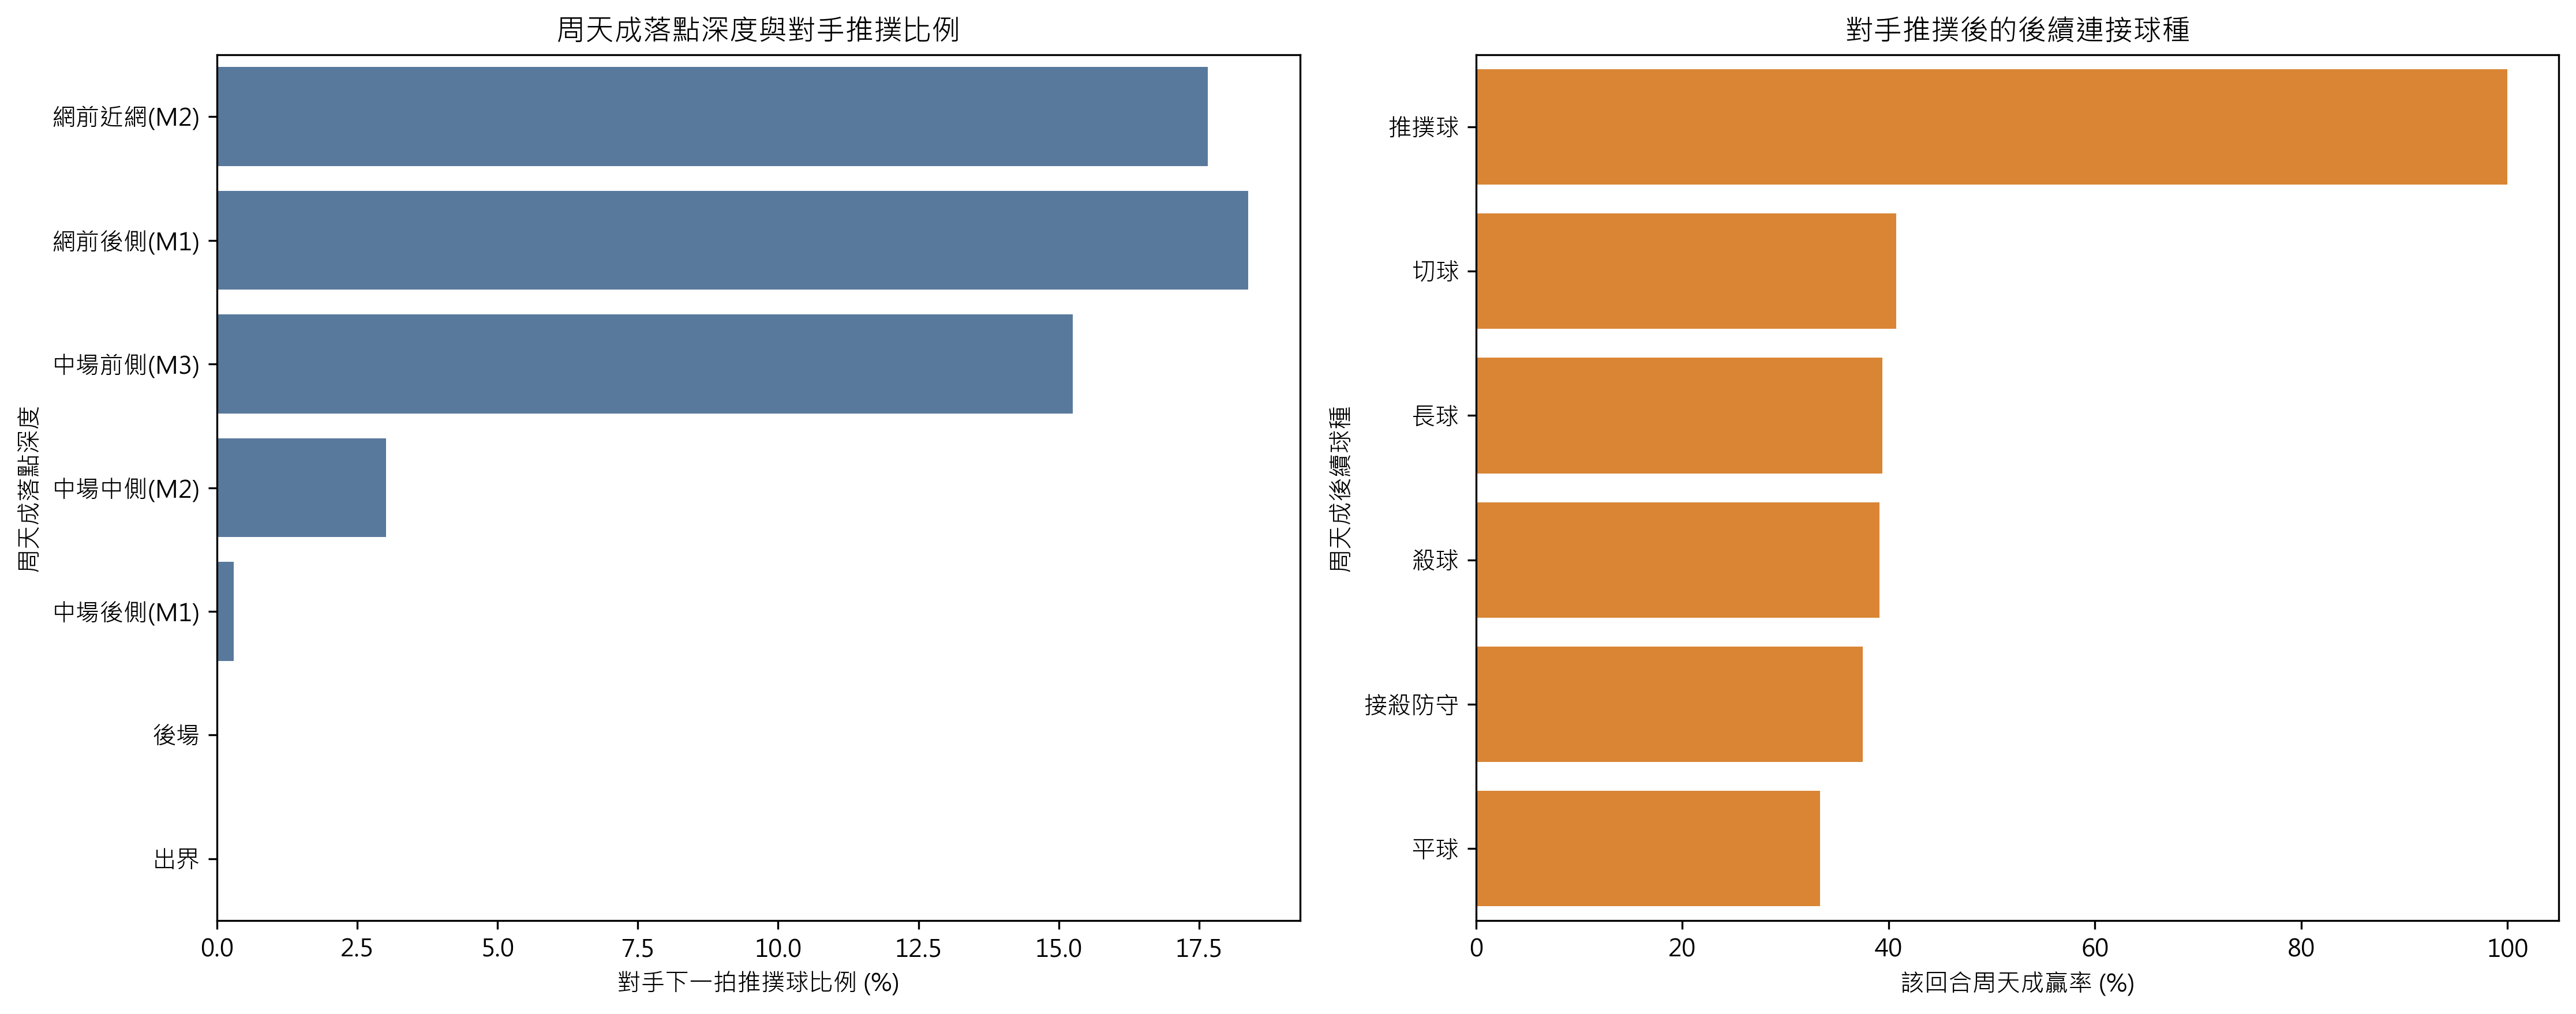

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'landing_area', 'getpoint_player'
]

if len(df) == 0:
    print('資料為空，無法進行分析。')
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if len(missing_cols) > 0:
        print(f'缺少必要欄位：{missing_cols}')
    else:
        chou = 'CHOU Tien Chen'
        opponent = 'Kento MOMOTA'
        group_cols = ['match_id', 'set', 'rally']

        court_grid_definitions = {
            '網前近網(M2)': [21, 22, 23, 24],
            '網前後側(M1)': [17, 18, 19, 20],
            '中場前側(M3)': [13, 14, 15, 16],
            '中場中側(M2)': [9, 10, 11, 12],
            '中場後側(M1)': [5, 6, 7, 8],
            '後場': [1, 2, 3, 4],
            '出界': [25, 26, 27, 28, 29, 30, 31, 32]
        }

        depth_order = [
            '網前近網(M2)',
            '網前後側(M1)',
            '中場前側(M3)',
            '中場中側(M2)',
            '中場後側(M1)',
            '後場',
            '出界'
        ]

        data = df.sort_values(
            group_cols + ['ball_round'],
            kind='mergesort'
        ).copy()

        def classify_landing_depth(area):
            if pd.isna(area):
                return pd.NA

            area = int(area)

            for category, zones in court_grid_definitions.items():
                if area in zones:
                    return category

            return '未知區域'

        data['landing_depth'] = data['landing_area'].map(
            classify_landing_depth
        )

        data['rally_winner'] = (
            data.groupby(group_cols, sort=False)['getpoint_player']
            .transform('last')
        )

        grouped = data.groupby(group_cols, sort=False)

        data['next_player'] = grouped['player'].shift(-1)
        data['next_type'] = grouped['type'].shift(-1)
        data['next2_player'] = grouped['player'].shift(-2)
        data['next2_type'] = grouped['type'].shift(-2)

        eligible_mask = (
            (data['player'] == chou) &
            (data['next_player'] == opponent) &
            data['landing_area'].notna() &
            data['landing_depth'].notna()
        )

        pounce_mask = (
            eligible_mask &
            (data['next_type'] == '推撲球')
        )

        eligible = data.loc[eligible_mask].copy()
        pounce = data.loc[pounce_mask].copy()

        print(f'周天成可分析的有效落點樣本數：{len(eligible)}')
        print(f'對手下一拍使用推撲球的樣本數：{len(pounce)}')

        depth_stats = pd.DataFrame()

        if len(eligible) > 0:
            overall_depth = (
                eligible.groupby('landing_depth', observed=False)
                .size()
                .reindex(depth_order, fill_value=0)
                .rename('有效樣本數')
            )

            pounce_depth = (
                pounce.groupby('landing_depth', observed=False)
                .size()
                .reindex(depth_order, fill_value=0)
                .rename('對手推撲球次數')
            )

            depth_stats = pd.concat(
                [overall_depth, pounce_depth],
                axis=1
            ).fillna(0)

            depth_stats['推撲球比例(%)'] = (
                depth_stats['對手推撲球次數']
                .div(depth_stats['有效樣本數'].replace(0, pd.NA))
                .mul(100)
                .fillna(0)
                .round(2)
            )

            depth_table = (
                depth_stats
                .reset_index()
                .rename(columns={'landing_depth': '落點深度'})
            )

            print('\n不同落點深度引發對手推撲球的比例：')
            print(depth_table.to_string(index=False))

        response = pounce.loc[
            (pounce['next2_player'] == chou) &
            pounce['next2_type'].notna()
        ].copy()

        response_stats = pd.DataFrame()

        if len(response) > 0:
            response_stats = (
                response.groupby('next2_type', observed=False)
                .agg(
                    連接次數=('next2_type', 'size'),
                    周天成贏得回合數=(
                        'rally_winner',
                        lambda values: (values == chou).sum()
                    )
                )
            )

            response_stats['回合贏率(%)'] = (
                response_stats['周天成贏得回合數']
                .div(response_stats['連接次數'].replace(0, pd.NA))
                .mul(100)
                .fillna(0)
                .round(2)
            )

            response_stats = response_stats.sort_values(
                ['回合贏率(%)', '連接次數'],
                ascending=[False, False]
            )

            response_table = (
                response_stats
                .reset_index()
                .rename(columns={'next2_type': '後續球種'})
            )

            print('\n對手推撲後，周天成的後續連接球種：')
            print(response_table.to_string(index=False))

            frequent_response = response_stats[
                response_stats['連接次數'] >= 5
            ]

            if len(frequent_response) == 0:
                frequent_response = response_stats

            recommended_types = frequent_response.head(3).index.tolist()
            recommended_text = '、'.join(recommended_types)
        else:
            recommended_text = '資料不足'

        print('\n戰術解讀：')

        if len(depth_stats) > 0:
            stable_depth = depth_stats[
                depth_stats['有效樣本數'] >= 5
            ]

            if len(stable_depth) == 0:
                stable_depth = depth_stats[
                    depth_stats['有效樣本數'] > 0
                ]

            if len(stable_depth) > 0:
                safest_depth = stable_depth[
                    '推撲球比例(%)'
                ].idxmin()

                highest_risk_depth = stable_depth[
                    '推撲球比例(%)'
                ].idxmax()

                print(
                    f'對手最常在「{highest_risk_depth}」落點後使用推撲球，'
                    f'比例為 '
                    f'{stable_depth.loc[highest_risk_depth, "推撲球比例(%)"]:.2f}%。'
                )

                print(
                    f'「{safest_depth}」的推撲球比例最低，為 '
                    f'{stable_depth.loc[safest_depth, "推撲球比例(%)"]:.2f}%。'
                )

                print(
                    f'建議降低高風險落點的使用，增加較不易被搶撲的落點深度；'
                    f'對手搶撲後，優先強化「{recommended_text}」的後續連接。'
                )
            else:
                print('落點深度樣本不足，無法提出可靠的深淺調整建議。')
        else:
            print('沒有可分析的落點資料。')

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        if len(depth_stats) > 0:
            plot_depth = (
                depth_stats
                .reindex(depth_order)
                .reset_index()
                .rename(columns={'landing_depth': '落點深度'})
            )

            sns.barplot(
                data=plot_depth,
                x='推撲球比例(%)',
                y='落點深度',
                order=depth_order,
                color='#4C78A8',
                ax=axes[0]
            )

            axes[0].set_title('周天成落點深度與對手推撲比例')
            axes[0].set_xlabel('對手下一拍推撲球比例 (%)')
            axes[0].set_ylabel('周天成落點深度')
        else:
            axes[0].text(
                0.5, 0.5,
                '沒有可分析的落點資料',
                ha='center',
                va='center'
            )
            axes[0].set_axis_off()

        if len(response_stats) > 0:
            response_plot = (
                response_stats
                .head(8)
                .reset_index()
                .rename(columns={'next2_type': '後續球種'})
            )

            sns.barplot(
                data=response_plot,
                x='回合贏率(%)',
                y='後續球種',
                color='#F58518',
                ax=axes[1]
            )

            axes[1].set_title('對手推撲後的後續連接球種')
            axes[1].set_xlabel('該回合周天成贏率 (%)')
            axes[1].set_ylabel('周天成後續球種')
        else:
            axes[1].text(
                0.5, 0.5,
                '沒有可分析的後續連接資料',
                ha='center',
                va='center'
            )
            axes[1].set_axis_off()

        plt.tight_layout()


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。
